# Exploration Notebook: CME Gold Futures POI Research

This is the primary Branch A (True POI) research notebook. It runs top to bottom in `.venv-1` and requires the raw Databento DBN at `data/raw/databento/`; the first cells build the processed parquet from it when missing.

How to read it:

- Sections 1-2: data loading, conversion, and structural validation.
- Section 3: exploratory data analysis of contracts, liquidity, sessions, volatility, returns, and microstructure.
- Section 4: construction of the trusted `research_bars` active-contract dataset used by every later stage.
- Section 5: formalization of the discretionary POI strategy into measurable rules.
- Section 6: the frozen refined POI engine and machine-readable signal tables. The Section 6C tables are produced by `scripts/run_section6c_refinement.py`; the notebook cells display those saved outputs.
- Section 7: the completed True POI context research. Its tables are produced by `scripts/run_section7_poi_context_research.py`.
- Appendix A (separate notebook): a superseded prototype event study kept for traceability.

Authoritative status and results live in `project_docs/Quant Project 1 - Context Report 23-06-2026.md`; the final Authoritative sections override older progress entries. The independent statistical branch lives in `statistical_feature_research.ipynb` and must not be mixed with POI outputs.


# 1.0 Project Setup & Imports

Importing all necessary libraries for our project.

In [1]:
import os
from pathlib import Path
import sys
import datetime as dt
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import databento as db
from scipy import stats
import pyarrow as pa
import pyarrow.parquet as pq
import time


define our main paths 

In [2]:
from pathlib import Path

# Resolve the repository root portably instead of hard-coding one
# contributor's local machine path. Walk up from the working directory and
# stop at the first ancestor that is the repo root (contains .git, or the
# tracked data/raw/databento folder as a fallback).
_start = Path.cwd().resolve()
_root = next(
    (p for p in (_start, *_start.parents)
     if (p / ".git").exists() or (p / "data" / "raw" / "databento").is_dir()),
    _start,
)

project_root = str(_root)
data_path = str(_root / "data" / "raw" / "databento" / "glbx-mdp3-20210524-20260524.ohlcv-1m.dbn")
parquette_path = str(_root / "data" / "processed" / "glbx-mdp3-20210524-20260524.ohlcv-1m.parquet")

In [3]:
# On a fresh clone only the raw Databento DBN is present, so build the
# intermediate 1-minute parquet from it on first use. Later runs reuse it.
if not Path(parquette_path).exists():
    db.DBNStore.from_file(data_path).to_df().to_parquet(parquette_path)

df = pd.read_parquet(parquette_path)

# 2.0 Load & Inspect Raw Databento Data

## 2.1 Load DBN Store

store = db.DBNStore.from_file(data_path)

**Convert to a DataFrame**

df = store.to_df()

**Convert dbn data to parquet**

df.to_parquet(os.path.join(project_root, "data", "processed", "glbx-mdp3-20210524-20260524.ohlcv-1m.parquet"))

## 2.2 Validate Dataset Structure

**Quick Inspection**

In [4]:
print(df.shape)
df.head()

(9527903, 9)


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2021-05-24 00:00:00+00:00,33,1,18139,-2.2,-2.1,-2.2,-2.1,41,GCM1-GCQ1
2021-05-24 00:00:00+00:00,33,1,152,1886.1,1886.7,1886.1,1886.5,55,GCQ1
2021-05-24 00:00:00+00:00,33,1,100440,1884.2,1884.5,1883.9,1884.0,126,GCM1
2021-05-24 00:00:00+00:00,33,1,23557,-2.1,-2.1,-2.1,-2.1,2,MGCM1-MGCQ1
2021-05-24 00:00:00+00:00,33,1,30106,1886.3,1886.3,1886.3,1886.3,2,MGCQ1


In [5]:
df.columns

Index(['rtype', 'publisher_id', 'instrument_id', 'open', 'high', 'low',
       'close', 'volume', 'symbol'],
      dtype='str')

**Data types**

In [6]:
df.dtypes

rtype              uint8
publisher_id      uint16
instrument_id     uint32
open             float64
high             float64
low              float64
close            float64
volume            uint64
symbol               str
dtype: object

**Check for missing entries**

In [7]:
df.isna().sum()

rtype            0
publisher_id     0
instrument_id    0
open             0
high             0
low              0
close            0
volume           0
symbol           0
dtype: int64

**What is the index?**

In [8]:
df.index

DatetimeIndex(['2021-05-24 00:00:00+00:00', '2021-05-24 00:00:00+00:00',
               '2021-05-24 00:00:00+00:00', '2021-05-24 00:00:00+00:00',
               '2021-05-24 00:00:00+00:00', '2021-05-24 00:00:00+00:00',
               '2021-05-24 00:01:00+00:00', '2021-05-24 00:01:00+00:00',
               '2021-05-24 00:01:00+00:00', '2021-05-24 00:01:00+00:00',
               ...
               '2026-05-22 20:58:00+00:00', '2026-05-22 20:58:00+00:00',
               '2026-05-22 20:59:00+00:00', '2026-05-22 20:59:00+00:00',
               '2026-05-22 20:59:00+00:00', '2026-05-22 20:59:00+00:00',
               '2026-05-22 20:59:00+00:00', '2026-05-22 20:59:00+00:00',
               '2026-05-22 20:59:00+00:00', '2026-05-22 20:59:00+00:00'],
              dtype='datetime64[ns, UTC]', name='ts_event', length=9527903, freq=None)

**Data date range**

In [9]:
df.index.min(), df.index.max()

(Timestamp('2021-05-24 00:00:00+0000', tz='UTC'),
 Timestamp('2026-05-22 20:59:00+0000', tz='UTC'))

**Are timestamps sorted?**

In [10]:
df.index.is_monotonic_increasing

True

**Check for duplicated enties**

In [11]:
df.duplicated().sum()

np.int64(3537591)

**Convert time from utc to New York time**

In [12]:
df.index.tz_convert("America/New_York")

DatetimeIndex(['2021-05-23 20:00:00-04:00', '2021-05-23 20:00:00-04:00',
               '2021-05-23 20:00:00-04:00', '2021-05-23 20:00:00-04:00',
               '2021-05-23 20:00:00-04:00', '2021-05-23 20:00:00-04:00',
               '2021-05-23 20:01:00-04:00', '2021-05-23 20:01:00-04:00',
               '2021-05-23 20:01:00-04:00', '2021-05-23 20:01:00-04:00',
               ...
               '2026-05-22 16:58:00-04:00', '2026-05-22 16:58:00-04:00',
               '2026-05-22 16:59:00-04:00', '2026-05-22 16:59:00-04:00',
               '2026-05-22 16:59:00-04:00', '2026-05-22 16:59:00-04:00',
               '2026-05-22 16:59:00-04:00', '2026-05-22 16:59:00-04:00',
               '2026-05-22 16:59:00-04:00', '2026-05-22 16:59:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='ts_event', length=9527903, freq=None)

**Separate the data by the symbols**

In [13]:
gc = df[df["symbol"].str.startswith("GC") & ~df["symbol"].str.contains("-")]

mgc = df[df["symbol"].str.startswith("MGC") & ~df["symbol"].str.contains("-")]

spreads = df[df["symbol"].str.contains("-")]

In [14]:
gc.head()

,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2021-05-24 00:00:00+00:00,33,1,152,1886.1,1886.7,1886.1,1886.5,55,GCQ1
2021-05-24 00:00:00+00:00,33,1,100440,1884.2,1884.5,1883.9,1884.0,126,GCM1
2021-05-24 00:01:00+00:00,33,1,152,1886.0,1886.0,1885.4,1885.7,6,GCQ1
2021-05-24 00:01:00+00:00,33,1,51659,1889.0,1889.0,1889.0,1889.0,1,GCZ1
2021-05-24 00:01:00+00:00,33,1,100440,1884.1,1884.1,1882.9,1883.3,116,GCM1


**Get all GC symbols**

In [15]:
gc_symbols = sorted(df[df["symbol"].str.startswith("GC") & ~df["symbol"].str.contains("-")]["symbol"].unique())
gc_symbols

['GCF2',
 'GCF3',
 'GCF4',
 'GCF5',
 'GCF6',
 'GCF7',
 'GCF8',
 'GCG2',
 'GCG3',
 'GCG4',
 'GCG5',
 'GCG6',
 'GCG7',
 'GCG8',
 'GCH2',
 'GCH3',
 'GCH4',
 'GCH5',
 'GCH6',
 'GCH7',
 'GCH8',
 'GCJ2',
 'GCJ3',
 'GCJ4',
 'GCJ5',
 'GCJ6',
 'GCJ7',
 'GCJ8',
 'GCK1',
 'GCK2',
 'GCK3',
 'GCK4',
 'GCK5',
 'GCK6',
 'GCM1',
 'GCM2',
 'GCM3',
 'GCM4',
 'GCM5',
 'GCM6',
 'GCM7',
 'GCM8',
 'GCM9',
 'GCN1',
 'GCN2',
 'GCN3',
 'GCN4',
 'GCN5',
 'GCN6',
 'GCQ1',
 'GCQ2',
 'GCQ3',
 'GCQ4',
 'GCQ5',
 'GCQ6',
 'GCQ7',
 'GCU1',
 'GCU2',
 'GCU3',
 'GCU4',
 'GCU5',
 'GCU6',
 'GCV1',
 'GCV2',
 'GCV3',
 'GCV4',
 'GCV5',
 'GCV6',
 'GCV7',
 'GCX1',
 'GCX2',
 'GCX3',
 'GCX4',
 'GCX5',
 'GCX6',
 'GCX7',
 'GCZ1',
 'GCZ2',
 'GCZ3',
 'GCZ4',
 'GCZ5',
 'GCZ6',
 'GCZ7',
 'GCZ8',
 'GCZ9']

In [16]:
# extract month code (1 letter after GC)
gc["contract_month"] = gc["symbol"].str.extract(r"GC([A-Z])")
gc["contract_month"].unique()

<ArrowStringArray>
['Q', 'M', 'Z', 'N', 'V', 'G', 'K', 'J', 'U', 'X', 'F', 'H']
Length: 12, dtype: str

In [17]:
month_groups = {}

for month, group in gc.groupby("contract_month"):
    month_groups[month] = group

In [18]:
month_groups["F"]

,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,contract_month
ts_event,,,,,,,,,,
2021-10-29 12:33:00+00:00,33,1,552,1789.3,1789.3,1789.3,1789.3,1,GCF2,F
2021-10-29 12:54:00+00:00,33,1,552,1779.0,1779.0,1779.0,1779.0,1,GCF2,F
2021-10-29 13:34:00+00:00,33,1,552,1777.8,1777.8,1777.8,1777.8,1,GCF2,F
2021-10-29 13:56:00+00:00,33,1,552,1777.6,1778.3,1777.6,1778.3,2,GCF2,F
2021-10-29 14:04:00+00:00,33,1,552,1776.9,1777.3,1776.9,1777.3,2,GCF2,F
...,...,...,...,...,...,...,...,...,...,...
2026-05-20 14:58:00+00:00,33,1,42024763,4655.8,4655.8,4655.8,4655.8,1,GCF7,F
2026-05-20 15:22:00+00:00,33,1,42024763,4663.9,4663.9,4663.9,4663.9,1,GCF7,F
2026-05-21 18:05:00+00:00,33,1,42024763,4666.7,4666.7,4666.7,4666.7,1,GCF7,F


# 3.0 E.D.A


## 3.1 Data Quality Assessment

### 3.1.1 Reload Parquet Validation

In [19]:
parquet_path = os.path.join(
    project_root,
    "data",
    "processed",
    "glbx-mdp3-20210524-20260524.ohlcv-1m.parquet",
)

# From this point forward, df is the Parquet-backed research dataset.
df = pd.read_parquet(parquet_path)

print(df.shape)
df.head()


(9527903, 9)


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2021-05-24 00:00:00+00:00,33,1,18139,-2.2,-2.1,-2.2,-2.1,41,GCM1-GCQ1
2021-05-24 00:00:00+00:00,33,1,152,1886.1,1886.7,1886.1,1886.5,55,GCQ1
2021-05-24 00:00:00+00:00,33,1,100440,1884.2,1884.5,1883.9,1884.0,126,GCM1
2021-05-24 00:00:00+00:00,33,1,23557,-2.1,-2.1,-2.1,-2.1,2,MGCM1-MGCQ1
2021-05-24 00:00:00+00:00,33,1,30106,1886.3,1886.3,1886.3,1886.3,2,MGCQ1


### 3.1.2 Dataset Shape & Coverage


In [20]:
dataset_coverage = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "start_utc": df.index.min(),
    "end_utc": df.index.max(),
    "unique_timestamps": df.index.nunique(),
    "unique_symbols": df["symbol"].nunique(),
    "unique_instrument_ids": df["instrument_id"].nunique(),
})

dataset_coverage


rows                                       9527903
columns                                          9
start_utc                2021-05-24 00:00:00+00:00
end_utc                  2026-05-22 20:59:00+00:00
unique_timestamps                          1773177
unique_symbols                                1034
unique_instrument_ids                         1032
dtype: object

In [21]:
symbol_str = df["symbol"].astype(str)

# Keep the same separation logic used above, but make explicit copies for EDA.
gc = df[symbol_str.str.startswith("GC") & ~symbol_str.str.contains("-", regex=False)].copy()
mgc = df[symbol_str.str.startswith("MGC") & ~symbol_str.str.contains("-", regex=False)].copy()
spreads = df[symbol_str.str.contains("-", regex=False)].copy()

symbol_coverage = pd.DataFrame({
    "rows": [len(gc), len(mgc), len(spreads), len(df)],
    "symbols": [gc["symbol"].nunique(), mgc["symbol"].nunique(), spreads["symbol"].nunique(), df["symbol"].nunique()],
}, index=["GC outrights", "MGC outrights", "Spreads", "Total"])

symbol_coverage


,rows,symbols
GC outrights,3422034,85
MGC outrights,2934871,41
Spreads,3170998,908
Total,9527903,1034


### 3.1.3 Missing Values


In [22]:
missing_values = df.isna().sum().to_frame("missing_count")
missing_values["missing_pct"] = (missing_values["missing_count"] / len(df)) * 100
missing_values


,missing_count,missing_pct
rtype,0,0.0
publisher_id,0,0.0
instrument_id,0,0.0
open,0,0.0
high,0,0.0
low,0,0.0
close,0,0.0
volume,0,0.0
symbol,0,0.0


### 3.1.4 Duplicate Records

Because this is a multi-instrument dataset, duplicate checks must include the timestamp. Checking `df.duplicated()` alone ignores the DatetimeIndex and can create a false alarm.


In [23]:
df_with_timestamp = df.reset_index()

duplicate_checks = pd.Series({
    "duplicate_full_records_including_timestamp": df_with_timestamp.duplicated().sum(),
    "duplicate_timestamp_symbol": df_with_timestamp.duplicated(["ts_event", "symbol"]).sum(),
    "duplicate_timestamp_instrument_id": df_with_timestamp.duplicated(["ts_event", "instrument_id"]).sum(),
    "duplicate_rows_ignoring_timestamp": df.duplicated().sum(),
})

duplicate_checks


duplicate_full_records_including_timestamp          0
duplicate_timestamp_symbol                          0
duplicate_timestamp_instrument_id                   0
duplicate_rows_ignoring_timestamp             3537591
dtype: int64

### 3.1.5 Timestamp Integrity


In [24]:
timestamp_integrity = pd.Series({
    "timezone": str(df.index.tz),
    "is_monotonic_increasing": df.index.is_monotonic_increasing,
    "unique_timestamps": df.index.nunique(),
    "duplicate_index_timestamps": df.index.duplicated().sum(),
    "non_minute_aligned_timestamps": ((df.index.second != 0) | (df.index.microsecond != 0) | (df.index.nanosecond != 0)).sum(),
})

timestamp_integrity


timezone                             UTC
is_monotonic_increasing             True
unique_timestamps                1773177
duplicate_index_timestamps       7754726
non_minute_aligned_timestamps          0
dtype: object

In [25]:
price_cols = ["open", "high", "low", "close"]
outright_mask = ~symbol_str.str.contains("-", regex=False)
gc_mgc_outright_mask = (symbol_str.str.startswith("GC") | symbol_str.str.startswith("MGC")) & outright_mask

bad_ohlc = (
    (df["high"] < df[["open", "close", "low"]].max(axis=1))
    | (df["low"] > df[["open", "close", "high"]].min(axis=1))
)

negative_prices = (df[price_cols] <= 0).any(axis=1)

price_integrity = pd.Series({
    "bad_ohlc_rows_all_symbols": bad_ohlc.sum(),
    "bad_ohlc_rows_gc_mgc_outrights": bad_ohlc[gc_mgc_outright_mask].sum(),
    "negative_price_rows_all_symbols": negative_prices.sum(),
    "negative_price_rows_gc_mgc_outrights": negative_prices[gc_mgc_outright_mask].sum(),
    "zero_volume_rows": (df["volume"] == 0).sum(),
})

price_integrity


bad_ohlc_rows_all_symbols                     0
bad_ohlc_rows_gc_mgc_outrights                0
negative_price_rows_all_symbols         3170744
negative_price_rows_gc_mgc_outrights          0
zero_volume_rows                              0
dtype: int64

### 3.1.6 Trading Session Gaps

This first pass checks gaps in the global timestamp set. Later, gap analysis should be repeated on the selected active/front-month contract because individual contracts naturally become inactive outside their liquid trading window.


In [26]:
unique_timestamps = df.index.drop_duplicates().sort_values()
timestamp_diffs = unique_timestamps.to_series().diff().dropna()
session_gaps = timestamp_diffs[timestamp_diffs > pd.Timedelta(minutes=1)]

gap_summary = pd.Series({
    "global_gaps_over_1_minute": len(session_gaps),
    "largest_gap": session_gaps.max(),
    "first_gap_end": session_gaps.index.min(),
    "last_gap_end": session_gaps.index.max(),
})

gap_summary


global_gaps_over_1_minute                         2021
largest_gap                            3 days 01:01:00
first_gap_end                2021-05-24 22:00:00+00:00
last_gap_end                 2026-05-21 22:00:00+00:00
dtype: object

In [27]:
session_gaps.value_counts().head(10).to_frame("count")


,count
ts_event,
0 days 01:01:00,993
0 days 00:02:00,716
2 days 01:01:00,234
0 days 03:31:00,29
0 days 00:03:00,12
3 days 01:01:00,10
2 days 02:01:00,5
2 days 00:01:00,5
0 days 05:01:00,4


In [28]:
session_gaps.sort_values(ascending=False).head(10).to_frame("gap_length")


,gap_length
ts_event,
2023-12-25 23:00:00+00:00,3 days 01:01:00
2025-04-20 22:00:00+00:00,3 days 01:01:00
2023-04-09 22:00:00+00:00,3 days 01:01:00
2024-01-01 23:00:00+00:00,3 days 01:01:00
2022-04-17 22:00:00+00:00,3 days 01:01:00
2026-04-05 22:00:00+00:00,3 days 01:01:00
2021-12-26 23:00:00+00:00,3 days 01:01:00
2022-12-26 23:00:00+00:00,3 days 01:01:00
2024-03-31 22:00:00+00:00,3 days 01:01:00


### 3.1.7 Data Quality Assessment Summary


In [29]:
quality_summary = pd.Series({
    "parquet_reload_ok": True,
    "missing_values": df.isna().sum().sum(),
    "duplicate_timestamp_symbol": duplicate_checks["duplicate_timestamp_symbol"],
    "duplicate_timestamp_instrument_id": duplicate_checks["duplicate_timestamp_instrument_id"],
    "timestamps_sorted": df.index.is_monotonic_increasing,
    "timestamps_minute_aligned": timestamp_integrity["non_minute_aligned_timestamps"] == 0,
    "gc_mgc_outright_negative_prices": price_integrity["negative_price_rows_gc_mgc_outrights"],
    "session_gaps_need_calendar_handling": True,
})

quality_summary


parquet_reload_ok                      True
missing_values                            0
duplicate_timestamp_symbol                0
duplicate_timestamp_instrument_id         0
timestamps_sorted                      True
timestamps_minute_aligned              True
gc_mgc_outright_negative_prices           0
session_gaps_need_calendar_handling    True
dtype: object

**Conclusion**

The processed Parquet dataset is clean enough to proceed with EDA. The main caveat is structural: the dataset contains both outright futures and spreads, and session gaps are normal for CME futures. For directional research, continue using outright GC/MGC contracts and handle market sessions explicitly before calculating returns or testing signals.

**Next:** 3.2 Contract Structure Analysis.


# 3.1 Data Quality Assessment

## 3.1.1 Reload Parquet Validation

The Parquet file loaded successfully with a shape of:

```text
(9,527,903, 9)
```

This indicates that the dataset contains approximately **9.5 million 1-minute bars** across **9 columns**. Inspection of the first few rows confirmed the presence of both outright futures contracts (e.g., `GCQ1`, `GCM1`, `MGCQ1`) and calendar spread instruments (e.g., `GCM1-GCQ1`).

Some rows displayed negative price values; however, these correspond to spread instruments and not outright futures contracts. Therefore, the negative values do not indicate data quality issues.

### Conclusion

The Parquet conversion and reload process was successful, and the dataset appears intact and ready for further analysis.

---

## 3.1.2 Dataset Shape & Coverage

### Results

```text
Rows:                  9,527,903
Columns:               9
Start UTC:             2021-05-24
End UTC:               2026-05-22
Unique Timestamps:     1,773,177
Unique Symbols:        1,034
Unique Instrument IDs: 1,032
```

The dataset spans approximately **five years** of CME Gold Futures market activity. The large number of symbols is expected because each futures contract month and spread instrument is represented by a unique symbol.

### Symbol Breakdown

```text
GC Outrights:   3,422,034 rows, 85 symbols
MGC Outrights:  2,934,871 rows, 41 symbols
Spreads:        3,170,998 rows, 908 symbols
```

The majority of symbols are spread instruments, while outright GC and MGC contracts account for the primary directional trading instruments.

### Conclusion

The dataset provides extensive historical coverage suitable for strategy research. Since the project focuses on directional futures trading, analysis should initially concentrate on GC and MGC outright contracts rather than spread instruments.

---

## 3.1.3 Missing Values

### Results

All columns returned:

```text
Missing Count = 0
Missing Percentage = 0.0%
```

No missing values were detected in any field, including:

* Open
* High
* Low
* Close
* Volume
* Symbol
* Instrument ID

### Conclusion

The dataset contains no missing observations and therefore requires no imputation or missing-value treatment at this stage.

---

## 3.1.4 Duplicate Records

### Results

```text
Duplicate Full Records Including Timestamp: 0
Duplicate Timestamp + Symbol:               0
Duplicate Timestamp + Instrument ID:        0
Duplicate Rows Ignoring Timestamp:    3,537,591
```

No true duplicate market records were identified.

The large number of duplicates reported when ignoring timestamps occurs because many observations share identical OHLCV values across different timestamps. Since the timestamp index is excluded from that calculation, these observations are incorrectly flagged as duplicates despite representing distinct market events.

The more relevant duplicate checks are:

* Timestamp + Symbol
* Timestamp + Instrument ID

Both returned zero duplicate records.

### Conclusion

The dataset contains no genuine duplicate observations and maintains record-level uniqueness.

---

## 3.1.5 Timestamp Integrity

### Results

```text
Timezone: UTC
Is Monotonic Increasing: True
Unique Timestamps: 1,773,177
Duplicate Index Timestamps: 7,754,726
Non-Minute-Aligned Timestamps: 0
```

Timestamps are:

* Timezone-aware (UTC)
* Chronologically sorted
* Consistently aligned to 1-minute intervals

The large number of duplicate timestamps is expected because multiple contracts trade simultaneously during the same minute.

### Price Integrity Results

```text
Bad OHLC Rows (All Symbols):               0
Bad OHLC Rows (GC/MGC Outrights):          0
Negative Price Rows (All Symbols):   3,170,744
Negative Price Rows (GC/MGC Outrights):    0
Zero Volume Rows:                          0
```

No violations of OHLC structure were detected. All negative price observations originate from spread instruments, while outright GC and MGC contracts contain no negative prices.

### Conclusion

Timestamp quality is excellent, and the OHLC data is internally consistent. The outright futures contracts appear clean and reliable for subsequent analysis.

---

## 3.1.6 Trading Session Gaps

### Results

```text
Global Gaps Greater Than 1 Minute: 2,021
Largest Gap: 3 days 01:01:00
```

Most common gap durations:

```text
1 hour 1 minute:          993
2 minutes:                716
2 days 1 hour 1 minute:   234
```

These gaps are largely expected and reflect:

* CME daily maintenance windows
* Weekend market closures
* Exchange holidays
* Reduced trading schedules

### Conclusion

Observed gaps are consistent with futures market trading schedules rather than data quality problems. Future analysis should incorporate session-aware handling and avoid blindly forward-filling across market closures.

---

## 3.1.7 Summary

### Final Validation Results

```text
parquet_reload_ok: True
missing_values: 0
duplicate_timestamp_symbol: 0
duplicate_timestamp_instrument_id: 0
timestamps_sorted: True
timestamps_minute_aligned: True
gc_mgc_outright_negative_prices: 0
session_gaps_need_calendar_handling: True
```

### Overall Assessment

The dataset is of high quality and suitable for quantitative research. No significant issues were identified regarding missing data, duplicate records, timestamp integrity, or outright futures pricing.

The primary challenges moving forward are not related to vendor data quality but rather to correctly handling futures-specific market structure, including:

* Contract selection
* Front-month identification
* Contract rollovers
* Liquidity transitions
* Trading session boundaries
* Market closure gaps

These topics will be addressed in subsequent stages of the exploratory data analysis.


## 3.2 Contract Structure Analysis


This section studies the structure of the GC and MGC outright contracts in the dataset.

The goal is to understand what contracts exist, which delivery months dominate, how long contracts remain active, and where liquidity tends to concentrate before we build any continuous/front-month series.


### 3.2.1 Contract Inventory


In [30]:
# Rebuild outright universe explicitly so this section can be run independently after 3.1.
symbol_str = df["symbol"].astype(str)
outright_mask = ~symbol_str.str.contains("-", regex=False)

gc = df[symbol_str.str.startswith("GC") & outright_mask].copy()
mgc = df[symbol_str.str.startswith("MGC") & outright_mask].copy()
spreads = df[~outright_mask].copy()

outrights = pd.concat([
    gc.assign(product="GC"),
    mgc.assign(product="MGC"),
]).sort_index()

contract_inventory = (
    outrights
    .reset_index()
    .groupby(["product", "symbol"], observed=True)
    .agg(
        first_bar=("ts_event", "min"),
        last_bar=("ts_event", "max"),
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
        avg_volume_per_bar=("volume", "mean"),
        max_volume_bar=("volume", "max"),
    )
    .sort_values(["product", "first_bar", "symbol"])
)

contract_inventory.head(20)


first_bar                  last_bar    bars  \
product symbol                                                               
GC      GCM1   2021-05-24 00:00:00+00:00 2021-06-25 14:28:00+00:00    6168   
        GCQ1   2021-05-24 00:00:00+00:00 2021-08-27 14:39:00+00:00   67712   
        GCZ1   2021-05-24 00:01:00+00:00 2021-12-29 15:29:00+00:00  144263   
        GCN1   2021-05-24 00:09:00+00:00 2021-07-27 13:40:00+00:00    6509   
        GCV1   2021-05-24 00:18:00+00:00 2021-10-27 14:02:00+00:00   36807   
        GCG2   2021-05-24 01:12:00+00:00 2022-02-24 15:30:00+00:00   94287   
        GCZ2   2021-05-24 10:26:00+00:00 2022-12-28 14:04:00+00:00  162269   
        GCK1   2021-05-24 12:05:00+00:00 2021-05-25 13:46:00+00:00       6   
        GCJ2   2021-05-24 12:07:00+00:00 2022-04-27 15:53:00+00:00   94464   
        GCM2   2021-05-24 15:45:00+00:00 2022-06-28 16:27:00+00:00  103478   
        GCV2   2021-05-25 11:05:00+00:00 2022-10-26 13:40:00+00:00   46180   
        GCZ4   2021-05-26 02:38:00+00:00 2024-12-27 18:03:00+00:00  164339   
        GCQ2   2021-05-26 14:05:00+00:00 2022-08-29 16:55:00+00:00   95636   
        GCU1   2021-06-30 06:36:00+00:00 2021-09-28 13:43:00+00:00    7277   
        GCM3   2021-08-06 13:13:00+00:00 2023-06-27 19:24:00+00:00  103771   
        GCZ3   2021-08-10 13:29:00+00:00 2023-12-27 10:28:00+00:00  156743   
        GCX1   2021-09-01 04:19:00+00:00 2021-11-25 14:41:00+00:00    3613   
        GCJ3   2021-10-13 19:09:00+00:00 2023-04-26 16:55:00+00:00   95854   
        GCM4   2021-10-18 12:32:00+00:00 2024-06-26 13:22:00+00:00  111515   
        GCF2   2021-10-29 12:33:00+00:00 2022-01-25 13:51:00+00:00    5918   

                total_volume  avg_volume_per_bar  max_volume_bar  
product symbol                                                    
GC      GCM1          467597           75.810149            5911  
        GCQ1         8188874          120.936821            6604  
        GCZ1        14685478          101.796566            7136  
        GCN1           23873            3.667691             159  
        GCV1          202282            5.495748             296  
        GCG2         6468990           68.609564            7431  
        GCZ2        14285277           88.034541            6571  
        GCK1              10            1.666667               5  
        GCJ2         8060349           85.327204            5676  
        GCM2         6381702           61.672066            3804  
        GCV2          242926            5.260416             355  
        GCZ4        15001264           91.282434            5549  
        GCQ2         6308489           65.963539            5996  
        GCU1           25536            3.509138             231  
        GCM3         8119961           78.248846            6141  
        GCZ3        14331153           91.430896            8602  
        GCX1           14173            3.922779             160  
        GCJ3         8254394           86.114236            6773  
        GCM4        10215294           91.604663            5707  
        GCF2           19519            3.298243             123

In [31]:
inventory_summary = contract_inventory.groupby(level="product").agg(
    contracts=("bars", "size"),
    total_bars=("bars", "sum"),
    total_volume=("total_volume", "sum"),
    first_bar=("first_bar", "min"),
    last_bar=("last_bar", "max"),
)

inventory_summary


,contracts,total_bars,total_volume,first_bar,last_bar
product,,,,,
GC,85,3422034,230863662,2021-05-24 00:00:00+00:00,2026-05-22 20:59:00+00:00
MGC,41,2934871,186643698,2021-05-24 00:00:00+00:00,2026-05-22 20:59:00+00:00


### 3.2.2 Contract Month Distribution


In [32]:
month_code_map = {
    "F": "Jan",
    "G": "Feb",
    "H": "Mar",
    "J": "Apr",
    "K": "May",
    "M": "Jun",
    "N": "Jul",
    "Q": "Aug",
    "U": "Sep",
    "V": "Oct",
    "X": "Nov",
    "Z": "Dec",
}

# MGC starts with three letters, GC starts with two; extract month/year safely by product.
contract_inventory_reset = contract_inventory.reset_index()
contract_inventory_reset["month_code"] = np.where(
    contract_inventory_reset["product"].eq("MGC"),
    contract_inventory_reset["symbol"].str.extract(r"^MGC([FGHJKMNQUVXZ])", expand=False),
    contract_inventory_reset["symbol"].str.extract(r"^GC([FGHJKMNQUVXZ])", expand=False),
)
contract_inventory_reset["month"] = contract_inventory_reset["month_code"].map(month_code_map)
contract_inventory_reset["contract_year_code"] = np.where(
    contract_inventory_reset["product"].eq("MGC"),
    contract_inventory_reset["symbol"].str.extract(r"^MGC[FGHJKMNQUVXZ](\d+)$", expand=False),
    contract_inventory_reset["symbol"].str.extract(r"^GC[FGHJKMNQUVXZ](\d+)$", expand=False),
)

month_distribution = (
    contract_inventory_reset
    .groupby(["product", "month_code", "month"], observed=True)
    .agg(
        contracts=("symbol", "nunique"),
        bars=("bars", "sum"),
        total_volume=("total_volume", "sum"),
        avg_volume_per_contract=("total_volume", "mean"),
    )
    .sort_values(["product", "total_volume"], ascending=[True, False])
)

month_distribution


contracts    bars  total_volume  \
product month_code month                                    
GC      Z          Dec            9  808664      77781354   
        M          Jun            9  546977      40185944   
        J          Apr            7  496768      38547397   
        Q          Aug            7  524770      36884757   
        G          Feb            7  507396      35040425   
        V          Oct            7  260032       1464974   
        H          Mar            7   63203        253104   
        K          May            6   50785        165475   
        U          Sep            6   46373        162774   
        N          Jul            6   46010        145842   
        F          Jan            7   43218        137208   
        X          Nov            7   27838         94408   
MGC     Z          Dec            7  704625      55898524   
        M          Jun            7  494834      39139956   
        J          Apr            6  461933      38958423   
        G          Feb            7  476058      30294668   
        Q          Aug            7  491510      20627121   
        V          Oct            7  305911       1725006   

                          avg_volume_per_contract  
product month_code month                           
GC      Z          Dec               8.642373e+06  
        M          Jun               4.465105e+06  
        J          Apr               5.506771e+06  
        Q          Aug               5.269251e+06  
        G          Feb               5.005775e+06  
        V          Oct               2.092820e+05  
        H          Mar               3.615771e+04  
        K          May               2.757917e+04  
        U          Sep               2.712900e+04  
        N          Jul               2.430700e+04  
        F          Jan               1.960114e+04  
        X          Nov               1.348686e+04  
MGC     Z          Dec               7.985503e+06  
        M          Jun               5.591422e+06  
        J          Apr               6.493070e+06  
        G          Feb               4.327810e+06  
        Q          Aug               2.946732e+06  
        V          Oct               2.464294e+05

In [33]:
month_volume_pivot = (
    month_distribution
    .reset_index()
    .pivot(index="month_code", columns="product", values="total_volume")
    .reindex(list(month_code_map.keys()))
)

month_volume_pivot


product,GC,MGC
month_code,,
F,137208.0,NaN
G,35040425.0,30294668.0
H,253104.0,NaN
J,38547397.0,38958423.0
K,165475.0,NaN
M,40185944.0,39139956.0
N,145842.0,NaN
Q,36884757.0,20627121.0
U,162774.0,NaN


### 3.2.3 Contract Lifespans


In [34]:
contract_inventory_reset["lifespan_days"] = (
    contract_inventory_reset["last_bar"] - contract_inventory_reset["first_bar"]
).dt.total_seconds() / (60 * 60 * 24)

active_days_by_contract = (
    outrights
    .reset_index()
    .assign(trade_date=lambda x: x["ts_event"].dt.date)
    .groupby(["product", "symbol"], observed=True)["trade_date"]
    .nunique()
    .rename("active_days")
    .reset_index()
)

contract_inventory_reset = contract_inventory_reset.merge(
    active_days_by_contract,
    on=["product", "symbol"],
    how="left",
)

lifespan_summary = contract_inventory_reset.groupby("product").agg(
    contracts=("symbol", "nunique"),
    median_lifespan_days=("lifespan_days", "median"),
    mean_lifespan_days=("lifespan_days", "mean"),
    max_lifespan_days=("lifespan_days", "max"),
    median_active_days=("active_days", "median"),
    mean_active_days=("active_days", "mean"),
    max_active_days=("active_days", "max"),
)

lifespan_summary


,contracts,median_lifespan_days,mean_lifespan_days,max_lifespan_days,median_active_days,mean_active_days,max_active_days
product,,,,,,,
GC,85,271.323611,336.673693,1600.277083,116.0,177.152941,545
MGC,41,544.098611,473.372696,724.882639,332.0,283.975610,460


In [35]:
top_contract_lifespans = (
    contract_inventory_reset
    .sort_values(["product", "total_volume"], ascending=[True, False])
    [["product", "symbol", "month_code", "month", "first_bar", "last_bar", "lifespan_days", "active_days", "bars", "total_volume"]]
    .head(25)
)

top_contract_lifespans


,product,symbol,month_code,month,first_bar,last_bar,lifespan_days,active_days,bars,total_volume
22,GC,GCZ5,Z,Dec,2022-01-03 13:44:00+00:00,2025-12-29 14:34:00+00:00,1456.034722,513,158853,19414779
11,GC,GCZ4,Z,Dec,2021-05-26 02:38:00+00:00,2024-12-27 18:03:00+00:00,1311.642361,545,164339,15001264
2,GC,GCZ1,Z,Dec,2021-05-24 00:01:00+00:00,2021-12-29 15:29:00+00:00,219.644444,185,144263,14685478
15,GC,GCZ3,Z,Dec,2021-08-10 13:29:00+00:00,2023-12-27 10:28:00+00:00,868.874306,460,156743,14331153
6,GC,GCZ2,Z,Dec,2021-05-24 10:26:00+00:00,2022-12-28 14:04:00+00:00,583.151389,463,162269,14285277
18,GC,GCM4,M,Jun,2021-10-18 12:32:00+00:00,2024-06-26 13:22:00+00:00,982.034722,360,111515,10215294
37,GC,GCM5,M,Jun,2023-03-20 14:12:00+00:00,2025-06-26 00:13:00+00:00,828.417361,375,107447,9742101
51,GC,GCG6,G,Feb,2024-08-20 12:24:00+00:00,2026-02-25 11:41:00+00:00,553.970139,340,106360,8836593
17,GC,GCJ3,J,Apr,2021-10-13 19:09:00+00:00,2023-04-26 16:55:00+00:00,559.906944,351,95854,8254394
1,GC,GCQ1,Q,Aug,2021-05-24 00:00:00+00:00,2021-08-27 14:39:00+00:00,95.610417,82,67712,8188874


### 3.2.4 Contract Activity Timeline


In [36]:
daily_contract_activity = (
    outrights
    .reset_index()
    .assign(trade_date=lambda x: x["ts_event"].dt.date)
    .groupby(["trade_date", "product"], observed=True)
    .agg(
        active_contracts=("symbol", "nunique"),
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
    )
    .reset_index()
)

activity_timeline_summary = daily_contract_activity.groupby("product").agg(
    days=("trade_date", "nunique"),
    median_active_contracts=("active_contracts", "median"),
    mean_active_contracts=("active_contracts", "mean"),
    max_active_contracts=("active_contracts", "max"),
    median_daily_volume=("total_volume", "median"),
    max_daily_volume=("total_volume", "max"),
)

activity_timeline_summary


,days,median_active_contracts,mean_active_contracts,max_active_contracts,median_daily_volume,max_daily_volume
product,,,,,,
GC,1555,9.0,9.683601,22,156668.0,537850
MGC,1555,7.0,7.487460,12,58888.0,1536127


In [37]:
# Monthly view keeps the timeline compact enough for inspection.
monthly_contract_activity = (
    outrights
    .reset_index()
    .assign(month=lambda x: x["ts_event"].dt.strftime("%Y-%m"))
    .groupby(["month", "product"], observed=True)
    .agg(
        active_contracts=("symbol", "nunique"),
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
    )
    .reset_index()
)

monthly_contract_activity.tail(24)


,month,product,active_contracts,bars,total_volume
98,2025-06,GC,17,55679,3801062
99,2025-06,MGC,11,51227,5169326
100,2025-07,GC,22,73242,3755024
101,2025-07,MGC,9,66946,4393642
102,2025-08,GC,22,62719,3522856
103,2025-08,MGC,10,61844,3980816
104,2025-09,GC,22,67049,4797306
105,2025-09,MGC,11,72518,6557028
106,2025-10,GC,24,73856,7598158
107,2025-10,MGC,12,75163,16143023


### 3.2.5 Major vs Minor Delivery Months


In [38]:
# Use observed volume to classify major vs minor months instead of relying only on convention.
major_month_count = 5

month_rankings = month_distribution.reset_index().copy()
month_rankings["volume_rank_within_product"] = month_rankings.groupby("product")["total_volume"].rank(
    method="first",
    ascending=False,
)
month_rankings["major_by_observed_volume"] = month_rankings["volume_rank_within_product"] <= major_month_count

major_minor_months = month_rankings.sort_values(["product", "volume_rank_within_product"])
major_minor_months


,product,month_code,month,contracts,bars,total_volume,avg_volume_per_contract,volume_rank_within_product,major_by_observed_volume
0,GC,Z,Dec,9,808664,77781354,8.642373e+06,1.0,True
1,GC,M,Jun,9,546977,40185944,4.465105e+06,2.0,True
2,GC,J,Apr,7,496768,38547397,5.506771e+06,3.0,True
3,GC,Q,Aug,7,524770,36884757,5.269251e+06,4.0,True
4,GC,G,Feb,7,507396,35040425,5.005775e+06,5.0,True
5,GC,V,Oct,7,260032,1464974,2.092820e+05,6.0,False
6,GC,H,Mar,7,63203,253104,3.615771e+04,7.0,False
7,GC,K,May,6,50785,165475,2.757917e+04,8.0,False
8,GC,U,Sep,6,46373,162774,2.712900e+04,9.0,False
9,GC,N,Jul,6,46010,145842,2.430700e+04,10.0,False


In [39]:
major_minor_summary = (
    major_minor_months
    .groupby(["product", "major_by_observed_volume"], observed=True)
    .agg(
        months=("month_code", lambda x: ", ".join(x)),
        contracts=("contracts", "sum"),
        bars=("bars", "sum"),
        total_volume=("total_volume", "sum"),
    )
)

major_minor_summary


months  contracts     bars  \
product major_by_observed_volume                                            
GC      False                     V, H, K, U, N, F, X         46   537459   
        True                            Z, M, J, Q, G         39  2884575   
MGC     False                                       V          7   305911   
        True                            Z, M, J, G, Q         34  2628960   

                                  total_volume  
product major_by_observed_volume                
GC      False                          2423785  
        True                         228439877  
MGC     False                          1725006  
        True                         184918692

**3.2 Contract Structure Notes**

* `contract_inventory` is the master table for individual GC/MGC outright contracts.
* `month_distribution` shows which delivery months dominate by volume and bar count.
* `lifespan_summary` separates simple calendar lifespan from actual active trading days.
* `monthly_contract_activity` helps visualize how many contracts are active through time.
* `major_minor_months` classifies major months from observed volume, which is safer than assuming the most liquid months before inspecting the data.

**Next:** 3.3 Liquidity Analysis.


**3.2 Contract Structure Analysis**

**3.2.1 Contract Inventory**

**Results**

```text
GC:
Contracts:     85
Bars:          3,422,034
Total Volume:  230,863,662

MGC:
Contracts:     41
Bars:          2,934,871
Total Volume:  186,643,698
```

Both products span the full dataset period:

```text
Start Date: 2021-05-24
End Date:   2026-05-22
```

The contract inventory reveals substantial variation in contract activity. Some contracts, such as `GCK1`, traded only a handful of bars with minimal volume, while major contracts such as `GCZ1`, `GCZ2`, `GCZ3`, `GCZ4`, and `GCZ5` accumulated hundreds of thousands of bars and millions of contracts traded.

**Conclusion**

GC contains more listed contracts and higher total volume than MGC. However, both products exhibit significant market activity throughout the study period. The inventory analysis also demonstrates that not all listed contracts are suitable for research, as liquidity is highly concentrated in a subset of actively traded contracts.

---

**3.2.2 Contract Month Distribution**

**GC Volume by Contract Month**

```text
Z (Dec): 77,781,354
M (Jun): 40,185,944
J (Apr): 38,547,397
Q (Aug): 36,884,757
G (Feb): 35,040,425
```

**MGC Volume by Contract Month**

```text
Z (Dec): 55,898,524
M (Jun): 39,139,956
J (Apr): 38,958,423
G (Feb): 30,294,668
Q (Aug): 20,627,121
```

Liquidity is heavily concentrated in the standard gold delivery cycle:

* G (February)
* J (April)
* M (June)
* Q (August)
* Z (December)

October (`V`) contracts appear in both products but attract significantly lower volume. Other delivery months such as January, March, May, July, September, and November exhibit relatively little trading activity.

**Conclusion**

Market participation is strongly concentrated in the major gold delivery months. These contracts account for the overwhelming majority of trading volume and should be prioritized during strategy development and continuous contract construction.

---

**3.2.3 Contract Lifespans**

**Results**

```text
GC Median Lifespan:      271 days
GC Median Active Days:   116

MGC Median Lifespan:     544 days
MGC Median Active Days:  332
```

MGC contracts tend to remain active for longer periods than GC contracts. In contrast, GC displays a wider range of activity profiles due to the presence of numerous thinly traded contracts.

The highest-volume contracts are predominantly major delivery months, with December contracts being particularly dominant:

* GCZ1
* GCZ2
* GCZ3
* GCZ4
* GCZ5

**Conclusion**

December contracts play a structurally important role within the gold futures market. The lifespan analysis further highlights the distinction between heavily traded contracts and those that contribute little meaningful liquidity.

---

**3.2.4 Contract Activity Timeline**

**Daily Activity Summary**

```text
GC Median Active Contracts Per Day:   9
GC Mean Active Contracts Per Day:     9.68
GC Maximum Active Contracts Per Day: 22

MGC Median Active Contracts Per Day:  7
MGC Mean Active Contracts Per Day:    7.49
MGC Maximum Active Contracts Per Day: 12
```

On a typical trading day, several contracts are active simultaneously. However, contract activity alone does not imply sufficient liquidity for trading purposes.

The monthly activity profile also indicates substantial growth in MGC trading activity during late 2025 and early 2026. During certain months, MGC volume approaches or exceeds GC volume within the observed sample.

**Conclusion**

Contract existence should not be used as a proxy for tradability. Future analysis should incorporate volume-based ranking and front-month identification methods to determine which contracts are genuinely liquid enough for systematic trading.

---

**3.2.5 Major vs Minor Delivery Months**

**Observed Major Months**

```text
GC:  Z, M, J, Q, G
MGC: Z, M, J, G, Q
```

Both products share the same set of major delivery months, with only minor differences in ranking order.

**Major vs Minor Summary**

```text
GC Major Months:
Contracts: 39
Bars:      2,884,575
Volume:    228,439,877

GC Minor Months:
Contracts: 46
Bars:        537,459
Volume:    2,423,785
```

```text
MGC Major Months:
Contracts: 34
Bars:      2,628,960
Volume:    184,918,692

MGC Minor Months:
Contracts: 7
Bars:        305,911
Volume:    1,725,006
```

Major delivery months account for virtually all meaningful trading activity:

* Approximately 99% of GC volume
* Approximately 99% of MGC volume

Minor delivery months contribute only a small fraction of overall market participation.

**Conclusion**

The major delivery cycle (G, J, M, Q, Z) contains nearly all economically relevant liquidity. For strategy development, the most practical approach is to focus initially on these major contracts and construct a continuous or front-month series using only the primary delivery cycle.

---

**3.2.6 Summary**

**Key Findings**

```text
GC Contracts: 85
MGC Contracts: 41

Major Delivery Months:
G, J, M, Q, Z

GC Volume in Major Months:  ~99%
MGC Volume in Major Months: ~99%

Typical Active Contracts Per Day:
GC:  9
MGC: 7
```

**Overall Assessment**

The contract structure analysis reveals a highly concentrated liquidity profile within both GC and MGC futures markets. Although many contracts exist simultaneously, the vast majority of volume is concentrated in the standard delivery cycle of February, April, June, August, and December.

The findings support narrowing future research to major delivery months and implementing a robust front-month selection methodology based on liquidity rather than contract existence alone. This will provide a cleaner foundation for continuous contract construction, return calculations, volatility analysis, and systematic strategy development.


## 3.3 Liquidity Analysis


This section studies where usable liquidity actually sits across GC and MGC contracts.

The goal is to identify the liquid contracts, observe volume through time, detect contract dominance, study liquidity migration, and create a first-pass front-month candidate series.


### 3.3.1 Volume by Contract


In [40]:
# Rebuild the outright universe explicitly so this section can run after the prior EDA cells.
symbol_str = df["symbol"].astype(str)
outright_mask = ~symbol_str.str.contains("-", regex=False)

gc = df[symbol_str.str.startswith("GC") & outright_mask].copy()
mgc = df[symbol_str.str.startswith("MGC") & outright_mask].copy()

outrights = pd.concat([
    gc.assign(product="GC"),
    mgc.assign(product="MGC"),
]).sort_index()

liquidity_by_contract = (
    outrights
    .reset_index()
    .groupby(["product", "symbol"], observed=True)
    .agg(
        first_bar=("ts_event", "min"),
        last_bar=("ts_event", "max"),
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
        avg_volume_per_bar=("volume", "mean"),
        median_volume_per_bar=("volume", "median"),
        max_volume_bar=("volume", "max"),
    )
    .reset_index()
)

liquidity_by_contract["product_volume_share"] = (
    liquidity_by_contract["total_volume"]
    / liquidity_by_contract.groupby("product")["total_volume"].transform("sum")
)

top_liquidity_contracts = (
    liquidity_by_contract
    .sort_values(["product", "total_volume"], ascending=[True, False])
    .groupby("product", observed=True)
    .head(15)
)

top_liquidity_contracts


,product,symbol,first_bar,last_bar,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,max_volume_bar,product_volume_share
80,GC,GCZ5,2022-01-03 13:44:00+00:00,2025-12-29 14:34:00+00:00,158853,19414779,122.218523,66.0,6646,0.084096
79,GC,GCZ4,2021-05-26 02:38:00+00:00,2024-12-27 18:03:00+00:00,164339,15001264,91.282434,41.0,5549,0.064979
76,GC,GCZ1,2021-05-24 00:01:00+00:00,2021-12-29 15:29:00+00:00,144263,14685478,101.796566,43.0,7136,0.063611
78,GC,GCZ3,2021-08-10 13:29:00+00:00,2023-12-27 10:28:00+00:00,156743,14331153,91.430896,38.0,8602,0.062076
77,GC,GCZ2,2021-05-24 10:26:00+00:00,2022-12-28 14:04:00+00:00,162269,14285277,88.034541,39.0,6571,0.061878
37,GC,GCM4,2021-10-18 12:32:00+00:00,2024-06-26 13:22:00+00:00,111515,10215294,91.604663,27.0,5707,0.044248
38,GC,GCM5,2023-03-20 14:12:00+00:00,2025-06-26 00:13:00+00:00,107447,9742101,90.668897,33.0,3837,0.042199
11,GC,GCG6,2024-08-20 12:24:00+00:00,2026-02-25 11:41:00+00:00,106360,8836593,83.081920,32.0,3879,0.038276
22,GC,GCJ3,2021-10-13 19:09:00+00:00,2023-04-26 16:55:00+00:00,95854,8254394,86.114236,30.0,6773,0.035754
49,GC,GCQ1,2021-05-24 00:00:00+00:00,2021-08-27 14:39:00+00:00,67712,8188874,120.936821,59.0,6604,0.035471


In [41]:
liquidity_concentration = (
    liquidity_by_contract
    .sort_values(["product", "total_volume"], ascending=[True, False])
    .assign(volume_rank=lambda x: x.groupby("product")["total_volume"].rank(method="first", ascending=False))
)

liquidity_concentration_summary = (
    liquidity_concentration
    .assign(rank_bucket=lambda x: np.select(
        [x["volume_rank"] <= 5, x["volume_rank"] <= 10, x["volume_rank"] <= 20],
        ["Top 5", "Top 6-10", "Top 11-20"],
        default="Rest",
    ))
    .groupby(["product", "rank_bucket"], observed=True)
    .agg(
        contracts=("symbol", "nunique"),
        total_volume=("total_volume", "sum"),
        product_volume_share=("product_volume_share", "sum"),
    )
    .sort_index()
)

liquidity_concentration_summary


contracts  total_volume  product_volume_share
product rank_bucket                                               
GC      Rest                65      33717420              0.146049
        Top 11-20           10      74191035              0.321363
        Top 5                5      77717951              0.336640
        Top 6-10             5      45237256              0.195948
MGC     Rest                21      11929540              0.063916
        Top 11-20           10      33135723              0.177535
        Top 5                5     105897739              0.567379
        Top 6-10             5      35680696              0.191170

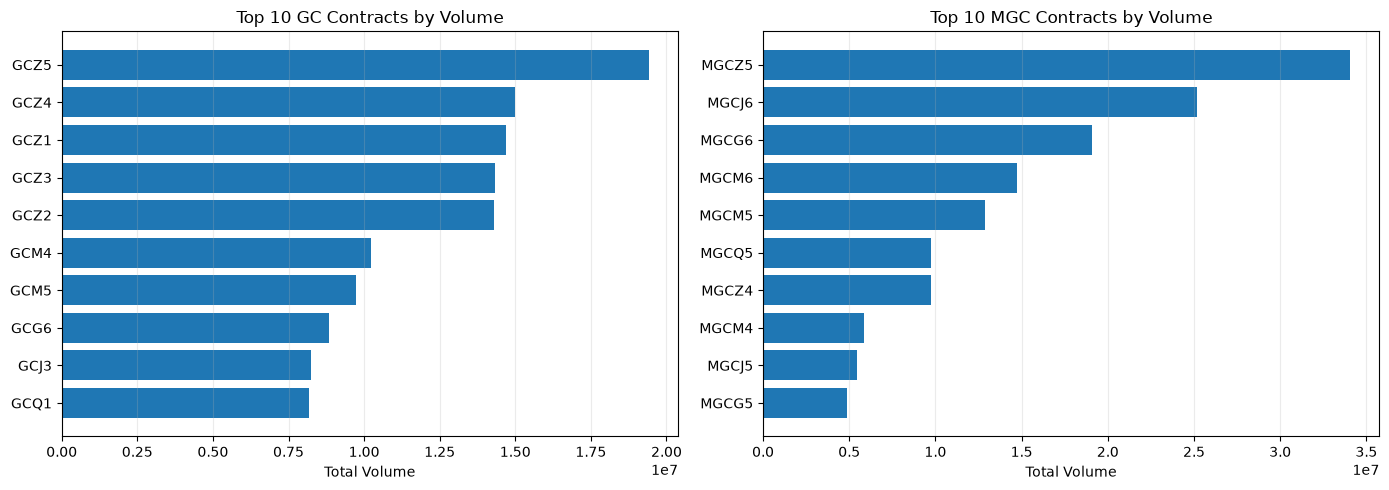

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, product in zip(axes, ["GC", "MGC"]):
    plot_data = (
        liquidity_by_contract[liquidity_by_contract["product"].eq(product)]
        .sort_values("total_volume", ascending=False)
        .head(10)
        .sort_values("total_volume")
    )
    ax.barh(plot_data["symbol"], plot_data["total_volume"])
    ax.set_title(f"Top 10 {product} Contracts by Volume")
    ax.set_xlabel("Total Volume")
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()


### 3.3.2 Daily Volume Evolution


In [43]:
daily_contract_volume = (
    outrights
    .reset_index()
    .assign(trade_date=lambda x: pd.to_datetime(x["ts_event"].dt.date))
    .groupby(["trade_date", "product", "symbol"], observed=True)
    .agg(
        daily_volume=("volume", "sum"),
        bars=("symbol", "size"),
    )
    .reset_index()
)

daily_product_volume = (
    daily_contract_volume
    .groupby(["trade_date", "product"], observed=True)
    .agg(
        daily_volume=("daily_volume", "sum"),
        active_contracts=("symbol", "nunique"),
        bars=("bars", "sum"),
    )
    .reset_index()
    .sort_values(["product", "trade_date"])
)

daily_product_volume["volume_20d_avg"] = (
    daily_product_volume
    .groupby("product", observed=True)["daily_volume"]
    .transform(lambda x: x.rolling(20, min_periods=1).mean())
)

daily_volume_summary = daily_product_volume.groupby("product", observed=True).agg(
    trading_days=("trade_date", "nunique"),
    median_daily_volume=("daily_volume", "median"),
    mean_daily_volume=("daily_volume", "mean"),
    max_daily_volume=("daily_volume", "max"),
    median_active_contracts=("active_contracts", "median"),
    max_active_contracts=("active_contracts", "max"),
)

daily_volume_summary


,trading_days,median_daily_volume,mean_daily_volume,max_daily_volume,median_active_contracts,max_active_contracts
product,,,,,,
GC,1555,156668.0,148465.377492,537850,9.0,22
MGC,1555,58888.0,120028.101608,1536127,7.0,12


In [44]:
daily_product_volume.tail(20)


,trade_date,product,daily_volume,active_contracts,bars,volume_20d_avg
3071,2026-04-30,MGC,325481,8,2568,300066.15
3073,2026-05-01,MGC,275357,8,2352,291781.85
3075,2026-05-03,MGC,17921,4,192,273586.70
3077,2026-05-04,MGC,325505,9,2704,275126.25
3079,2026-05-05,MGC,281983,8,2502,287215.10
3081,2026-05-06,MGC,337540,8,2809,287419.00
3083,2026-05-07,MGC,381228,9,2837,289587.60
3085,2026-05-08,MGC,265146,8,2352,286593.70
3087,2026-05-10,MGC,18936,6,244,272285.40
3089,2026-05-11,MGC,317892,8,2828,270395.45


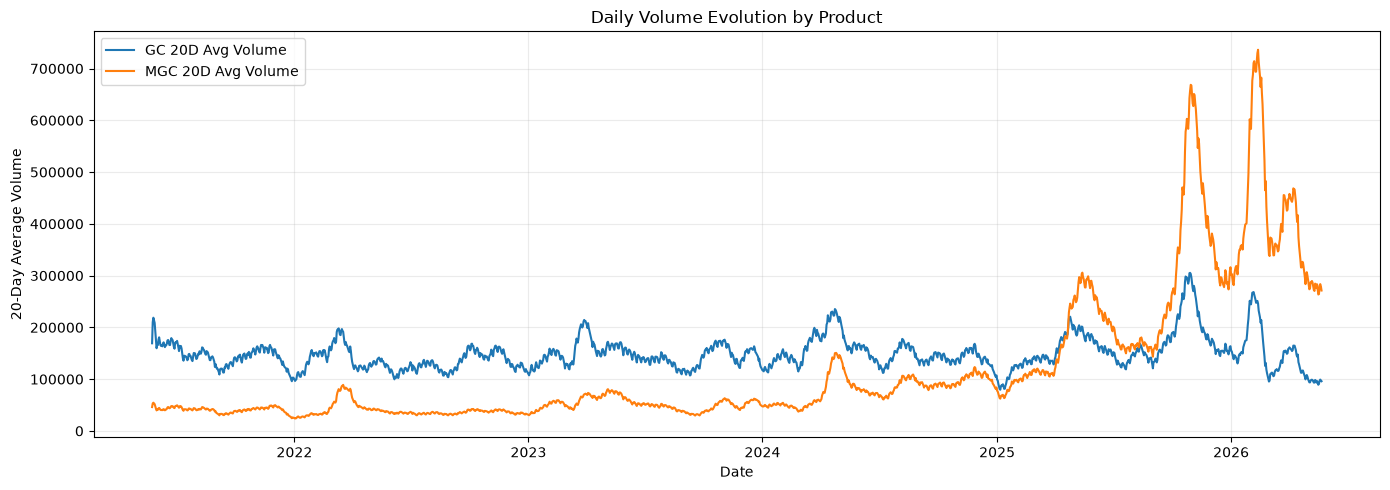

In [45]:
fig, ax = plt.subplots(figsize=(14, 5))

for product, group in daily_product_volume.groupby("product", observed=True):
    ax.plot(group["trade_date"], group["volume_20d_avg"], label=f"{product} 20D Avg Volume")

ax.set_title("Daily Volume Evolution by Product")
ax.set_xlabel("Date")
ax.set_ylabel("20-Day Average Volume")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


### 3.3.3 Contract Dominance Over Time


In [46]:
idx = daily_contract_volume.groupby(["trade_date", "product"], observed=True)["daily_volume"].idxmax()

dominant_contract_by_day = (
    daily_contract_volume
    .loc[idx]
    .rename(columns={"symbol": "dominant_contract", "daily_volume": "dominant_contract_volume"})
    .sort_values(["product", "trade_date"])
    .reset_index(drop=True)
)

dominant_contract_by_day = dominant_contract_by_day.merge(
    daily_product_volume[["trade_date", "product", "daily_volume", "active_contracts"]].rename(columns={"daily_volume": "product_daily_volume"}),
    on=["trade_date", "product"],
    how="left",
)

dominant_contract_by_day["dominant_volume_share"] = (
    dominant_contract_by_day["dominant_contract_volume"]
    / dominant_contract_by_day["product_daily_volume"]
)

dominance_summary = dominant_contract_by_day.groupby("product", observed=True).agg(
    days=("trade_date", "nunique"),
    median_dominant_share=("dominant_volume_share", "median"),
    mean_dominant_share=("dominant_volume_share", "mean"),
    min_dominant_share=("dominant_volume_share", "min"),
    max_dominant_share=("dominant_volume_share", "max"),
)

dominance_summary


,days,median_dominant_share,mean_dominant_share,min_dominant_share,max_dominant_share
product,,,,,
GC,1555,0.970085,0.947532,0.478205,0.995617
MGC,1555,0.975164,0.953860,0.498151,0.998254


In [47]:
dominant_contract_summary = (
    dominant_contract_by_day
    .groupby(["product", "dominant_contract"], observed=True)
    .agg(
        days_dominant=("trade_date", "nunique"),
        first_dominant_day=("trade_date", "min"),
        last_dominant_day=("trade_date", "max"),
        total_volume_while_dominant=("dominant_contract_volume", "sum"),
        avg_dominant_share=("dominant_volume_share", "mean"),
    )
    .reset_index()
    .sort_values(["product", "days_dominant", "total_volume_while_dominant"], ascending=[True, False, False])
)

dominant_contract_summary.groupby("product", observed=True).head(15)


,product,dominant_contract,days_dominant,first_dominant_day,last_dominant_day,total_volume_while_dominant,avg_dominant_share
22,GC,GCZ2,106,2022-07-28,2022-11-28,13938639,0.952950
23,GC,GCZ3,105,2023-07-28,2023-11-27,13847674,0.958700
24,GC,GCZ4,104,2024-07-29,2024-11-26,14623392,0.953257
21,GC,GCZ1,103,2021-07-29,2021-11-25,14293833,0.965540
25,GC,GCZ5,102,2025-07-29,2025-11-24,19117887,0.951425
4,GC,GCG6,55,2025-11-25,2026-01-27,8504688,0.941378
16,GC,GCQ1,55,2021-05-26,2021-07-28,8092084,0.947364
13,GC,GCM4,54,2024-03-26,2024-05-28,9721512,0.949562
3,GC,GCG5,54,2024-11-27,2025-01-28,5661245,0.947371
20,GC,GCQ5,53,2025-05-28,2025-07-28,7184812,0.948498


In [48]:
dominant_contract_by_day.tail(30)


,trade_date,product,dominant_contract,dominant_contract_volume,bars,product_daily_volume,active_contracts,dominant_volume_share
3080,2026-04-19,MGC,MGCM6,40045,120,40741,8,0.982916
3081,2026-04-20,MGC,MGCM6,303735,1380,306682,8,0.990391
3082,2026-04-21,MGC,MGCM6,423537,1380,427950,10,0.989688
3083,2026-04-22,MGC,MGCM6,257382,1380,259934,10,0.990182
3084,2026-04-23,MGC,MGCM6,412505,1380,416532,11,0.990332
3085,2026-04-24,MGC,MGCM6,305165,1260,307835,8,0.991327
3086,2026-04-26,MGC,MGCM6,19390,120,19653,7,0.986618
3087,2026-04-27,MGC,MGCM6,272563,1380,275146,11,0.990612
3088,2026-04-28,MGC,MGCM6,397075,1380,401627,11,0.988666
3089,2026-04-29,MGC,MGCM6,400590,1380,404820,9,0.989551


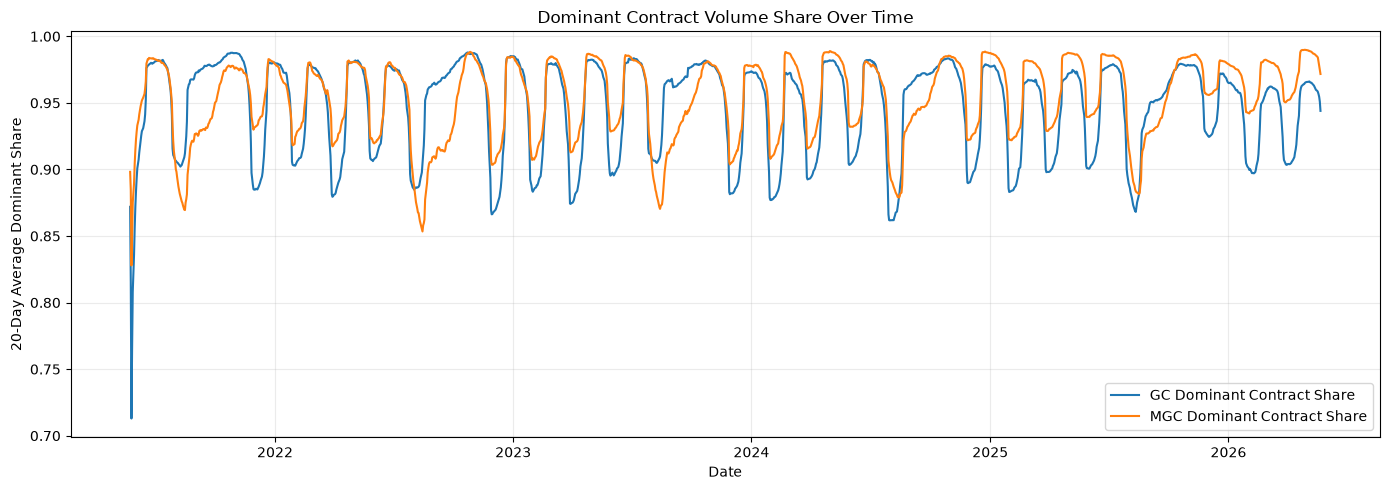

In [49]:
fig, ax = plt.subplots(figsize=(14, 5))

for product, group in dominant_contract_by_day.groupby("product", observed=True):
    rolling_share = group.set_index("trade_date")["dominant_volume_share"].rolling(20, min_periods=1).mean()
    ax.plot(rolling_share.index, rolling_share.values, label=f"{product} Dominant Contract Share")

ax.set_title("Dominant Contract Volume Share Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("20-Day Average Dominant Share")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


### 3.3.4 Liquidity Migration


In [50]:
# Smooth daily contract volume before detecting liquidity migration.
# This avoids treating one-day volume noise as a true rollover/migration event.
rolling_contract_volume = daily_contract_volume.sort_values(["product", "symbol", "trade_date"]).copy()
rolling_contract_volume["rolling_5d_volume"] = (
    rolling_contract_volume
    .groupby(["product", "symbol"], observed=True)["daily_volume"]
    .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

idx = rolling_contract_volume.groupby(["trade_date", "product"], observed=True)["rolling_5d_volume"].idxmax()

rolling_dominant_contract = (
    rolling_contract_volume
    .loc[idx]
    .rename(columns={"symbol": "rolling_dominant_contract"})
    .sort_values(["product", "trade_date"])
    .reset_index(drop=True)
)

rolling_dominant_contract = rolling_dominant_contract.merge(
    daily_product_volume[["trade_date", "product", "daily_volume"]].rename(columns={"daily_volume": "product_daily_volume"}),
    on=["trade_date", "product"],
    how="left",
)
rolling_dominant_contract["daily_volume_share"] = (
    rolling_dominant_contract["daily_volume"] / rolling_dominant_contract["product_daily_volume"]
)

rolling_dominant_contract["previous_dominant_contract"] = (
    rolling_dominant_contract
    .groupby("product", observed=True)["rolling_dominant_contract"]
    .shift(1)
)

liquidity_migration_events = rolling_dominant_contract[
    rolling_dominant_contract["previous_dominant_contract"].notna()
    & rolling_dominant_contract["rolling_dominant_contract"].ne(rolling_dominant_contract["previous_dominant_contract"])
].copy()

liquidity_migration_events[[
    "trade_date",
    "product",
    "previous_dominant_contract",
    "rolling_dominant_contract",
    "daily_volume",
    "rolling_5d_volume",
    "daily_volume_share",
]].tail(30)


,trade_date,product,previous_dominant_contract,rolling_dominant_contract,daily_volume,rolling_5d_volume,daily_volume_share
1248,2025-05-29,GC,GCM5,GCQ5,190324,412295.0,0.943174
1301,2025-07-30,GC,GCQ5,GCZ5,187394,354343.0,0.894277
1404,2025-11-27,GC,GCZ5,GCG6,71513,433240.0,0.969168
1458,2026-01-29,GC,GCG6,GCJ6,503462,1056206.0,0.936064
1509,2026-03-30,GC,GCJ6,GCM6,137009,397149.0,0.937724
1560,2021-05-30,MGC,MGCM1,MGCQ1,640,113150.0,0.962406
1614,2021-08-01,MGC,MGCQ1,MGCZ1,1137,85750.0,0.821532
1718,2021-11-30,MGC,MGCZ1,MGCG2,72984,135677.0,0.983705
1771,2022-02-01,MGC,MGCG2,MGCJ2,27598,110336.0,0.982835
1821,2022-03-31,MGC,MGCJ2,MGCM2,51277,142580.0,0.988968


In [51]:
migration_summary = liquidity_migration_events.groupby("product", observed=True).agg(
    migration_events=("trade_date", "count"),
    first_migration=("trade_date", "min"),
    last_migration=("trade_date", "max"),
)

migration_summary


,migration_events,first_migration,last_migration
product,,,
GC,25,2021-05-28,2026-03-30
MGC,25,2021-05-30,2026-03-31


In [52]:
rolling_dominant_timeline = (
    rolling_dominant_contract
    .assign(month=lambda x: x["trade_date"].dt.strftime("%Y-%m"))
    .groupby(["month", "product", "rolling_dominant_contract"], observed=True)
    .agg(
        days_as_rolling_dominant=("trade_date", "nunique"),
        total_daily_volume=("daily_volume", "sum"),
        avg_daily_volume_share=("daily_volume_share", "mean"),
    )
    .reset_index()
    .sort_values(["product", "month", "days_as_rolling_dominant"], ascending=[True, True, False])
)

rolling_dominant_timeline.tail(40)


,month,product,rolling_dominant_contract,days_as_rolling_dominant,total_daily_volume,avg_daily_volume_share
90,2024-01,MGC,MGCJ4,1,71621,0.987944
92,2024-02,MGC,MGCJ4,25,1023316,0.987298
95,2024-03,MGC,MGCJ4,23,1178005,0.884182
96,2024-03,MGC,MGCM4,2,117949,0.983852
98,2024-04,MGC,MGCM4,26,3571697,0.987944
101,2024-05,MGC,MGCM4,26,2000345,0.911218
102,2024-05,MGC,MGCQ4,1,83417,0.976060
104,2024-06,MGC,MGCQ4,25,1658986,0.979943
107,2024-07,MGC,MGCQ4,26,1870407,0.885661
108,2024-07,MGC,MGCZ4,1,82752,0.891340


### 3.3.5 Preliminary Front-Month Investigation


In [53]:
# First-pass front-month candidate: the contract with the highest rolling 5-day volume per product/date.
# This is a liquidity-based candidate, not yet a finalized rollover rule.
front_month_candidates = rolling_dominant_contract.rename(
    columns={"rolling_dominant_contract": "front_month_candidate"}
).copy()

front_month_summary = (
    front_month_candidates
    .groupby(["product", "front_month_candidate"], observed=True)
    .agg(
        first_candidate_day=("trade_date", "min"),
        last_candidate_day=("trade_date", "max"),
        days_as_candidate=("trade_date", "nunique"),
        total_volume_as_candidate=("daily_volume", "sum"),
        avg_daily_volume_as_candidate=("daily_volume", "mean"),
        avg_volume_share_as_candidate=("daily_volume_share", "mean"),
    )
    .reset_index()
    .sort_values(["product", "first_candidate_day", "front_month_candidate"])
)

front_month_summary.tail(30)


,product,front_month_candidate,first_candidate_day,last_candidate_day,days_as_candidate,total_volume_as_candidate,avg_daily_volume_as_candidate,avg_volume_share_as_candidate
25,GC,GCZ5,2025-07-30,2025-11-26,103,19081594,185258.194175,0.939270
4,GC,GCG6,2025-11-27,2026-01-28,54,8236610,152529.814815,0.930423
9,GC,GCJ6,2026-01-29,2026-03-29,51,7042036,138079.137255,0.903376
15,GC,GCM6,2026-03-30,2026-05-22,46,4616492,100358.521739,0.954174
36,MGC,MGCM1,2021-05-24,2021-05-28,5,138775,27755.000000,0.513202
42,MGC,MGCQ1,2021-05-30,2021-07-30,54,2157268,39949.407407,0.929199
47,MGC,MGCZ1,2021-08-01,2021-11-29,104,3944108,37924.115385,0.928489
26,MGC,MGCG2,2021-11-30,2022-01-31,53,1487866,28072.943396,0.903796
31,MGC,MGCJ2,2022-02-01,2022-03-30,50,2840271,56805.420000,0.933413
37,MGC,MGCM2,2022-03-31,2022-05-29,50,1842892,36857.840000,0.925406


In [54]:
front_month_recent_timeline = front_month_candidates[[
    "trade_date",
    "product",
    "front_month_candidate",
    "daily_volume",
    "rolling_5d_volume",
    "daily_volume_share",
]].tail(60)

front_month_recent_timeline


,trade_date,product,front_month_candidate,daily_volume,rolling_5d_volume,daily_volume_share
3050,2026-03-13,MGC,MGCJ6,321393,1704096.0,0.973898
3051,2026-03-15,MGC,MGCJ6,45897,1348392.0,0.963980
3052,2026-03-16,MGC,MGCJ6,405199,1409504.0,0.976021
3053,2026-03-17,MGC,MGCJ6,299151,1408154.0,0.975164
3054,2026-03-18,MGC,MGCJ6,508116,1579756.0,0.963259
3055,2026-03-19,MGC,MGCJ6,766879,2025242.0,0.957732
3056,2026-03-20,MGC,MGCJ6,609534,2588879.0,0.956040
3057,2026-03-22,MGC,MGCJ6,59749,2243429.0,0.935698
3058,2026-03-23,MGC,MGCJ6,1068207,3012485.0,0.929468
3059,2026-03-24,MGC,MGCJ6,665403,3169772.0,0.936345


In [55]:
front_month_quality = front_month_candidates.groupby("product", observed=True).agg(
    days=("trade_date", "nunique"),
    median_candidate_volume_share=("daily_volume_share", "median"),
    mean_candidate_volume_share=("daily_volume_share", "mean"),
    min_candidate_volume_share=("daily_volume_share", "min"),
    max_candidate_volume_share=("daily_volume_share", "max"),
)

front_month_quality


,days,median_candidate_volume_share,mean_candidate_volume_share,min_candidate_volume_share,max_candidate_volume_share
product,,,,,
GC,1555,0.970085,0.933524,0.002874,0.995617
MGC,1555,0.974926,0.931605,0.002777,0.998254


**3.3 Liquidity Analysis Notes**

* `liquidity_by_contract` ranks contracts by total observed volume.
* `daily_product_volume` tracks GC/MGC volume through time.
* `dominant_contract_by_day` identifies the single highest-volume contract each day.
* `rolling_dominant_contract` smooths dominance using 5-day rolling volume to reduce one-day noise.
* `front_month_candidates` is the first liquidity-based approximation of a front-month series.

**Next:** 3.4 Session Analysis.


## Liquidity Analysis Report

**3.3 Liquidity Analysis**

**3.3.1 Volume by Contract**

**Results**

For **GC**, the highest-volume contracts are primarily December delivery contracts:

* GCZ5
* GCZ4
* GCZ1
* GCZ3
* GCZ2

The largest GC contract is:

```text
Contract:      GCZ5
Total Volume:  19,414,779
Bars:          158,853
Volume Share:  8.41%
```

For **MGC**, the highest-volume contracts are:

* MGCZ5
* MGCJ6
* MGCG6
* MGCM6
* MGCM5

The largest MGC contract is:

```text
Contract:      MGCZ5
Total Volume:  34,056,711
Bars:          144,900
Volume Share:  18.25%
```

The concentration of liquidity differs between the two products:

```text
Top 5 GC Contracts:  33.7% of total GC outright volume
Top 5 MGC Contracts: 56.7% of total MGC outright volume
```

**Conclusion**

Liquidity is highly concentrated in a relatively small number of contracts. MGC exhibits an even greater concentration of trading activity than GC, indicating that only a handful of contracts account for the majority of market participation. Consequently, not all listed contracts should be treated equally during strategy development.

---

**3.3.2 Daily Volume Evolution**

**Results**

```text
GC
Median Daily Volume: 156,668
Mean Daily Volume:   148,465
Maximum Volume:      537,850

MGC
Median Daily Volume:  58,888
Mean Daily Volume:   120,028
Maximum Volume:    1,536,127
```

Typical daily contract activity:

```text
GC Median Active Contracts Per Day:  9
MGC Median Active Contracts Per Day: 7
```

GC demonstrates higher typical daily liquidity, while MGC experiences substantially larger volume spikes during periods of elevated market activity.

Although several contracts are active on any given day, trading volume remains highly concentrated in only one or two contracts.

**Conclusion**

Contract activity alone is not a reliable indicator of liquidity. Most trading occurs within a small subset of active contracts, reinforcing the need for liquidity-based contract selection rather than simply considering every active contract.

---

**3.3.3 Contract Dominance Over Time**

**Results**

```text
GC
Median Dominant Share: 97.0%
Mean Dominant Share:   94.8%

MGC
Median Dominant Share: 97.5%
Mean Dominant Share:   95.4%
```

Representative dominant contracts include:

* GCZ1
* GCZ2
* GCZ3
* GCZ4
* GCZ5

and

* MGCZ1
* MGCZ2
* MGCZ3
* MGCZ4
* MGCZ5

Each dominant contract remains the primary source of liquidity for approximately one hundred days before liquidity migrates to the next active delivery month.

**Conclusion**

One contract typically accounts for approximately **95–97%** of total daily trading volume. This strongly supports constructing a continuous futures series based on the dominant contract rather than combining observations from all listed contracts.

---

**3.3.4 Liquidity Migration**

**Results**

```text
GC Migration Events:  25
MGC Migration Events: 25
```

Using a rolling five-day volume measure, liquidity transitions follow the expected delivery sequence.

Recent GC migrations include:

```text
GCM5 → GCQ5
GCQ5 → GCZ5
GCZ5 → GCG6
GCG6 → GCJ6
GCJ6 → GCM6
```

Recent MGC migrations include:

```text
MGCQ5 → MGCZ5
MGCZ5 → MGCG6
MGCG6 → MGCJ6
MGCJ6 → MGCM6
```

The rolling five-day approach reduces temporary one-day fluctuations and produces a more stable identification of contract rollovers.

**Conclusion**

Liquidity migration follows the expected futures delivery cycle rather than occurring randomly. A rolling-volume approach provides a strong foundation for identifying rollover points during continuous futures construction.

---

**3.3.5 Preliminary Front-Month Investigation**

The preliminary front-month candidate is defined as:

> The contract with the highest rolling five-day trading volume for each product and trading day.

Recent MGC front-month candidates transitioned from:

```text
MGCJ6 → MGCM6
```

with the rollover occurring approximately on:

```text
2026-03-31
```

**Front-Month Quality Summary**

```text
GC
Median Candidate Share: 97.0%
Mean Candidate Share:   93.4%
Minimum Share:           0.29%

MGC
Median Candidate Share: 97.5%
Mean Candidate Share:   93.2%
Minimum Share:           0.28%
```

The high median values indicate that the rolling-volume method successfully identifies the dominant trading contract in most cases.

The very low minimum values likely occur during rollover periods, exchange holidays, shortened trading sessions, or situations where the five-day rolling winner differs from the highest-volume contract on the current day.

**Conclusion**

The rolling five-day volume method provides an effective starting point for front-month identification. However, additional rollover safeguards should be incorporated before adopting it as the final methodology for constructing a continuous futures series.

---

**3.3.6 Summary**

**Key Findings**

```text
Top 5 GC Contracts:
33.7% of total outright volume

Top 5 MGC Contracts:
56.7% of total outright volume

Median Dominant Contract Share:
GC:  97.0%
MGC: 97.5%

Observed Liquidity Migrations:
GC:  25
MGC: 25

Primary Delivery Cycle:
G → J → M → Q → Z
```

**Overall Assessment**

The liquidity characteristics of both GC and MGC are well defined. Although numerous contracts trade simultaneously, market activity is overwhelmingly concentrated in a single dominant contract on most trading days. Liquidity then migrates systematically through the standard major delivery cycle rather than switching randomly between contracts.

These findings provide strong evidence that the next stage of the research should focus on constructing a robust front-month series based on observed liquidity migration rather than predetermined calendar roll dates.

The recommended workflow for subsequent strategy development is:

1. Restrict analysis to outright contracts.
2. Focus primarily on the major delivery months (G, J, M, Q, Z).
3. Construct a liquidity-based front-month series.
4. Incorporate rollover safeguards to improve continuity.
5. Proceed with session analysis, volatility analysis, return modelling, and signal research using the resulting continuous dataset.


## 3.4 Session Analysis


This section studies how liquidity and volatility behave across the trading day.

To avoid multi-contract distortion, the analysis uses the preliminary liquidity-based front-month candidate from 3.3: one active contract per product per date.


### 3.4.1 Volume by Hour


In [56]:
# Build an active/front-contract dataset from the 3.3 liquidity-based candidate.
# This keeps one selected contract per product/date for session analysis.
# Engineering note: keep this dataframe narrow; the full outright table is several million rows.
import time

_t0 = time.perf_counter()

active_contract_keys = (
    front_month_candidates[["trade_date", "product", "front_month_candidate"]]
    .rename(columns={"front_month_candidate": "symbol"})
)

active_front_source = outrights[[
    "product",
    "symbol",
    "open",
    "high",
    "low",
    "close",
    "volume",
]].reset_index()

# Match 3.3's UTC trade_date definition without using slower object-date conversion.
active_front_source["trade_date"] = active_front_source["ts_event"].dt.tz_convert(None).dt.normalize().astype("datetime64[s]")

active_front = active_front_source.merge(
    active_contract_keys,
    on=["trade_date", "product", "symbol"],
    how="inner",
).sort_values(["product", "symbol", "ts_event"], ignore_index=True)

active_front["front_month_candidate"] = active_front["symbol"]
active_front["ts_ny"] = active_front["ts_event"].dt.tz_convert("America/New_York")
active_front["hour_ny"] = active_front["ts_ny"].dt.hour
active_front["minute_ny"] = active_front["ts_ny"].dt.minute
active_front["minute_of_day_ny"] = active_front["hour_ny"] * 60 + active_front["minute_ny"]
active_front["trade_date_ny"] = active_front["ts_ny"].dt.tz_localize(None).dt.normalize().astype("datetime64[s]")

active_front_build_seconds = time.perf_counter() - _t0

active_front_shape = pd.Series({
    "rows": len(active_front),
    "products": active_front["product"].nunique(),
    "symbols": active_front["symbol"].nunique(),
    "start_utc": active_front["ts_event"].min(),
    "end_utc": active_front["ts_event"].max(),
    "build_seconds": round(active_front_build_seconds, 2),
})

active_front_shape


rows                               3493667
products                                 2
symbols                                 52
start_utc        2021-05-24 00:00:00+00:00
end_utc          2026-05-22 20:59:00+00:00
build_seconds                          2.9
dtype: object

In [57]:
hourly_volume = (
    active_front
    .groupby(["product", "hour_ny"], observed=True)
    .agg(
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
        avg_volume_per_bar=("volume", "mean"),
        median_volume_per_bar=("volume", "median"),
    )
    .reset_index()
)

hourly_volume["product_volume_share"] = (
    hourly_volume["total_volume"]
    / hourly_volume.groupby("product")["total_volume"].transform("sum")
)

hourly_volume


,product,hour_ny,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,product_volume_share
0,GC,0,76835,3766269,49.017622,28.0,0.017489
1,GC,1,77106,5285640,68.550307,43.0,0.024544
2,GC,2,77213,7589365,98.291285,69.0,0.035242
3,GC,3,77266,8937986,115.678125,82.0,0.041504
4,GC,4,77227,8036175,104.059137,71.0,0.037317
5,GC,5,77188,7204894,93.342152,62.0,0.033457
6,GC,6,77190,6931997,89.804340,59.0,0.032189
7,GC,7,77185,8513651,110.301885,76.0,0.039534
8,GC,8,77323,22635009,292.733197,190.0,0.105108
9,GC,9,77369,26766568,345.959855,261.0,0.124293


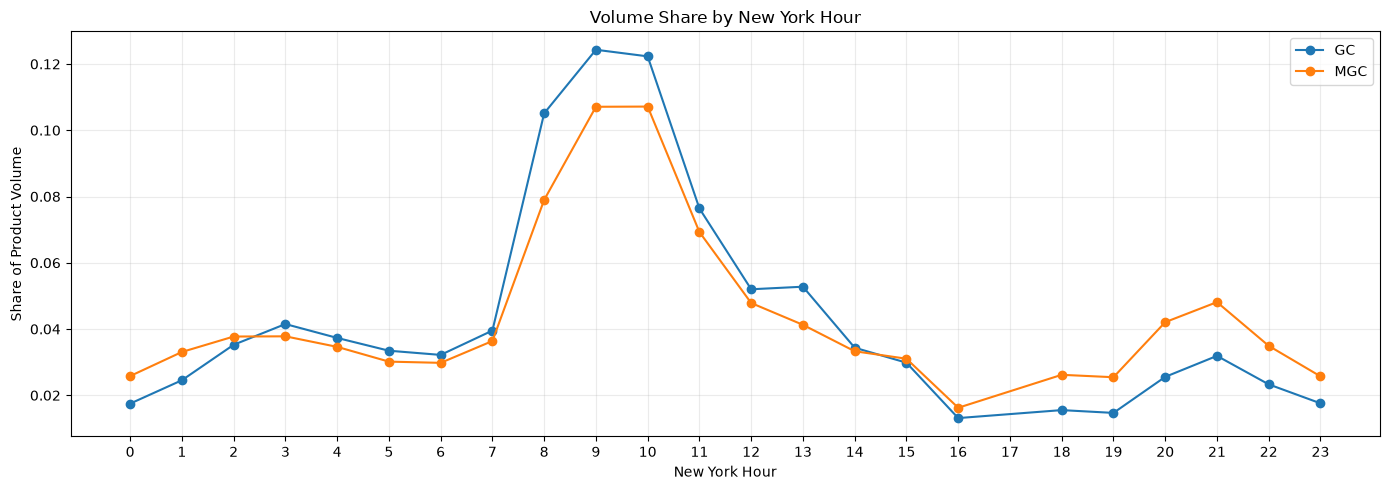

In [58]:
fig, ax = plt.subplots(figsize=(14, 5))

for product, group in hourly_volume.groupby("product", observed=True):
    ax.plot(group["hour_ny"], group["product_volume_share"], marker="o", label=product)

ax.set_title("Volume Share by New York Hour")
ax.set_xlabel("New York Hour")
ax.set_ylabel("Share of Product Volume")
ax.set_xticks(range(24))
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


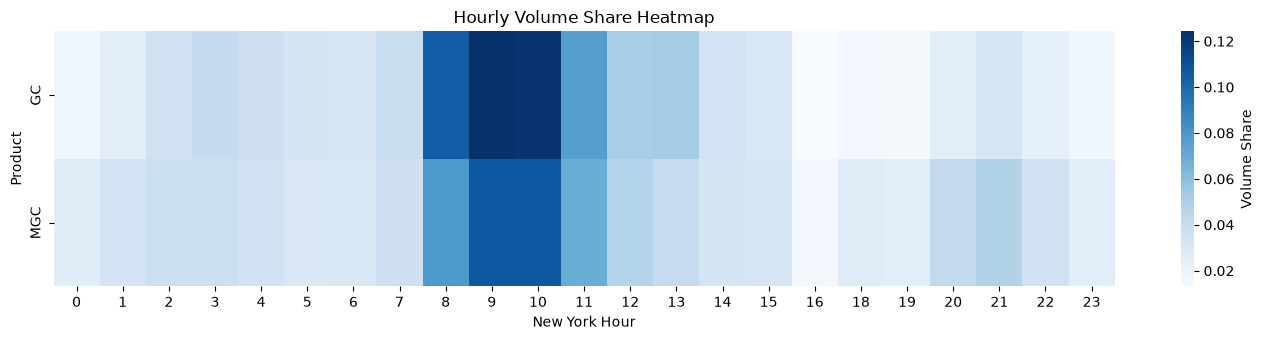

In [59]:
hourly_volume_pivot = hourly_volume.pivot(index="product", columns="hour_ny", values="product_volume_share")

plt.figure(figsize=(14, 3.5))
sns.heatmap(hourly_volume_pivot, cmap="Blues", annot=False, cbar_kws={"label": "Volume Share"})
plt.title("Hourly Volume Share Heatmap")
plt.xlabel("New York Hour")
plt.ylabel("Product")
plt.tight_layout()


### 3.4.2 Volatility by Hour


In [60]:
import time

_t0 = time.perf_counter()

# Compute log(close) once, then use groupby.diff. This avoids running np.log inside
# every group and preserves the same per-contract return logic.
active_front["log_close"] = np.log(active_front["close"])
active_front["log_return"] = (
    active_front
    .groupby(["product", "symbol"], observed=True, sort=False)["log_close"]
    .diff()
)
active_front["abs_log_return"] = active_front["log_return"].abs()
active_front["squared_log_return"] = active_front["log_return"] ** 2
active_front.drop(columns="log_close", inplace=True)

hourly_volatility = (
    active_front
    .dropna(subset=["log_return"])
    .groupby(["product", "hour_ny"], observed=True)
    .agg(
        observations=("log_return", "size"),
        mean_abs_log_return=("abs_log_return", "mean"),
        median_abs_log_return=("abs_log_return", "median"),
        return_std=("log_return", "std"),
        realized_variance=("squared_log_return", "sum"),
    )
    .reset_index()
)

hourly_volatility["realized_vol"] = np.sqrt(hourly_volatility["realized_variance"])
hourly_volatility_build_seconds = time.perf_counter() - _t0

print(f"Built hourly_volatility in {hourly_volatility_build_seconds:.2f} seconds")
hourly_volatility


Built hourly_volatility in 1.31 seconds


,product,hour_ny,observations,mean_abs_log_return,median_abs_log_return,return_std,realized_variance,realized_vol
0,GC,0,76835,0.000124,0.000085,0.000204,0.003201,0.056577
1,GC,1,77106,0.000155,0.000108,0.000250,0.004832,0.069515
2,GC,2,77213,0.000181,0.000127,0.000269,0.005585,0.074731
3,GC,3,77266,0.000194,0.000147,0.000287,0.006368,0.079800
4,GC,4,77227,0.000180,0.000120,0.000276,0.005891,0.076752
5,GC,5,77188,0.000162,0.000112,0.000244,0.004584,0.067708
6,GC,6,77190,0.000161,0.000111,0.000249,0.004768,0.069051
7,GC,7,77185,0.000178,0.000119,0.000284,0.006214,0.078832
8,GC,8,77323,0.000295,0.000206,0.000461,0.016441,0.128222
9,GC,9,77369,0.000328,0.000240,0.000467,0.016875,0.129903


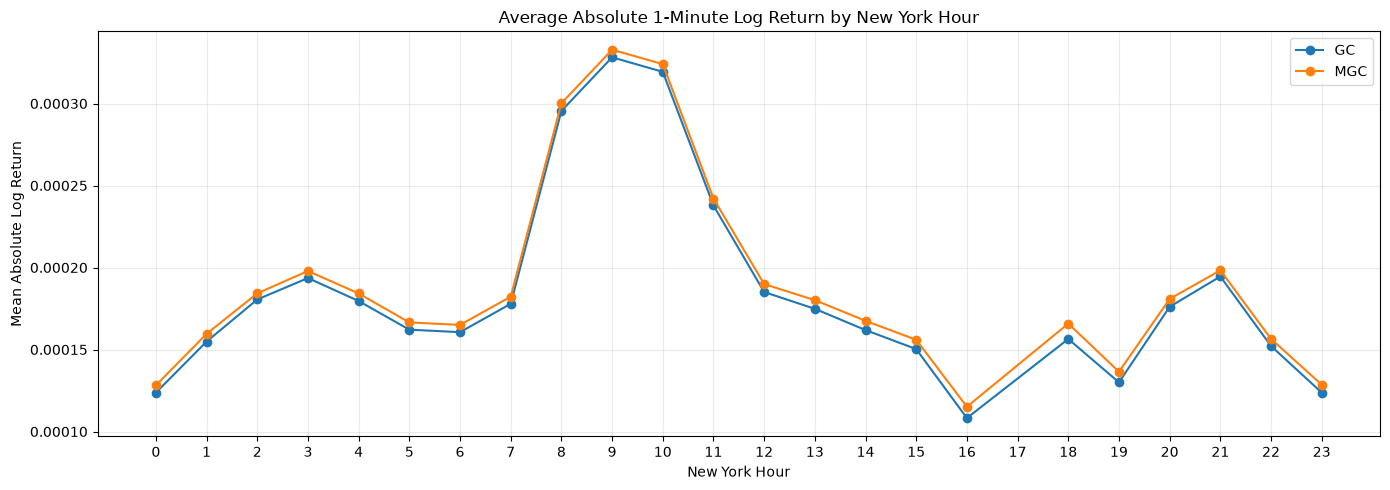

In [61]:
fig, ax = plt.subplots(figsize=(14, 5))

for product, group in hourly_volatility.groupby("product", observed=True):
    ax.plot(group["hour_ny"], group["mean_abs_log_return"], marker="o", label=product)

ax.set_title("Average Absolute 1-Minute Log Return by New York Hour")
ax.set_xlabel("New York Hour")
ax.set_ylabel("Mean Absolute Log Return")
ax.set_xticks(range(24))
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


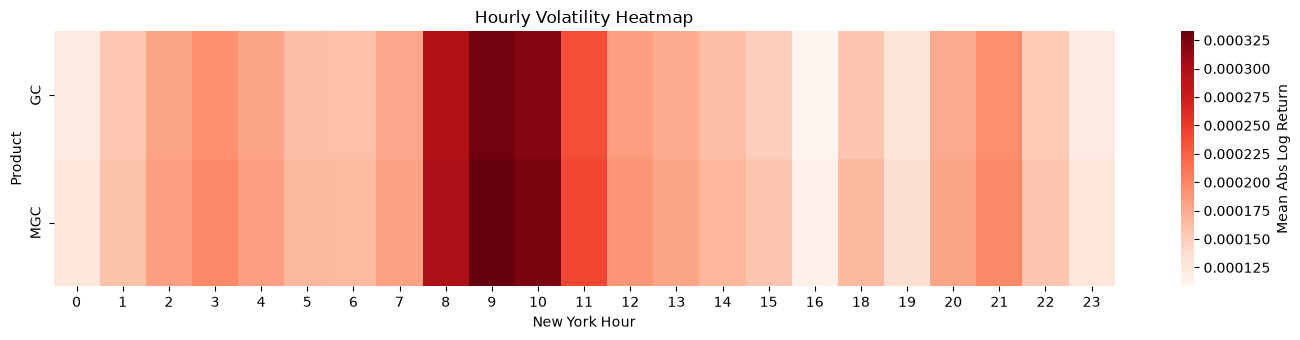

In [62]:
vol_heatmap = hourly_volatility.pivot(index="product", columns="hour_ny", values="mean_abs_log_return")

plt.figure(figsize=(14, 3.5))
sns.heatmap(vol_heatmap, cmap="Reds", annot=False, cbar_kws={"label": "Mean Abs Log Return"})
plt.title("Hourly Volatility Heatmap")
plt.xlabel("New York Hour")
plt.ylabel("Product")
plt.tight_layout()


### 3.4.3 London Session Behavior


In [63]:
import time

_t0 = time.perf_counter()

minute_of_day = active_front["minute_of_day_ny"]
session_order = ["Overnight/Asia", "London", "New York", "Post-NY", "Maintenance/Other"]

active_front["session"] = np.select(
    [
        minute_of_day.between(3 * 60, 8 * 60 + 19),
        minute_of_day.between(8 * 60 + 20, 13 * 60 + 29),
        minute_of_day.between(13 * 60 + 30, 17 * 60 - 1),
        (minute_of_day >= 18 * 60) | (minute_of_day < 3 * 60),
    ],
    ["London", "New York", "Post-NY", "Overnight/Asia"],
    default="Maintenance/Other",
)
active_front["session"] = pd.Categorical(active_front["session"], categories=session_order, ordered=True)

session_label_seconds = time.perf_counter() - _t0

london = active_front.loc[active_front["session"].eq("London")]

london_summary = london.dropna(subset=["log_return"]).groupby("product", observed=True).agg(
    bars=("symbol", "size"),
    total_volume=("volume", "sum"),
    avg_volume_per_bar=("volume", "mean"),
    median_volume_per_bar=("volume", "median"),
    mean_abs_log_return=("abs_log_return", "mean"),
    realized_variance=("squared_log_return", "sum"),
)
london_summary["realized_vol"] = np.sqrt(london_summary["realized_variance"])

print(f"Labeled sessions in {session_label_seconds:.2f} seconds")
london_summary


Labeled sessions in 1.23 seconds


,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,mean_abs_log_return,realized_variance,realized_vol
product,,,,,,,
GC,411823,44408273,107.833397,73.0,0.000179,0.031076,0.176284
MGC,406255,33018991,81.276516,36.0,0.000183,0.031771,0.178244


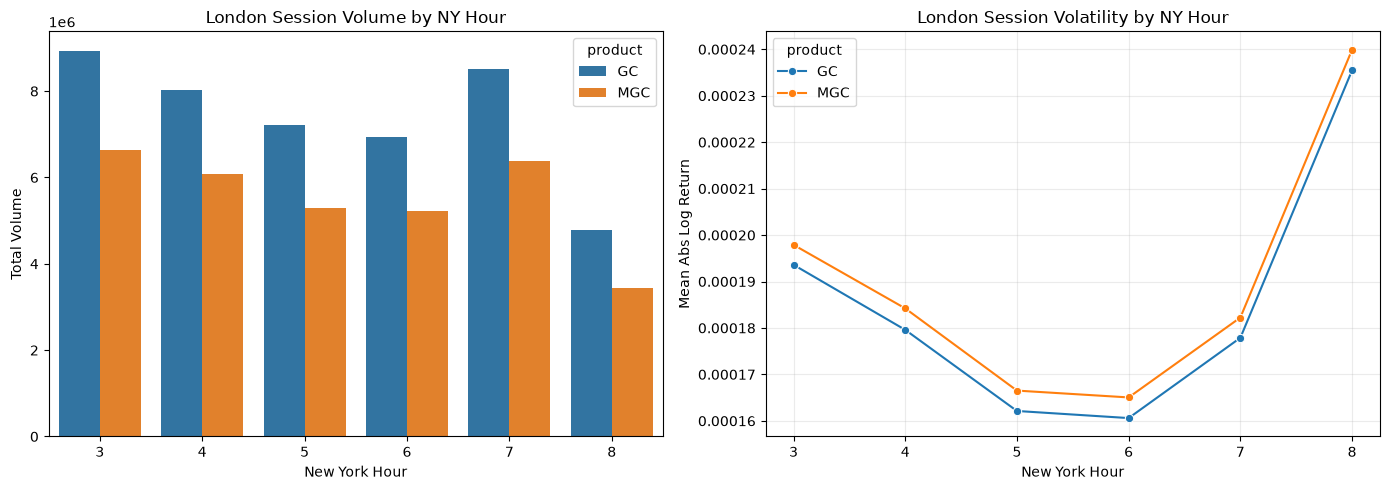

In [64]:
london_hourly = (
    london
    .dropna(subset=["log_return"])
    .groupby(["product", "hour_ny"], observed=True)
    .agg(
        total_volume=("volume", "sum"),
        mean_abs_log_return=("abs_log_return", "mean"),
        bars=("symbol", "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=london_hourly, x="hour_ny", y="total_volume", hue="product", ax=axes[0])
axes[0].set_title("London Session Volume by NY Hour")
axes[0].set_xlabel("New York Hour")
axes[0].set_ylabel("Total Volume")

sns.lineplot(data=london_hourly, x="hour_ny", y="mean_abs_log_return", hue="product", marker="o", ax=axes[1])
axes[1].set_title("London Session Volatility by NY Hour")
axes[1].set_xlabel("New York Hour")
axes[1].set_ylabel("Mean Abs Log Return")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.4.4 New York Session Behavior


In [65]:
new_york = active_front.loc[active_front["session"].eq("New York")]

new_york_summary = new_york.dropna(subset=["log_return"]).groupby("product", observed=True).agg(
    bars=("symbol", "size"),
    total_volume=("volume", "sum"),
    avg_volume_per_bar=("volume", "mean"),
    median_volume_per_bar=("volume", "median"),
    mean_abs_log_return=("abs_log_return", "mean"),
    realized_variance=("squared_log_return", "sum"),
)
new_york_summary["realized_vol"] = np.sqrt(new_york_summary["realized_variance"])

new_york_summary


,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,mean_abs_log_return,realized_variance,realized_vol
product,,,,,,,
GC,399189,105645308,264.649848,177.0,0.000267,0.067304,0.259430
MGC,396281,72554448,183.088384,86.0,0.000272,0.068771,0.262242


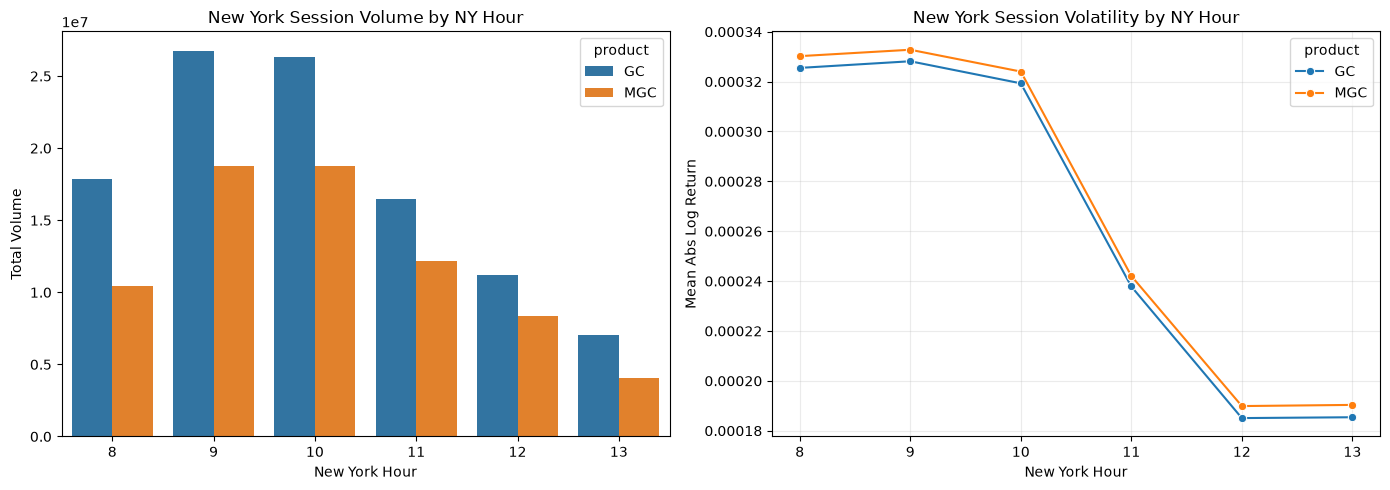

In [66]:
new_york_hourly = (
    new_york
    .dropna(subset=["log_return"])
    .groupby(["product", "hour_ny"], observed=True)
    .agg(
        total_volume=("volume", "sum"),
        mean_abs_log_return=("abs_log_return", "mean"),
        bars=("symbol", "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=new_york_hourly, x="hour_ny", y="total_volume", hue="product", ax=axes[0])
axes[0].set_title("New York Session Volume by NY Hour")
axes[0].set_xlabel("New York Hour")
axes[0].set_ylabel("Total Volume")

sns.lineplot(data=new_york_hourly, x="hour_ny", y="mean_abs_log_return", hue="product", marker="o", ax=axes[1])
axes[1].set_title("New York Session Volatility by NY Hour")
axes[1].set_xlabel("New York Hour")
axes[1].set_ylabel("Mean Abs Log Return")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.4.5 Session Comparison


In [67]:
session_summary = (
    active_front
    .dropna(subset=["log_return"])
    .groupby(["product", "session"], observed=True)
    .agg(
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
        avg_volume_per_bar=("volume", "mean"),
        median_volume_per_bar=("volume", "median"),
        mean_abs_log_return=("abs_log_return", "mean"),
        realized_variance=("squared_log_return", "sum"),
    )
    .reset_index()
)

session_summary["realized_vol"] = np.sqrt(session_summary["realized_variance"])
session_summary["volume_share"] = (
    session_summary["total_volume"]
    / session_summary.groupby("product", observed=True)["total_volume"].transform("sum")
)
session_summary["realized_variance_share"] = (
    session_summary["realized_variance"]
    / session_summary.groupby("product", observed=True)["realized_variance"].transform("sum")
)

session_summary


,product,session,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,mean_abs_log_return,realized_variance,realized_vol,volume_share,realized_variance_share
0,GC,Overnight/Asia,690083,44320082,64.224277,37.0,0.000155,0.052297,0.228685,0.205808,0.313043
1,GC,London,411823,44408273,107.833397,73.0,0.000179,0.031076,0.176284,0.206217,0.186018
2,GC,New York,399189,105645308,264.649848,177.0,0.000267,0.067304,0.259430,0.490582,0.402874
3,GC,Post-NY,262034,20973196,80.039980,47.0,0.000144,0.016383,0.127995,0.097393,0.098065
4,MGC,Overnight/Asia,672535,52430329,77.959257,23.0,0.000160,0.052736,0.229643,0.299066,0.309346
5,MGC,London,406255,33018991,81.276516,36.0,0.000183,0.031771,0.178244,0.188342,0.186367
6,MGC,New York,396281,72554448,183.088384,86.0,0.000272,0.068771,0.262242,0.413855,0.403406
7,MGC,Post-NY,255415,17309988,67.772010,24.0,0.000150,0.017198,0.131140,0.098737,0.100881


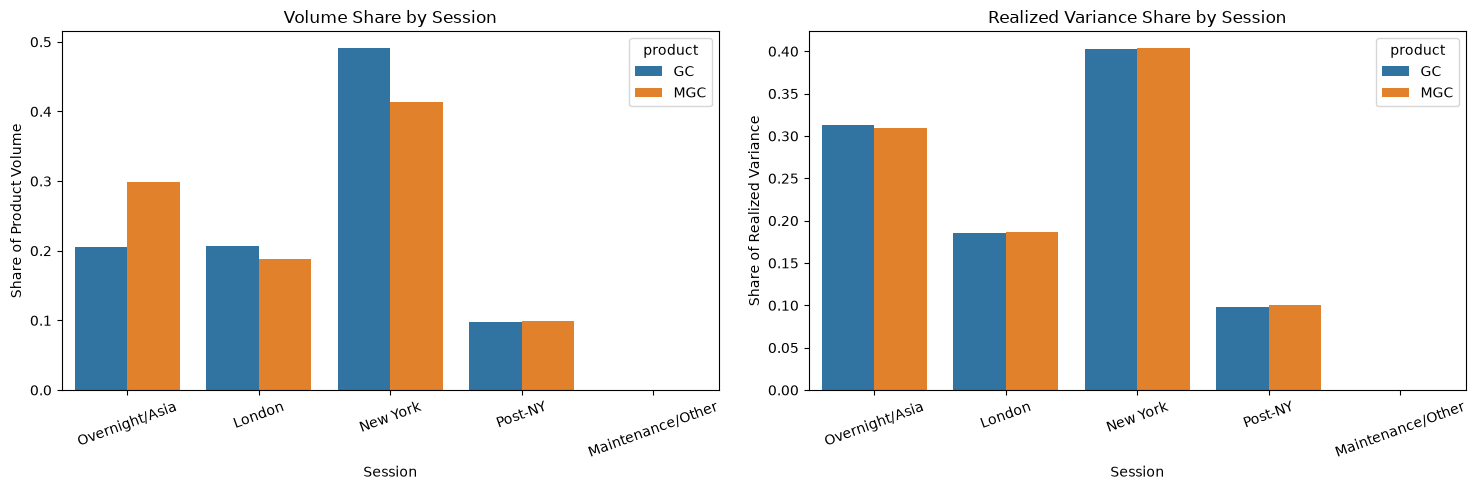

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=session_summary, x="session", y="volume_share", hue="product", ax=axes[0])
axes[0].set_title("Volume Share by Session")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Share of Product Volume")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=session_summary, x="session", y="realized_variance_share", hue="product", ax=axes[1])
axes[1].set_title("Realized Variance Share by Session")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Share of Realized Variance")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


d:\Projects\sidegig\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
d:\Projects\sidegig\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
d:\Projects\sidegig\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
d:\Projects\sidegig\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'hori

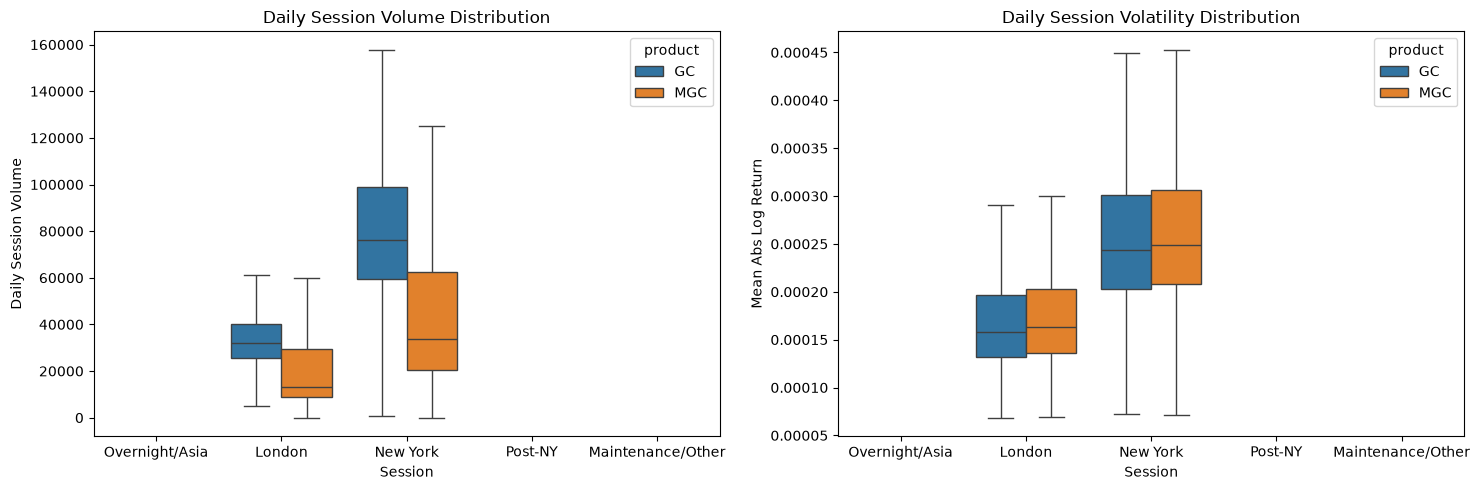

In [69]:
daily_session = (
    active_front
    .dropna(subset=["log_return"])
    .groupby(["trade_date_ny", "product", "session"], observed=True)
    .agg(
        session_volume=("volume", "sum"),
        realized_variance=("squared_log_return", "sum"),
        mean_abs_log_return=("abs_log_return", "mean"),
        bars=("symbol", "size"),
    )
    .reset_index()
)

daily_session_focus = daily_session[daily_session["session"].isin(["London", "New York"])]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=daily_session_focus, x="session", y="session_volume", hue="product", ax=axes[0], showfliers=False)
axes[0].set_title("Daily Session Volume Distribution")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Daily Session Volume")

sns.boxplot(data=daily_session_focus, x="session", y="mean_abs_log_return", hue="product", ax=axes[1], showfliers=False)
axes[1].set_title("Daily Session Volatility Distribution")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Mean Abs Log Return")

plt.tight_layout()


**3.4 Session Analysis Notes**

* Session analysis uses the liquidity-selected active/front contract, not the full multi-contract dataset.
* Timestamps are converted from UTC to `America/New_York` for session labels.
* London is defined as 03:00-08:19 NY time.
* New York is defined as 08:20-13:29 NY time.
* Post-NY is defined as 13:30-16:59 NY time.
* Overnight/Asia is defined as 18:00-02:59 NY time.

**Next:** 3.5 Volatility Analysis.


## 3.5 Volatility Analysis


This section studies volatility using the liquidity-selected active/front contract series created in 3.4.

The goal is to understand return dispersion, intraday volatility structure, daily realized volatility, volatility regimes, and volatility clustering before moving into signal design.


### 3.5.1 Return Distribution


In [70]:
import time

_t0 = time.perf_counter()
print("Starting 3.5.1 return distribution build...")

# 3.5 is designed to run after 3.4. Rebuild return columns only if needed.
required_return_cols = {"log_return", "abs_log_return", "squared_log_return"}
if not required_return_cols.issubset(active_front.columns):
    print("Return columns missing; rebuilding from active_front close prices...")
    active_front["log_close"] = np.log(active_front["close"])
    active_front["log_return"] = (
        active_front
        .groupby(["product", "symbol"], observed=True, sort=False)["log_close"]
        .diff()
    )
    active_front["abs_log_return"] = active_front["log_return"].abs()
    active_front["squared_log_return"] = active_front["log_return"] ** 2
    active_front.drop(columns="log_close", inplace=True)
else:
    print("Reusing existing return columns from 3.4.")

return_cols = [
    "ts_event",
    "trade_date_ny",
    "product",
    "symbol",
    "session",
    "hour_ny",
    "minute_ny",
    "volume",
    "log_return",
    "abs_log_return",
    "squared_log_return",
]

returns = active_front.loc[active_front["log_return"].notna(), return_cols].copy()
returns["return_bps"] = returns["log_return"].to_numpy() * 10_000
returns["abs_return_bps"] = returns["abs_log_return"].to_numpy() * 10_000

print(f"Prepared returns dataframe: {len(returns):,} rows in {time.perf_counter() - _t0:.2f}s")

summary_rows = []
for product, product_returns in returns.groupby("product", observed=True, sort=False):
    values = product_returns["return_bps"].to_numpy(dtype="float64", copy=False)
    abs_values = np.abs(values)
    q01, q05, q95, q99 = np.quantile(values, [0.01, 0.05, 0.95, 0.99])
    mean = values.mean()
    std = values.std(ddof=1)
    centered = values - mean
    m2 = np.mean(centered ** 2)
    m3 = np.mean(centered ** 3)
    m4 = np.mean(centered ** 4)
    skewness = m3 / (m2 ** 1.5)
    excess_kurtosis = m4 / (m2 ** 2) - 3

    summary_rows.append({
        "product": product,
        "observations": len(values),
        "mean_bps": mean,
        "median_bps": np.median(values),
        "std_bps": std,
        "skewness": skewness,
        "min_bps": values.min(),
        "q01_bps": q01,
        "q05_bps": q05,
        "q95_bps": q95,
        "q99_bps": q99,
        "max_bps": values.max(),
        "excess_kurtosis": excess_kurtosis,
        "mean_abs_bps": abs_values.mean(),
    })

return_distribution_summary = pd.DataFrame(summary_rows).set_index("product")

return_distribution_seconds = time.perf_counter() - _t0
print(f"Built return distribution summary in {return_distribution_seconds:.2f} seconds")
return_distribution_summary


Starting 3.5.1 return distribution build...
Reusing existing return columns from 3.4.
Prepared returns dataframe: 3,493,615 rows in 0.50s
Built return distribution summary in 1.12 seconds


,observations,mean_bps,median_bps,std_bps,skewness,min_bps,q01_bps,q05_bps,q95_bps,q99_bps,max_bps,excess_kurtosis,mean_abs_bps
product,,,,,,,,,,,,,
GC,1763129,0.003799,0.0,3.078175,-1.058388,-243.706725,-8.360565,-4.069116,4.108886,8.282637,179.325275,120.742241,1.841467
MGC,1730486,0.003905,0.0,3.138676,-1.071726,-254.099241,-8.476337,-4.161743,4.187944,8.369966,174.017704,126.304638,1.895972


Built precomputed return histogram in 0.32 seconds


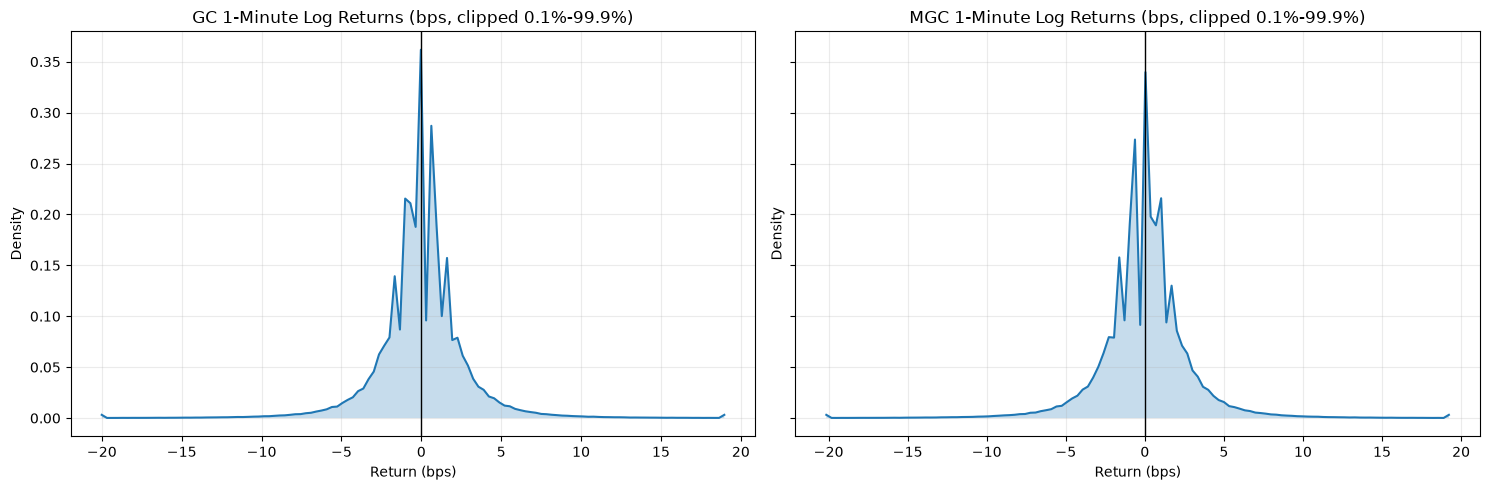

In [71]:
# Precompute histogram bins instead of passing millions of raw rows into seaborn.
# This makes the visualization much faster and more predictable.
_t0 = time.perf_counter()

histogram_rows = []
for product, product_returns in returns.groupby("product", observed=True, sort=False):
    values = product_returns["return_bps"].to_numpy(dtype="float64", copy=False)
    lower, upper = np.quantile(values, [0.001, 0.999])
    clipped = np.clip(values, lower, upper)
    counts, bin_edges = np.histogram(clipped, bins=120, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    histogram_rows.append(pd.DataFrame({
        "product": product,
        "return_bps_clipped": bin_centers,
        "density": counts,
    }))

return_histogram = pd.concat(histogram_rows, ignore_index=True)
print(f"Built precomputed return histogram in {time.perf_counter() - _t0:.2f} seconds")

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, product in zip(axes, ["GC", "MGC"]):
    plot_data = return_histogram[return_histogram["product"].eq(product)]
    ax.plot(plot_data["return_bps_clipped"], plot_data["density"], linewidth=1.5)
    ax.fill_between(plot_data["return_bps_clipped"], plot_data["density"], alpha=0.25)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{product} 1-Minute Log Returns (bps, clipped 0.1%-99.9%)")
    ax.set_xlabel("Return (bps)")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.25)

plt.tight_layout()


In [72]:
tail_thresholds_bps = [5, 10, 20, 50]

_t0 = time.perf_counter()
tail_flags = returns[["product", "abs_return_bps"]].copy()
for threshold in tail_thresholds_bps:
    tail_flags[f"pct_abs_return_gt_{threshold}_bps"] = tail_flags["abs_return_bps"].to_numpy() > threshold

tail_risk_summary = (
    tail_flags
    .groupby("product", observed=True)[[f"pct_abs_return_gt_{threshold}_bps" for threshold in tail_thresholds_bps]]
    .mean()
)

print(f"Built tail risk summary in {time.perf_counter() - _t0:.2f} seconds")
tail_risk_summary


Built tail risk summary in 0.32 seconds


,pct_abs_return_gt_5_bps,pct_abs_return_gt_10_bps,pct_abs_return_gt_20_bps,pct_abs_return_gt_50_bps
product,,,,
GC,0.066410,0.012399,0.001910,0.000121
MGC,0.069201,0.012772,0.001964,0.000127


### 3.5.2 Intraday Volatility


In [73]:
import time

_t0 = time.perf_counter()

returns["half_hour_ny"] = (returns["hour_ny"] * 60 + returns["minute_ny"]) // 30 * 30
returns["half_hour_label"] = (returns["half_hour_ny"] // 60).astype(str).str.zfill(2) + ":" + (returns["half_hour_ny"] % 60).astype(str).str.zfill(2)

intraday_volatility = (
    returns
    .groupby(["product", "half_hour_ny", "half_hour_label"], observed=True)
    .agg(
        observations=("log_return", "size"),
        total_volume=("volume", "sum"),
        mean_abs_return_bps=("abs_return_bps", "mean"),
        median_abs_return_bps=("abs_return_bps", "median"),
        realized_variance=("squared_log_return", "sum"),
    )
    .reset_index()
    .sort_values(["product", "half_hour_ny"])
)
intraday_volatility["realized_vol"] = np.sqrt(intraday_volatility["realized_variance"])
intraday_volatility["rv_share"] = intraday_volatility["realized_variance"] / intraday_volatility.groupby("product", observed=True)["realized_variance"].transform("sum")
intraday_volatility["volume_share"] = intraday_volatility["total_volume"] / intraday_volatility.groupby("product", observed=True)["total_volume"].transform("sum")

intraday_volatility_seconds = time.perf_counter() - _t0
print(f"Built intraday_volatility in {intraday_volatility_seconds:.2f} seconds")
intraday_volatility.head(20)


Built intraday_volatility in 4.02 seconds


,product,half_hour_ny,half_hour_label,observations,total_volume,mean_abs_return_bps,median_abs_return_bps,realized_variance,realized_vol,rv_share,volume_share
0,GC,0,00:00,38370,1704016,1.160132,0.761325,0.001287,0.035882,0.007707,0.007913
1,GC,30,00:30,38465,2062253,1.313859,0.921192,0.001913,0.043744,0.011454,0.009576
2,GC,60,01:00,38523,2262568,1.404681,1.018330,0.002052,0.045298,0.012283,0.010507
3,GC,90,01:30,38583,3023072,1.692302,1.123343,0.002780,0.052730,0.016644,0.014038
4,GC,120,02:00,38606,3927876,1.871970,1.426359,0.002937,0.054190,0.017578,0.018240
5,GC,150,02:30,38607,3661489,1.738588,1.192926,0.002648,0.051461,0.015852,0.017003
6,GC,180,03:00,38642,4783239,2.013688,1.508656,0.003377,0.058111,0.020214,0.022212
7,GC,210,03:30,38624,4154747,1.858213,1.383253,0.002991,0.054691,0.017904,0.019293
8,GC,240,04:00,38635,4329529,1.899541,1.339172,0.003330,0.057706,0.019933,0.020105
9,GC,270,04:30,38592,3706646,1.692154,1.139147,0.002561,0.050605,0.015329,0.017212


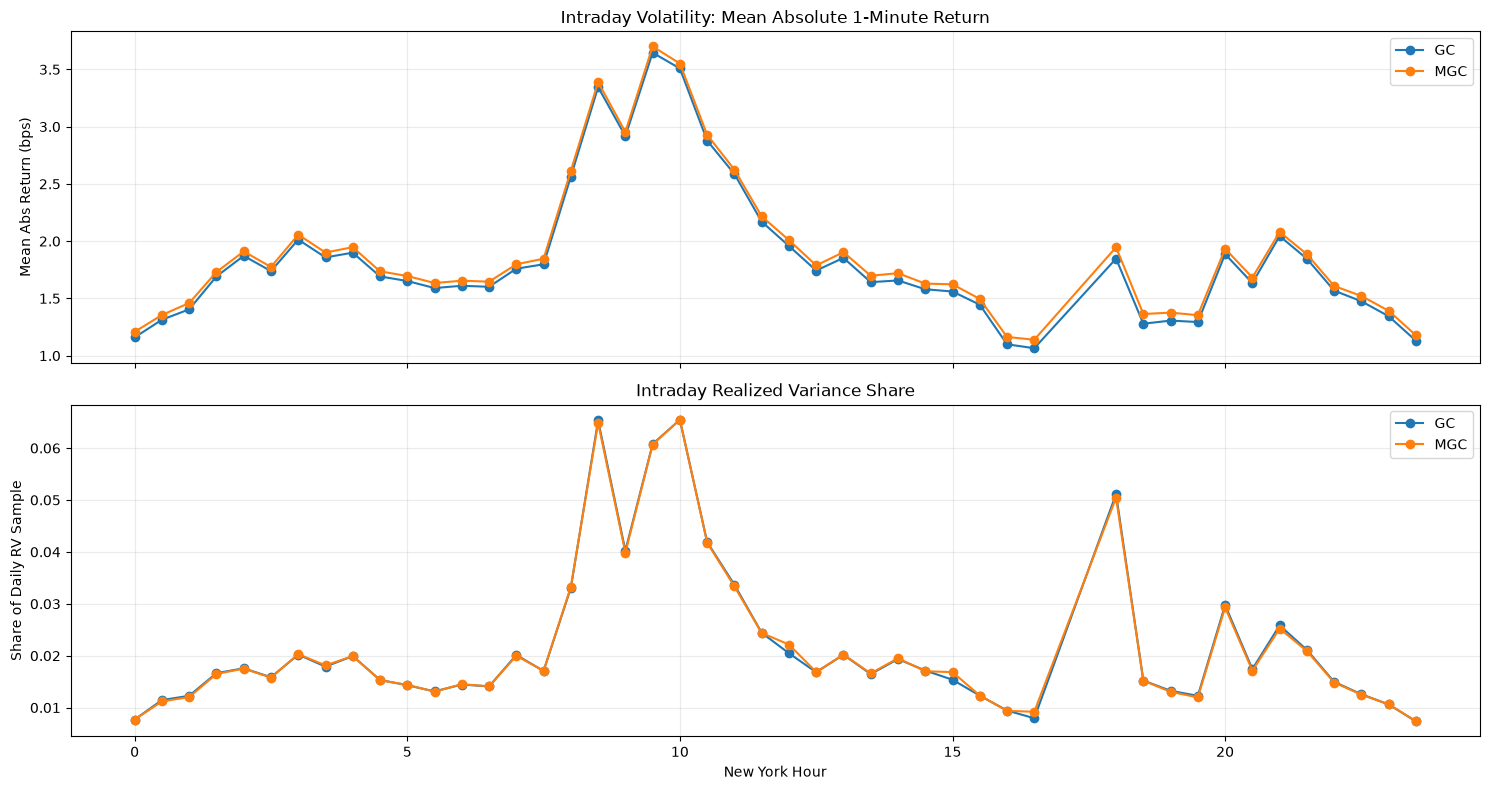

In [74]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for product, group in intraday_volatility.groupby("product", observed=True):
    axes[0].plot(group["half_hour_ny"] / 60, group["mean_abs_return_bps"], marker="o", label=product)
    axes[1].plot(group["half_hour_ny"] / 60, group["rv_share"], marker="o", label=product)

axes[0].set_title("Intraday Volatility: Mean Absolute 1-Minute Return")
axes[0].set_ylabel("Mean Abs Return (bps)")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_title("Intraday Realized Variance Share")
axes[1].set_xlabel("New York Hour")
axes[1].set_ylabel("Share of Daily RV Sample")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()


In [75]:
session_volatility = (
    returns
    .groupby(["product", "session"], observed=True)
    .agg(
        observations=("log_return", "size"),
        total_volume=("volume", "sum"),
        mean_abs_return_bps=("abs_return_bps", "mean"),
        median_abs_return_bps=("abs_return_bps", "median"),
        realized_variance=("squared_log_return", "sum"),
    )
    .reset_index()
)
session_volatility["realized_vol"] = np.sqrt(session_volatility["realized_variance"])
session_volatility["rv_share"] = session_volatility["realized_variance"] / session_volatility.groupby("product", observed=True)["realized_variance"].transform("sum")
session_volatility["volume_share"] = session_volatility["total_volume"] / session_volatility.groupby("product", observed=True)["total_volume"].transform("sum")

session_volatility


,product,session,observations,total_volume,mean_abs_return_bps,median_abs_return_bps,realized_variance,realized_vol,rv_share,volume_share
0,GC,Overnight/Asia,690083,44320082,1.547525,1.031513,0.052297,0.228685,0.313043,0.205808
1,GC,London,411823,44408273,1.785603,1.188707,0.031076,0.176284,0.186018,0.206217
2,GC,New York,399189,105645308,2.672147,1.797160,0.067304,0.259430,0.402874,0.490582
3,GC,Post-NY,262034,20973196,1.437900,0.984155,0.016383,0.127995,0.098065,0.097393
4,MGC,Overnight/Asia,672535,52430329,1.600583,1.070435,0.052736,0.229643,0.309346,0.299066
5,MGC,London,406255,33018991,1.830174,1.252296,0.031771,0.178244,0.186367,0.188342
6,MGC,New York,396281,72554448,2.720288,1.871573,0.068771,0.262242,0.403406,0.413855
7,MGC,Post-NY,255415,17309988,1.499477,1.018641,0.017198,0.131140,0.100881,0.098737


### 3.5.3 Daily Volatility


In [76]:
import time

_t0 = time.perf_counter()

daily_volatility = (
    returns
    .groupby(["trade_date_ny", "product"], observed=True)
    .agg(
        observations=("log_return", "size"),
        daily_volume=("volume", "sum"),
        realized_variance=("squared_log_return", "sum"),
        mean_abs_return_bps=("abs_return_bps", "mean"),
        max_abs_return_bps=("abs_return_bps", "max"),
    )
    .reset_index()
    .sort_values(["product", "trade_date_ny"])
)

daily_volatility["realized_vol"] = np.sqrt(daily_volatility["realized_variance"])
daily_volatility["realized_vol_bps"] = daily_volatility["realized_vol"] * 10_000

daily_volatility["rv_20d_mean"] = (
    daily_volatility
    .groupby("product", observed=True)["realized_vol_bps"]
    .transform(lambda x: x.rolling(20, min_periods=5).mean())
)
daily_volatility["rv_60d_mean"] = (
    daily_volatility
    .groupby("product", observed=True)["realized_vol_bps"]
    .transform(lambda x: x.rolling(60, min_periods=20).mean())
)

daily_volatility_summary = daily_volatility.groupby("product", observed=True).agg(
    days=("trade_date_ny", "nunique"),
    median_realized_vol_bps=("realized_vol_bps", "median"),
    mean_realized_vol_bps=("realized_vol_bps", "mean"),
    p90_realized_vol_bps=("realized_vol_bps", lambda x: x.quantile(0.90)),
    max_realized_vol_bps=("realized_vol_bps", "max"),
    median_daily_volume=("daily_volume", "median"),
)

daily_volatility_seconds = time.perf_counter() - _t0
print(f"Built daily_volatility in {daily_volatility_seconds:.2f} seconds")
daily_volatility_summary


Built daily_volatility in 0.36 seconds


,days,median_realized_vol_bps,mean_realized_vol_bps,p90_realized_vol_bps,max_realized_vol_bps,median_daily_volume
product,,,,,,
GC,1556,80.519219,89.686801,136.751054,601.675109,141969.0
MGC,1556,82.238637,91.001120,137.872341,601.102092,57490.5


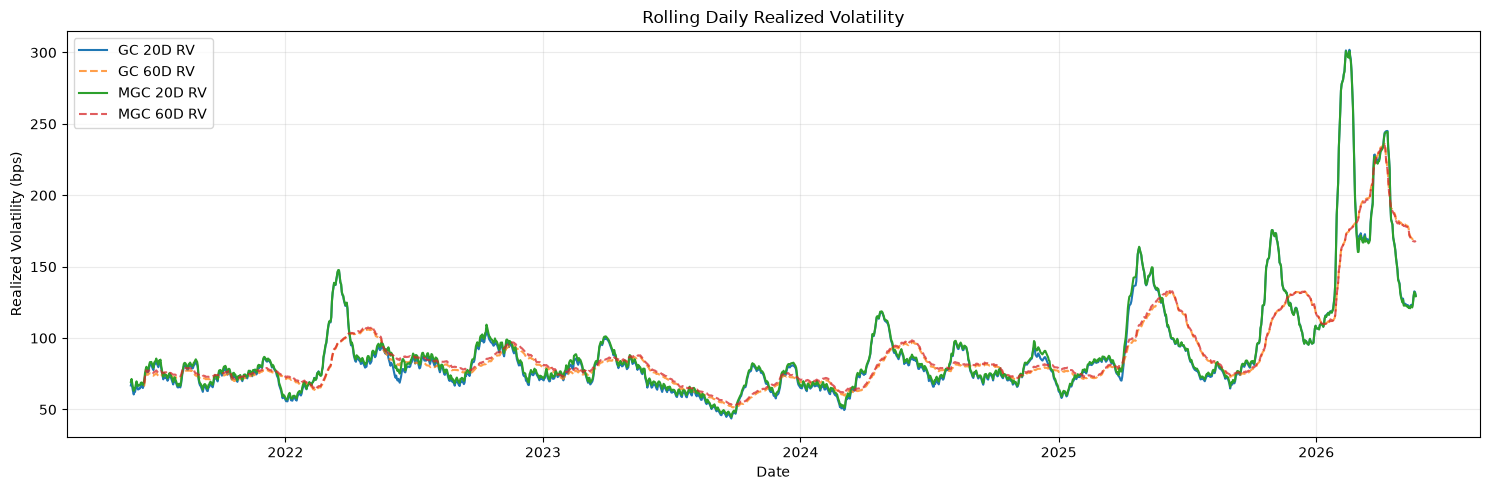

In [77]:
fig, ax = plt.subplots(figsize=(15, 5))

for product, group in daily_volatility.groupby("product", observed=True):
    ax.plot(group["trade_date_ny"], group["rv_20d_mean"], label=f"{product} 20D RV")
    ax.plot(group["trade_date_ny"], group["rv_60d_mean"], linestyle="--", alpha=0.75, label=f"{product} 60D RV")

ax.set_title("Rolling Daily Realized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Realized Volatility (bps)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


In [78]:
top_daily_volatility = (
    daily_volatility
    .sort_values(["product", "realized_vol_bps"], ascending=[True, False])
    .groupby("product", observed=True)
    .head(10)
)

top_daily_volatility[["trade_date_ny", "product", "realized_vol_bps", "daily_volume", "max_abs_return_bps", "observations"]]


,trade_date_ny,product,realized_vol_bps,daily_volume,max_abs_return_bps,observations
2924,2026-02-02,GC,601.675109,301767,95.552759,1380
2918,2026-01-29,GC,598.424967,505268,243.706725,1380
3008,2026-03-23,GC,589.928011,295938,128.238102,1380
2920,2026-01-30,GC,578.163967,377934,114.130878,1020
2922,2026-02-01,GC,562.254833,101869,215.031044,360
2930,2026-02-05,GC,426.199127,215190,82.216274,1380
2928,2026-02-04,GC,384.331086,248112,64.159943,1380
3002,2026-03-19,GC,375.870577,264840,72.057250,1380
2974,2026-03-03,GC,364.573769,249947,70.466848,1380
3010,2026-03-24,GC,351.273538,186012,117.283478,1380


### 3.5.4 Volatility Regimes


In [79]:
# Regime labels are based on product-specific daily realized volatility thresholds.
# This avoids groupby.apply shape/index side effects and keeps the operation explicit.
regime_order = ["Low", "Normal", "High", "Extreme"]

vol_regime_thresholds = (
    daily_volatility
    .groupby("product", observed=True)["realized_vol_bps"]
    .quantile([0.25, 0.75, 0.90])
    .unstack()
    .rename(columns={0.25: "q25", 0.75: "q75", 0.90: "q90"})
)

daily_volatility = daily_volatility.merge(
    vol_regime_thresholds,
    on="product",
    how="left",
)

daily_volatility["vol_regime"] = np.select(
    [
        daily_volatility["realized_vol_bps"] <= daily_volatility["q25"],
        daily_volatility["realized_vol_bps"] <= daily_volatility["q75"],
        daily_volatility["realized_vol_bps"] <= daily_volatility["q90"],
    ],
    ["Low", "Normal", "High"],
    default="Extreme",
)

daily_volatility["vol_regime"] = pd.Categorical(daily_volatility["vol_regime"], categories=regime_order, ordered=True)
daily_volatility.drop(columns=["q25", "q75", "q90"], inplace=True)

volatility_regime_summary = (
    daily_volatility
    .groupby(["product", "vol_regime"], observed=True)
    .agg(
        days=("trade_date_ny", "nunique"),
        median_realized_vol_bps=("realized_vol_bps", "median"),
        mean_realized_vol_bps=("realized_vol_bps", "mean"),
        median_daily_volume=("daily_volume", "median"),
        mean_abs_return_bps=("mean_abs_return_bps", "mean"),
        max_abs_return_bps=("max_abs_return_bps", "max"),
    )
)

volatility_regime_summary


days  median_realized_vol_bps  mean_realized_vol_bps  \
product vol_regime                                                         
GC      Low          389                49.024490              46.280526   
        Normal       778                80.519219              81.792854   
        High         233               114.343000             115.889356   
        Extreme      156               166.192053             198.156908   
MGC     Low          389                49.867059              47.271725   
        Normal       778                82.238637              83.381450   
        High         233               115.653881             117.243517   
        Extreme      156               169.350124             198.849576   

                    median_daily_volume  mean_abs_return_bps  \
product vol_regime                                             
GC      Low                     39006.0             1.237892   
        Normal                 148495.5             1.620594   
        High                   189297.0             2.267891   
        Extreme                201550.5             4.011413   
MGC     Low                     24017.0             1.321676   
        Normal                  58597.0             1.683876   
        High                   128142.0             2.314903   
        Extreme                326061.0             4.030181   

                    max_abs_return_bps  
product vol_regime                      
GC      Low                  48.423750  
        Normal               65.967962  
        High                 88.937387  
        Extreme             243.706725  
MGC     Low                  48.937638  
        Normal               68.904866  
        High                 90.025136  
        Extreme             254.099241

d:\Projects\sidegig\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
d:\Projects\sidegig\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


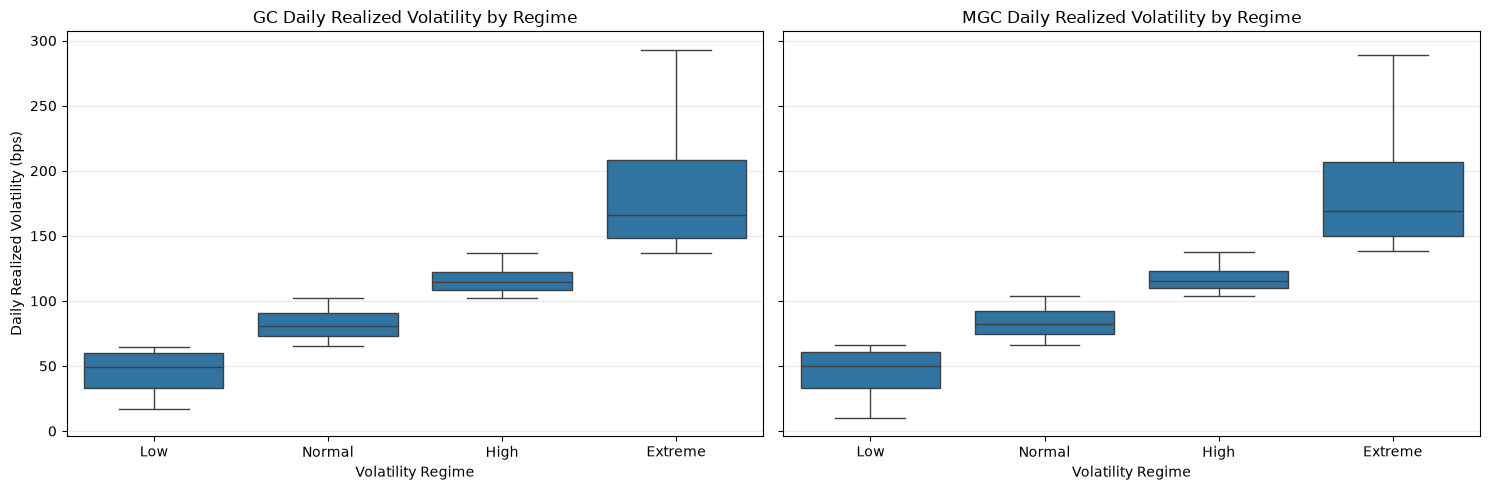

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, product in zip(axes, ["GC", "MGC"]):
    product_daily = daily_volatility[daily_volatility["product"].eq(product)]
    sns.boxplot(data=product_daily, x="vol_regime", y="realized_vol_bps", order=regime_order, ax=ax, showfliers=False)
    ax.set_title(f"{product} Daily Realized Volatility by Regime")
    ax.set_xlabel("Volatility Regime")
    ax.set_ylabel("Daily Realized Volatility (bps)")
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()


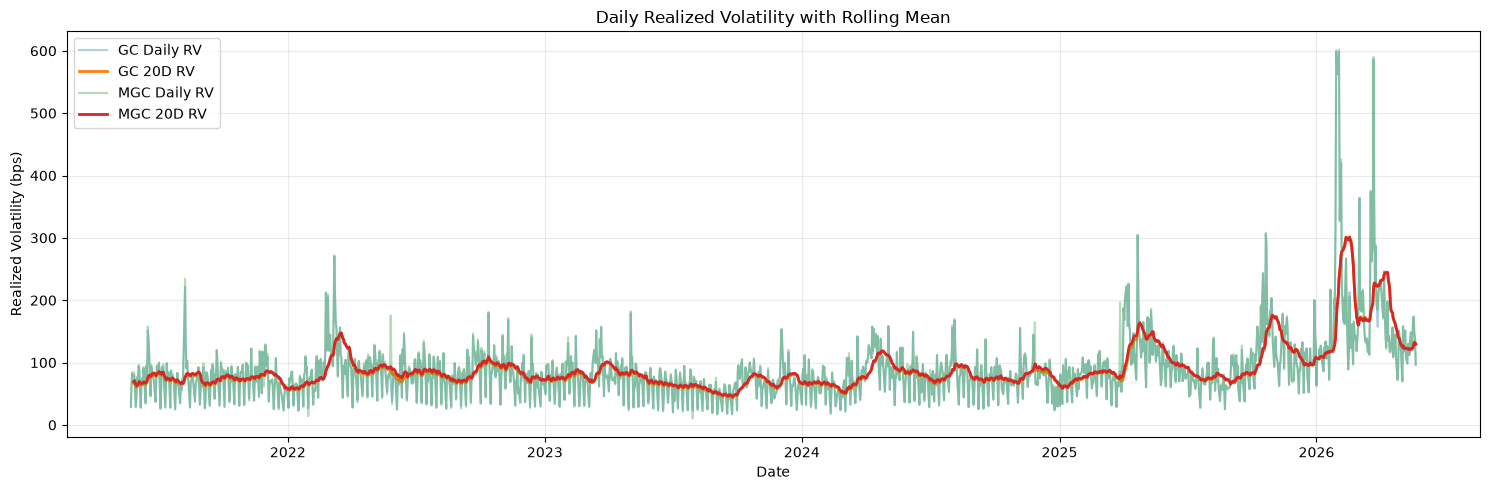

In [81]:
fig, ax = plt.subplots(figsize=(15, 5))

regime_colors = {
    "Low": "#4C78A8",
    "Normal": "#72B7B2",
    "High": "#F2CF5B",
    "Extreme": "#E45756",
}

for product, group in daily_volatility.groupby("product", observed=True):
    ax.plot(group["trade_date_ny"], group["realized_vol_bps"], alpha=0.35, label=f"{product} Daily RV")
    ax.plot(group["trade_date_ny"], group["rv_20d_mean"], linewidth=2, label=f"{product} 20D RV")

ax.set_title("Daily Realized Volatility with Rolling Mean")
ax.set_xlabel("Date")
ax.set_ylabel("Realized Volatility (bps)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


### 3.5.5 Volatility Clustering


In [82]:
# Volatility clustering check: autocorrelation of absolute/squared minute returns
# and daily realized volatility at multiple lags.
minute_lags = [1, 5, 15, 30, 60, 120]
daily_lags = [1, 2, 5, 10, 20]

clustering_rows = []
for product, group in returns.sort_values(["product", "ts_event"]).groupby("product", observed=True):
    abs_ret = group["abs_log_return"]
    sq_ret = group["squared_log_return"]
    for lag in minute_lags:
        clustering_rows.append({
            "product": product,
            "series": "minute_abs_return",
            "lag": lag,
            "autocorr": abs_ret.autocorr(lag=lag),
        })
        clustering_rows.append({
            "product": product,
            "series": "minute_squared_return",
            "lag": lag,
            "autocorr": sq_ret.autocorr(lag=lag),
        })

for product, group in daily_volatility.sort_values(["product", "trade_date_ny"]).groupby("product", observed=True):
    rv = group["realized_vol_bps"]
    for lag in daily_lags:
        clustering_rows.append({
            "product": product,
            "series": "daily_realized_vol",
            "lag": lag,
            "autocorr": rv.autocorr(lag=lag),
        })

volatility_clustering = pd.DataFrame(clustering_rows)
volatility_clustering


,product,series,lag,autocorr
0,GC,minute_abs_return,1,0.372699
1,GC,minute_squared_return,1,0.203841
2,GC,minute_abs_return,5,0.326397
3,GC,minute_squared_return,5,0.116411
4,GC,minute_abs_return,15,0.294703
5,GC,minute_squared_return,15,0.096800
6,GC,minute_abs_return,30,0.275573
7,GC,minute_squared_return,30,0.063302
8,GC,minute_abs_return,60,0.248650
9,GC,minute_squared_return,60,0.052144


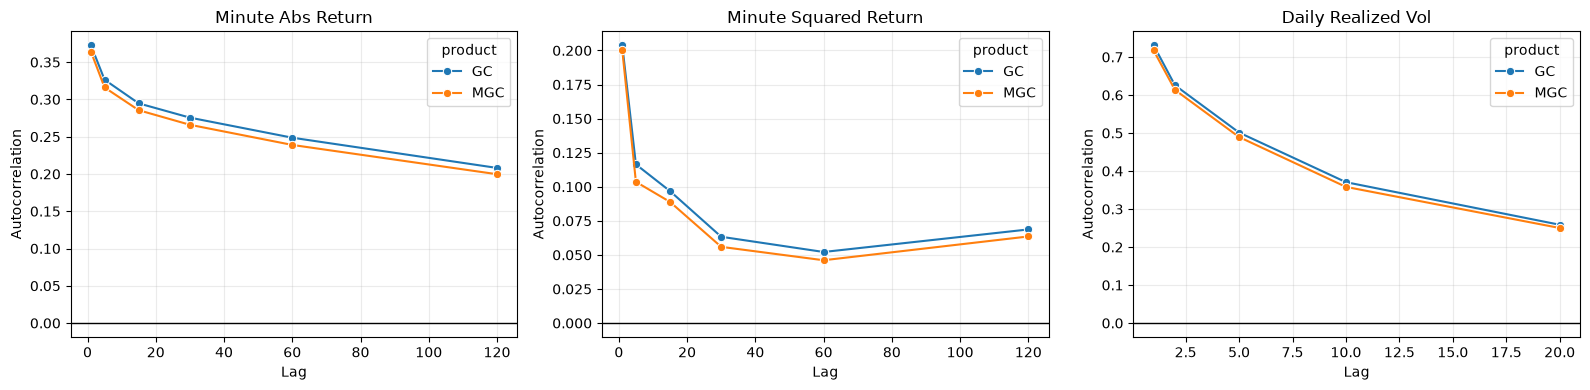

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, series_name in zip(axes, ["minute_abs_return", "minute_squared_return", "daily_realized_vol"]):
    plot_data = volatility_clustering[volatility_clustering["series"].eq(series_name)]
    sns.lineplot(data=plot_data, x="lag", y="autocorr", hue="product", marker="o", ax=ax)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(series_name.replace("_", " ").title())
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.grid(alpha=0.25)

plt.tight_layout()


In [84]:
volatility_clustering_pivot = volatility_clustering.pivot_table(
    index=["series", "lag"],
    columns="product",
    values="autocorr",
)

volatility_clustering_pivot


product                          GC       MGC
series                lag                    
daily_realized_vol    1    0.730992  0.717328
                      2    0.625591  0.613472
                      5    0.501218  0.489429
                      10   0.370660  0.358248
                      20   0.258655  0.250127
minute_abs_return     1    0.372699  0.364108
                      5    0.326397  0.316009
                      15   0.294703  0.285542
                      30   0.275573  0.265980
                      60   0.248650  0.238941
                      120  0.208091  0.199658
minute_squared_return 1    0.203841  0.200414
                      5    0.116411  0.103605
                      15   0.096800  0.088868
                      30   0.063302  0.055909
                      60   0.052144  0.046083
                      120  0.068679  0.063536

**3.5 Volatility Analysis Notes**

* Volatility analysis uses the liquidity-selected active/front contract series from 3.4.
* 1-minute log returns are measured in basis points for readability.
* Intraday volatility is grouped into 30-minute New York-time buckets.
* Daily realized volatility is computed as the square root of summed 1-minute squared log returns.
* Volatility regimes are product-specific quartile/tail buckets, not absolute universal thresholds.
* Volatility clustering is checked through autocorrelation of absolute returns, squared returns, and daily realized volatility.

**Next:** 3.6 Return Analysis.


**3.5 Volatility Analysis**

**3.5.1 Return Distribution**

This section examines the distribution of **1-minute logarithmic returns** for the active/front-month contract series.

**Results**

```text
GC Observations:   1,763,129
MGC Observations:  1,730,486

GC Mean Return:    0.0038 bps
MGC Mean Return:   0.0039 bps

GC Standard Deviation:   3.078 bps
MGC Standard Deviation:  3.139 bps

GC Excess Kurtosis:  120.74
MGC Excess Kurtosis: 126.31
```

Both products exhibit average one-minute returns that are effectively zero, indicating no meaningful directional drift over short horizons. This is consistent with expectations for liquid financial markets.

The most significant finding is the extremely high excess kurtosis. A normal distribution has an excess kurtosis near zero, whereas both GC and MGC exceed 120, indicating exceptionally fat-tailed return distributions.

**Tail Risk Summary**

```text
GC
|Return| > 5 bps:   6.64%
|Return| > 10 bps:  1.24%
|Return| > 20 bps:  0.19%
|Return| > 50 bps:  0.012%

MGC
|Return| > 5 bps:   6.92%
|Return| > 10 bps:  1.28%
|Return| > 20 bps:  0.20%
|Return| > 50 bps:  0.013%
```

These results indicate that large price movements occur substantially more frequently than would be expected under a normal distribution.

**Conclusion**

Gold futures exhibit negligible short-term directional drift but possess extremely heavy-tailed return distributions. Consequently, future strategy development should avoid relying on normality assumptions and instead account explicitly for tail risk through robust risk management and volatility-aware modelling.

---

**3.5.2 Intraday Volatility**

Thirty-minute volatility profiles were constructed using New York trading hours.

The analysis indicates that volatility consistently peaks during the New York morning session, particularly between:

```text
08:00 – 11:00 New York Time
```

This period also corresponds to the highest levels of trading volume observed throughout the trading day.

Volatility therefore follows a pronounced intraday pattern rather than remaining constant across all trading sessions.

**Conclusion**

Intraday volatility is highly time-dependent. Signals generated during the New York morning should not be interpreted in the same manner as signals generated during quieter overnight periods. Future research should normalize returns by expected intraday volatility and incorporate session-aware volatility filters.

---

**3.5.3 Daily Volatility**

**Results**

```text
GC
Median Daily Realized Volatility:  80.52 bps
Mean Daily Realized Volatility:    89.69 bps
90th Percentile:                  136.75 bps
Maximum:                          601.68 bps

MGC
Median Daily Realized Volatility: 82.24 bps
Mean Daily Realized Volatility:   91.00 bps
90th Percentile:                 137.87 bps
Maximum:                         601.10 bps
```

Typical trading days exhibit realized volatility between approximately **80–90 basis points**, while the most volatile sessions exceed **600 basis points**.

Both GC and MGC display remarkably similar realized volatility characteristics throughout the sample period.

**Conclusion**

Daily realized volatility provides a useful baseline for distinguishing normal market conditions from unusually volatile trading sessions. These findings support volatility-adjusted position sizing and regime-based strategy evaluation rather than relying on fixed risk parameters.

---

**3.5.4 Volatility Regimes**

Daily realized volatility was divided into four product-specific regimes:

```text
Low:      Bottom 25%
Normal:   25% – 75%
High:     75% – 90%
Extreme:  Top 10%
```

**Extreme Volatility Results**

```text
GC Extreme Median Daily Volatility:  166.19 bps
MGC Extreme Median Daily Volatility: 169.35 bps
```

Extreme-volatility sessions exhibit approximately twice the realized volatility of a typical trading day and are accompanied by significantly larger price movements and increased trading activity.

**Conclusion**

Volatility regimes represent genuinely different market environments rather than arbitrary statistical groupings. Future strategy testing should evaluate performance separately across low, normal, high, and extreme volatility regimes to determine whether different trading approaches are better suited to different market conditions.

Potential applications include:

* Mean reversion during low-volatility environments.
* Momentum or breakout strategies during high-volatility environments.
* Volatility-adjusted position sizing.
* Regime-based trade filtering.

---

**3.5.5 Volatility Clustering**

**Daily Realized Volatility Autocorrelation**

```text
GC
Lag 1:   0.7310
Lag 5:   0.5012
Lag 20:  0.2587

MGC
Lag 1:   0.7173
Lag 5:   0.4894
Lag 20:  0.2501
```

**Minute-Level Absolute Return Autocorrelation**

```text
GC Lag 1:   0.3727
MGC Lag 1:  0.3641
```

Both products display strong positive volatility autocorrelation over multiple time horizons.

Periods of elevated volatility tend to be followed by further periods of elevated volatility, while calm market conditions similarly persist over time.

Importantly, although future price direction remains difficult to predict, volatility itself exhibits meaningful persistence.

**Conclusion**

Volatility clustering is one of the strongest empirical findings within the dataset. Recent realized volatility should therefore be incorporated as a predictive feature when constructing trading signals, selecting risk parameters, and adapting position sizing.

---

**3.5.6 Summary**

**Key Findings**

```text
Mean 1-Minute Returns:
Approximately 0 bps

Return Distributions:
Extremely fat-tailed

Typical Daily Realized Volatility:
80–90 bps

Highest Intraday Volatility:
08:00–11:00 New York Time

Extreme Volatility:
Approximately double normal daily volatility

Volatility Persistence:
Strong positive autocorrelation at both daily and minute horizons
```

**Overall Assessment**

The volatility analysis demonstrates that while short-term returns exhibit little directional bias, market volatility varies substantially across time and market conditions. Return distributions are characterized by significant tail risk, volatility follows a well-defined intraday pattern, and high-volatility environments tend to persist through time.

These findings establish volatility as a central component of future strategy development. Rather than treating volatility as background noise, subsequent research should explicitly incorporate volatility into signal generation, position sizing, stop-loss placement, take-profit calibration, and overall risk management.

Future signal evaluation should consistently consider the following questions before entering a trade:

* What volatility regime is currently active?
* Is volatility expanding or contracting?
* Is the observed move unusually large for the current time of day?
* Is the market operating under normal or extreme conditions?
* Should position sizing be adjusted?
* Should stop-loss and take-profit distances adapt to current volatility?

This analysis provides the statistical foundation for developing robust, volatility-aware systematic trading strategies.


## 3.6 Return Analysis


This section studies the return behavior of the liquidity-selected active/front contract series.

Where 3.5 focused on volatility magnitude and clustering, 3.6 focuses on signed returns, daily return construction, distribution shape, tail behavior, and preliminary trend versus mean-reversion tendencies.


### 3.6.1 Minute Returns


In [85]:
import time

_t0 = time.perf_counter()

# 3.6 is designed to run after 3.5. Rebuild the returns dataframe only if needed.
if "returns" not in globals():
    required_return_cols = {"log_return", "abs_log_return", "squared_log_return"}
    if not required_return_cols.issubset(active_front.columns):
        active_front["log_close"] = np.log(active_front["close"])
        active_front["log_return"] = (
            active_front
            .groupby(["product", "symbol"], observed=True, sort=False)["log_close"]
            .diff()
        )
        active_front["abs_log_return"] = active_front["log_return"].abs()
        active_front["squared_log_return"] = active_front["log_return"] ** 2
        active_front.drop(columns="log_close", inplace=True)

    returns = active_front.loc[active_front["log_return"].notna(), [
        "ts_event", "trade_date_ny", "product", "symbol", "session", "hour_ny", "minute_ny",
        "volume", "log_return", "abs_log_return", "squared_log_return"
    ]].copy()
    returns["return_bps"] = returns["log_return"].to_numpy() * 10_000
    returns["abs_return_bps"] = returns["abs_log_return"].to_numpy() * 10_000

minute_return_summary = (
    returns
    .groupby("product", observed=True)["return_bps"]
    .agg(
        observations="size",
        mean_bps="mean",
        median_bps="median",
        std_bps="std",
        positive_rate=lambda x: (x > 0).mean(),
        negative_rate=lambda x: (x < 0).mean(),
        zero_rate=lambda x: (x == 0).mean(),
        p05_bps=lambda x: x.quantile(0.05),
        p95_bps=lambda x: x.quantile(0.95),
    )
)
minute_return_summary["mean_abs_bps"] = returns.groupby("product", observed=True)["abs_return_bps"].mean()

minute_return_seconds = time.perf_counter() - _t0
print(f"Built minute_return_summary in {minute_return_seconds:.2f} seconds")
minute_return_summary


Built minute_return_summary in 0.59 seconds


,observations,mean_bps,median_bps,std_bps,positive_rate,negative_rate,zero_rate,p05_bps,p95_bps,mean_abs_bps
product,,,,,,,,,,
GC,1763129,0.003799,0.0,3.078175,0.442202,0.439496,0.118302,-4.069116,4.108886,1.841467
MGC,1730486,0.003905,0.0,3.138676,0.445816,0.442452,0.111732,-4.161743,4.187944,1.895972


In [86]:
session_minute_return_summary = (
    returns
    .groupby(["product", "session"], observed=True)
    .agg(
        observations=("return_bps", "size"),
        mean_bps=("return_bps", "mean"),
        median_bps=("return_bps", "median"),
        std_bps=("return_bps", "std"),
        mean_abs_bps=("abs_return_bps", "mean"),
        positive_rate=("return_bps", lambda x: (x > 0).mean()),
    )
    .reset_index()
)

session_minute_return_summary


,product,session,observations,mean_bps,median_bps,std_bps,mean_abs_bps,positive_rate
0,GC,Overnight/Asia,690083,0.006245,0.0,2.752872,1.547525,0.430393
1,GC,London,411823,0.003447,0.0,2.746995,1.785603,0.448309
2,GC,New York,399189,-0.005949,0.0,4.106114,2.672147,0.465882
3,GC,Post-NY,262034,0.012761,0.0,2.500396,1.437900,0.427632
4,MGC,Overnight/Asia,672535,0.006408,0.0,2.800237,1.600583,0.435338
5,MGC,London,406255,0.003528,0.0,2.796506,1.830174,0.450520
6,MGC,New York,396281,-0.005908,0.0,4.165820,2.720288,0.467141
7,MGC,Post-NY,255415,0.013140,0.0,2.594820,1.499477,0.432841


In [87]:
raw_return_autocorr_lags = [1, 5, 15, 30, 60, 120]
raw_return_autocorr_rows = []

for product, group in returns.sort_values(["product", "symbol", "ts_event"]).groupby("product", observed=True):
    product_returns = group["log_return"]
    for lag in raw_return_autocorr_lags:
        raw_return_autocorr_rows.append({
            "product": product,
            "lag_minutes": lag,
            "raw_return_autocorr": product_returns.autocorr(lag=lag),
        })

minute_return_autocorr = pd.DataFrame(raw_return_autocorr_rows)
minute_return_autocorr


,product,lag_minutes,raw_return_autocorr
0,GC,1,-0.014522
1,GC,5,-0.000237
2,GC,15,0.004988
3,GC,30,0.001554
4,GC,60,0.001163
5,GC,120,0.000584
6,MGC,1,-0.021458
7,MGC,5,-0.000874
8,MGC,15,0.005930
9,MGC,30,0.001614


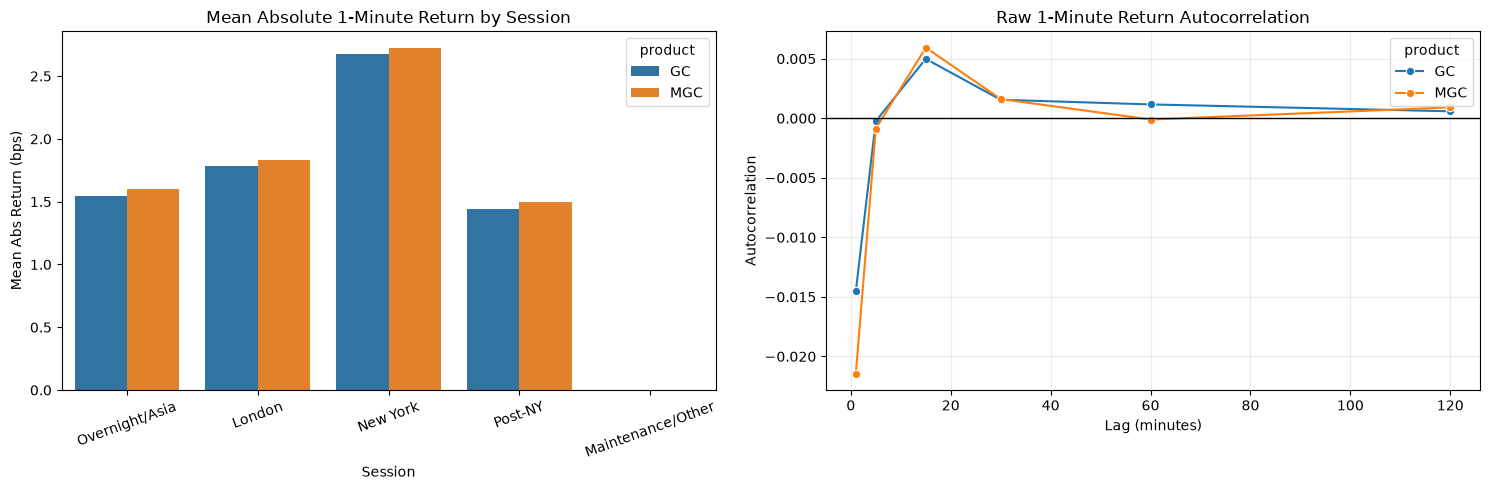

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=session_minute_return_summary, x="session", y="mean_abs_bps", hue="product", ax=axes[0])
axes[0].set_title("Mean Absolute 1-Minute Return by Session")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Mean Abs Return (bps)")
axes[0].tick_params(axis="x", rotation=20)

sns.lineplot(data=minute_return_autocorr, x="lag_minutes", y="raw_return_autocorr", hue="product", marker="o", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Raw 1-Minute Return Autocorrelation")
axes[1].set_xlabel("Lag (minutes)")
axes[1].set_ylabel("Autocorrelation")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.6.2 Daily Returns


In [89]:
import time

_t0 = time.perf_counter()

daily_price_bars = (
    active_front
    .sort_values(["product", "trade_date_ny", "ts_event"])
    .groupby(["trade_date_ny", "product"], observed=True)
    .agg(
        symbol=("symbol", "first"),
        open=("open", "first"),
        high=("high", "max"),
        low=("low", "min"),
        close=("close", "last"),
        daily_volume=("volume", "sum"),
        bars=("symbol", "size"),
    )
    .reset_index()
    .sort_values(["product", "trade_date_ny"])
)

daily_price_bars["prev_close"] = daily_price_bars.groupby("product", observed=True)["close"].shift(1)
daily_price_bars["prev_symbol"] = daily_price_bars.groupby("product", observed=True)["symbol"].shift(1)
daily_price_bars["same_contract_as_prev_day"] = daily_price_bars["symbol"].eq(daily_price_bars["prev_symbol"])

# Open-to-close is the cleanest daily return inside the selected active contract.
daily_price_bars["open_to_close_log_return"] = np.log(daily_price_bars["close"] / daily_price_bars["open"])
daily_price_bars["open_to_close_bps"] = daily_price_bars["open_to_close_log_return"] * 10_000

# Close-to-close is useful, but rollover days can contain contract switch effects.
daily_price_bars["close_to_close_log_return_raw"] = np.log(daily_price_bars["close"] / daily_price_bars["prev_close"])
daily_price_bars.loc[~daily_price_bars["same_contract_as_prev_day"], "close_to_close_log_return_same_contract"] = np.nan
daily_price_bars.loc[daily_price_bars["same_contract_as_prev_day"], "close_to_close_log_return_same_contract"] = daily_price_bars.loc[daily_price_bars["same_contract_as_prev_day"], "close_to_close_log_return_raw"]
daily_price_bars["close_to_close_bps_same_contract"] = daily_price_bars["close_to_close_log_return_same_contract"] * 10_000

daily_price_bars["daily_range_bps"] = np.log(daily_price_bars["high"] / daily_price_bars["low"]) * 10_000

daily_return_summary = daily_price_bars.groupby("product", observed=True).agg(
    days=("trade_date_ny", "nunique"),
    rollover_days=("same_contract_as_prev_day", lambda x: (~x).sum()),
    mean_open_to_close_bps=("open_to_close_bps", "mean"),
    median_open_to_close_bps=("open_to_close_bps", "median"),
    std_open_to_close_bps=("open_to_close_bps", "std"),
    mean_same_contract_close_to_close_bps=("close_to_close_bps_same_contract", "mean"),
    std_same_contract_close_to_close_bps=("close_to_close_bps_same_contract", "std"),
    median_daily_range_bps=("daily_range_bps", "median"),
    mean_daily_range_bps=("daily_range_bps", "mean"),
)

daily_return_seconds = time.perf_counter() - _t0
print(f"Built daily returns in {daily_return_seconds:.2f} seconds")
daily_return_summary


Built daily returns in 2.14 seconds


,days,rollover_days,mean_open_to_close_bps,median_open_to_close_bps,std_open_to_close_bps,mean_same_contract_close_to_close_bps,std_same_contract_close_to_close_bps,median_daily_range_bps,mean_daily_range_bps
product,,,,,,,,,
GC,1556,26,5.462473,3.381571,100.236901,5.439042,100.351258,119.847907,141.986376
MGC,1556,26,5.514628,3.315284,100.444504,5.561138,100.280221,120.148595,141.992777


In [90]:
daily_return_preview = daily_price_bars[[
    "trade_date_ny", "product", "symbol", "open", "close", "open_to_close_bps",
    "close_to_close_bps_same_contract", "daily_range_bps", "daily_volume", "same_contract_as_prev_day"
]].tail(30)

daily_return_preview


,trade_date_ny,product,symbol,open,close,open_to_close_bps,close_to_close_bps_same_contract,daily_range_bps,daily_volume,same_contract_as_prev_day
3053,2026-04-19,MGC,MGCM6,4812.5,4810.8,-3.533092,-77.234852,162.873107,105037,True
3055,2026-04-20,MGC,MGCM6,4810.9,4816.1,10.802951,11.010815,117.282737,287079,True
3057,2026-04-21,MGC,MGCM6,4816.1,4776.0,-83.610958,-83.610958,276.942071,422204,True
3059,2026-04-22,MGC,MGCM6,4776.0,4719.9,-118.157632,-118.157632,170.091460,302454,True
3061,2026-04-23,MGC,MGCM6,4719.2,4687.0,-68.465748,-69.948940,171.795322,384342,True
3063,2026-04-24,MGC,MGCM6,4686.9,4724.7,80.326838,80.113479,181.350747,241253,True
3065,2026-04-26,MGC,MGCM6,4717.8,4739.7,46.312533,31.697757,123.840592,83337,True
3067,2026-04-27,MGC,MGCM6,4739.7,4684.7,-116.719631,-116.719631,139.619064,259336,True
3069,2026-04-28,MGC,MGCM6,4684.8,4608.9,-163.340085,-163.126627,254.212509,403192,True
3071,2026-04-29,MGC,MGCM6,4608.9,4567.4,-90.451016,-90.451016,216.774497,394153,True


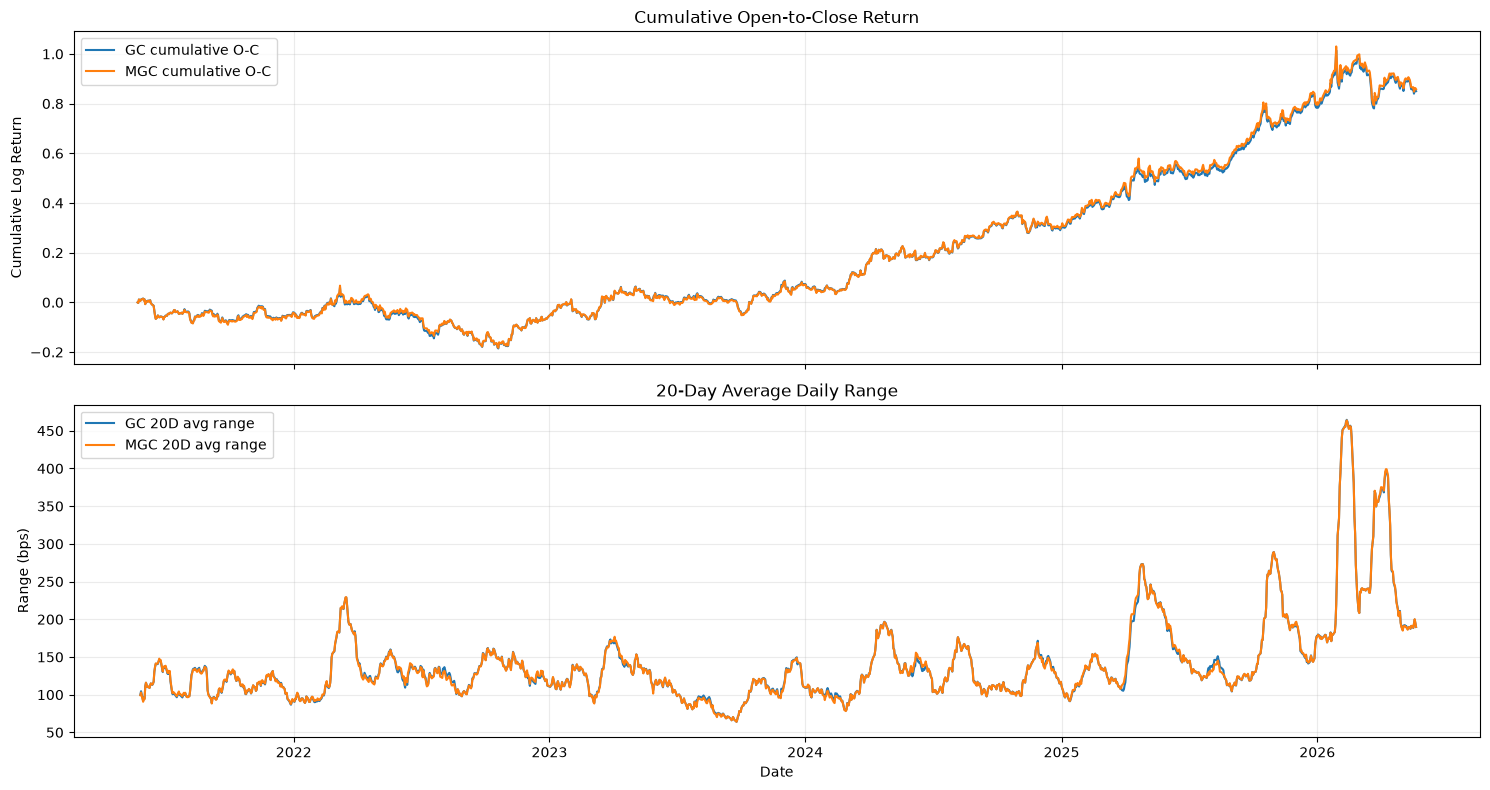

In [91]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for product, group in daily_price_bars.groupby("product", observed=True):
    group = group.sort_values("trade_date_ny")
    cumulative_oc = group["open_to_close_log_return"].cumsum()
    axes[0].plot(group["trade_date_ny"], cumulative_oc, label=f"{product} cumulative O-C")
    axes[1].plot(group["trade_date_ny"], group["daily_range_bps"].rolling(20, min_periods=5).mean(), label=f"{product} 20D avg range")

axes[0].set_title("Cumulative Open-to-Close Return")
axes[0].set_ylabel("Cumulative Log Return")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_title("20-Day Average Daily Range")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Range (bps)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.6.3 Distribution Characteristics


In [92]:
def distribution_stats(values):
    values = pd.Series(values).dropna()
    return pd.Series({
        "observations": len(values),
        "mean_bps": values.mean(),
        "median_bps": values.median(),
        "std_bps": values.std(),
        "skewness": values.skew(),
        "excess_kurtosis": values.kurt(),
        "p01_bps": values.quantile(0.01),
        "p05_bps": values.quantile(0.05),
        "p95_bps": values.quantile(0.95),
        "p99_bps": values.quantile(0.99),
        "mean_abs_bps": values.abs().mean(),
    })

distribution_characteristics = []
for product in sorted(returns["product"].unique()):
    minute_values = returns.loc[returns["product"].eq(product), "return_bps"]
    daily_oc_values = daily_price_bars.loc[daily_price_bars["product"].eq(product), "open_to_close_bps"]
    daily_cc_values = daily_price_bars.loc[daily_price_bars["product"].eq(product), "close_to_close_bps_same_contract"]

    for horizon, values in [
        ("minute", minute_values),
        ("daily_open_to_close", daily_oc_values),
        ("daily_close_to_close_same_contract", daily_cc_values),
    ]:
        row = distribution_stats(values)
        row["product"] = product
        row["horizon"] = horizon
        distribution_characteristics.append(row)

distribution_characteristics = pd.DataFrame(distribution_characteristics).set_index(["product", "horizon"])
distribution_characteristics


observations  mean_bps  \
product horizon                                                      
GC      minute                                 1763129.0  0.003799   
        daily_open_to_close                       1556.0  5.462473   
        daily_close_to_close_same_contract        1530.0  5.439042   
MGC     minute                                 1730486.0  0.003905   
        daily_open_to_close                       1556.0  5.514628   
        daily_close_to_close_same_contract        1530.0  5.561138   

                                            median_bps     std_bps  skewness  \
product horizon                                                                
GC      minute                                0.000000    3.078175 -1.058389   
        daily_open_to_close                   3.381571  100.236901 -0.235237   
        daily_close_to_close_same_contract    2.866624  100.351258 -0.122158   
MGC     minute                                0.000000    3.138676 -1.071727   
        daily_open_to_close                   3.315284  100.444504 -0.226583   
        daily_close_to_close_same_contract    3.822986  100.280221 -0.129067   

                                            excess_kurtosis     p01_bps  \
product horizon                                                           
GC      minute                                   120.742587   -8.360565   
        daily_open_to_close                        6.260273 -266.216913   
        daily_close_to_close_same_contract         5.520220 -272.330277   
MGC     minute                                   126.305007   -8.476337   
        daily_open_to_close                        6.118730 -268.576833   
        daily_close_to_close_same_contract         5.459279 -270.051800   

                                               p05_bps     p95_bps  \
product horizon                                                      
GC      minute                               -4.069116    4.108886   
        daily_open_to_close                -147.106700  154.729412   
        daily_close_to_close_same_contract -146.948893  157.275314   
MGC     minute                               -4.161743    4.187944   
        daily_open_to_close                -146.871503  155.528776   
        daily_close_to_close_same_contract -146.946831  156.702268   

                                               p99_bps  mean_abs_bps  
product horizon                                                       
GC      minute                                8.282637      1.841467  
        daily_open_to_close                 300.675383     68.593163  
        daily_close_to_close_same_contract  300.436834     69.229434  
MGC     minute                                8.369966      1.895972  
        daily_open_to_close                 299.781794     68.890889  
        daily_close_to_close_same_contract  300.547416     69.289610

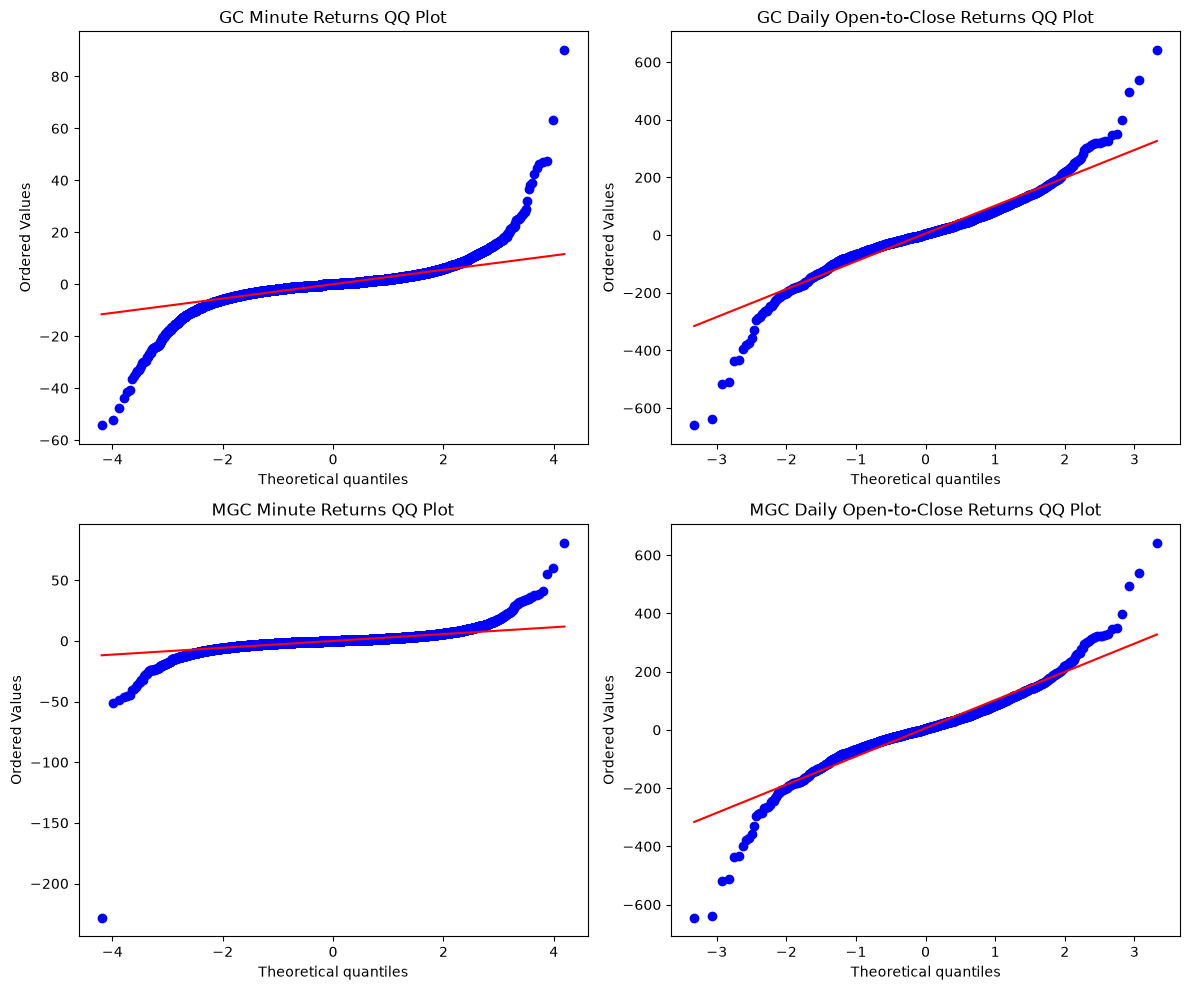

In [93]:
# QQ plots use a deterministic sample for minute returns to avoid plotting millions of points.
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row_idx, product in enumerate(["GC", "MGC"]):
    minute_values = returns.loc[returns["product"].eq(product), "return_bps"].to_numpy()
    if len(minute_values) > 50_000:
        minute_values = rng.choice(minute_values, size=50_000, replace=False)
    daily_values = daily_price_bars.loc[daily_price_bars["product"].eq(product), "open_to_close_bps"].dropna().to_numpy()

    stats.probplot(minute_values, dist="norm", plot=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f"{product} Minute Returns QQ Plot")

    stats.probplot(daily_values, dist="norm", plot=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f"{product} Daily Open-to-Close Returns QQ Plot")

plt.tight_layout()


### 3.6.4 Fat Tails


In [94]:
minute_tail_thresholds_bps = [5, 10, 20, 50]
daily_tail_thresholds_bps = [50, 100, 200, 400]

minute_tail_summary = pd.DataFrame({
    f"pct_abs_minute_return_gt_{threshold}_bps": returns.groupby("product", observed=True)["abs_return_bps"].apply(lambda x, t=threshold: (x > t).mean())
    for threshold in minute_tail_thresholds_bps
})

daily_tail_summary = pd.DataFrame({
    f"pct_abs_daily_oc_return_gt_{threshold}_bps": daily_price_bars.groupby("product", observed=True)["open_to_close_bps"].apply(lambda x, t=threshold: (x.abs() > t).mean())
    for threshold in daily_tail_thresholds_bps
})

fat_tail_summary = minute_tail_summary.join(daily_tail_summary)
fat_tail_summary


,pct_abs_minute_return_gt_5_bps,pct_abs_minute_return_gt_10_bps,pct_abs_minute_return_gt_20_bps,pct_abs_minute_return_gt_50_bps,pct_abs_daily_oc_return_gt_50_bps,pct_abs_daily_oc_return_gt_100_bps,pct_abs_daily_oc_return_gt_200_bps,pct_abs_daily_oc_return_gt_400_bps
product,,,,,,,,
GC,0.066410,0.012399,0.001910,0.000121,0.475578,0.219794,0.049486,0.005784
MGC,0.069201,0.012772,0.001964,0.000127,0.474293,0.219794,0.049486,0.005784


In [95]:
largest_minute_moves = (
    returns
    .assign(abs_return_bps_for_sort=lambda x: x["return_bps"].abs())
    .sort_values(["product", "abs_return_bps_for_sort"], ascending=[True, False])
    .groupby("product", observed=True)
    .head(10)
    [["ts_event", "trade_date_ny", "product", "symbol", "session", "return_bps", "abs_return_bps", "volume"]]
)

largest_daily_moves = (
    daily_price_bars
    .assign(abs_open_to_close_bps=lambda x: x["open_to_close_bps"].abs())
    .sort_values(["product", "abs_open_to_close_bps"], ascending=[True, False])
    .groupby("product", observed=True)
    .head(10)
    [["trade_date_ny", "product", "symbol", "open_to_close_bps", "daily_range_bps", "daily_volume", "bars"]]
)

largest_minute_moves, largest_daily_moves


(                         ts_event trade_date_ny product symbol  \
 522352  2026-01-29 15:27:00+00:00    2026-01-29      GC   GCJ6   
 524125  2026-02-01 23:00:00+00:00    2026-02-01      GC   GCJ6   
 781430  2025-04-22 22:00:00+00:00    2025-04-22      GC   GCM5   
 319042  2022-02-27 23:00:00+00:00    2022-02-27      GC   GCJ2   
 829534  2026-04-12 22:00:00+00:00    2026-04-12      GC   GCM6   
 524255  2026-02-02 01:10:00+00:00    2026-02-01      GC   GCJ6   
 799369  2025-05-11 22:00:00+00:00    2025-05-11      GC   GCM5   
 836419  2026-04-19 22:00:00+00:00    2026-04-19      GC   GCM6   
 572893  2026-03-23 11:05:00+00:00    2026-03-23      GC   GCJ6   
 534651  2026-02-11 13:30:00+00:00    2026-02-11      GC   GCJ6   
 2275803 2026-01-29 15:27:00+00:00    2026-01-29     MGC  MGCJ6   
 2277576 2026-02-01 23:00:00+00:00    2026-02-01     MGC  MGCJ6   
 2532337 2025-04-22 22:00:00+00:00    2025-04-22     MGC  MGCM5   
 2075430 2022-02-27 23:00:00+00:00    2022-02-27     MGC  MGCJ

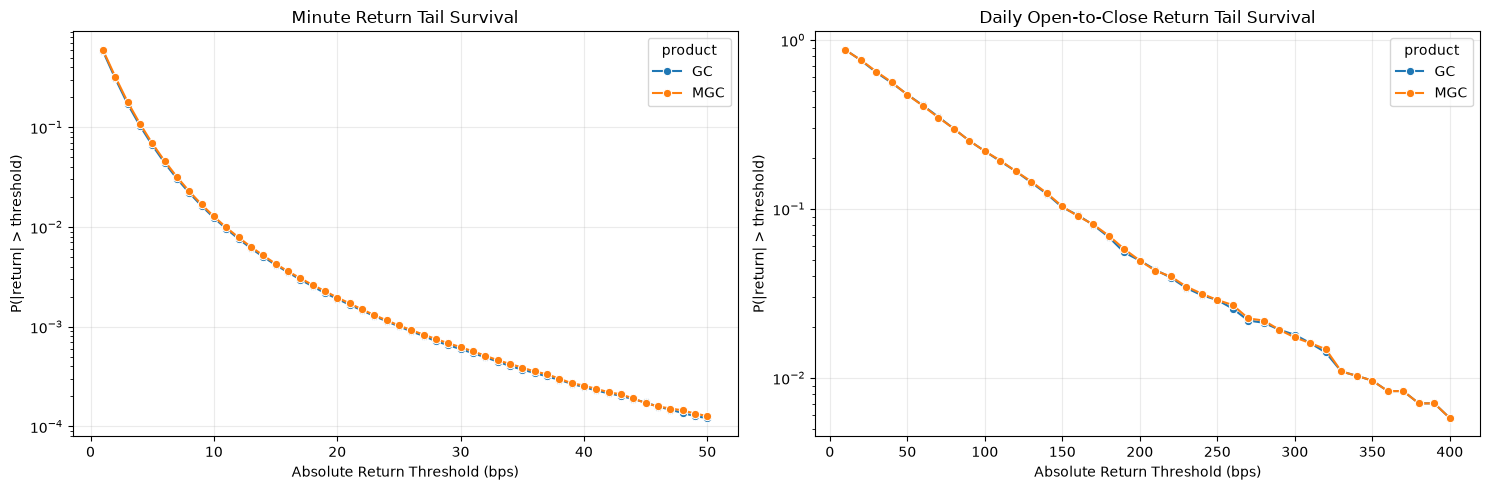

In [96]:
survival_rows = []
for product, group in returns.groupby("product", observed=True):
    abs_values = group["abs_return_bps"].to_numpy(dtype="float64", copy=False)
    for threshold in np.arange(1, 51):
        survival_rows.append({
            "product": product,
            "horizon": "minute",
            "threshold_bps": threshold,
            "exceedance_probability": (abs_values > threshold).mean(),
        })

for product, group in daily_price_bars.groupby("product", observed=True):
    abs_values = group["open_to_close_bps"].abs().to_numpy(dtype="float64", copy=False)
    for threshold in np.arange(10, 401, 10):
        survival_rows.append({
            "product": product,
            "horizon": "daily_open_to_close",
            "threshold_bps": threshold,
            "exceedance_probability": (abs_values > threshold).mean(),
        })

return_tail_survival = pd.DataFrame(survival_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=return_tail_survival[return_tail_survival["horizon"].eq("minute")], x="threshold_bps", y="exceedance_probability", hue="product", marker="o", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Minute Return Tail Survival")
axes[0].set_xlabel("Absolute Return Threshold (bps)")
axes[0].set_ylabel("P(|return| > threshold)")
axes[0].grid(alpha=0.25)

sns.lineplot(data=return_tail_survival[return_tail_survival["horizon"].eq("daily_open_to_close")], x="threshold_bps", y="exceedance_probability", hue="product", marker="o", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Daily Open-to-Close Return Tail Survival")
axes[1].set_xlabel("Absolute Return Threshold (bps)")
axes[1].set_ylabel("P(|return| > threshold)")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.6.5 Trend vs Mean Reversion Tendencies


In [97]:
import time

_t0 = time.perf_counter()
minute_horizons = [1, 5, 15, 30, 60]
trend_mr_rows = []
returns_for_dependence = returns.sort_values(["product", "symbol", "ts_event"]).copy()

for horizon in minute_horizons:
    future_col = f"future_return_{horizon}m"
    returns_for_dependence[future_col] = (
        returns_for_dependence
        .groupby(["product", "symbol"], observed=True, sort=False)["log_return"]
        .shift(-horizon)
    )

    for product, group in returns_for_dependence.groupby("product", observed=True):
        current = group["log_return"]
        future = group[future_col]
        valid = current.notna() & future.notna()
        current_valid = current[valid]
        future_valid = future[valid]

        positive_mask = current_valid > 0
        negative_mask = current_valid < 0
        large_positive_mask = current_valid >= current_valid.quantile(0.90)
        large_negative_mask = current_valid <= current_valid.quantile(0.10)

        trend_mr_rows.append({
            "product": product,
            "horizon_minutes": horizon,
            "corr_current_future": current_valid.corr(future_valid),
            "future_after_positive_bps": future_valid[positive_mask].mean() * 10_000,
            "future_after_negative_bps": future_valid[negative_mask].mean() * 10_000,
            "future_after_top_decile_bps": future_valid[large_positive_mask].mean() * 10_000,
            "future_after_bottom_decile_bps": future_valid[large_negative_mask].mean() * 10_000,
        })

minute_trend_mean_reversion = pd.DataFrame(trend_mr_rows)
minute_trend_mr_seconds = time.perf_counter() - _t0
print(f"Built minute trend/mean-reversion table in {minute_trend_mr_seconds:.2f} seconds")
minute_trend_mean_reversion


Built minute trend/mean-reversion table in 4.92 seconds


,product,horizon_minutes,corr_current_future,future_after_positive_bps,future_after_negative_bps,future_after_top_decile_bps,future_after_bottom_decile_bps
0,GC,1,-0.014521,-0.032828,0.042267,-0.050644,0.078025
1,MGC,1,-0.021465,-0.060379,0.069950,-0.083833,0.120919
2,GC,5,-0.000279,0.003420,0.004451,0.002647,-0.006716
3,MGC,5,-0.000898,0.003302,0.005765,0.001451,0.003977
4,GC,15,0.005008,0.014903,-0.006971,0.020209,-0.016661
5,MGC,15,0.005908,0.014591,-0.006118,0.021056,-0.021252
6,GC,30,0.001514,0.009335,-0.001311,0.011700,-0.008375
7,MGC,30,0.001601,0.008988,-0.002216,0.012129,-0.009320
8,GC,60,0.001136,0.006625,0.001386,0.015247,-0.004136
9,MGC,60,-0.000118,0.005348,0.003142,0.004174,-0.007792


In [98]:
daily_trend_rows = []
daily_lags = [1, 2, 5, 10]

daily_for_dependence = daily_price_bars.sort_values(["product", "trade_date_ny"]).copy()
for lag in daily_lags:
    for product, group in daily_for_dependence.groupby("product", observed=True):
        values = group["open_to_close_log_return"]
        daily_trend_rows.append({
            "product": product,
            "lag_days": lag,
            "daily_return_autocorr": values.autocorr(lag=lag),
            "future_after_positive_bps": values.shift(-lag)[values > 0].mean() * 10_000,
            "future_after_negative_bps": values.shift(-lag)[values < 0].mean() * 10_000,
        })

daily_trend_mean_reversion = pd.DataFrame(daily_trend_rows)
daily_trend_mean_reversion


,product,lag_days,daily_return_autocorr,future_after_positive_bps,future_after_negative_bps
0,GC,1,0.036556,7.139408,3.632450
1,MGC,1,0.035377,6.774634,4.012101
2,GC,2,-0.072215,2.941529,8.447273
3,MGC,2,-0.066260,3.942238,6.931372
4,GC,5,0.065486,3.969544,6.710928
5,MGC,5,0.067529,3.817897,6.889941
6,GC,10,-0.005831,5.578746,5.272865
7,MGC,10,-0.010291,5.347836,5.301551


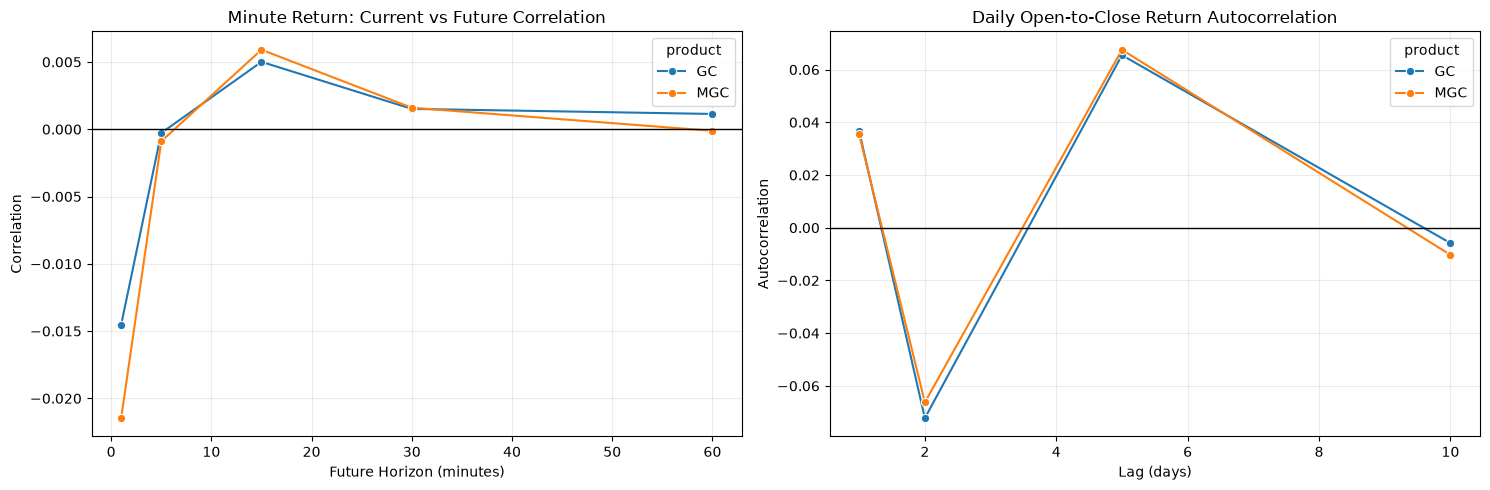

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=minute_trend_mean_reversion, x="horizon_minutes", y="corr_current_future", hue="product", marker="o", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Minute Return: Current vs Future Correlation")
axes[0].set_xlabel("Future Horizon (minutes)")
axes[0].set_ylabel("Correlation")
axes[0].grid(alpha=0.25)

sns.lineplot(data=daily_trend_mean_reversion, x="lag_days", y="daily_return_autocorr", hue="product", marker="o", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Daily Open-to-Close Return Autocorrelation")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Autocorrelation")
axes[1].grid(alpha=0.25)

plt.tight_layout()


**3.6 Return Analysis Notes**

* Minute return analysis uses the active/front contract return series from 3.5.
* Daily open-to-close returns are preferred for first-pass daily analysis because they avoid close-to-close discontinuities on rollover days.
* Same-contract close-to-close returns are still computed for comparison, with rollover days excluded.
* Distribution diagnostics compare minute, daily open-to-close, and same-contract close-to-close returns.
* Fat-tail diagnostics use exceedance probabilities rather than normal-distribution assumptions.
* Trend versus mean-reversion tests are preliminary correlation/conditional-return diagnostics, not trade signals yet.

**Next:** 3.7 Market Microstructure.


**3.6 Return Analysis**

**3.6.1 Minute Returns**

This section examines **signed 1-minute logarithmic returns** calculated from the active/front-month contract series.

**Results**

```text
GC Observations:   1,763,129
MGC Observations:  1,730,486

GC Mean Minute Return:   0.0038 bps
MGC Mean Minute Return:  0.0039 bps

GC Median Return:   0.0 bps
MGC Median Return:  0.0 bps
```

The average one-minute return is effectively zero for both products, indicating no meaningful unconditional directional drift over very short time horizons.

**Direction Balance**

```text
GC
Positive Returns: 44.2%
Negative Returns: 43.9%
Zero Returns:     11.8%

MGC
Positive Returns: 44.6%
Negative Returns: 44.2%
Zero Returns:     11.2%
```

The distribution of positive and negative returns is highly balanced, suggesting that the market exhibits no inherent minute-by-minute directional bias.

**Autocorrelation Results**

```text
GC
1-Minute Future Correlation:  -0.0145
15-Minute Future Correlation:  0.0050

MGC
1-Minute Future Correlation:  -0.0215
15-Minute Future Correlation:  0.0059
```

A very weak negative autocorrelation exists at the one-minute horizon, suggesting minimal short-term mean reversion. At longer horizons, autocorrelation approaches zero, providing little evidence for either persistent momentum or persistent mean reversion.

**Conclusion**

Raw minute returns contain little standalone predictive information. Future signal development should combine returns with contextual information such as trading session, volatility regime, volume, breakout structure, or recent market behaviour.

---

**3.6.2 Daily Returns**

Daily returns were primarily calculated using **open-to-close returns**, avoiding distortions introduced by futures contract rollovers.

**Results**

```text
GC
Mean Open-to-Close Return:    5.46 bps
Median Open-to-Close Return:  3.38 bps
Daily Return Standard Deviation: 100.24 bps

MGC
Mean Open-to-Close Return:    5.51 bps
Median Open-to-Close Return:  3.32 bps
Daily Return Standard Deviation: 100.44 bps
```

Daily returns exhibit a modest positive average over the sample period, although the average return is small relative to normal daily variability.

**Rollover Statistics**

```text
GC Rollover Days:  26
MGC Rollover Days: 26
```

Separating same-contract close-to-close returns from open-to-close returns prevents artificial jumps caused by contract rollovers.

**Daily Trading Range**

```text
GC Median Daily Range:  119.85 bps
MGC Median Daily Range: 120.15 bps
```

These results indicate that the active contract typically experiences substantial intraday price movement, providing meaningful opportunity for intraday trading strategies.

**Conclusion**

Daily returns demonstrate limited directional bias but significant intraday movement. Open-to-close returns provide a cleaner measure of directional performance, while daily ranges offer useful guidance for calibrating stop-losses, profit targets, and expected trading opportunities.

---

**3.6.3 Distribution Characteristics**

Return distributions were analysed across:

* One-minute returns
* Daily open-to-close returns
* Same-contract daily close-to-close returns

**Results**

```text
Minute Excess Kurtosis

GC:  120.74
MGC: 126.31

Daily Open-to-Close Excess Kurtosis

GC: 6.26
MGC: 6.12
```

Minute returns exhibit extremely heavy tails, while daily returns remain fat-tailed but substantially less extreme.

**Daily Return Distribution**

```text
GC
5th Percentile:   -147.11 bps
95th Percentile:   154.73 bps

MGC
5th Percentile:   -146.87 bps
95th Percentile:   155.53 bps
```

The close similarity between GC and MGC confirms that MGC behaves as a scaled version of GC rather than representing a fundamentally different market.

**Conclusion**

Return distributions remain non-normal across both products and time horizons. Daily movements of approximately ±150 basis points represent relatively common market behaviour rather than exceptional outliers.

---

**3.6.4 Fat Tails**

**Minute Return Tail Exceedance**

```text
GC
|Return| > 5 bps:   6.64%
|Return| > 10 bps:  1.24%
|Return| > 20 bps:  0.19%

MGC
|Return| > 5 bps:   6.92%
|Return| > 10 bps:  1.28%
|Return| > 20 bps:  0.20%
```

**Daily Open-to-Close Tail Exceedance**

```text
GC
|Return| > 50 bps:   47.56%
|Return| > 100 bps:  21.98%
|Return| > 200 bps:   4.95%

MGC
|Return| > 50 bps:   47.43%
|Return| > 100 bps:  21.98%
|Return| > 200 bps:   4.95%
```

Large daily price movements occur with meaningful frequency. Nearly one-quarter of trading days experience moves exceeding 100 basis points, while moves greater than 200 basis points occur on approximately five percent of trading days.

**Conclusion**

The prevalence of large price movements reinforces the importance of volatility-aware risk management. Tail statistics should directly inform stop-loss placement, profit targets, position sizing, volatility filters, and portfolio risk controls.

---

**3.6.5 Trend vs Mean Reversion Tendencies**

**Minute-Level Autocorrelation**

```text
GC
1-Minute Correlation:  -0.0145
15-Minute Correlation:  0.0050
30-Minute Correlation:  0.0015

MGC
1-Minute Correlation:  -0.0215
15-Minute Correlation:  0.0059
30-Minute Correlation:  0.0016
```

The slight negative one-minute autocorrelation suggests only a minimal tendency toward short-term mean reversion. At longer horizons, autocorrelation becomes effectively zero.

**Daily Return Autocorrelation**

```text
GC
Lag 1:   0.0366
Lag 2:  -0.0722
Lag 5:   0.0655

MGC
Lag 1:   0.0354
Lag 2:  -0.0663
Lag 5:   0.0675
```

Daily return autocorrelation remains weak and changes sign across different lags, indicating no stable unconditional trend-following or mean-reverting behaviour.

**Conclusion**

Neither momentum nor mean reversion emerges as a reliable unconditional trading edge. Directional signals are therefore likely to require additional conditioning variables such as:

* Trading session
* Volatility regime
* Volume expansion
* London range behaviour
* Overnight price movement
* Market compression and breakout patterns

---

**3.6.6 Summary**

**Key Findings**

```text
Minute Returns:
Centered around zero with balanced positive and negative outcomes.

Daily Returns:
Small positive average relative to substantially larger daily variability.

GC vs MGC:
Nearly identical return behaviour across all measured statistics.

Return Distributions:
Fat-tailed at both minute and daily frequencies.

Autocorrelation:
Weak, unstable, and insufficient for standalone directional prediction.
```

**Overall Assessment**

The return analysis indicates that gold futures exhibit little unconditional directional predictability. Minute returns are balanced around zero, daily returns show only a modest positive average, and both GC and MGC display remarkably similar statistical behaviour.

The strongest characteristics of the return series are their heavy tails and the absence of consistent trend or mean-reversion dynamics. These findings suggest that successful systematic trading strategies are unlikely to arise from raw return patterns alone.

Instead, future signal research should investigate whether directional behaviour becomes predictable under specific market conditions, including:

* New York session breakouts.
* High-volume trading periods.
* Volatility expansion or contraction.
* Overnight drift effects.
* London range breakouts.
* Low-volatility compression followed by expansion.

These questions represent the next logical stage of signal discovery and provide the foundation for developing conditional, context-aware trading strategies.


## 3.7 Market Microstructure


This section studies the behavior of individual 1-minute bars in the active/front contract series.

The goal is to understand typical bar shape, volume spikes, large price moves, and the relationship between volume and price movement before moving into signal exploration.


### 3.7.1 Typical Bar Characteristics


In [100]:
import time

_t0 = time.perf_counter()

# Build a narrow microstructure dataframe from active_front.
# This avoids carrying unnecessary columns into repeated bar-level analysis.
bar_cols = [
    "ts_event", "trade_date_ny", "product", "symbol", "session", "hour_ny", "minute_ny",
    "open", "high", "low", "close", "volume", "log_return", "abs_log_return", "squared_log_return",
]

bar_features = active_front.loc[active_front["log_return"].notna(), bar_cols].copy()

bar_features["range_bps"] = np.log(bar_features["high"] / bar_features["low"]) * 10_000
bar_features["body_bps"] = np.abs(np.log(bar_features["close"] / bar_features["open"])) * 10_000
bar_features["return_bps"] = bar_features["log_return"] * 10_000
bar_features["abs_return_bps"] = bar_features["abs_log_return"] * 10_000
bar_features["upper_wick_bps"] = np.log(bar_features["high"] / bar_features[["open", "close"]].max(axis=1)) * 10_000
bar_features["lower_wick_bps"] = np.log(bar_features[["open", "close"]].min(axis=1) / bar_features["low"]) * 10_000

price_range = bar_features["high"] - bar_features["low"]
bar_features["close_location"] = np.where(
    price_range > 0,
    (bar_features["close"] - bar_features["low"]) / price_range,
    np.nan,
)
bar_features["direction"] = np.select(
    [bar_features["close"] > bar_features["open"], bar_features["close"] < bar_features["open"]],
    ["up", "down"],
    default="flat",
)

bar_characteristics_summary = (
    bar_features
    .groupby("product", observed=True)
    .agg(
        bars=("symbol", "size"),
        median_range_bps=("range_bps", "median"),
        mean_range_bps=("range_bps", "mean"),
        median_body_bps=("body_bps", "median"),
        mean_body_bps=("body_bps", "mean"),
        median_upper_wick_bps=("upper_wick_bps", "median"),
        median_lower_wick_bps=("lower_wick_bps", "median"),
        median_close_location=("close_location", "median"),
        median_volume=("volume", "median"),
        mean_volume=("volume", "mean"),
        zero_return_rate=("return_bps", lambda x: (x == 0).mean()),
    )
)

bar_feature_seconds = time.perf_counter() - _t0
print(f"Built bar_features in {bar_feature_seconds:.2f} seconds")
bar_characteristics_summary


Built bar_features in 2.83 seconds


,bars,median_range_bps,mean_range_bps,median_body_bps,mean_body_bps,median_upper_wick_bps,median_lower_wick_bps,median_close_location,median_volume,mean_volume,zero_return_rate
product,,,,,,,,,,,
GC,1763129,2.454891,3.333095,1.107808,1.785662,0.504936,0.506598,0.5,65.0,122.139026,0.118302
MGC,1730486,2.314161,3.238143,1.101504,1.774815,0.401522,0.416727,0.5,36.0,101.308971,0.111732


In [101]:
session_bar_characteristics = (
    bar_features
    .groupby(["product", "session"], observed=True)
    .agg(
        bars=("symbol", "size"),
        median_range_bps=("range_bps", "median"),
        mean_range_bps=("range_bps", "mean"),
        median_body_bps=("body_bps", "median"),
        mean_abs_return_bps=("abs_return_bps", "mean"),
        median_volume=("volume", "median"),
        mean_volume=("volume", "mean"),
    )
    .reset_index()
)

session_bar_characteristics


,product,session,bars,median_range_bps,mean_range_bps,median_body_bps,mean_abs_return_bps,median_volume,mean_volume
0,GC,Overnight/Asia,690083,1.939958,2.677298,0.995322,1.547525,37.0,64.224277
1,GC,London,411823,2.605308,3.246346,1.150748,1.785603,73.0,107.833397
2,GC,New York,399189,4.096542,5.093172,1.749016,2.672147,177.0,264.649848
3,GC,Post-NY,262034,1.745315,2.515171,0.882574,1.437900,47.0,80.039980
4,MGC,Overnight/Asia,672535,1.731992,2.603388,0.972621,1.600583,23.0,77.959257
5,MGC,London,406255,2.437093,3.077381,1.133273,1.830174,36.0,81.276516
6,MGC,New York,396281,3.988263,4.985046,1.735960,2.720288,86.0,183.088384
7,MGC,Post-NY,255415,1.681285,2.454871,0.856458,1.499477,24.0,67.772010


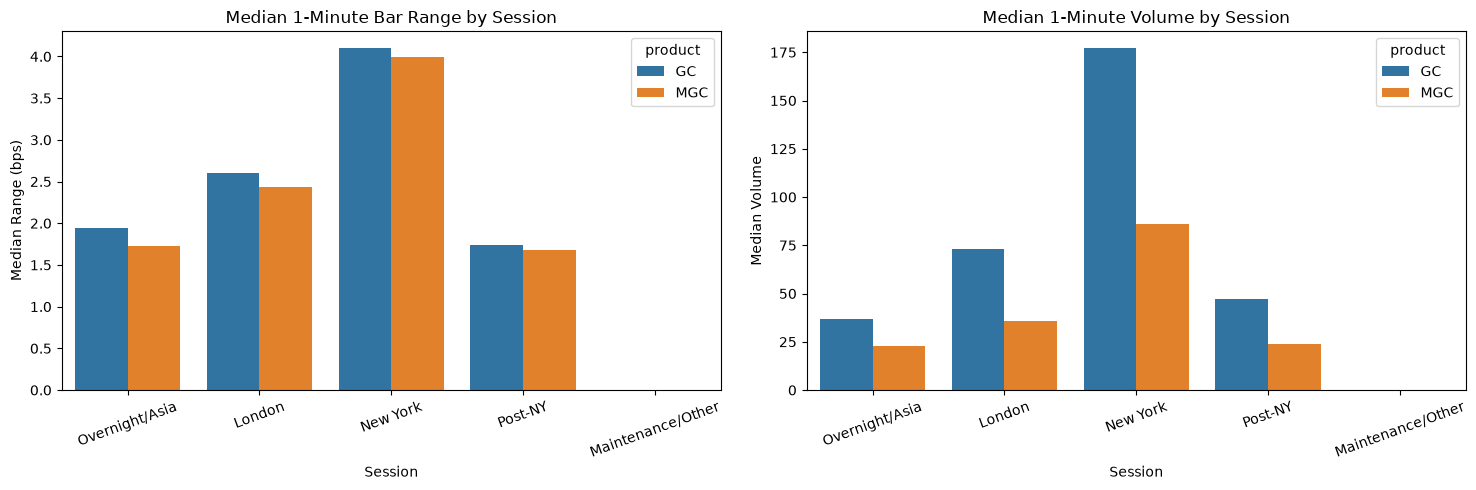

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=session_bar_characteristics, x="session", y="median_range_bps", hue="product", ax=axes[0])
axes[0].set_title("Median 1-Minute Bar Range by Session")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Median Range (bps)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=session_bar_characteristics, x="session", y="median_volume", hue="product", ax=axes[1])
axes[1].set_title("Median 1-Minute Volume by Session")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Median Volume")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


### 3.7.2 Volume Spikes


In [103]:
import time

_t0 = time.perf_counter()

volume_thresholds = (
    bar_features
    .groupby("product", observed=True)["volume"]
    .quantile([0.90, 0.95, 0.99, 0.995])
    .unstack()
    .rename(columns={0.90: "vol_q90", 0.95: "vol_q95", 0.99: "vol_q99", 0.995: "vol_q995"})
)

bar_features = bar_features.merge(volume_thresholds, on="product", how="left")
bar_features["volume_spike_95"] = bar_features["volume"] >= bar_features["vol_q95"]
bar_features["volume_spike_99"] = bar_features["volume"] >= bar_features["vol_q99"]

volume_spike_summary = (
    bar_features
    .groupby("product", observed=True)
    .agg(
        bars=("symbol", "size"),
        vol_q90=("vol_q90", "first"),
        vol_q95=("vol_q95", "first"),
        vol_q99=("vol_q99", "first"),
        vol_q995=("vol_q995", "first"),
        spike_95_rate=("volume_spike_95", "mean"),
        spike_99_rate=("volume_spike_99", "mean"),
        avg_abs_return_all_bps=("abs_return_bps", "mean"),
        avg_abs_return_spike_95_bps=("abs_return_bps", lambda x: x[bar_features.loc[x.index, "volume_spike_95"]].mean()),
        avg_abs_return_spike_99_bps=("abs_return_bps", lambda x: x[bar_features.loc[x.index, "volume_spike_99"]].mean()),
    )
)

volume_spike_seconds = time.perf_counter() - _t0
print(f"Built volume spike analysis in {volume_spike_seconds:.2f} seconds")
volume_spike_summary


Built volume spike analysis in 2.08 seconds


,bars,vol_q90,vol_q95,vol_q99,vol_q995,spike_95_rate,spike_99_rate,avg_abs_return_all_bps,avg_abs_return_spike_95_bps,avg_abs_return_spike_99_bps
product,,,,,,,,,,
GC,1763129,277.0,414.0,888.0,1177.0,0.050192,0.010023,1.841467,5.596058,8.906083
MGC,1730486,253.0,414.0,938.0,1231.0,0.050033,0.010012,1.895972,6.450080,10.948577


In [104]:
volume_spikes_by_session = (
    bar_features
    .groupby(["product", "session"], observed=True)
    .agg(
        bars=("symbol", "size"),
        spike_95_count=("volume_spike_95", "sum"),
        spike_99_count=("volume_spike_99", "sum"),
        spike_95_rate=("volume_spike_95", "mean"),
        spike_99_rate=("volume_spike_99", "mean"),
        mean_abs_return_bps=("abs_return_bps", "mean"),
        mean_abs_return_on_spike_99_bps=("abs_return_bps", lambda x: x[bar_features.loc[x.index, "volume_spike_99"]].mean()),
    )
    .reset_index()
)

volume_spikes_by_session


,product,session,bars,spike_95_count,spike_99_count,spike_95_rate,spike_99_rate,mean_abs_return_bps,mean_abs_return_on_spike_99_bps
0,GC,Overnight/Asia,690083,7335,993,0.010629,0.001439,1.547525,16.923617
1,GC,London,411823,10201,1360,0.024770,0.003302,1.785603,9.997788
2,GC,New York,399189,65955,14260,0.165222,0.035722,2.672147,8.078750
3,GC,Post-NY,262034,5004,1059,0.019097,0.004041,1.437900,11.126714
4,MGC,Overnight/Asia,672535,24181,4186,0.035955,0.006224,1.600583,12.707211
5,MGC,London,406255,11163,1757,0.027478,0.004325,1.830174,12.207947
6,MGC,New York,396281,44546,10206,0.112410,0.025754,2.720288,9.920567
7,MGC,Post-NY,255415,6691,1177,0.026197,0.004608,1.499477,11.728114


In [105]:
top_volume_spike_bars = (
    bar_features
    .sort_values(["product", "volume"], ascending=[True, False])
    .groupby("product", observed=True)
    .head(15)
    [["ts_event", "trade_date_ny", "product", "symbol", "session", "volume", "return_bps", "abs_return_bps", "range_bps"]]
)

top_volume_spike_bars


,ts_event,trade_date_ny,product,symbol,session,volume,return_bps,abs_return_bps,range_bps
1493897,2023-10-25 15:04:00+00:00,2023-10-25,GC,GCZ3,New York,8602,3.033981,3.033981,25.302377
55803,2022-01-25 14:45:00+00:00,2022-01-25,GC,GCG2,New York,7431,46.041844,46.041844,53.062012
1493896,2023-10-25 15:03:00+00:00,2023-10-25,GC,GCZ3,New York,7423,-54.471310,54.471310,56.485928
412032,2024-02-02 13:30:00+00:00,2024-02-02,GC,GCJ4,New York,7318,-56.198975,56.198975,60.080611
1206354,2021-09-03 12:30:00+00:00,2021-09-03,GC,GCZ1,New York,7136,48.322537,48.322537,59.819622
1283244,2021-11-22 14:17:00+00:00,2021-11-22,GC,GCZ1,New York,6930,-28.524430,28.524430,52.170689
1283227,2021-11-22 14:00:00+00:00,2021-11-22,GC,GCZ1,New York,6897,-44.691594,44.691594,50.136345
377698,2023-02-28 15:00:00+00:00,2023-02-28,GC,GCJ3,New York,6773,22.977197,22.977197,50.267836
1272173,2021-11-10 13:33:00+00:00,2021-11-10,GC,GCZ1,New York,6762,60.535183,60.535183,86.118154
1437736,2023-08-29 14:00:00+00:00,2023-08-29,GC,GCZ3,New York,6749,21.531845,21.531845,52.219440


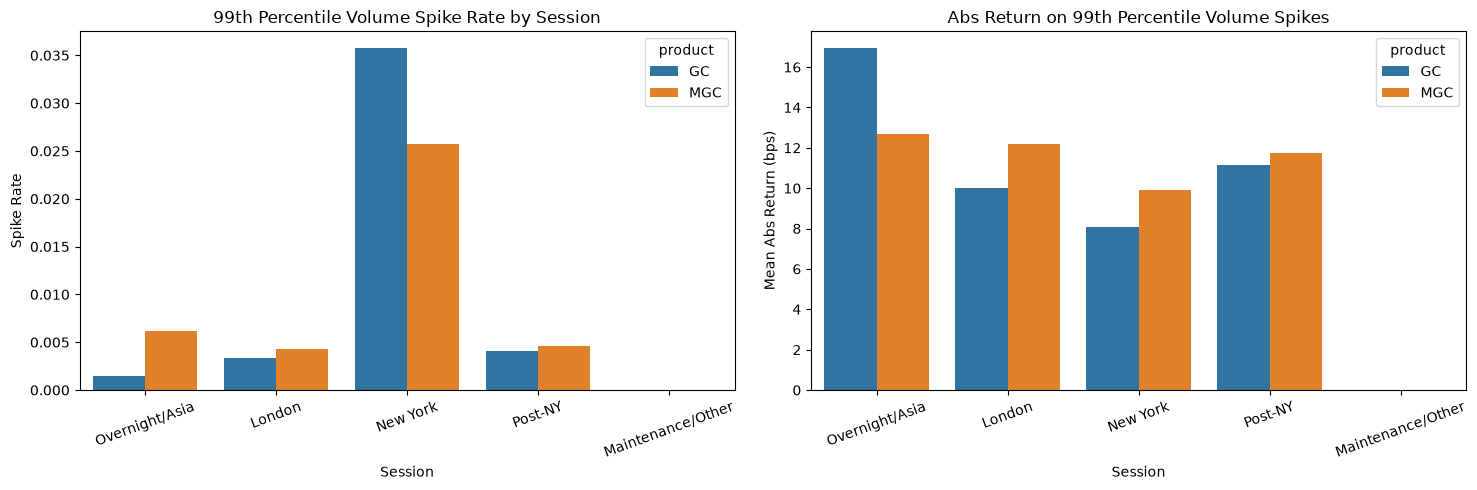

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=volume_spikes_by_session, x="session", y="spike_99_rate", hue="product", ax=axes[0])
axes[0].set_title("99th Percentile Volume Spike Rate by Session")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Spike Rate")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=volume_spikes_by_session, x="session", y="mean_abs_return_on_spike_99_bps", hue="product", ax=axes[1])
axes[1].set_title("Abs Return on 99th Percentile Volume Spikes")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Mean Abs Return (bps)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


### 3.7.3 Large Move Analysis


In [107]:
move_thresholds = (
    bar_features
    .groupby("product", observed=True)["abs_return_bps"]
    .quantile([0.95, 0.99, 0.995, 0.999])
    .unstack()
    .rename(columns={0.95: "move_q95", 0.99: "move_q99", 0.995: "move_q995", 0.999: "move_q999"})
)

bar_features = bar_features.merge(move_thresholds, on="product", how="left")
bar_features["large_move_99"] = bar_features["abs_return_bps"] >= bar_features["move_q99"]
bar_features["large_move_995"] = bar_features["abs_return_bps"] >= bar_features["move_q995"]

large_move_summary = (
    bar_features
    .groupby("product", observed=True)
    .agg(
        bars=("symbol", "size"),
        move_q95_bps=("move_q95", "first"),
        move_q99_bps=("move_q99", "first"),
        move_q995_bps=("move_q995", "first"),
        move_q999_bps=("move_q999", "first"),
        large_move_99_rate=("large_move_99", "mean"),
        large_move_995_rate=("large_move_995", "mean"),
        median_volume_large_move_99=("volume", lambda x: x[bar_features.loc[x.index, "large_move_99"]].median()),
        avg_volume_large_move_99=("volume", lambda x: x[bar_features.loc[x.index, "large_move_99"]].mean()),
        volume_spike_99_overlap=("volume_spike_99", lambda x: x[bar_features.loc[x.index, "large_move_99"]].mean()),
    )
)

large_move_summary


,bars,move_q95_bps,move_q99_bps,move_q995_bps,move_q999_bps,large_move_99_rate,large_move_995_rate,median_volume_large_move_99,avg_volume_large_move_99,volume_spike_99_overlap
product,,,,,,,,,,
GC,1763129,5.676160,10.836889,14.039374,25.068146,0.01,0.005,478.0,730.917536,0.269056
MGC,1730486,5.782018,10.960257,14.173116,25.353215,0.01,0.005,723.0,917.685120,0.363248


In [108]:
large_moves_by_session = (
    bar_features
    .groupby(["product", "session"], observed=True)
    .agg(
        bars=("symbol", "size"),
        large_move_99_count=("large_move_99", "sum"),
        large_move_995_count=("large_move_995", "sum"),
        large_move_99_rate=("large_move_99", "mean"),
        mean_volume=("volume", "mean"),
        median_volume=("volume", "median"),
    )
    .reset_index()
)

large_moves_by_session


,product,session,bars,large_move_99_count,large_move_995_count,large_move_99_rate,mean_volume,median_volume
0,GC,Overnight/Asia,690083,5012,2697,0.007263,64.224277,37.0
1,GC,London,411823,2516,1199,0.006109,107.833397,73.0
2,GC,New York,399189,8251,3949,0.020669,264.649848,177.0
3,GC,Post-NY,262034,1853,971,0.007072,80.039980,47.0
4,MGC,Overnight/Asia,672535,4826,2634,0.007176,77.959257,23.0
5,MGC,London,406255,2440,1190,0.006006,81.276516,36.0
6,MGC,New York,396281,8184,3862,0.020652,183.088384,86.0
7,MGC,Post-NY,255415,1855,967,0.007263,67.772010,24.0


In [109]:
top_large_move_bars = (
    bar_features
    .sort_values(["product", "abs_return_bps"], ascending=[True, False])
    .groupby("product", observed=True)
    .head(15)
    [["ts_event", "trade_date_ny", "product", "symbol", "session", "return_bps", "abs_return_bps", "range_bps", "volume", "volume_spike_99"]]
)

top_large_move_bars


,ts_event,trade_date_ny,product,symbol,session,return_bps,abs_return_bps,range_bps,volume,volume_spike_99
522342,2026-01-29 15:27:00+00:00,2026-01-29,GC,GCJ6,New York,-243.706725,243.706725,254.345874,4459,True
524115,2026-02-01 23:00:00+00:00,2026-02-01,GC,GCJ6,Overnight/Asia,-215.031044,215.031044,92.657842,1005,True
781415,2025-04-22 22:00:00+00:00,2025-04-22,GC,GCM5,Overnight/Asia,-194.088369,194.088369,155.004749,3007,True
319036,2022-02-27 23:00:00+00:00,2022-02-27,GC,GCJ2,Overnight/Asia,179.325275,179.325275,76.251115,3156,True
829518,2026-04-12 22:00:00+00:00,2026-04-12,GC,GCM6,Overnight/Asia,-159.513233,159.513233,179.953442,1384,True
524245,2026-02-02 01:10:00+00:00,2026-02-01,GC,GCJ6,Overnight/Asia,-154.460692,154.460692,165.634811,2138,True
799354,2025-05-11 22:00:00+00:00,2025-05-11,GC,GCM5,Overnight/Asia,-152.244954,152.244954,105.241587,1722,True
836403,2026-04-19 22:00:00+00:00,2026-04-19,GC,GCM6,Overnight/Asia,-130.973156,130.973156,62.736640,986,True
572883,2026-03-23 11:05:00+00:00,2026-03-23,GC,GCJ6,London,128.238102,128.238102,140.517535,959,True
534641,2026-02-11 13:30:00+00:00,2026-02-11,GC,GCJ6,New York,-127.450485,127.450485,134.312274,2471,True


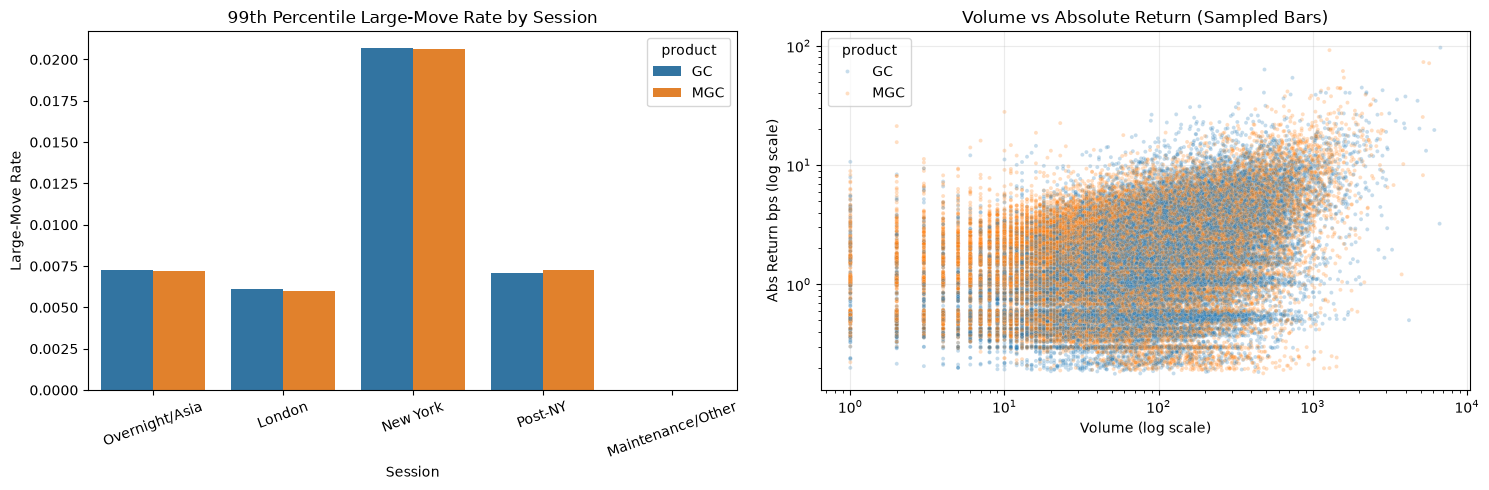

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=large_moves_by_session, x="session", y="large_move_99_rate", hue="product", ax=axes[0])
axes[0].set_title("99th Percentile Large-Move Rate by Session")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Large-Move Rate")
axes[0].tick_params(axis="x", rotation=20)

sns.scatterplot(
    data=bar_features.sample(min(100_000, len(bar_features)), random_state=42),
    x="volume",
    y="abs_return_bps",
    hue="product",
    alpha=0.25,
    s=8,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Volume vs Absolute Return (Sampled Bars)")
axes[1].set_xlabel("Volume (log scale)")
axes[1].set_ylabel("Abs Return bps (log scale)")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.7.4 Volume-Price Relationships


In [111]:
volume_price_relationship = (
    bar_features
    .groupby("product", observed=True)
    .apply(lambda g: pd.Series({
        "corr_volume_abs_return": g["volume"].corr(g["abs_return_bps"]),
        "corr_log_volume_abs_return": np.log1p(g["volume"]).corr(g["abs_return_bps"]),
        "corr_volume_range": g["volume"].corr(g["range_bps"]),
        "corr_log_volume_range": np.log1p(g["volume"]).corr(g["range_bps"]),
        "corr_volume_signed_return": g["volume"].corr(g["return_bps"]),
    }))
)

volume_price_relationship


,corr_volume_abs_return,corr_log_volume_abs_return,corr_volume_range,corr_log_volume_range,corr_volume_signed_return
product,,,,,
GC,0.496185,0.422969,0.645326,0.596316,-0.023183
MGC,0.570728,0.450268,0.760256,0.672899,-0.042895


In [112]:
bar_features["volume_decile"] = (
    bar_features
    .groupby("product", observed=True)["volume"]
    .transform(lambda x: pd.qcut(x.rank(method="first"), q=10, labels=False) + 1)
)

volume_decile_analysis = (
    bar_features
    .groupby(["product", "volume_decile"], observed=True)
    .agg(
        bars=("symbol", "size"),
        median_volume=("volume", "median"),
        mean_volume=("volume", "mean"),
        mean_abs_return_bps=("abs_return_bps", "mean"),
        median_abs_return_bps=("abs_return_bps", "median"),
        mean_range_bps=("range_bps", "mean"),
        large_move_99_rate=("large_move_99", "mean"),
    )
    .reset_index()
)

volume_decile_analysis


,product,volume_decile,bars,median_volume,mean_volume,mean_abs_return_bps,median_abs_return_bps,mean_range_bps,large_move_99_rate
0,GC,1,176313,8.0,7.956169,0.707745,0.536294,0.826347,0.000618
1,GC,2,176313,19.0,18.998128,0.908659,0.585737,1.445675,0.000352
2,GC,3,176313,30.0,29.745855,1.076895,0.881588,1.831820,0.000522
3,GC,4,176313,42.0,41.794479,1.240689,1.027432,2.192765,0.000737
4,GC,5,176313,56.0,56.380987,1.425902,1.106317,2.576967,0.001339
5,GC,6,176312,75.0,75.107951,1.629329,1.208175,2.991136,0.002252
6,GC,7,176313,101.0,101.047416,1.876743,1.509092,3.502731,0.003834
7,GC,8,176313,140.0,140.878619,2.225392,1.705175,4.191552,0.006704
8,GC,9,176313,210.0,214.440949,2.757813,2.164268,5.258086,0.013941
9,GC,10,176313,414.0,535.039441,4.565501,3.370029,8.513869,0.069706


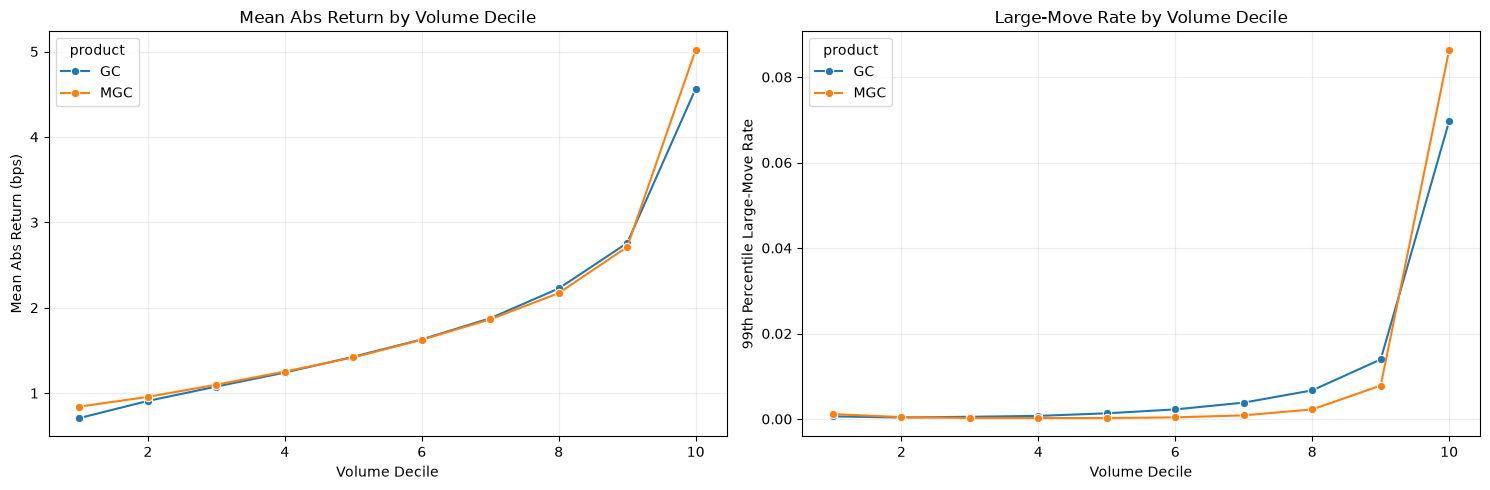

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=volume_decile_analysis, x="volume_decile", y="mean_abs_return_bps", hue="product", marker="o", ax=axes[0])
axes[0].set_title("Mean Abs Return by Volume Decile")
axes[0].set_xlabel("Volume Decile")
axes[0].set_ylabel("Mean Abs Return (bps)")
axes[0].grid(alpha=0.25)

sns.lineplot(data=volume_decile_analysis, x="volume_decile", y="large_move_99_rate", hue="product", marker="o", ax=axes[1])
axes[1].set_title("Large-Move Rate by Volume Decile")
axes[1].set_xlabel("Volume Decile")
axes[1].set_ylabel("99th Percentile Large-Move Rate")
axes[1].grid(alpha=0.25)

plt.tight_layout()


**3.7 Market Microstructure Notes**

* Market microstructure analysis uses only the active/front contract series.
* `bar_features` is the reusable bar-level feature table for this section.
* Typical bar analysis measures range, body, wick structure, close location, direction, and volume.
* Volume spikes are defined with product-specific 95th and 99th percentile volume thresholds.
* Large moves are defined with product-specific return quantile thresholds.
* Volume-price relationships are studied through correlations and volume-decile behavior.

**Next:** 3.8 Preliminary Signal Exploration.


## 3.8 Preliminary Signal Exploration


This section converts the EDA findings into first-pass signal diagnostics.

These are **not backtests**. They are event studies designed to answer one question: when a condition appears, what tends to happen over the next 5, 15, 30, and 60 minutes?


In [114]:
import time

_t0 = time.perf_counter()
forward_horizons = [5, 15, 30, 60]

# Build a reusable signal table from bar_features. Keep it narrow for speed/memory.
signal_cols = [
    "ts_event", "trade_date_ny", "product", "symbol", "session", "hour_ny", "minute_ny",
    "open", "high", "low", "close", "volume", "volume_decile",
    "return_bps", "abs_return_bps", "range_bps", "body_bps", "close_location",
    "volume_spike_95", "volume_spike_99", "large_move_99", "large_move_995",
]

signal_frame = bar_features[signal_cols].sort_values(["product", "symbol", "ts_event"]).copy()
signal_frame["log_close"] = np.log(signal_frame["close"])
signal_frame["direction_sign"] = np.sign(signal_frame["return_bps"]).replace(0, np.nan)

for horizon in forward_horizons:
    future_log_close = (
        signal_frame
        .groupby(["product", "symbol"], observed=True, sort=False)["log_close"]
        .shift(-horizon)
    )
    signal_frame[f"fwd_return_{horizon}m_bps"] = (future_log_close - signal_frame["log_close"]) * 10_000
    signal_frame[f"fwd_abs_return_{horizon}m_bps"] = signal_frame[f"fwd_return_{horizon}m_bps"].abs()
    signal_frame[f"fwd_directional_{horizon}m_bps"] = signal_frame[f"fwd_return_{horizon}m_bps"] * signal_frame["direction_sign"]

def summarize_event_study(data, event_mask, label, direction_mode="current"):
    rows = []
    subset = data.loc[event_mask]
    for product, product_data in subset.groupby("product", observed=True):
        for horizon in forward_horizons:
            fwd = product_data[f"fwd_return_{horizon}m_bps"]
            valid = fwd.notna()
            if direction_mode == "current":
                direction = product_data.loc[valid, "direction_sign"]
                directional = fwd.loc[valid] * direction
                directional = directional.dropna()
                rows.append({
                    "event": label,
                    "product": product,
                    "horizon_minutes": horizon,
                    "events": len(product_data),
                    "valid_events": int(directional.notna().sum()),
                    "mean_forward_bps": fwd.loc[valid].mean(),
                    "median_forward_bps": fwd.loc[valid].median(),
                    "mean_directional_bps": directional.mean(),
                    "median_directional_bps": directional.median(),
                    "continuation_rate": (directional > 0).mean(),
                    "mean_abs_forward_bps": fwd.loc[valid].abs().mean(),
                })
            else:
                clean = fwd.loc[valid]
                rows.append({
                    "event": label,
                    "product": product,
                    "horizon_minutes": horizon,
                    "events": len(product_data),
                    "valid_events": int(clean.notna().sum()),
                    "mean_forward_bps": clean.mean(),
                    "median_forward_bps": clean.median(),
                    "positive_rate": (clean > 0).mean(),
                    "mean_abs_forward_bps": clean.abs().mean(),
                })
    return pd.DataFrame(rows)

signal_prep_seconds = time.perf_counter() - _t0
print(f"Built signal_frame with forward returns in {signal_prep_seconds:.2f} seconds")
pd.Series({
    "rows": len(signal_frame),
    "products": signal_frame["product"].nunique(),
    "symbols": signal_frame["symbol"].nunique(),
    "forward_horizons": str(forward_horizons),
})


Built signal_frame with forward returns in 2.33 seconds


rows                        3493615
products                          2
symbols                          52
forward_horizons    [5, 15, 30, 60]
dtype: object

### 3.8.1 Volume-Based Ideas


In [115]:
volume_event_tables = []

volume_event_definitions = {
    "volume_decile_9_10": signal_frame["volume_decile"] >= 9,
    "volume_decile_10": signal_frame["volume_decile"] == 10,
    "volume_spike_95": signal_frame["volume_spike_95"],
    "volume_spike_99": signal_frame["volume_spike_99"],
    "volume_spike_99_up_bar": signal_frame["volume_spike_99"] & (signal_frame["return_bps"] > 0),
    "volume_spike_99_down_bar": signal_frame["volume_spike_99"] & (signal_frame["return_bps"] < 0),
}

for label, mask in volume_event_definitions.items():
    volume_event_tables.append(summarize_event_study(signal_frame, mask, label, direction_mode="current"))

volume_signal_summary = pd.concat(volume_event_tables, ignore_index=True)
volume_signal_summary


,event,product,horizon_minutes,events,valid_events,mean_forward_bps,median_forward_bps,mean_directional_bps,median_directional_bps,continuation_rate,mean_abs_forward_bps
0,volume_decile_9_10,GC,5,352626,336045,0.042379,0.000000,-0.099058,0.000000,0.474588,6.889280
1,volume_decile_9_10,GC,15,352626,336045,0.044366,0.422900,-0.105846,-0.297446,0.481766,11.554141
2,volume_decile_9_10,GC,30,352626,336045,0.071733,0.521105,-0.075142,-0.343342,0.486241,15.927454
3,volume_decile_9_10,GC,60,352626,336045,0.087903,0.866532,-0.143619,-0.444672,0.488107,21.790446
4,volume_decile_9_10,MGC,5,346097,336415,0.036898,0.230806,-0.111329,-0.229661,0.479643,7.471166
5,volume_decile_9_10,MGC,15,346097,336415,0.065180,0.537909,-0.141976,-0.327939,0.483667,12.550430
6,volume_decile_9_10,MGC,30,346097,336413,0.115043,0.871042,-0.123388,-0.299164,0.488492,17.453060
7,volume_decile_9_10,MGC,60,346097,336408,0.075926,1.361126,-0.106389,-0.294395,0.492197,24.336212
8,volume_decile_10,GC,5,176313,169746,0.116991,0.263835,-0.102215,0.000000,0.476300,8.011281
9,volume_decile_10,GC,15,176313,169746,0.093679,0.521825,-0.103946,-0.375235,0.482598,13.266357


In [116]:
volume_signal_pivot = volume_signal_summary.pivot_table(
    index=["event", "horizon_minutes"],
    columns="product",
    values=["mean_directional_bps", "continuation_rate", "mean_abs_forward_bps"],
)

volume_signal_pivot


continuation_rate            \
product                                                 GC       MGC   
event                    horizon_minutes                               
volume_decile_10         5                        0.476300  0.480964   
                         15                       0.482598  0.483419   
                         30                       0.485891  0.488548   
                         60                       0.489437  0.492107   
volume_decile_9_10       5                        0.474588  0.479643   
                         15                       0.481766  0.483667   
                         30                       0.486241  0.488492   
                         60                       0.488107  0.492197   
volume_spike_95          5                        0.474270  0.478876   
                         15                       0.478790  0.483252   
                         30                       0.483053  0.487335   
                         60                       0.487619  0.492541   
volume_spike_99          5                        0.468613  0.471046   
                         15                       0.475421  0.478422   
                         30                       0.481018  0.485102   
                         60                       0.485634  0.486264   
volume_spike_99_down_bar 5                        0.455116  0.442474   
                         15                       0.451702  0.446797   
                         30                       0.454676  0.453669   
                         60                       0.459302  0.446908   
volume_spike_99_up_bar   5                        0.483461  0.502502   
                         15                       0.501515  0.513240   
                         30                       0.509996  0.519707   
                         60                       0.514601  0.529591   

                                         mean_abs_forward_bps             \
product                                                    GC        MGC   
event                    horizon_minutes                                   
volume_decile_10         5                           8.011281   9.128851   
                         15                         13.266357  15.151692   
                         30                         18.172467  20.871195   
                         60                         24.566667  28.811156   
volume_decile_9_10       5                           6.889280   7.471166   
                         15                         11.554141  12.550430   
                         30                         15.927454  17.453060   
                         60                         21.790446  24.336212   
volume_spike_95          5                           9.050472  11.054817   
                         15                         14.730265  18.170510   
                         30                         20.057448  24.824662   
                         60                         26.930011  33.827243   
volume_spike_99          5                          11.548455  16.425237   
                         15                         18.123558  26.341073   
                         30                         24.070020  35.686673   
                         60                         31.796605  47.065269   
volume_spike_99_down_bar 5                          12.209890  17.082715   
                         15                         18.973213  26.946186   
                         30                         24.939508  36.373910   
                         60                         32.750798  48.044068   
volume_spike_99_up_bar   5                          10.910571  15.731220   
                         15                         17.304255  25.664698   
                         30                         23.278636  34.965499   
                         60                         30.941673  46.112230   

                                         me

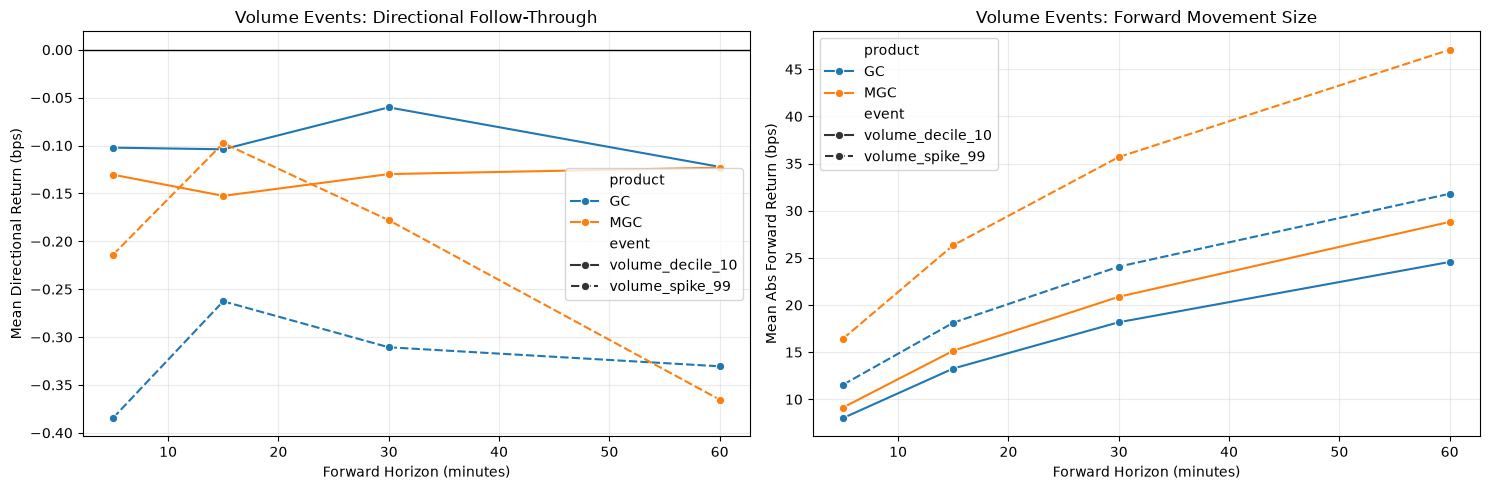

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_data = volume_signal_summary[volume_signal_summary["event"].isin(["volume_decile_10", "volume_spike_99"])]

sns.lineplot(data=plot_data, x="horizon_minutes", y="mean_directional_bps", hue="product", style="event", marker="o", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Volume Events: Directional Follow-Through")
axes[0].set_xlabel("Forward Horizon (minutes)")
axes[0].set_ylabel("Mean Directional Return (bps)")
axes[0].grid(alpha=0.25)

sns.lineplot(data=plot_data, x="horizon_minutes", y="mean_abs_forward_bps", hue="product", style="event", marker="o", ax=axes[1])
axes[1].set_title("Volume Events: Forward Movement Size")
axes[1].set_xlabel("Forward Horizon (minutes)")
axes[1].set_ylabel("Mean Abs Forward Return (bps)")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.8.2 Volatility-Based Ideas


In [118]:
# Attach daily volatility regime to each intraday bar.
regime_map = daily_volatility[["trade_date_ny", "product", "vol_regime", "realized_vol_bps"]].copy()
signal_frame = signal_frame.merge(regime_map, on=["trade_date_ny", "product"], how="left")

volatility_regime_forward = []
for regime in ["Low", "Normal", "High", "Extreme"]:
    mask = signal_frame["vol_regime"].astype(str).eq(regime)
    volatility_regime_forward.append(summarize_event_study(signal_frame, mask, f"vol_regime_{regime}", direction_mode=None))

volatility_signal_summary = pd.concat(volatility_regime_forward, ignore_index=True)
volatility_signal_summary


,event,product,horizon_minutes,events,valid_events,mean_forward_bps,median_forward_bps,positive_rate,mean_abs_forward_bps
0,vol_regime_Low,GC,5,308416,308386,0.029524,0.000000,0.462518,2.548982
1,vol_regime_Low,GC,15,308416,308347,0.080915,0.000000,0.476762,4.360493
2,vol_regime_Low,GC,30,308416,308302,0.161845,0.000000,0.485310,6.126168
3,vol_regime_Low,GC,60,308416,308212,0.334202,0.000000,0.488570,8.649251
4,vol_regime_Low,MGC,5,297574,297554,0.027043,0.000000,0.464060,2.629038
5,vol_regime_Low,MGC,15,297574,297526,0.074188,0.000000,0.478768,4.464476
6,vol_regime_Low,MGC,30,297574,297496,0.147707,0.000000,0.485533,6.253757
7,vol_regime_Low,MGC,60,297574,297459,0.308745,0.000000,0.488262,8.807450
8,vol_regime_Normal,GC,5,971857,971777,0.031261,0.000000,0.475408,3.482756
9,vol_regime_Normal,GC,15,971857,971596,0.095388,0.000000,0.489402,6.006069


In [119]:
volatility_conditional_events = []
conditional_vol_events = {
    "large_move_99_low_vol": signal_frame["large_move_99"] & signal_frame["vol_regime"].astype(str).eq("Low"),
    "large_move_99_normal_vol": signal_frame["large_move_99"] & signal_frame["vol_regime"].astype(str).eq("Normal"),
    "large_move_99_high_vol": signal_frame["large_move_99"] & signal_frame["vol_regime"].astype(str).eq("High"),
    "large_move_99_extreme_vol": signal_frame["large_move_99"] & signal_frame["vol_regime"].astype(str).eq("Extreme"),
}

for label, mask in conditional_vol_events.items():
    volatility_conditional_events.append(summarize_event_study(signal_frame, mask, label, direction_mode="current"))

volatility_conditional_signal_summary = pd.concat(volatility_conditional_events, ignore_index=True)
volatility_conditional_signal_summary


,event,product,horizon_minutes,events,valid_events,mean_forward_bps,median_forward_bps,mean_directional_bps,median_directional_bps,continuation_rate,mean_abs_forward_bps
0,large_move_99_low_vol,GC,5,292,291,1.647454,1.102050,-1.543814,-1.668335,0.381443,7.381769
1,large_move_99_low_vol,GC,15,292,289,1.914894,2.541490,-1.559014,-2.044572,0.422145,10.928654
2,large_move_99_low_vol,GC,30,292,289,1.624578,2.180787,-2.395282,-2.755808,0.391003,13.833823
3,large_move_99_low_vol,GC,60,292,289,2.298334,3.288933,-1.713093,-2.293578,0.446367,17.052284
4,large_move_99_low_vol,MGC,5,300,298,1.986619,1.027090,-1.627194,-1.200284,0.399329,8.145984
5,large_move_99_low_vol,MGC,15,300,295,1.661915,1.975357,-1.555108,-2.205801,0.427119,11.530693
6,large_move_99_low_vol,MGC,30,300,289,1.328080,2.213001,-3.035333,-3.404255,0.387543,15.466759
7,large_move_99_low_vol,MGC,60,300,283,2.688252,4.425513,-2.138747,-2.989894,0.441696,16.928816
8,large_move_99_normal_vol,GC,5,3142,3142,0.697386,0.745720,-0.515683,-1.065657,0.460216,9.943583
9,large_move_99_normal_vol,GC,15,3142,3141,1.243115,1.221374,-0.560122,-1.058929,0.465457,14.846372


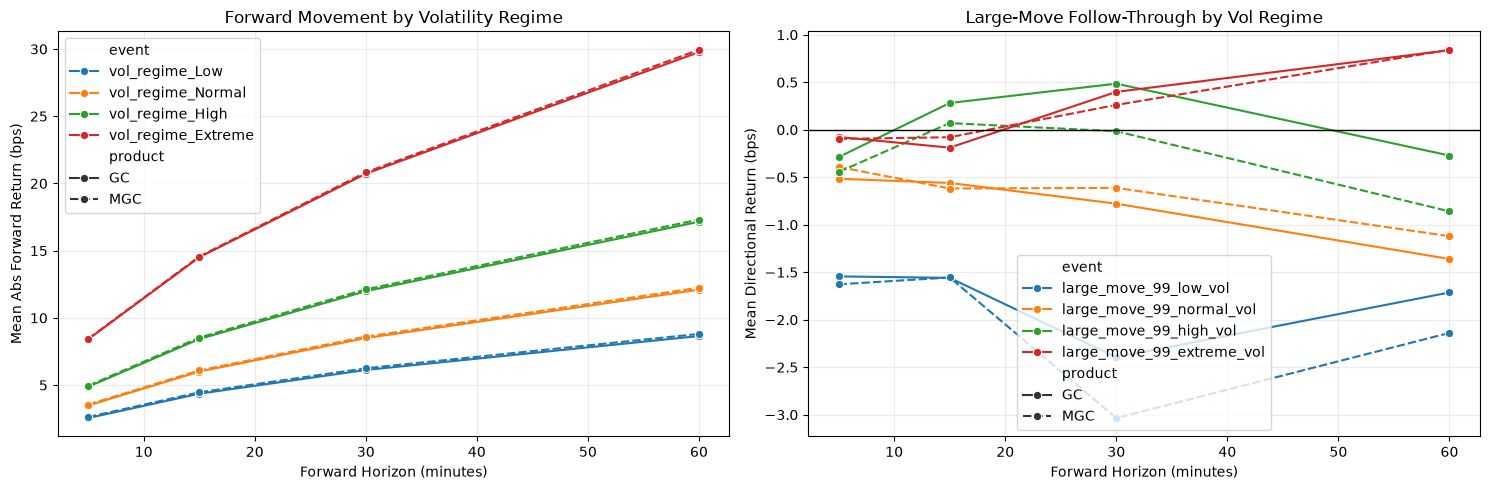

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=volatility_signal_summary, x="horizon_minutes", y="mean_abs_forward_bps", hue="event", style="product", marker="o", ax=axes[0])
axes[0].set_title("Forward Movement by Volatility Regime")
axes[0].set_xlabel("Forward Horizon (minutes)")
axes[0].set_ylabel("Mean Abs Forward Return (bps)")
axes[0].grid(alpha=0.25)

sns.lineplot(data=volatility_conditional_signal_summary, x="horizon_minutes", y="mean_directional_bps", hue="event", style="product", marker="o", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Large-Move Follow-Through by Vol Regime")
axes[1].set_xlabel("Forward Horizon (minutes)")
axes[1].set_ylabel("Mean Directional Return (bps)")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.8.3 Session-Based Ideas


In [121]:
session_signal_tables = []
for session in ["Overnight/Asia", "London", "New York", "Post-NY"]:
    session_signal_tables.append(
        summarize_event_study(signal_frame, signal_frame["session"].astype(str).eq(session), f"session_{session}", direction_mode=None)
    )

session_signal_summary = pd.concat(session_signal_tables, ignore_index=True)
session_signal_summary


,event,product,horizon_minutes,events,valid_events,mean_forward_bps,median_forward_bps,positive_rate,mean_abs_forward_bps
0,session_Overnight/Asia,GC,5,690083,689967,0.023177,0.000000,0.471166,3.376984
1,session_Overnight/Asia,GC,15,690083,689800,0.070519,0.000000,0.484249,5.817890
2,session_Overnight/Asia,GC,30,690083,689604,0.139098,0.000000,0.491739,8.313749
3,session_Overnight/Asia,GC,60,690083,689430,0.280008,0.000000,0.496348,12.029233
4,session_Overnight/Asia,MGC,5,672535,672458,0.023103,0.000000,0.472902,3.460628
5,session_Overnight/Asia,MGC,15,672535,672418,0.070492,0.000000,0.485429,5.939589
6,session_Overnight/Asia,MGC,30,672535,672402,0.136493,0.000000,0.492528,8.479678
7,session_Overnight/Asia,MGC,60,672535,672364,0.270498,0.000000,0.496883,12.259637
8,session_London,GC,5,411823,411823,0.018145,0.000000,0.480425,3.998029
9,session_London,GC,15,411823,411823,0.044766,0.000000,0.493345,6.965420


In [122]:
session_volume_event_tables = []
for session in ["Overnight/Asia", "London", "New York", "Post-NY"]:
    mask = signal_frame["session"].astype(str).eq(session) & signal_frame["volume_spike_99"]
    session_volume_event_tables.append(
        summarize_event_study(signal_frame, mask, f"volume_spike_99_{session}", direction_mode="current")
    )

session_volume_signal_summary = pd.concat(session_volume_event_tables, ignore_index=True)
session_volume_signal_summary


,event,product,horizon_minutes,events,valid_events,mean_forward_bps,median_forward_bps,mean_directional_bps,median_directional_bps,continuation_rate,mean_abs_forward_bps
0,volume_spike_99_Overnight/Asia,GC,5,993,981,1.803341,1.176021,-0.743201,-0.929411,0.467890,16.621699
1,volume_spike_99_Overnight/Asia,GC,15,993,981,1.627368,2.533827,-0.533311,-2.037075,0.449541,23.661829
2,volume_spike_99_Overnight/Asia,GC,30,993,981,3.879574,2.134870,-1.367401,-1.653667,0.460754,29.820866
3,volume_spike_99_Overnight/Asia,GC,60,993,981,6.738323,5.261466,-4.869101,-4.165483,0.444444,36.720614
4,volume_spike_99_Overnight/Asia,MGC,5,4186,4162,1.132196,1.892396,-0.084612,-0.940611,0.473330,18.626843
5,volume_spike_99_Overnight/Asia,MGC,15,4186,4162,0.540966,3.223527,0.860891,-0.931129,0.482941,30.773367
6,volume_spike_99_Overnight/Asia,MGC,30,4186,4162,0.763171,4.028546,0.905988,-0.250297,0.494954,40.912733
7,volume_spike_99_Overnight/Asia,MGC,60,4186,4162,0.991287,7.018028,1.314751,-0.483696,0.495195,53.662040
8,volume_spike_99_London,GC,5,1360,1342,1.312782,0.490851,-0.923847,-1.410073,0.410581,9.950583
9,volume_spike_99_London,GC,15,1360,1342,1.227604,0.882922,-1.855270,-2.098543,0.421759,13.852961


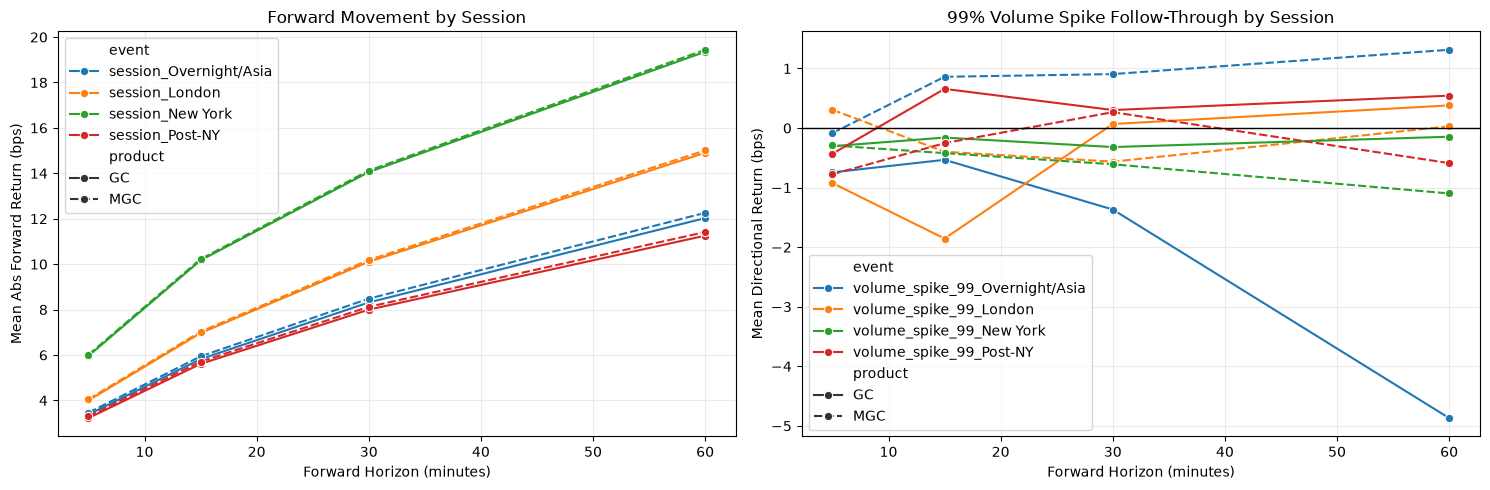

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=session_signal_summary, x="horizon_minutes", y="mean_abs_forward_bps", hue="event", style="product", marker="o", ax=axes[0])
axes[0].set_title("Forward Movement by Session")
axes[0].set_xlabel("Forward Horizon (minutes)")
axes[0].set_ylabel("Mean Abs Forward Return (bps)")
axes[0].grid(alpha=0.25)

sns.lineplot(data=session_volume_signal_summary, x="horizon_minutes", y="mean_directional_bps", hue="event", style="product", marker="o", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("99% Volume Spike Follow-Through by Session")
axes[1].set_xlabel("Forward Horizon (minutes)")
axes[1].set_ylabel("Mean Directional Return (bps)")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.8.4 Breakout Behavior


In [124]:
import time

_t0 = time.perf_counter()

# Prior 60-minute high/low, excluding the current bar.
# This is a first-pass intraday breakout diagnostic, not yet a tradable breakout system.
signal_frame["prior_60m_high"] = (
    signal_frame
    .groupby(["product", "symbol"], observed=True, sort=False)["high"]
    .transform(lambda x: x.shift(1).rolling(60, min_periods=30).max())
)
signal_frame["prior_60m_low"] = (
    signal_frame
    .groupby(["product", "symbol"], observed=True, sort=False)["low"]
    .transform(lambda x: x.shift(1).rolling(60, min_periods=30).min())
)

signal_frame["breakout_up_60m"] = signal_frame["close"] > signal_frame["prior_60m_high"]
signal_frame["breakout_down_60m"] = signal_frame["close"] < signal_frame["prior_60m_low"]
signal_frame["breakout_60m"] = signal_frame["breakout_up_60m"] | signal_frame["breakout_down_60m"]
signal_frame["breakout_direction"] = np.select(
    [signal_frame["breakout_up_60m"], signal_frame["breakout_down_60m"]],
    [1, -1],
    default=np.nan,
)

for horizon in forward_horizons:
    signal_frame[f"breakout_directional_{horizon}m_bps"] = signal_frame[f"fwd_return_{horizon}m_bps"] * signal_frame["breakout_direction"]

breakout_build_seconds = time.perf_counter() - _t0
print(f"Built breakout features in {breakout_build_seconds:.2f} seconds")

breakout_counts = signal_frame.groupby("product", observed=True).agg(
    bars=("symbol", "size"),
    breakout_up_count=("breakout_up_60m", "sum"),
    breakout_down_count=("breakout_down_60m", "sum"),
    breakout_rate=("breakout_60m", "mean"),
)
breakout_counts


Built breakout features in 1.34 seconds


,bars,breakout_up_count,breakout_down_count,breakout_rate
product,,,,
GC,1763129,49356,43060,0.052416
MGC,1730486,50353,43476,0.054221


In [125]:
def summarize_breakout_event(data, event_mask, label):
    rows = []
    subset = data.loc[event_mask]
    for product, product_data in subset.groupby("product", observed=True):
        for horizon in forward_horizons:
            directional = product_data[f"breakout_directional_{horizon}m_bps"].dropna()
            rows.append({
                "event": label,
                "product": product,
                "horizon_minutes": horizon,
                "events": len(product_data),
                "valid_events": len(directional),
                "mean_breakout_follow_through_bps": directional.mean(),
                "median_breakout_follow_through_bps": directional.median(),
                "follow_through_rate": (directional > 0).mean(),
                "mean_abs_forward_bps": directional.abs().mean(),
            })
    return pd.DataFrame(rows)

breakout_event_tables = []
breakout_event_definitions = {
    "breakout_60m_all": signal_frame["breakout_60m"],
    "breakout_60m_volume_decile_9_10": signal_frame["breakout_60m"] & (signal_frame["volume_decile"] >= 9),
    "breakout_60m_volume_spike_99": signal_frame["breakout_60m"] & signal_frame["volume_spike_99"],
    "breakout_60m_new_york": signal_frame["breakout_60m"] & signal_frame["session"].astype(str).eq("New York"),
    "breakout_60m_london": signal_frame["breakout_60m"] & signal_frame["session"].astype(str).eq("London"),
}

for label, mask in breakout_event_definitions.items():
    breakout_event_tables.append(summarize_breakout_event(signal_frame, mask, label))

breakout_signal_summary = pd.concat(breakout_event_tables, ignore_index=True)
breakout_signal_summary


,event,product,horizon_minutes,events,valid_events,mean_breakout_follow_through_bps,median_breakout_follow_through_bps,follow_through_rate,mean_abs_forward_bps
0,breakout_60m_all,GC,5,92416,92410,-0.288359,-0.504974,0.438329,5.110474
1,breakout_60m_all,GC,15,92416,92385,-0.240249,-0.557833,0.450430,8.437435
2,breakout_60m_all,GC,30,92416,92342,-0.275627,-0.660415,0.459585,11.547491
3,breakout_60m_all,GC,60,92416,92276,-0.395338,-1.003185,0.465733,16.052836
4,breakout_60m_all,MGC,5,93829,93815,-0.358665,-0.528164,0.430315,5.140097
5,breakout_60m_all,MGC,15,93829,93783,-0.324114,-0.596410,0.448077,8.472154
6,breakout_60m_all,MGC,30,93829,93735,-0.318627,-0.876130,0.457182,11.588576
7,breakout_60m_all,MGC,60,93829,93629,-0.416531,-1.025536,0.464557,16.057007
8,breakout_60m_volume_decile_9_10,GC,5,46747,46747,-0.379871,-0.580855,0.441205,6.789923
9,breakout_60m_volume_decile_9_10,GC,15,46747,46747,-0.282733,-0.997407,0.452457,11.030341


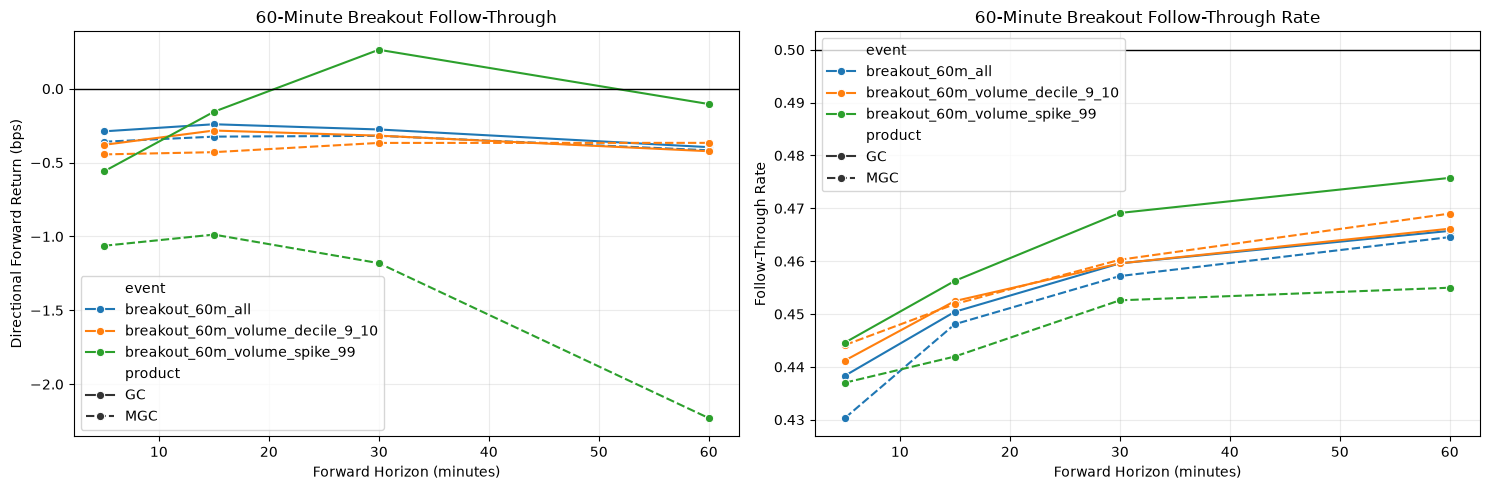

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_data = breakout_signal_summary[breakout_signal_summary["event"].isin([
    "breakout_60m_all", "breakout_60m_volume_decile_9_10", "breakout_60m_volume_spike_99"
])]

sns.lineplot(data=plot_data, x="horizon_minutes", y="mean_breakout_follow_through_bps", hue="event", style="product", marker="o", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("60-Minute Breakout Follow-Through")
axes[0].set_xlabel("Forward Horizon (minutes)")
axes[0].set_ylabel("Directional Forward Return (bps)")
axes[0].grid(alpha=0.25)

sns.lineplot(data=plot_data, x="horizon_minutes", y="follow_through_rate", hue="event", style="product", marker="o", ax=axes[1])
axes[1].axhline(0.5, color="black", linewidth=1)
axes[1].set_title("60-Minute Breakout Follow-Through Rate")
axes[1].set_xlabel("Forward Horizon (minutes)")
axes[1].set_ylabel("Follow-Through Rate")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.8.5 Mean Reversion Behavior


In [127]:
mean_reversion_tables = []

mean_reversion_event_definitions = {
    "large_move_99_all": signal_frame["large_move_99"],
    "large_move_99_no_volume_spike_99": signal_frame["large_move_99"] & ~signal_frame["volume_spike_99"],
    "large_move_99_with_volume_spike_99": signal_frame["large_move_99"] & signal_frame["volume_spike_99"],
    "large_move_99_new_york": signal_frame["large_move_99"] & signal_frame["session"].astype(str).eq("New York"),
    "large_move_99_overnight": signal_frame["large_move_99"] & signal_frame["session"].astype(str).eq("Overnight/Asia"),
}

for label, mask in mean_reversion_event_definitions.items():
    mean_reversion_tables.append(summarize_event_study(signal_frame, mask, label, direction_mode="current"))

mean_reversion_signal_summary = pd.concat(mean_reversion_tables, ignore_index=True)
mean_reversion_signal_summary


,event,product,horizon_minutes,events,valid_events,mean_forward_bps,median_forward_bps,mean_directional_bps,median_directional_bps,continuation_rate,mean_abs_forward_bps
0,large_move_99_all,GC,5,17632,17625,0.422053,0.962473,-0.215645,-1.114392,0.467007,16.295633
1,large_move_99_all,GC,15,17632,17613,0.066399,1.596989,-0.194864,-1.176318,0.476182,26.175700
2,large_move_99_all,GC,30,17632,17599,0.197435,2.342634,0.157997,-1.117905,0.483550,35.745014
3,large_move_99_all,GC,60,17632,17567,0.442206,3.297609,0.209773,-1.471086,0.486082,47.971553
4,large_move_99_all,MGC,5,17305,17291,0.516195,0.983187,-0.237869,-1.005025,0.468510,16.361977
5,large_move_99_all,MGC,15,17305,17264,0.009763,1.540813,-0.175575,-1.288656,0.474398,26.151765
6,large_move_99_all,MGC,30,17305,17228,0.057969,2.254846,-0.001520,-1.217199,0.482470,35.892963
7,large_move_99_all,MGC,60,17305,17174,0.092916,3.060679,0.136560,-1.515638,0.486608,48.004975
8,large_move_99_no_volume_spike_99,GC,5,12888,12881,0.324487,0.914328,-0.196360,-1.125936,0.466579,16.294655
9,large_move_99_no_volume_spike_99,GC,15,12888,12869,-0.007865,1.521414,-0.277935,-1.066223,0.479991,26.774370


In [128]:
# Negative mean_directional_bps means reversal after the event.
mean_reversion_pivot = mean_reversion_signal_summary.pivot_table(
    index=["event", "horizon_minutes"],
    columns="product",
    values=["mean_directional_bps", "continuation_rate", "mean_abs_forward_bps"],
)

mean_reversion_pivot


continuation_rate  \
product                                                           GC   
event                              horizon_minutes                     
large_move_99_all                  5                        0.467007   
                                   15                       0.476182   
                                   30                       0.483550   
                                   60                       0.486082   
large_move_99_new_york             5                        0.474246   
                                   15                       0.481396   
                                   30                       0.486971   
                                   60                       0.486909   
large_move_99_no_volume_spike_99   5                        0.466579   
                                   15                       0.479991   
                                   30                       0.487981   
                                   60                       0.489433   
large_move_99_overnight            5                        0.459540   
                                   15                       0.475265   
                                   30                       0.480418   
                                   60                       0.492423   
large_move_99_with_volume_spike_99 5                        0.468170   
                                   15                       0.465852   
                                   30                       0.471543   
                                   60                       0.477024   

                                                              \
product                                                  MGC   
event                              horizon_minutes             
large_move_99_all                  5                0.468510   
                                   15               0.474398   
                                   30               0.482470   
                                   60               0.486608   
large_move_99_new_york             5                0.473909   
                                   15               0.477389   
                                   30               0.483733   
                                   60               0.485272   
large_move_99_no_volume_spike_99   5                0.466879   
                                   15               0.473310   
                                   30               0.482910   
                                   60               0.485489   
large_move_99_overnight            5                0.465961   
                                   15               0.479834   
                                   30               0.484274   
                                   60               0.492070   
large_move_99_with_volume_spike_99 5                0.471365   
                                   15               0.476297   
                                   30               0.481705   
                                   60               0.488546   

                                                   mean_abs_forward_bps  \
product                                                              GC   
event                              horizon_minutes                        
large_move_99_all                  5                          16.295633   
                                   15                         26.175700   
                                   30                         35.745014   
                                   60                         47.971553   
large_move_99_new_york             5                          15.210419   
                                   15                         24.375435   
                                   30                         33.099120   
                                   60                         43.209477   
large_move_99_no_volume_spike_99   5                          16.294655   
                     

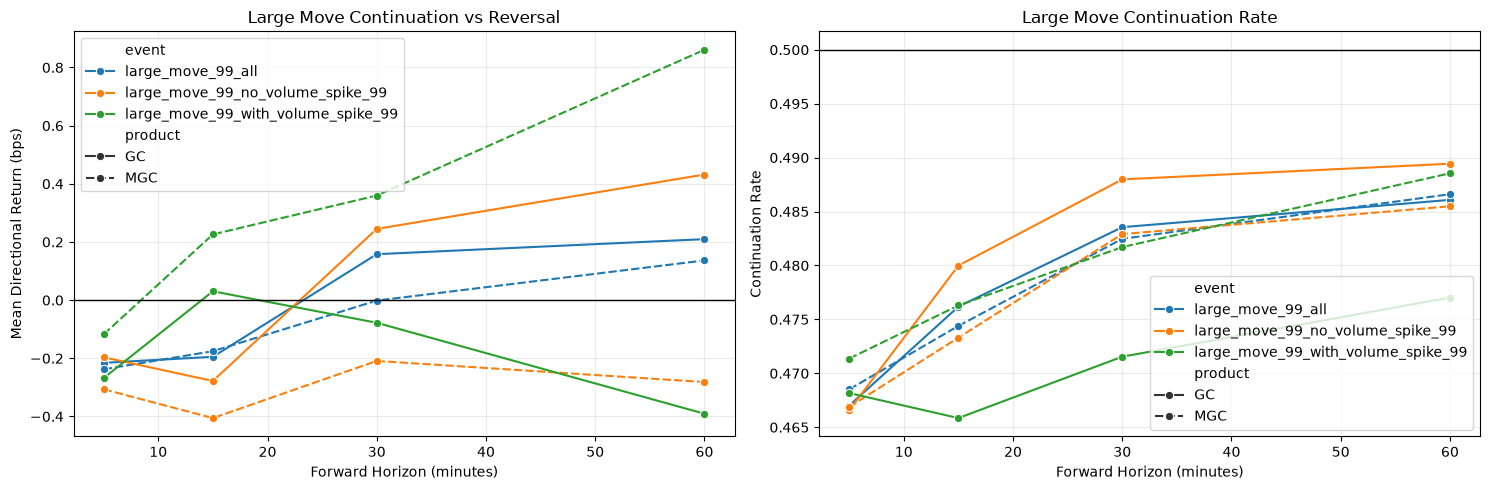

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_data = mean_reversion_signal_summary[mean_reversion_signal_summary["event"].isin([
    "large_move_99_all", "large_move_99_no_volume_spike_99", "large_move_99_with_volume_spike_99"
])]

sns.lineplot(data=plot_data, x="horizon_minutes", y="mean_directional_bps", hue="event", style="product", marker="o", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Large Move Continuation vs Reversal")
axes[0].set_xlabel("Forward Horizon (minutes)")
axes[0].set_ylabel("Mean Directional Return (bps)")
axes[0].grid(alpha=0.25)

sns.lineplot(data=plot_data, x="horizon_minutes", y="continuation_rate", hue="event", style="product", marker="o", ax=axes[1])
axes[1].axhline(0.5, color="black", linewidth=1)
axes[1].set_title("Large Move Continuation Rate")
axes[1].set_xlabel("Forward Horizon (minutes)")
axes[1].set_ylabel("Continuation Rate")
axes[1].grid(alpha=0.25)

plt.tight_layout()


**3.8 Preliminary Signal Exploration Notes**

* These outputs are event-study diagnostics, not backtest results.
* `signal_frame` is the reusable table for preliminary signal research.
* Forward returns are computed within the same active contract symbol to avoid contract-switch contamination.
* Positive `mean_directional_bps` means continuation after the event condition.
* Negative `mean_directional_bps` means reversal/mean reversion after the event condition.
* Ideas that survive this stage should be promoted into explicit strategy rules with costs, slippage, stops, exits, and walk-forward validation.

**Next:** 3.9 EDA Findings & Research Implications.


**3.8 Output Findings Report**

This section is an event-study layer. It is not a backtest and it does not yet include transaction costs, slippage, stops, exits, position sizing, or walk-forward validation. The purpose is to test whether the EDA variables contain useful conditional behavior after an event appears.

The reusable table is `signal_frame`:

```text
Rows: 3,493,615
Products: GC and MGC
Symbols: 52 active contracts
Forward horizons: 5, 15, 30, and 60 minutes
```

Forward returns are computed inside each `product` and `symbol`, which is important because it avoids contaminating signal results across contract rolls.

### 3.8.1 Volume-Based Ideas

The volume tests looked at the top volume deciles, 95th percentile volume spikes, 99th percentile volume spikes, and 99th percentile spikes split by whether the event bar closed up or down.

Main result:

```text
Volume is a strong activity and volatility filter, but not a clean standalone directional signal.
```

High-volume bars have much larger forward absolute movement. For example, after 99th percentile volume spikes, 60-minute mean absolute forward movement was roughly:

```text
GC:  31.8 bps
MGC: 47.1 bps
```

That is economically meaningful movement, especially for later stop and target design. But the directional continuation statistics were weak. For ordinary volume spike events, continuation rates stayed below 50 percent across most horizons.

Examples from the 99th percentile volume spike test:

```text
GC 5m continuation rate:  46.9%
GC 60m continuation rate: 48.6%

MGC 5m continuation rate:  47.1%
MGC 60m continuation rate: 48.6%
```

The split between up-spike bars and down-spike bars is more interesting. Up volume-spike bars had better continuation statistics at longer horizons, especially in MGC, while down volume-spike bars showed weaker continuation. This suggests that volume may help once combined with direction, session, and volatility regime.

Research relevance:

```text
Do not trade raw volume spikes directionally.
Use volume spikes as a context filter for volatility, event intensity, stop distance, and whether a breakout or large move is meaningful.
```

### 3.8.2 Volatility-Based Ideas

The volatility-regime results are one of the strongest findings in the whole EDA.

Forward absolute movement increases cleanly from low volatility to extreme volatility. The 60-minute mean absolute forward movement was approximately:

```text
Low regime:     GC 8.65 bps,  MGC 8.81 bps
Normal regime:  GC 12.10 bps, MGC 12.25 bps
High regime:    GC 17.15 bps, MGC 17.31 bps
Extreme regime: GC 29.77 bps, MGC 29.95 bps
```

This is useful because volatility regime gives us a direct way to adjust expectations. The same entry signal should not use the same stop, target, or position size in low volatility and extreme volatility.

The directional component is less clean. Extreme volatility had larger movement, but not a simple bullish or bearish bias. Positive rates were close to 50 percent and signed means can be distorted by large tails.

The large-move-by-volatility test adds an important nuance:

```text
Large moves in low and normal volatility leaned more toward reversal.
Large moves in high and extreme volatility were more mixed and sometimes showed longer-horizon continuation behavior.
```

Research relevance:

```text
Volatility regime should be a core risk-management feature.
It should also be used to separate fade logic from continuation logic.
Low/normal-vol shocks may be better fade candidates.
Extreme-vol shocks need wider risk controls and separate testing.
```

### 3.8.3 Session-Based Ideas

The session tests confirm what earlier EDA already suggested: session matters a lot.

New York and London produce different forward-return environments than Overnight/Asia and Post-NY. New York generally contains the most activity and the largest concentration of useful tradable movement. London is also active, but its breakout behavior later looked weaker. Overnight has lower regular activity, but its shock behavior appears more interesting than its average behavior.

The session-volume-spike tests are especially important. A 99th percentile volume spike does not mean the same thing in every session. In thinner sessions, a spike can represent a more unusual information event. In New York, a spike can occur inside normal high-activity trading and may be more two-way/noisy.

Research relevance:

```text
Signals should be researched by session, not only on the full combined dataset.
A setup that fails overall may still work in one session.
A setup that looks acceptable overall may be hiding bad behavior in another session.
```

The practical direction is to build separate tests for:

```text
New York large-move fades
London breakout/failure behavior
Overnight shock continuation
Post-NY low-liquidity risk filters
```

### 3.8.4 Breakout Behavior

The 60-minute breakout test is a very useful negative result.

Breakouts were not rare, but they were not dominant either:

```text
GC breakout rate:  5.24% of bars
MGC breakout rate: 5.42% of bars
```

Naive breakout follow-through was weak. Across GC and MGC, mean breakout follow-through was generally negative, and follow-through rates were below 50 percent.

Examples for all 60-minute breakouts:

```text
GC 5m mean follow-through:  -0.29 bps, follow-through rate 43.8%
GC 60m mean follow-through: -0.40 bps, follow-through rate 46.6%

MGC 5m mean follow-through:  -0.36 bps, follow-through rate 43.0%
MGC 60m mean follow-through: -0.42 bps, follow-through rate 46.5%
```

Adding volume did not automatically make the breakout work. Volume-spike breakouts still showed weak or negative follow-through in many cases. London breakouts looked especially vulnerable to failure/fade behavior.

Research relevance:

```text
Do not assume breakout equals continuation in gold futures.
Naive breakout entries are likely poor.
Breakout failure, retest, or fade logic may be more promising than simple breakout chasing.
```

A better next test is not simply "buy breakout / sell breakdown". It should include filters such as:

```text
Session
Volatility regime
Breakout distance
Volume confirmation
Retest behavior
Time since session open
Prior trend context
```

### 3.8.5 Mean Reversion Behavior

The large-move event study tested whether extreme one-minute moves tend to continue or reverse.

Across all large 99th percentile moves, short-horizon behavior leaned slightly toward reversal. Continuation rates were below 50 percent at all horizons for most event groups, although they moved closer to 50 percent as the horizon increased.

Examples for all large moves:

```text
GC 5m continuation rate:  46.7%
GC 60m continuation rate: 48.6%

MGC 5m continuation rate:  46.9%
MGC 60m continuation rate: 48.7%
```

The session split matters. New York large moves were mostly weak/noisy after the event and looked more suitable for fade testing. Overnight large moves were more interesting at longer horizons, with more evidence of 30- to 60-minute continuation than the full sample.

Volume confirmation was mixed. Large moves with 99th percentile volume spikes had more movement after the event, but the direction was not consistently better.

Research relevance:

```text
Large-move behavior is conditional, not universal.
The most promising split is session-specific:
New York large-move fade tests and Overnight large-move continuation tests.
```

### Section 3.8 Bottom Line

The early signal exploration does not support a simple unconditional edge such as:

```text
High volume means continue.
Breakout means continue.
Large move means always fade.
```

The data points toward conditional strategy research:

```text
Volume = context and intensity filter
Volatility regime = risk and opportunity filter
Session = market-state filter
Breakout = possible failure/fade setup, not naive continuation
Large move = session-dependent fade/continuation candidate
```


## 3.9 EDA Findings & Research Implications

This section closes the EDA phase and converts the research findings into practical direction for the next phase of the project.

### 3.9.1 Data Quality Conclusion

The cleaned Databento OHLCV data is suitable for research.

Key points:

```text
No missing values were found in the core OHLCV columns.
No true duplicate timestamp-symbol records were found.
Timestamps are minute-aligned and timezone-aware.
Observed gaps are mostly expected futures-session gaps, not obvious data corruption.
```

Research implication:

```text
The dataset can be used for systematic research, but all future tests should continue to respect session structure, contract rolls, and active-contract selection.
```

### 3.9.2 Contract Structure Conclusion

GC and MGC have different contract listings and lifespans, but both concentrate real trading activity in a small set of major delivery months.

The most important practical result is that the active/front contract must be selected from actual liquidity, not from a hard-coded contract calendar.

Research implication:

```text
Use liquidity-based active contract logic.
Avoid building signals across inactive or thin contracts.
Avoid naive continuous-contract logic until rollover handling is explicitly defined.
```

### 3.9.3 Liquidity Conclusion

Liquidity is highly concentrated in the dominant contract most of the time.

GC and MGC both showed strong dominant-contract volume share, with liquidity migration occurring around roll windows.

Research implication:

```text
The active-front dataset is the correct base universe for strategy research.
Signals should be generated on the active contract only.
Rollover periods should be flagged and tested separately before live-style assumptions are made.
```

### 3.9.4 Session Conclusion

Session structure is one of the strongest EDA findings.

New York is the main liquidity and volatility window. London matters. Overnight and Post-NY are different environments and should not be blindly mixed with regular high-liquidity trading.

Research implication:

```text
Future strategy tests should be session-aware.
Performance should be reported separately by session.
Stops, targets, and position sizing may need session-specific calibration.
```

### 3.9.5 Volatility Conclusion

Gold futures have fat-tailed returns and strong volatility clustering.

Minute returns have many small/zero bars, but extreme bars occur often enough to matter. Daily volatility is persistent, and volatility regimes separate future movement magnitude very clearly.

Research implication:

```text
Volatility regime should be a core feature in the research pipeline.
It should influence position sizing, stop distance, target distance, and whether certain signals are allowed.
```

### 3.9.6 Return Behavior Conclusion

Unconditional return behavior is weak.

Minute and daily return autocorrelations are small and unstable. The EDA does not support a simple always-on trend-following or mean-reversion assumption.

Research implication:

```text
Do not build the first strategy around unconditional return autocorrelation.
Research conditional behavior instead: session, volatility regime, volume, breakout state, and large-move state.
```

### 3.9.7 Market Microstructure Conclusion

Volume has a strong relationship with absolute price movement and bar range, but weak standalone directional value.

Large moves overlap with volume spikes only part of the time. That means price shock and volume shock are related, but not identical, information states.

Research implication:

```text
Use volume as a state/context feature, not as a simple buy/sell trigger.
Large moves with and without volume confirmation should be tested separately.
```

### 3.9.8 Preliminary Signal Conclusion

Section 3.8 showed that simple raw triggers are not enough.

The strongest preliminary research directions are conditional:

```text
New York large-move fade tests
Overnight large-move continuation tests
Breakout failure and retest tests
Volatility-regime-aware stop/target sizing
Volume-spike filters for event intensity
Session-specific signal evaluation
```

The weakest preliminary direction is naive breakout continuation. The 60-minute breakout study showed negative mean follow-through and below-50-percent follow-through rates across the broad sample.

Research implication:

```text
Avoid assuming that breakouts in gold futures naturally continue.
If breakout logic is researched, start with failure/retest behavior and strict filters.
```

### 3.9.9 Recommended Research Pipeline After EDA

The next phase should promote EDA objects into a more formal research workflow.

Recommended base tables:

```text
active_front      = active/liquid contract bars
bar_features      = engineered intraday features
signal_frame      = event-study and forward-return research frame
```

Recommended first strategy prototypes:

```text
1. New York large-move fade prototype
2. Overnight large-move continuation prototype
3. Breakout failure/retest prototype
4. Volume-spike plus volatility-regime filter prototype
5. Volatility-regime-aware risk sizing prototype
```

Each prototype should include:

```text
Explicit entry rules
Explicit exit rules
Stop and target logic
Transaction costs
Slippage assumptions
Session filter
Rollover filter
Volatility-regime filter
Train/test or walk-forward validation
```

### 3.9.10 EDA Final Conclusion

The EDA phase is complete enough to move into structured signal research.

The data does not point to a simple one-variable edge. It points to a professional research path where edge, if it exists, is likely conditional on market state.

Final EDA thesis:

```text
Gold futures are liquid enough for systematic intraday research.
The active contract should be selected by liquidity.
Session and volatility regime are essential state variables.
Volume predicts activity better than direction.
Naive breakouts are weak and may be better studied as failure/retest setups.
Large moves are session-dependent and should be split between fade and continuation hypotheses.
```

**EDA phase complete. Next phase: structured signal research and first strategy prototypes.**


## 4.0 Research Dataset Construction & Continuous Active Contract Series

Section 4 turns the cleaned multi-contract GC/MGC dataset into the final active/front-month research dataset.

This is infrastructure work, not strategy development. The goal is to produce a clean, validated minute-level table that Section 5 can use to formalize the discretionary POI strategy into objective rules.

### 4.1 Final Active Contract Selection Rules

The active contract should be selected from observed liquidity rather than hard-coded expiry assumptions. Gold futures liquidity migrates around roll periods, but the exact active contract should be determined from the data.

The rule below starts from daily contract volume, smooths it with a 5-trading-day rolling sum, and then applies conservative confirmation logic:

```text
Universe: GC and MGC outright contracts only; spreads excluded.
Selection level: one active contract per product per UTC trade date.
Raw daily winner: highest same-day volume by product/date.
Rolling winner: highest 5-day rolling volume by product/date.
Normal confirmed switch: rolling winner persists for at least 2 product-days, has at least 50% daily product volume, and leads the prior selected contract by at least 1.10x on rolling volume.
Decisive same-day switch: rolling winner has at least 80% daily product volume, the prior selected contract has no more than 20%, and the rolling-volume lead is at least 1.10x.
Ambiguous transition: if neither switch rule passes, retain the prior selected contract and flag the day.
```

This rule is deliberately simple and auditable. It prevents one-day noise from causing unnecessary rolls, while also avoiding the opposite error of staying on an illiquid old contract after liquidity has clearly migrated.

In [130]:
active_contract_selection_rules = {
    "rolling_window_days": 5,
    "min_raw_winner_persistence_days": 2,
    "min_candidate_daily_volume_share": 0.50,
    "min_candidate_to_current_rolling_volume_ratio": 1.10,
    "strong_candidate_daily_volume_share": 0.80,
    "max_current_daily_volume_share_for_fast_switch": 0.20,
}

pd.Series(active_contract_selection_rules, name="rule_value")

rolling_window_days                               5.0
min_raw_winner_persistence_days                   2.0
min_candidate_daily_volume_share                  0.5
min_candidate_to_current_rolling_volume_ratio     1.1
strong_candidate_daily_volume_share               0.8
max_current_daily_volume_share_for_fast_switch    0.2
Name: rule_value, dtype: float64

In [131]:
import time

_t0 = time.perf_counter()

section4_source = df
if "ts_event" in section4_source.columns:
    section4_source = section4_source.set_index("ts_event")

section4_symbol = section4_source["symbol"].astype("string")
section4_gc_mask = section4_symbol.str.match(r"^GC[FGHJKMNQUVXZ]\d+$", na=False)
section4_mgc_mask = section4_symbol.str.match(r"^MGC[FGHJKMNQUVXZ]\d+$", na=False)

# Rebuild the outright universe explicitly for Section 4 so this section does not
# depend on temporary EDA variables from prior cells.
outrights = pd.concat([
    section4_source.loc[section4_gc_mask].assign(product="GC"),
    section4_source.loc[section4_mgc_mask].assign(product="MGC"),
]).sort_index()

section4_minute_bars = outrights[["product", "symbol", "volume"]].reset_index()
section4_minute_bars["trade_date"] = (
    section4_minute_bars["ts_event"]
    .dt.tz_convert(None)
    .dt.normalize()
    .astype("datetime64[s]")
)

section4_daily_contract_volume = (
    section4_minute_bars
    .groupby(["trade_date", "product", "symbol"], observed=True)
    .agg(
        daily_volume=("volume", "sum"),
        bars=("symbol", "size"),
    )
    .reset_index()
)

section4_daily_product_volume = (
    section4_daily_contract_volume
    .groupby(["trade_date", "product"], observed=True)
    .agg(
        product_daily_volume=("daily_volume", "sum"),
        active_contracts=("symbol", "nunique"),
        product_bars=("bars", "sum"),
    )
    .reset_index()
)

active_contract_rankings = section4_daily_contract_volume.sort_values([
    "product",
    "symbol",
    "trade_date",
]).copy()

active_contract_rankings["rolling_5d_volume"] = (
    active_contract_rankings
    .groupby(["product", "symbol"], observed=True)["daily_volume"]
    .transform(lambda x: x.rolling(active_contract_selection_rules["rolling_window_days"], min_periods=1).sum())
)

active_contract_rankings = active_contract_rankings.merge(
    section4_daily_product_volume,
    on=["trade_date", "product"],
    how="left",
)
active_contract_rankings["daily_volume_share"] = (
    active_contract_rankings["daily_volume"] / active_contract_rankings["product_daily_volume"]
)
active_contract_rankings["daily_rank"] = (
    active_contract_rankings
    .groupby(["trade_date", "product"], observed=True)["daily_volume"]
    .rank(method="first", ascending=False)
)
active_contract_rankings["rolling_rank"] = (
    active_contract_rankings
    .groupby(["trade_date", "product"], observed=True)["rolling_5d_volume"]
    .rank(method="first", ascending=False)
)

raw_active_candidates = (
    active_contract_rankings
    .loc[active_contract_rankings["rolling_rank"].eq(1), [
        "trade_date",
        "product",
        "symbol",
        "daily_volume",
        "rolling_5d_volume",
        "daily_volume_share",
        "product_daily_volume",
        "active_contracts",
    ]]
    .rename(columns={
        "symbol": "raw_active_contract",
        "daily_volume": "raw_rolling_winner_daily_volume",
        "rolling_5d_volume": "raw_rolling_winner_5d_volume",
        "daily_volume_share": "raw_rolling_winner_daily_share",
    })
    .sort_values(["product", "trade_date"])
    .reset_index(drop=True)
)
raw_active_candidates["raw_contract_changed"] = raw_active_candidates["raw_active_contract"].ne(
    raw_active_candidates.groupby("product", observed=True)["raw_active_contract"].shift()
)
raw_active_candidates["raw_winner_run_id"] = (
    raw_active_candidates
    .groupby("product", observed=True)["raw_contract_changed"]
    .cumsum()
)
raw_active_candidates["raw_winner_streak_days"] = (
    raw_active_candidates
    .groupby(["product", "raw_winner_run_id"], observed=True)
    .cumcount()
    .add(1)
)

active_contract_ranking_build_seconds = time.perf_counter() - _t0

active_contract_candidate_quality = raw_active_candidates.groupby("product", observed=True).agg(
    product_days=("trade_date", "nunique"),
    raw_rolling_contracts_selected=("raw_active_contract", "nunique"),
    median_raw_rolling_winner_daily_share=("raw_rolling_winner_daily_share", "median"),
    mean_raw_rolling_winner_daily_share=("raw_rolling_winner_daily_share", "mean"),
    min_raw_rolling_winner_daily_share=("raw_rolling_winner_daily_share", "min"),
    build_seconds=("trade_date", lambda _: round(active_contract_ranking_build_seconds, 2)),
)

active_contract_candidate_quality

,product_days,raw_rolling_contracts_selected,median_raw_rolling_winner_daily_share,mean_raw_rolling_winner_daily_share,min_raw_rolling_winner_daily_share,build_seconds
product,,,,,,
GC,1555,26,0.970085,0.933524,0.002874,5.3
MGC,1555,26,0.974926,0.931605,0.002777,5.3


In [132]:
def build_final_active_contract_schedule(raw_candidates, rankings, rules):
    """Build the confirmed daily active-contract schedule from liquidity rankings."""
    ranking_lookup = rankings.set_index(["trade_date", "product", "symbol"])
    schedule_rows = []

    for product, product_candidates in raw_candidates.groupby("product", observed=True, sort=False):
        selected_contract = None

        for row in product_candidates.itertuples(index=False):
            candidate_contract = row.raw_active_contract
            candidate_rolling_volume = float(row.raw_rolling_winner_5d_volume)
            candidate_daily_share = float(row.raw_rolling_winner_daily_share)
            candidate_daily_volume = float(row.raw_rolling_winner_daily_volume)

            if selected_contract is None or selected_contract == candidate_contract:
                final_contract = candidate_contract
                final_rolling_volume = candidate_rolling_volume
                final_daily_share = candidate_daily_share
                final_daily_volume = candidate_daily_volume
                current_daily_share = candidate_daily_share
                candidate_to_current_ratio = 1.0
                selection_changed = selected_contract is None
                selection_reason = "initial_selection" if selected_contract is None else "same_contract"
                selected_contract = final_contract
            else:
                current_key = (row.trade_date, product, selected_contract)

                if current_key in ranking_lookup.index:
                    current_row = ranking_lookup.loc[current_key]
                    current_rolling_volume = float(current_row["rolling_5d_volume"])
                    current_daily_share = float(current_row["daily_volume_share"])
                    current_daily_volume = float(current_row["daily_volume"])
                else:
                    current_rolling_volume = 0.0
                    current_daily_share = 0.0
                    current_daily_volume = 0.0

                candidate_to_current_ratio = (
                    candidate_rolling_volume / current_rolling_volume
                    if current_rolling_volume > 0
                    else np.inf
                )

                persistent_switch_is_confirmed = (
                    row.raw_winner_streak_days >= rules["min_raw_winner_persistence_days"]
                    and candidate_daily_share >= rules["min_candidate_daily_volume_share"]
                    and candidate_to_current_ratio >= rules["min_candidate_to_current_rolling_volume_ratio"]
                )
                decisive_switch_is_confirmed = (
                    candidate_daily_share >= rules["strong_candidate_daily_volume_share"]
                    and current_daily_share <= rules["max_current_daily_volume_share_for_fast_switch"]
                    and candidate_to_current_ratio >= rules["min_candidate_to_current_rolling_volume_ratio"]
                )
                switch_is_confirmed = (
                    persistent_switch_is_confirmed
                    or decisive_switch_is_confirmed
                    or current_rolling_volume == 0.0
                )

                if switch_is_confirmed:
                    final_contract = candidate_contract
                    final_rolling_volume = candidate_rolling_volume
                    final_daily_share = candidate_daily_share
                    final_daily_volume = candidate_daily_volume
                    selection_changed = True
                    selection_reason = (
                        "decisive_same_day_liquidity_migration"
                        if decisive_switch_is_confirmed and not persistent_switch_is_confirmed
                        else "confirmed_liquidity_migration"
                    )
                    selected_contract = final_contract
                else:
                    final_contract = selected_contract
                    final_rolling_volume = current_rolling_volume
                    final_daily_share = current_daily_share
                    final_daily_volume = current_daily_volume
                    selection_changed = False
                    selection_reason = "retain_previous_contract_ambiguous_roll"

            schedule_rows.append({
                "trade_date": row.trade_date,
                "product": product,
                "final_active_contract": final_contract,
                "raw_active_contract": candidate_contract,
                "raw_winner_streak_days": int(row.raw_winner_streak_days),
                "raw_rolling_winner_daily_share": candidate_daily_share,
                "final_daily_volume": final_daily_volume,
                "final_daily_volume_share": final_daily_share,
                "raw_candidate_rolling_5d_volume": candidate_rolling_volume,
                "final_contract_rolling_5d_volume": final_rolling_volume,
                "candidate_to_current_rolling_ratio": candidate_to_current_ratio,
                "selection_changed": selection_changed,
                "selection_reason": selection_reason,
            })

    schedule = pd.DataFrame(schedule_rows)
    schedule["previous_final_active_contract"] = (
        schedule
        .groupby("product", observed=True)["final_active_contract"]
        .shift()
    )
    schedule["final_contract_changed"] = (
        schedule["previous_final_active_contract"].notna()
        & schedule["final_active_contract"].ne(schedule["previous_final_active_contract"])
    )
    schedule["ambiguous_roll_candidate"] = schedule["selection_reason"].eq(
        "retain_previous_contract_ambiguous_roll"
    )

    return schedule


final_active_contract_schedule = build_final_active_contract_schedule(
    raw_candidates=raw_active_candidates,
    rankings=active_contract_rankings,
    rules=active_contract_selection_rules,
)

active_contract_selection_summary = final_active_contract_schedule.groupby("product", observed=True).agg(
    product_days=("trade_date", "nunique"),
    final_active_contracts=("final_active_contract", "nunique"),
    confirmed_switches=("final_contract_changed", "sum"),
    ambiguous_roll_days=("ambiguous_roll_candidate", "sum"),
    median_final_daily_volume_share=("final_daily_volume_share", "median"),
    mean_final_daily_volume_share=("final_daily_volume_share", "mean"),
    min_final_daily_volume_share=("final_daily_volume_share", "min"),
)

active_contract_selection_summary

,product_days,final_active_contracts,confirmed_switches,ambiguous_roll_days,median_final_daily_volume_share,mean_final_daily_volume_share,min_final_daily_volume_share
product,,,,,,,
GC,1555,26,25,6,0.970085,0.930111,0.002874
MGC,1555,26,25,4,0.974815,0.929331,0.002777


In [133]:
daily_volume_winners = (
    active_contract_rankings
    .loc[active_contract_rankings["daily_rank"].eq(1), [
        "trade_date",
        "product",
        "symbol",
        "daily_volume",
        "daily_volume_share",
    ]]
    .rename(columns={
        "symbol": "raw_daily_volume_winner",
        "daily_volume": "raw_daily_winner_volume",
        "daily_volume_share": "raw_daily_winner_volume_share",
    })
)

rolling_volume_winners = (
    active_contract_rankings
    .loc[active_contract_rankings["rolling_rank"].eq(1), [
        "trade_date",
        "product",
        "symbol",
        "rolling_5d_volume",
        "daily_volume_share",
    ]]
    .rename(columns={
        "symbol": "rolling_volume_winner",
        "rolling_5d_volume": "rolling_winner_5d_volume",
        "daily_volume_share": "rolling_winner_daily_volume_share",
    })
)

selected_contract_metrics = (
    active_contract_rankings[[
        "trade_date",
        "product",
        "symbol",
        "daily_volume",
        "daily_volume_share",
        "rolling_5d_volume",
        "daily_rank",
        "rolling_rank",
    ]]
    .rename(columns={
        "symbol": "active_symbol",
        "daily_volume": "selected_contract_volume",
        "daily_volume_share": "selected_contract_volume_share",
        "rolling_5d_volume": "selected_contract_rolling_5d_volume",
        "daily_rank": "selected_contract_daily_rank",
        "rolling_rank": "selected_contract_rolling_rank",
    })
)

active_contract_daily = (
    final_active_contract_schedule
    .rename(columns={
        "final_active_contract": "active_symbol",
        "previous_final_active_contract": "previous_active_symbol",
        "selection_reason": "selection_method",
    })
    .merge(
        section4_daily_product_volume.rename(columns={"product_daily_volume": "total_product_volume"}),
        on=["trade_date", "product"],
        how="left",
    )
    .merge(daily_volume_winners, on=["trade_date", "product"], how="left")
    .merge(rolling_volume_winners, on=["trade_date", "product"], how="left")
    .merge(selected_contract_metrics, on=["trade_date", "product", "active_symbol"], how="left")
    .sort_values(["product", "trade_date"])
    .reset_index(drop=True)
)

active_contract_daily["final_selected_contract"] = active_contract_daily["active_symbol"]
active_contract_daily["selected_active_symbol"] = active_contract_daily["active_symbol"]

active_contract_daily = active_contract_daily[[
    "product",
    "trade_date",
    "selected_active_symbol",
    "active_symbol",
    "previous_active_symbol",
    "total_product_volume",
    "selected_contract_volume",
    "selected_contract_volume_share",
    "active_contracts",
    "raw_daily_volume_winner",
    "raw_daily_winner_volume",
    "raw_daily_winner_volume_share",
    "rolling_volume_winner",
    "rolling_winner_5d_volume",
    "rolling_winner_daily_volume_share",
    "raw_active_contract",
    "raw_winner_streak_days",
    "final_selected_contract",
    "selected_contract_rolling_5d_volume",
    "selected_contract_daily_rank",
    "selected_contract_rolling_rank",
    "candidate_to_current_rolling_ratio",
    "selection_method",
    "selection_changed",
    "final_contract_changed",
    "ambiguous_roll_candidate",
]]

active_contract_daily_validation = pd.Series({
    "rows": len(active_contract_daily),
    "products": active_contract_daily["product"].nunique(),
    "duplicate_product_dates": active_contract_daily.duplicated(["product", "trade_date"]).sum(),
    "spread_symbols_selected": active_contract_daily["active_symbol"].astype("string").str.contains("-", regex=False).sum(),
    "gc_mgc_symbol_mismatch": (
        (
            active_contract_daily["product"].eq("GC")
            & ~active_contract_daily["active_symbol"].astype("string").str.match(r"^GC[FGHJKMNQUVXZ]\d+$", na=False)
        )
        | (
            active_contract_daily["product"].eq("MGC")
            & ~active_contract_daily["active_symbol"].astype("string").str.match(r"^MGC[FGHJKMNQUVXZ]\d+$", na=False)
        )
    ).sum(),
    "missing_selected_volume": active_contract_daily["selected_contract_volume"].isna().sum(),
    "min_selected_volume_share": active_contract_daily["selected_contract_volume_share"].min(),
    "low_share_days_below_20pct": active_contract_daily["selected_contract_volume_share"].lt(0.20).sum(),
})

active_contract_daily_validation

rows                          3110.000000
products                         2.000000
duplicate_product_dates          0.000000
spread_symbols_selected          0.000000
gc_mgc_symbol_mismatch           0.000000
missing_selected_volume          0.000000
min_selected_volume_share        0.002777
low_share_days_below_20pct      71.000000
dtype: float64

In [134]:
active_contract_daily.groupby("product", observed=True).agg(
    product_days=("trade_date", "nunique"),
    selected_contracts=("active_symbol", "nunique"),
    daily_winner_match_rate=("raw_daily_volume_winner", lambda x: x.eq(active_contract_daily.loc[x.index, "active_symbol"]).mean()),
    rolling_winner_match_rate=("rolling_volume_winner", lambda x: x.eq(active_contract_daily.loc[x.index, "active_symbol"]).mean()),
    median_selected_volume_share=("selected_contract_volume_share", "median"),
    min_selected_volume_share=("selected_contract_volume_share", "min"),
    ambiguous_roll_candidate_days=("ambiguous_roll_candidate", "sum"),
)

,product_days,selected_contracts,daily_winner_match_rate,rolling_winner_match_rate,median_selected_volume_share,min_selected_volume_share,ambiguous_roll_candidate_days
product,,,,,,,
GC,1555,26,0.971704,0.996141,0.970085,0.002874,6
MGC,1555,26,0.968489,0.997428,0.974815,0.002777,4


**4.1 Selection Rule Notes**

`active_contract_daily` is the production daily active-contract table for Section 4. It keeps daily-volume winners, rolling-volume winners, final selected symbols, selected-volume share, active-contract counts, and the selection method used on each product/date.

The low selected-volume-share days are not ignored. They are carried forward as rollover diagnostics and are handled by the rollover warning/exclusion flags below.

### 4.2 Rollover Safeguards

Rollover periods are dangerous for signal research because price changes can reflect contract switching rather than tradable market movement. Liquidity can also split across old and new contracts, which changes spreads, slippage assumptions, and signal reliability.

This subsection detects every active-contract change and creates daily rollover fields that can be merged into the minute-level dataset. Roll days are not deleted here. They are explicitly flagged.

In [135]:
active_contract_daily["is_roll_day"] = (
    active_contract_daily["previous_active_symbol"].notna()
    & active_contract_daily["active_symbol"].ne(active_contract_daily["previous_active_symbol"])
)
active_contract_daily["roll_group_id"] = (
    active_contract_daily
    .groupby("product", observed=True)["is_roll_day"]
    .cumsum()
    .add(1)
    .astype("int16")
)
active_contract_daily["product_trade_day_index"] = (
    active_contract_daily
    .groupby("product", observed=True)
    .cumcount()
    .astype("int32")
)

last_roll_index = (
    active_contract_daily["product_trade_day_index"]
    .where(active_contract_daily["is_roll_day"])
    .groupby(active_contract_daily["product"], observed=True)
    .ffill()
)
next_roll_index = (
    active_contract_daily["product_trade_day_index"]
    .where(active_contract_daily["is_roll_day"])
    .groupby(active_contract_daily["product"], observed=True)
    .bfill()
)

active_contract_daily["days_since_roll"] = (
    active_contract_daily["product_trade_day_index"] - last_roll_index
).astype("Int16")
active_contract_daily["days_to_next_roll"] = (
    next_roll_index - active_contract_daily["product_trade_day_index"]
).astype("Int16")

active_contract_daily["roll_transition_label"] = pd.NA
roll_mask = active_contract_daily["is_roll_day"]
active_contract_daily.loc[roll_mask, "roll_transition_label"] = (
    active_contract_daily.loc[roll_mask, "previous_active_symbol"].astype("string")
    + " -> "
    + active_contract_daily.loc[roll_mask, "active_symbol"].astype("string")
)

old_contract_metrics = (
    active_contract_rankings[[
        "trade_date",
        "product",
        "symbol",
        "daily_volume",
        "daily_volume_share",
        "rolling_5d_volume",
    ]]
    .rename(columns={
        "symbol": "previous_active_symbol",
        "daily_volume": "old_contract_volume",
        "daily_volume_share": "old_contract_volume_share",
        "rolling_5d_volume": "old_contract_rolling_5d_volume",
    })
)

rollover_summary = (
    active_contract_daily
    .loc[active_contract_daily["is_roll_day"], [
        "product",
        "trade_date",
        "previous_active_symbol",
        "active_symbol",
        "selected_contract_volume",
        "selected_contract_volume_share",
        "selected_contract_rolling_5d_volume",
        "total_product_volume",
        "active_contracts",
        "selection_method",
        "candidate_to_current_rolling_ratio",
        "roll_group_id",
        "roll_transition_label",
    ]]
    .merge(old_contract_metrics, on=["trade_date", "product", "previous_active_symbol"], how="left")
    .rename(columns={
        "trade_date": "roll_date",
        "previous_active_symbol": "old_active_contract",
        "active_symbol": "new_active_contract",
        "selected_contract_volume": "new_contract_volume",
        "selected_contract_volume_share": "new_contract_volume_share",
        "selected_contract_rolling_5d_volume": "new_contract_rolling_5d_volume",
    })
    .sort_values(["product", "roll_date"])
    .reset_index(drop=True)
)

rollover_summary[["old_contract_volume", "old_contract_volume_share", "old_contract_rolling_5d_volume"]] = (
    rollover_summary[["old_contract_volume", "old_contract_volume_share", "old_contract_rolling_5d_volume"]]
    .fillna(0.0)
)
rollover_summary["old_contract_still_liquid_flag"] = rollover_summary["old_contract_volume_share"].gt(0.20)
rollover_summary["new_contract_low_share_flag"] = rollover_summary["new_contract_volume_share"].lt(0.50)
rollover_summary["unusual_roll_flag"] = (
    rollover_summary["old_contract_still_liquid_flag"]
    | rollover_summary["new_contract_low_share_flag"]
)


def describe_roll(row):
    notes = []
    if row["new_contract_low_share_flag"]:
        notes.append("new_contract_share_below_50pct")
    if row["old_contract_still_liquid_flag"]:
        notes.append("old_contract_still_above_20pct")
    if row["selection_method"] == "decisive_same_day_liquidity_migration":
        notes.append("decisive_same_day_liquidity_migration")
    if row["selection_method"] == "confirmed_liquidity_migration":
        notes.append("confirmed_persistent_liquidity_migration")
    return "; ".join(notes) if notes else "normal_liquidity_migration"


rollover_summary["roll_notes"] = rollover_summary.apply(describe_roll, axis=1)

rollover_summary[[
    "product",
    "roll_date",
    "old_active_contract",
    "new_active_contract",
    "old_contract_volume",
    "new_contract_volume",
    "old_contract_volume_share",
    "new_contract_volume_share",
    "roll_transition_label",
    "unusual_roll_flag",
    "roll_notes",
]].tail(30)

,product,roll_date,old_active_contract,new_active_contract,old_contract_volume,new_contract_volume,old_contract_volume_share,new_contract_volume_share,roll_transition_label,unusual_roll_flag,roll_notes
20,GC,2025-05-29,GCM5,GCQ5,6403,190324,0.031731,0.943174,GCM5 -> GCQ5,False,decisive_same_day_liquidity_migration
21,GC,2025-07-31,GCQ5,GCZ5,1047,149152,0.006394,0.910919,GCQ5 -> GCZ5,False,confirmed_persistent_liquidity_migration
22,GC,2025-11-27,GCZ5,GCG6,281,71513,0.003808,0.969168,GCZ5 -> GCG6,False,decisive_same_day_liquidity_migration
23,GC,2026-01-29,GCG6,GCJ6,8591,503462,0.015973,0.936064,GCG6 -> GCJ6,False,decisive_same_day_liquidity_migration
24,GC,2026-03-31,GCJ6,GCM6,887,171808,0.004915,0.952082,GCJ6 -> GCM6,False,confirmed_persistent_liquidity_migration
25,MGC,2021-05-30,MGCM1,MGCQ1,12,640,0.018045,0.962406,MGCM1 -> MGCQ1,False,decisive_same_day_liquidity_migration
26,MGC,2021-08-02,MGCQ1,MGCZ1,60,31843,0.001636,0.867988,MGCQ1 -> MGCZ1,False,confirmed_persistent_liquidity_migration
27,MGC,2021-11-30,MGCZ1,MGCG2,165,72984,0.002224,0.983705,MGCZ1 -> MGCG2,False,decisive_same_day_liquidity_migration
28,MGC,2022-02-01,MGCG2,MGCJ2,44,27598,0.001567,0.982835,MGCG2 -> MGCJ2,False,decisive_same_day_liquidity_migration
29,MGC,2022-03-31,MGCJ2,MGCM2,76,51277,0.001466,0.988968,MGCJ2 -> MGCM2,False,decisive_same_day_liquidity_migration


In [136]:
rollover_validation = pd.Series({
    "rollover_rows": len(rollover_summary),
    "gc_rolls": rollover_summary["product"].eq("GC").sum(),
    "mgc_rolls": rollover_summary["product"].eq("MGC").sum(),
    "missing_old_contract_volume": rollover_summary["old_contract_volume"].isna().sum(),
    "missing_new_contract_volume": rollover_summary["new_contract_volume"].isna().sum(),
    "unusual_rolls": rollover_summary["unusual_roll_flag"].sum(),
    "daily_roll_flags": active_contract_daily["is_roll_day"].sum(),
})

rollover_validation

rollover_rows                  50
gc_rolls                       25
mgc_rolls                      25
missing_old_contract_volume     0
missing_new_contract_volume     0
unusual_rolls                   0
daily_roll_flags               50
dtype: int64

### 4.3 Continuous Front-Month Series Construction

The continuous active/front-month series is built by joining the final daily active-contract table back onto the minute-level GC/MGC outright bars and keeping only the selected active symbol for each product/date.

This is a raw stitched active-contract series. Prices are not back-adjusted. That is intentional for now: raw tradable prices plus explicit rollover flags are more transparent for early signal research than an adjusted series that may hide roll mechanics.

In [137]:
_t0 = time.perf_counter()

minute_bar_columns = [
    "ts_event",
    "product",
    "symbol",
    "rtype",
    "publisher_id",
    "instrument_id",
    "open",
    "high",
    "low",
    "close",
    "volume",
]

outright_minute_bars = outrights.reset_index()[minute_bar_columns]
outright_minute_bars["trade_date"] = (
    outright_minute_bars["ts_event"]
    .dt.tz_convert(None)
    .dt.normalize()
    .astype("datetime64[s]")
)

active_daily_cols_for_minutes = [
    "product",
    "trade_date",
    "active_symbol",
    "previous_active_symbol",
    "total_product_volume",
    "selected_contract_volume",
    "selected_contract_volume_share",
    "active_contracts",
    "raw_daily_volume_winner",
    "rolling_volume_winner",
    "selection_method",
    "ambiguous_roll_candidate",
    "is_roll_day",
    "roll_group_id",
    "days_since_roll",
    "days_to_next_roll",
    "roll_transition_label",
]

active_front_final = (
    outright_minute_bars
    .merge(active_contract_daily[active_daily_cols_for_minutes], on=["product", "trade_date"], how="inner")
)
active_front_final = (
    active_front_final
    .loc[active_front_final["symbol"].eq(active_front_final["active_symbol"])]
    .rename(columns={"ts_event": "ts_event_utc"})
    .sort_values(["product", "ts_event_utc"], ignore_index=True)
)

active_front_build_seconds = time.perf_counter() - _t0

active_front_validation = pd.Series({
    "rows": len(active_front_final),
    "products": active_front_final["product"].nunique(),
    "gc_rows": active_front_final["product"].eq("GC").sum(),
    "mgc_rows": active_front_final["product"].eq("MGC").sum(),
    "start_utc": active_front_final["ts_event_utc"].min(),
    "end_utc": active_front_final["ts_event_utc"].max(),
    "duplicate_timestamp_product_rows": active_front_final.duplicated(["ts_event_utc", "product"]).sum(),
    "missing_ohlcv_values": active_front_final[["open", "high", "low", "close", "volume"]].isna().sum().sum(),
    "spread_symbols": active_front_final["symbol"].astype("string").str.contains("-", regex=False).sum(),
    "symbol_active_symbol_mismatches": active_front_final["symbol"].ne(active_front_final["active_symbol"]).sum(),
    "build_seconds": round(active_front_build_seconds, 2),
})

active_front_validation

rows                                                  3487656
products                                                    2
gc_rows                                               1759671
mgc_rows                                              1727985
start_utc                           2021-05-24 00:00:00+00:00
end_utc                             2026-05-22 20:59:00+00:00
duplicate_timestamp_product_rows                            0
missing_ohlcv_values                                        0
spread_symbols                                              0
symbol_active_symbol_mismatches                             0
build_seconds                                            5.28
dtype: object

In [138]:
active_front_symbol_timeline = (
    active_front_final
    .groupby(["product", "symbol"], observed=True)
    .agg(
        first_bar=("ts_event_utc", "min"),
        last_bar=("ts_event_utc", "max"),
        bars=("symbol", "size"),
        trading_days=("trade_date", "nunique"),
        total_volume=("volume", "sum"),
        avg_selected_volume_share=("selected_contract_volume_share", "mean"),
    )
    .reset_index()
    .sort_values(["product", "first_bar"])
)

active_front_symbol_timeline.tail(30)

,product,symbol,first_bar,last_bar,bars,trading_days,total_volume,avg_selected_volume_share
25,GC,GCZ5,2025-07-31 00:00:00+00:00,2025-11-26 23:46:00+00:00,116557,102,18894200,0.941485
4,GC,GCG6,2025-11-27 00:00:00+00:00,2026-01-28 23:59:00+00:00,58058,54,8236610,0.925986
9,GC,GCJ6,2026-01-29 00:00:00+00:00,2026-03-30 23:36:00+00:00,58020,52,7045190,0.910323
15,GC,GCM6,2026-03-31 00:00:00+00:00,2026-05-22 20:59:00+00:00,52263,45,4479483,0.953860
36,MGC,MGCM1,2021-05-24 00:00:00+00:00,2021-05-28 20:59:00+00:00,4859,5,138775,0.698675
42,MGC,MGCQ1,2021-05-30 22:00:00+00:00,2021-08-01 22:11:00+00:00,58477,55,2157273,0.954156
47,MGC,MGCZ1,2021-08-02 00:00:00+00:00,2021-11-29 23:55:00+00:00,113978,103,3942971,0.944236
26,MGC,MGCG2,2021-11-30 00:00:00+00:00,2022-01-31 21:12:00+00:00,56668,53,1487866,0.948981
31,MGC,MGCJ2,2022-02-01 00:00:00+00:00,2022-03-30 22:54:00+00:00,56300,50,2840271,0.945744
37,MGC,MGCM2,2022-03-31 00:00:00+00:00,2022-05-29 23:49:00+00:00,55126,50,1842892,0.949963


In [139]:
active_contract_daily.groupby("product", observed=True)["selected_contract_volume_share"].describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])

,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
product,,,,,,,,,,,,
GC,1555.0,0.930111,0.144728,0.002874,0.059326,0.750031,0.874275,0.970085,0.984747,0.987149,0.990360,0.995617
MGC,1555.0,0.929331,0.162715,0.002777,0.024530,0.823205,0.896704,0.974815,0.988014,0.989577,0.991339,0.998254


### 4.4 Rollover-Day Exclusion / Warning Flags

Roll days and nearby dates should not be silently removed from the dataset, but later research needs the option to exclude them. This subsection creates conservative warning flags for the roll day, one product trading day before the roll, and one product trading day after the roll.

The default `tradable_research_flag` is conservative: it excludes rollover-window days, ambiguous rollover candidates, and days where the selected contract has very low daily volume share.

In [140]:
active_contract_daily["is_pre_roll_day"] = active_contract_daily["days_to_next_roll"].eq(1).fillna(False).astype(bool)
active_contract_daily["is_post_roll_day"] = active_contract_daily["days_since_roll"].eq(1).fillna(False).astype(bool)
active_contract_daily["roll_window_flag"] = (
    active_contract_daily["is_roll_day"]
    | active_contract_daily["is_pre_roll_day"]
    | active_contract_daily["is_post_roll_day"]
)
active_contract_daily["roll_window_type"] = np.select(
    [
        active_contract_daily["is_roll_day"],
        active_contract_daily["is_pre_roll_day"],
        active_contract_daily["is_post_roll_day"],
    ],
    ["roll_day", "pre_roll_day", "post_roll_day"],
    default="none",
)
active_contract_daily["low_liquidity_active_day_flag"] = active_contract_daily[
    "selected_contract_volume_share"
].lt(0.20)
active_contract_daily["tradable_research_flag"] = ~(
    active_contract_daily["roll_window_flag"]
    | active_contract_daily["ambiguous_roll_candidate"]
    | active_contract_daily["low_liquidity_active_day_flag"]
)

roll_window_cols = [
    "previous_active_symbol",
    "is_roll_day",
    "is_pre_roll_day",
    "is_post_roll_day",
    "roll_window_flag",
    "roll_window_type",
    "roll_group_id",
    "days_since_roll",
    "days_to_next_roll",
    "roll_transition_label",
    "low_liquidity_active_day_flag",
    "tradable_research_flag",
]
active_front_final = active_front_final.drop(columns=[c for c in roll_window_cols if c in active_front_final.columns], errors="ignore")
active_front_final = active_front_final.merge(
    active_contract_daily[["product", "trade_date"] + roll_window_cols],
    on=["product", "trade_date"],
    how="left",
)
active_front_final = active_front_final.sort_values(["product", "ts_event_utc"], ignore_index=True)

daily_roll_window_summary = active_contract_daily.groupby("product", observed=True).agg(
    product_days=("trade_date", "nunique"),
    roll_days=("is_roll_day", "sum"),
    pre_roll_days=("is_pre_roll_day", "sum"),
    post_roll_days=("is_post_roll_day", "sum"),
    roll_window_days=("roll_window_flag", "sum"),
    low_liquidity_days=("low_liquidity_active_day_flag", "sum"),
    tradable_research_days=("tradable_research_flag", "sum"),
)
daily_roll_window_summary["roll_window_day_pct"] = (
    daily_roll_window_summary["roll_window_days"] / daily_roll_window_summary["product_days"]
)

minute_roll_window_summary = active_front_final.groupby("product", observed=True).agg(
    rows=("symbol", "size"),
    roll_day_rows=("is_roll_day", "sum"),
    pre_roll_day_rows=("is_pre_roll_day", "sum"),
    post_roll_day_rows=("is_post_roll_day", "sum"),
    roll_window_rows=("roll_window_flag", "sum"),
    tradable_research_rows=("tradable_research_flag", "sum"),
)
minute_roll_window_summary["roll_window_row_pct"] = (
    minute_roll_window_summary["roll_window_rows"] / minute_roll_window_summary["rows"]
)

minute_roll_window_summary

,rows,roll_day_rows,pre_roll_day_rows,post_roll_day_rows,roll_window_rows,tradable_research_rows,roll_window_row_pct
product,,,,,,,
GC,1759671,32037,21396,24218,77651,1676591,0.044128
MGC,1727985,30695,11717,26329,68741,1649276,0.039781


In [141]:
daily_roll_window_summary

,product_days,roll_days,pre_roll_days,post_roll_days,roll_window_days,low_liquidity_days,tradable_research_days,roll_window_day_pct
product,,,,,,,,
GC,1555,25,25,25,75,28,1472,0.048232
MGC,1555,25,25,25,75,43,1462,0.048232


### 4.5 Session-Aware Calendar Handling

CME Gold futures trade nearly around the clock, so stock-market session labels are not appropriate. The dataset keeps UTC timestamps as the canonical time key and adds New York time features for session-aware research.

The session windows below are research labels, not exchange rule definitions:

```text
Overnight/Asia: 18:00-02:00 New York time
London: 02:00-08:20 New York time
NY Morning: 08:20-10:30 New York time
NY RTH: 10:30-13:30 New York time
Late Session: 13:30-17:00 New York time
CME Maintenance Break / Closed: 17:00-18:00 New York time
```

The 08:20 New York boundary is used because COMEX Gold pit/RTH activity historically centers around that open, while the electronic market remains broader.

In [142]:
active_front_final["ts_event_utc"] = pd.to_datetime(active_front_final["ts_event_utc"], utc=True)
active_front_final["ts_event_ny"] = active_front_final["ts_event_utc"].dt.tz_convert("America/New_York")
active_front_final["trade_date_utc"] = active_front_final["trade_date"]
active_front_final["trade_date_ny"] = (
    active_front_final["ts_event_ny"]
    .dt.tz_localize(None)
    .dt.normalize()
    .astype("datetime64[s]")
)
active_front_final["day_of_week"] = active_front_final["ts_event_ny"].dt.day_name()
active_front_final["hour_ny"] = active_front_final["ts_event_ny"].dt.hour.astype("int8")
active_front_final["minute_ny"] = active_front_final["ts_event_ny"].dt.minute.astype("int8")
active_front_final["minute_of_day_ny"] = (
    active_front_final["hour_ny"].astype("int16") * 60
    + active_front_final["minute_ny"].astype("int16")
)

minute_of_day = active_front_final["minute_of_day_ny"]
session_order = [
    "Overnight/Asia",
    "London",
    "NY Morning",
    "NY RTH",
    "Late Session",
    "CME Maintenance Break / Closed",
]
active_front_final["session_label"] = np.select(
    [
        minute_of_day.ge(17 * 60) & minute_of_day.lt(18 * 60),
        minute_of_day.ge(18 * 60) | minute_of_day.lt(2 * 60),
        minute_of_day.ge(2 * 60) & minute_of_day.lt(8 * 60 + 20),
        minute_of_day.ge(8 * 60 + 20) & minute_of_day.lt(10 * 60 + 30),
        minute_of_day.ge(10 * 60 + 30) & minute_of_day.lt(13 * 60 + 30),
        minute_of_day.ge(13 * 60 + 30) & minute_of_day.lt(17 * 60),
    ],
    [
        "CME Maintenance Break / Closed",
        "Overnight/Asia",
        "London",
        "NY Morning",
        "NY RTH",
        "Late Session",
    ],
    default="Unclassified",
)
active_front_final["session_label"] = pd.Categorical(
    active_front_final["session_label"],
    categories=session_order + ["Unclassified"],
    ordered=True,
)

active_front_final["bar_range_for_session"] = active_front_final["high"] - active_front_final["low"]
active_front_final["bar_range_bps_for_session"] = (
    active_front_final["bar_range_for_session"] / active_front_final["close"] * 10_000
)

session_diagnostics = (
    active_front_final
    .groupby(["product", "session_label"], observed=True)
    .agg(
        rows=("symbol", "size"),
        total_volume=("volume", "sum"),
        avg_volume_per_minute=("volume", "mean"),
        median_volume_per_minute=("volume", "median"),
        avg_bar_range_bps=("bar_range_bps_for_session", "mean"),
    )
    .reset_index()
)
session_diagnostics["product_volume_share"] = (
    session_diagnostics["total_volume"]
    / session_diagnostics.groupby("product", observed=True)["total_volume"].transform("sum")
)

active_front_final.drop(columns=["bar_range_for_session", "bar_range_bps_for_session"], inplace=True)

session_diagnostics

,product,session_label,rows,total_volume,avg_volume_per_minute,median_volume_per_minute,avg_bar_range_bps,product_volume_share
0,GC,Overnight/Asia,611511,36576544,59.813387,34.0,2.598212,0.170549
1,GC,London,488263,51787366,106.064490,72.0,3.240368,0.241474
2,GC,NY Morning,167542,59744239,356.592610,257.0,6.409502,0.278575
3,GC,NY RTH,231149,45496716,196.828522,135.0,4.122814,0.212142
4,GC,Late Session,261206,20858669,79.855245,47.0,2.508999,0.097260
5,MGC,Overnight/Asia,595345,45788395,76.910690,21.0,2.546288,0.261339
6,MGC,London,481774,39600766,82.197806,36.0,3.075118,0.226023
7,MGC,NY Morning,166538,39954050,239.909510,129.0,6.312544,0.228040
8,MGC,NY RTH,229170,32561303,142.083619,61.0,4.023936,0.185845
9,MGC,Late Session,255158,17302156,67.809577,24.0,2.455264,0.098753


### 4.6 Return, Range, Volume, and Volatility Feature Rebuild

This subsection rebuilds the core research features on the final active-front dataset. All returns and rolling features are calculated separately by product and are prevented from crossing contract changes or major timestamp gaps.

`research_bars` is the main Section 4 output and should be the default input for Section 5 onward.

In [143]:
_t0 = time.perf_counter()

research_bars = active_front_final.sort_values(["product", "ts_event_utc"], ignore_index=True).copy()
product_group = research_bars.groupby("product", observed=True, sort=False)

research_bars["previous_symbol"] = product_group["symbol"].shift(1)
research_bars["previous_close"] = product_group["close"].shift(1)
research_bars["previous_ts_event_utc"] = product_group["ts_event_utc"].shift(1)
research_bars["bar_gap_minutes"] = (
    (research_bars["ts_event_utc"] - research_bars["previous_ts_event_utc"])
    .dt.total_seconds()
    .div(60)
)
research_bars["same_symbol_as_previous_bar"] = research_bars["symbol"].eq(research_bars["previous_symbol"])
research_bars["is_regular_1m_bar"] = (
    research_bars["same_symbol_as_previous_bar"]
    & research_bars["bar_gap_minutes"].eq(1.0)
)

valid_1m = research_bars["is_regular_1m_bar"].to_numpy()
close_values = research_bars["close"].to_numpy(dtype="float64")
prev_close_values = research_bars["previous_close"].to_numpy(dtype="float64")

one_min_return = np.full(len(research_bars), np.nan, dtype="float64")
one_min_return[valid_1m] = close_values[valid_1m] / prev_close_values[valid_1m] - 1.0
research_bars["close_to_close_return"] = one_min_return
research_bars["return_1m"] = one_min_return
research_bars["log_return"] = np.log1p(research_bars["return_1m"])
research_bars["abs_log_return"] = research_bars["log_return"].abs()
research_bars["squared_log_return"] = research_bars["log_return"] ** 2

for horizon in [5, 15, 30, 60]:
    future_close = product_group["close"].shift(-horizon)
    future_symbol = product_group["symbol"].shift(-horizon)
    future_ts = product_group["ts_event_utc"].shift(-horizon)
    future_gap_minutes = (future_ts - research_bars["ts_event_utc"]).dt.total_seconds().div(60)
    valid_forward = (
        future_symbol.eq(research_bars["symbol"])
        & future_gap_minutes.eq(float(horizon))
    ).to_numpy()

    forward_return = np.full(len(research_bars), np.nan, dtype="float64")
    future_close_values = future_close.to_numpy(dtype="float64")
    forward_return[valid_forward] = future_close_values[valid_forward] / close_values[valid_forward] - 1.0
    research_bars[f"forward_return_{horizon}m"] = forward_return
    research_bars[f"forward_log_return_{horizon}m"] = np.log1p(forward_return)

open_values = research_bars["open"].to_numpy(dtype="float64")
high_values = research_bars["high"].to_numpy(dtype="float64")
low_values = research_bars["low"].to_numpy(dtype="float64")
volume_values = research_bars["volume"].astype("float64")

research_bars["bar_range"] = high_values - low_values
research_bars["bar_range_bps"] = research_bars["bar_range"] / research_bars["close"] * 10_000
research_bars["candle_body"] = np.abs(close_values - open_values)
research_bars["candle_body_bps"] = research_bars["candle_body"] / research_bars["close"] * 10_000
research_bars["upper_wick"] = high_values - np.maximum(open_values, close_values)
research_bars["lower_wick"] = np.minimum(open_values, close_values) - low_values
research_bars["upper_wick"] = research_bars["upper_wick"].clip(lower=0)
research_bars["lower_wick"] = research_bars["lower_wick"].clip(lower=0)

true_range = research_bars["bar_range"].to_numpy(dtype="float64", copy=True)
if valid_1m.any():
    high_prev_close = np.abs(high_values[valid_1m] - prev_close_values[valid_1m])
    low_prev_close = np.abs(low_values[valid_1m] - prev_close_values[valid_1m])
    true_range[valid_1m] = np.maximum.reduce([
        true_range[valid_1m],
        high_prev_close,
        low_prev_close,
    ])
research_bars["true_range"] = true_range
research_bars["true_range_bps"] = research_bars["true_range"] / research_bars["close"] * 10_000

new_continuous_segment = ~research_bars["is_regular_1m_bar"]
research_bars["continuous_segment_id"] = (
    new_continuous_segment
    .groupby(research_bars["product"], observed=True)
    .cumsum()
    .astype("int32")
)
feature_group = research_bars.groupby(["product", "continuous_segment_id"], observed=True, sort=False)

research_bars["rolling_atr_20m"] = feature_group["true_range"].transform(
    lambda x: x.rolling(20, min_periods=10).mean()
)
research_bars["rolling_atr_60m"] = feature_group["true_range"].transform(
    lambda x: x.rolling(60, min_periods=20).mean()
)
research_bars["rolling_realized_vol_60m"] = feature_group["squared_log_return"].transform(
    lambda x: np.sqrt(x.rolling(60, min_periods=20).sum())
)
research_bars["rolling_realized_vol_240m"] = feature_group["squared_log_return"].transform(
    lambda x: np.sqrt(x.rolling(240, min_periods=60).sum())
)
rolling_high_60m = feature_group["high"].transform(lambda x: x.rolling(60, min_periods=20).max())
rolling_low_60m = feature_group["low"].transform(lambda x: x.rolling(60, min_periods=20).min())
research_bars["rolling_high_low_range_60m"] = rolling_high_60m - rolling_low_60m
research_bars["rolling_high_low_range_60m_bps"] = (
    research_bars["rolling_high_low_range_60m"] / research_bars["close"] * 10_000
)

research_bars["rolling_volume_60m"] = feature_group["volume"].transform(
    lambda x: x.rolling(60, min_periods=20).sum()
)
research_bars["rolling_avg_volume_60m"] = feature_group["volume"].transform(
    lambda x: x.rolling(60, min_periods=20).mean()
)
research_bars["rolling_avg_volume_240m"] = feature_group["volume"].transform(
    lambda x: x.rolling(240, min_periods=60).mean()
)
research_bars["rolling_std_volume_240m"] = feature_group["volume"].transform(
    lambda x: x.rolling(240, min_periods=60).std()
)
research_bars["relative_volume_60m"] = volume_values / research_bars["rolling_avg_volume_60m"]
research_bars["volume_zscore_240m"] = (
    (volume_values - research_bars["rolling_avg_volume_240m"])
    / research_bars["rolling_std_volume_240m"].replace(0, np.nan)
)
research_bars["selected_contract_volume_share"] = research_bars["selected_contract_volume_share"].astype("float64")
research_bars["low_liquidity_warning_flag"] = (
    research_bars["selected_contract_volume_share"].lt(0.20)
    | research_bars["selected_contract_volume"].le(0)
)

feature_build_seconds = time.perf_counter() - _t0

feature_validation = pd.Series({
    "rows": len(research_bars),
    "products": research_bars["product"].nunique(),
    "duplicate_timestamp_product_rows": research_bars.duplicated(["ts_event_utc", "product"]).sum(),
    "missing_ohlcv_values": research_bars[["open", "high", "low", "close", "volume"]].isna().sum().sum(),
    "non_null_1m_returns": research_bars["return_1m"].notna().sum(),
    "regular_1m_bar_rate": research_bars["is_regular_1m_bar"].mean(),
    "roll_window_rows": research_bars["roll_window_flag"].sum(),
    "tradable_research_rows": research_bars["tradable_research_flag"].sum(),
    "feature_build_seconds": round(feature_build_seconds, 2),
})

feature_validation

rows                                3.487656e+06
products                            2.000000e+00
duplicate_timestamp_product_rows    0.000000e+00
missing_ohlcv_values                0.000000e+00
non_null_1m_returns                 3.454742e+06
regular_1m_bar_rate                 9.905627e-01
roll_window_rows                    1.463920e+05
tradable_research_rows              3.325867e+06
feature_build_seconds               1.823300e+02
dtype: float64

In [144]:
forward_return_coverage = research_bars.groupby("product", observed=True).agg(
    rows=("symbol", "size"),
    return_1m_non_null=("return_1m", lambda x: x.notna().sum()),
    forward_5m_non_null=("forward_return_5m", lambda x: x.notna().sum()),
    forward_15m_non_null=("forward_return_15m", lambda x: x.notna().sum()),
    forward_30m_non_null=("forward_return_30m", lambda x: x.notna().sum()),
    forward_60m_non_null=("forward_return_60m", lambda x: x.notna().sum()),
    median_bar_range_bps=("bar_range_bps", "median"),
    median_true_range_bps=("true_range_bps", "median"),
    median_relative_volume_60m=("relative_volume_60m", "median"),
)

forward_return_coverage

,rows,return_1m_non_null,forward_5m_non_null,forward_15m_non_null,forward_30m_non_null,forward_60m_non_null,median_bar_range_bps,median_true_range_bps,median_relative_volume_60m
product,,,,,,,,,
GC,1759671,1751038,1728062,1689298,1647283,1584716,2.449980,2.545954,0.748299
MGC,1727985,1703704,1639637,1540741,1448381,1330915,2.315083,2.519526,0.754124


### 4.7 Save Final Research Tables

The final Section 4 tables are saved to `data/processed`. These files are generated research artifacts and are excluded from Git by the project `.gitignore`, which is appropriate because they are reproducible from the notebook and source parquet.

In [145]:
from pathlib import Path

section4_required_columns = {
    "active_contract_daily": [
        "product",
        "trade_date",
        "active_symbol",
        "previous_active_symbol",
        "selected_contract_volume_share",
        "selection_method",
        "is_roll_day",
        "roll_window_flag",
        "tradable_research_flag",
    ],
    "rollover_summary": [
        "product",
        "roll_date",
        "old_active_contract",
        "new_active_contract",
        "old_contract_volume_share",
        "new_contract_volume_share",
        "roll_transition_label",
        "roll_notes",
    ],
    "active_front_final": [
        "ts_event_utc",
        "product",
        "symbol",
        "active_symbol",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "session_label",
        "roll_window_flag",
    ],
    "research_bars": [
        "ts_event_utc",
        "product",
        "symbol",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "session_label",
        "return_1m",
        "forward_return_5m",
        "forward_return_15m",
        "forward_return_30m",
        "forward_return_60m",
        "bar_range",
        "true_range",
        "rolling_atr_60m",
        "rolling_realized_vol_60m",
        "rolling_volume_60m",
        "relative_volume_60m",
        "roll_window_flag",
        "tradable_research_flag",
    ],
}

section4_final_validation = pd.Series({
    "expected_products_only": set(research_bars["product"].unique()) == {"GC", "MGC"},
    "no_spread_symbols": not research_bars["symbol"].astype("string").str.contains("-", regex=False).any(),
    "no_missing_ohlcv": research_bars[["open", "high", "low", "close", "volume"]].isna().sum().sum() == 0,
    "no_duplicate_timestamp_product_rows": research_bars.duplicated(["ts_event_utc", "product"]).sum() == 0,
    "sorted_by_product_timestamp": research_bars.index.equals(
        research_bars.sort_values(["product", "ts_event_utc"]).index
    ),
    "active_contract_daily_columns_present": set(section4_required_columns["active_contract_daily"]).issubset(active_contract_daily.columns),
    "rollover_summary_columns_present": set(section4_required_columns["rollover_summary"]).issubset(rollover_summary.columns),
    "active_front_columns_present": set(section4_required_columns["active_front_final"]).issubset(active_front_final.columns),
    "research_bars_columns_present": set(section4_required_columns["research_bars"]).issubset(research_bars.columns),
    "rollover_flags_present": {"is_roll_day", "roll_window_flag", "days_since_roll", "days_to_next_roll"}.issubset(research_bars.columns),
    "session_labels_present": research_bars["session_label"].notna().all(),
})

if not section4_final_validation.all():
    failed_checks = section4_final_validation[~section4_final_validation]
    raise ValueError(f"Section 4 validation failed: {failed_checks.to_dict()}")

processed_data_dir = Path(project_root) / "data" / "processed"
processed_data_dir.mkdir(parents=True, exist_ok=True)

section4_output_paths = {
    "active_contract_daily": processed_data_dir / "active_contract_daily.parquet",
    "rollover_summary": processed_data_dir / "rollover_summary.parquet",
    "active_front_final": processed_data_dir / "active_front_final.parquet",
    "research_bars": processed_data_dir / "research_bars_gc_mgc_1m.parquet",
}

active_contract_daily.to_parquet(section4_output_paths["active_contract_daily"], index=False)
rollover_summary.to_parquet(section4_output_paths["rollover_summary"], index=False)
active_front_final.to_parquet(section4_output_paths["active_front_final"], index=False)
research_bars.to_parquet(section4_output_paths["research_bars"], index=False)

pd.Series({name: str(path) for name, path in section4_output_paths.items()}, name="saved_path")

active_contract_daily    D:\Projects\sidegig\data\processed\active_cont...
rollover_summary         D:\Projects\sidegig\data\processed\rollover_su...
active_front_final       D:\Projects\sidegig\data\processed\active_fron...
research_bars            D:\Projects\sidegig\data\processed\research_ba...
Name: saved_path, dtype: str

In [146]:
section4_final_validation

expected_products_only                   True
no_spread_symbols                        True
no_missing_ohlcv                         True
no_duplicate_timestamp_product_rows      True
sorted_by_product_timestamp              True
active_contract_daily_columns_present    True
rollover_summary_columns_present         True
active_front_columns_present             True
research_bars_columns_present            True
rollover_flags_present                   True
session_labels_present                   True
dtype: bool

### 4.8 Section 4 Summary

Section 4 built the final research-ready active/front-month dataset for GC and MGC.

Key outputs:

```text
active_contract_daily
rollover_summary
active_front_final
research_bars
```

What was built:

```text
1. A liquidity-based daily active-contract rule using daily volume and 5-day rolling volume.
2. A final daily active-contract table with raw daily winners, rolling winners, selected symbols, volume share, and selection reasons.
3. Rollover diagnostics identifying every selected active-contract transition.
4. Rollover warning/exclusion fields for roll day, pre-roll day, and post-roll day.
5. A raw stitched active/front-month minute series for GC and MGC.
6. Session-aware UTC and New York calendar fields.
7. A feature-rich `research_bars` table with returns, forward returns, range, true range, ATR-style range, realized volatility, volume, relative volume, rollover flags, session labels, and tradability flags.
```

Prices were left raw rather than back-adjusted. This is the correct conservative choice for the current research stage because it preserves tradable prices and makes rollover effects explicit through flags instead of hiding them inside an adjusted series.

The main DataFrame for Section 5 onward is:

```text
research_bars
```

Important remaining limitations:

```text
Rollover-window rows are flagged, not removed.
The active-contract rule is liquidity-based and may still need review around unusual holidays or very short sessions.
Forward returns are intentionally set to missing when they would cross contract changes or timestamp gaps.
Session labels are research windows, not formal exchange session definitions.
No strategy logic has been introduced yet.
```

Section 5 can now formalize the discretionary POI-based trading system into objective, testable research rules using `research_bars` as the base dataset.

# 5.0 Discretionary Strategy Formalization

This section converts the discretionary GC/MGC POI strategy into objective research rules that can later be implemented and tested. It does not create signals, candidate trades, or backtest results yet. Section 6 should turn these definitions into `poi_table`, `retest_table`, and `candidate_trade_table` objects using `research_bars` from Section 4.

Core principle:

```text
A valid POI creates a decision zone. A retest creates a candidate event. It is not an automatic trade.
```

The research objective is to detect all valid same-day POIs, detect all valid retests, attach confluence features, and then determine which POI retests deserve systematic execution rules.

## 5.1 Strategy Thesis

Gold futures often produce intraday displacement during active liquidity windows. When price breaks a meaningful swing high or swing low, that displacement can leave behind an imbalance area. This strategy treats the strictest version of that imbalance as the POI.

A valid POI requires both of the following in the same three-candle sequence:

```text
1. Classic ICT wick-to-wick FVG.
2. Close-to-next-open gap in the same direction.
```

Once both conditions are true, the full high-to-low range of the middle candle becomes the POI zone. A later same-day retest of that zone becomes a candidate trade event.

The thesis to test is not that every POI retest has edge. The thesis is that POI retests may become tradable when confluence supports either continuation or reversal. Continuation and reversal should be studied separately and should not be mixed into one generic signal.

## 5.2 Instrument, Session, and Research Scope

The strategy scope is fixed as follows:

```text
Analysis instrument: GC active/front-month continuous 1-minute series.
Execution instrument: MGC active/front-month continuous 1-minute series.
Primary timeframe: 1-minute OHLCV bars.
Base dataset: research_bars from Section 4.
Canonical timestamp: ts_event_utc.
Session timestamp: ts_event_ny converted to America/New_York.
```

POI search window:

```text
1:00am <= New York time <= 12:00pm
```

Execution windows:

```text
London:   3:00am <= New York time < 6:00am
New York: 7:00am <= New York time <= 12:00pm
```

POIs expire at 12:00pm New York time. No POI carries past 12:00pm and no POI carries into the next New York calendar day.

Research implementation should proceed in two phases:

```text
Phase 1: Validate POI logic on GC prices only.
Phase 2: Generate signals on GC and map entries, stops, targets, and sizing to MGC.
```

Rollover danger remains a hard research exclusion unless explicitly testing rollover sensitivity. Candidate rows should respect `tradable_research_flag` and avoid rows marked by the Section 4 rollover window fields.

## 5.3 Market Structure and Swing-Break Logic

The POI is only valid when it forms inside a swing-breaking displacement move. Swing definition is a research parameter, not a fixed discretionary truth.

For an odd swing window `n`, define `k = (n - 1) / 2`. Test these variants:

```text
n = 3, 5, 7
```

Swing high concept:

```text
swing_high[i] = high[i] is greater than the k highs before i
                and greater than the k highs after i
```

Swing low concept:

```text
swing_low[i] = low[i] is lower than the k lows before i
               and lower than the k lows after i
```

For research correctness, a swing at candle `i` is only confirmed after candle `i+k` exists. Section 6 should preserve both the swing timestamp and the confirmation timestamp to avoid accidental lookahead in later simulation.

Both swing-break modes must be tested:

```text
Bullish wick break:  high[j]  > prior_swing_high
Bearish wick break:  low[j]   < prior_swing_low
Bullish close break: close[j] > prior_swing_high
Bearish close break: close[j] < prior_swing_low
```

Displacement move definition for the first research pass:

```text
Bullish displacement = candles from the most recent confirmed swing low before the break
                       through the candle that breaks the swing high.

Bearish displacement = candles from the most recent confirmed swing high before the break
                       through the candle that breaks the swing low.
```

The POI direction must match the displacement direction. A bullish POI must be associated with a bullish swing break. A bearish POI must be associated with a bearish swing break.

Displacement strength should be recorded as features first, not used as a hard filter in the first pass. Useful diagnostics include displacement range in ticks, body efficiency, number of candles in the leg, distance beyond the broken swing, and volume during the leg.

## 5.4 POI Definition

Let candle `i` be the candidate middle candle in a three-candle sequence:

```text
Candle i-1 = previous candle
Candle i   = candidate POI / middle candle
Candle i+1 = next candle
```

Use standard OHLC notation:

```text
O[i] = open of candle i
H[i] = high of candle i
L[i] = low of candle i
C[i] = close of candle i
```

Gold futures tick size:

```text
tick_size = 0.10
```

The POI is not the wick-to-wick gap itself. Once both required conditions are true, the POI zone is the middle candle high-to-low range:

```text
POI_high = H[i]
POI_low  = L[i]
POI_mid  = (H[i] + L[i]) / 2
```

Bullish POI formula:

```text
Classic bullish ICT FVG:
    L[i+1] > H[i-1]

Bullish close-to-next-open gap:
    O[i+1] > C[i]

Bullish POI valid when:
    L[i+1] > H[i-1]
    AND
    O[i+1] > C[i]
```

Bullish diagnostics:

```text
fvg_size_ticks        = (L[i+1] - H[i-1]) / tick_size
close_open_gap_ticks = (O[i+1] - C[i]) / tick_size
poi_size_ticks        = (H[i] - L[i]) / tick_size
```

Bearish POI formula:

```text
Classic bearish ICT FVG:
    H[i+1] < L[i-1]

Bearish close-to-next-open gap:
    O[i+1] < C[i]

Bearish POI valid when:
    H[i+1] < L[i-1]
    AND
    O[i+1] < C[i]
```

Bearish diagnostics:

```text
fvg_size_ticks        = (L[i-1] - H[i+1]) / tick_size
close_open_gap_ticks = (O[i+1] - C[i]) / tick_size
abs_gap_ticks         = abs(close_open_gap_ticks)
poi_size_ticks        = (H[i] - L[i]) / tick_size
```

The first implementation should record the FVG size and close-open gap size for every POI. A minimum one-tick FVG and one-tick close-open gap is the recommended first test, but this remains a research parameter.

## 5.5 POI Validity and Retest Logic

A POI is valid only on the New York calendar date on which it forms. It must be created during the POI search window and expires at 12:00pm New York time.

Validity rules:

```text
1. POI creation time is between 1:00am and 12:00pm New York time.
2. POI direction matches the swing-breaking displacement direction.
3. POI belongs to the same New York calendar date as the retest.
4. Current time is before or equal to 12:00pm New York time.
5. POI is not inside an excluded rollover danger period.
6. POI has not been invalidated by the specific invalidation model being tested.
```

Retest/touch definition for any later candle `j` after the POI candle:

```text
retest[j] = high[j] >= POI_low AND low[j] <= POI_high
```

This means the later candle's range overlaps the POI zone.

Multiple touches are allowed. Section 6 should record every touch before expiry with:

```text
retest_number
first_touch_flag
time_since_poi_creation
candles_since_poi_creation
time_since_previous_touch
full_poi_cross_flag
```

For trade simulation, overlapping trades from the same POI should be controlled. The first research rule is to record all touches, but not assume multiple simultaneous trades from the same POI unless a later re-entry or pyramiding rule explicitly permits it.

## 5.6 Entry Trigger Definition

The retest creates a candidate event. It is not an automatic trade.

Entry trigger variants to test:

```text
1. Boundary touch.
2. 50% POI touch.
3. Distal edge touch.
```

For bullish POI continuation-long testing:

```text
Boundary entry = POI_high
50% entry      = POI_mid
Distal entry   = POI_low
```

For bearish POI continuation-short testing:

```text
Boundary entry = POI_low
50% entry      = POI_mid
Distal entry   = POI_high
```

An entry trigger is considered touched when the retest candle trades through the trigger price:

```text
low[j] <= entry_price <= high[j]
```

Reversal testing should be labeled separately from continuation testing. The base retest table should support both continuation and opposite-direction outcome labels, but Section 5 does not hard-code which confluence conditions define reversal.

## 5.7 Stop-Loss Logic

Stop model is a research variable. Do not select one final stop before testing.

Stop Model A: POI distal edge stop.

```text
Long stop  = POI_low  - stop_buffer_ticks * tick_size
Short stop = POI_high + stop_buffer_ticks * tick_size
```

Stop Model B: adjacent-candle stop variants.

```text
B1 previous-candle reference:
    Long stop  = L[i-1] - buffer
    Short stop = H[i-1] + buffer

B2 next-candle reference:
    Long stop  = L[i+1] - buffer
    Short stop = H[i+1] + buffer

B3 conservative adjacent reference:
    Long stop  = min(L[i-1], L[i], L[i+1]) - buffer
    Short stop = max(H[i-1], H[i], H[i+1]) + buffer
```

Recommended first stop variants:

```text
1. POI distal edge stop.
2. Conservative adjacent-candle stop.
```

Stop distance formulas:

```text
Long stop ticks  = (entry_price - stop_price) / tick_size
Short stop ticks = (stop_price - entry_price) / tick_size
```

Stop constraints:

```text
Minimum stop = 25 ticks
Maximum stop = 100 ticks
```

Reject the candidate trade if the selected stop model produces a stop smaller than 25 ticks or larger than 100 ticks.

MGC sizing is deferred to backtesting, but the risk context is already defined: $50,000 account, 0.5% base risk, 1.0% maximum risk, and approximately $1 per MGC tick per contract.

## 5.8 Target / Exit Logic

Targets should be tested as fixed R-multiple variants:

```text
1R, 2R, 3R, 4R, 5R
```

For a long candidate:

```text
risk_points = entry_price - stop_price
target_R    = entry_price + R * risk_points
```

For a short candidate:

```text
risk_points = stop_price - entry_price
target_R    = entry_price - R * risk_points
```

Every candidate trade variant should record whether each R target is reached before the stop, plus:

```text
MAE
MFE
time_to_stop
time_to_target
time_to_forced_exit
session_end_R
```

Forced exit rule:

```text
12:00pm New York time = no new entries and True POI expiry.
Positions entered before noon may remain open.
3:30pm New York time = mandatory exit for every open position.
No overnight positions.
```

Because the base data is 1-minute OHLCV, bars where both stop and target are touched are path-ambiguous. The conservative research default should mark those cases as ambiguous or assume the stop is hit first, then later run sensitivity analysis.

## 5.9 Invalidation Rules

A candidate POI, retest, or trade variant is invalid if any of the following holds:

```text
Expired POI: retest occurs after 12:00pm New York time or on a later New York date.
Invalid stop size: stop distance is less than 25 ticks or greater than 100 ticks.
Outside session: entry trigger occurs outside London 3:00am-6:00am or New York 7:00am-12:00pm.
Rollover danger: row is inside a Section 4 rollover warning/exclusion period.
Malformed data: missing OHLCV, duplicate timestamp-product row, or unavailable execution mapping.
```

News filter:

```text
Initial implementation should not block progress waiting for historical news data.
Add placeholder fields for future high-impact news filtering:
    is_red_folder_news_window
    news_event_name
    minutes_to_news
    minutes_since_news
```

Full POI violation rules are not locked. They should be tested as variants, for example:

```text
No full violation rule: POI remains valid until expiry.
Wick-through invalidation: price trades completely through the distal edge before entry.
Close-through invalidation: candle closes beyond the distal edge before entry.
Full-zone traversal flag: price fully crosses the POI zone before any favorable reaction.
```

These violation models should be recorded and compared rather than assumed.

## 5.10 Confluence and Feature Engineering Framework

The POI engine should generate candidate events first. Confluence features should initially be recorded as explanatory variables, not hard-coded filters.

VWAP features:

```text
price_vs_vwap at POI creation
price_vs_vwap at retest
distance_from_vwap_ticks
distance_from_vwap_bps
vwap_slope
POI location relative to VWAP
VWAP reclaim or rejection around retest
```

Volume features:

```text
volume at POI candle
volume during displacement
volume at retest
rolling volume percentile
relative_volume_60m
volume_zscore_60m
retest volume versus POI volume
```

Volatility features:

```text
rolling_atr_60m
rolling_realized_vol_60m
bar range percentile
session range so far
volatility regime label
stop size relative to volatility
```

Session context features:

```text
POI creation window
retest execution window
minutes since London start
minutes since New York window start
POI created before session but retested during session
session high and low proximity
```

Market structure features:

```text
swing definition variant
break mode variant
broken swing distance
candles from swing to break
candles from break to POI
candles from POI to retest
local trend state
higher-high/higher-low or lower-low/lower-high context
```

Chop and consolidation features:

```text
directional efficiency
overlapping candle ratio
alternating candle ratio
range compression
wick-to-body ratio
realized volatility versus rolling range
```

Extension and exhaustion features:

```text
distance from VWAP
distance from session open
distance from session high or low
move size before retest
consecutive directional candles
directional efficiency of the displacement
large session move flag
```

POI quality metrics:

```text
fvg_size_ticks
close_open_gap_ticks
poi_size_ticks
POI candle body percentage
POI candle wick ratios
POI candle range percentile
displacement strength
POI cluster or overlap count
```

Section 6 should use this framework to build measurable columns and avoid prematurely discarding data before event-study evidence exists.

## 5.11 Strategy Rules in Plain English

1. Use the Section 4 `research_bars` table as the base dataset.
2. Use GC as the signal/analysis instrument on 1-minute bars.
3. Use MGC as the intended execution instrument after GC-only validation is complete.
4. For each New York calendar date, search for POIs only from 1:00am through 12:00pm New York time.
5. Detect swing highs and swing lows using 3-bar, 5-bar, and 7-bar swing variants.
6. Detect bullish and bearish swing breaks using both wick-break and close-break rules.
7. Define the displacement leg around each swing break and only accept POIs that form inside the matching-direction displacement.
8. A valid POI must have both a classic wick-to-wick FVG and a close-to-next-open gap in the same direction.
9. Once valid, the middle candle high-to-low range becomes the POI zone.
10. POIs remain eligible only on the same New York date and expire at 12:00pm New York time.
11. During London 3:00am-6:00am and New York 7:00am-12:00pm, record every same-day retest where price overlaps the POI zone.
12. For each retest, test boundary, 50%, and distal entry triggers.
13. For each entry trigger, test stop models as research variants and reject invalid stops below 25 ticks or above 100 ticks.
14. For each valid candidate, record outcomes for 1R through 5R and the forced-flat-by-noon result.
15. Attach confluence features so later research can determine which POI retests favor continuation, reversal, or no trade.
16. Do not treat a POI retest as an automatic trade until the feature and event-study evidence supports an execution rule.

## 5.12 Strategy Rules in Pseudocode

```text
for each NY calendar date:
    gc_day = research_bars where product == "GC" and trade_date_ny == date
    gc_day = gc_day sorted by ts_event_utc

    exclude rows where rollover / tradable research filters fail

    for swing_n in [3, 5, 7]:
        swings = detect_confirmed_swings(gc_day, swing_n)

        for break_mode in ["wick", "close"]:
            swing_breaks = detect_swing_breaks(gc_day, swings, break_mode)

            for break_event in swing_breaks:
                displacement_leg = define_displacement_leg(gc_day, break_event, swings)

                for middle candle i inside displacement_leg:
                    if ts_event_ny[i] is outside 1:00am-12:00pm:
                        continue

                    bullish_poi = (
                        displacement_direction == "bullish"
                        and low[i+1] > high[i-1]
                        and open[i+1] > close[i]
                    )

                    bearish_poi = (
                        displacement_direction == "bearish"
                        and high[i+1] < low[i-1]
                        and open[i+1] < close[i]
                    )

                    if bullish_poi or bearish_poi:
                        create POI record:
                            poi_id
                            direction
                            poi_timestamp
                            poi_high = high[i]
                            poi_low = low[i]
                            poi_mid = (high[i] + low[i]) / 2
                            fvg_size_ticks
                            close_open_gap_ticks
                            poi_size_ticks
                            swing_n
                            break_mode
                            break_event metadata
                            expiry_time = same date at 12:00pm NY

    for each active POI on this NY date:
        for each later candle j before or at 12:00pm NY:
            if ts_event_ny[j] is outside execution windows:
                continue

            if high[j] >= poi_low and low[j] <= poi_high:
                create retest record with touch count and retest metadata

                for entry_variant in ["boundary", "midpoint", "distal"]:
                    entry_price = get_entry_price(POI, entry_variant, trade_direction)

                    if not (low[j] <= entry_price <= high[j]):
                        continue

                    for trade_direction in candidate_directions:
                        for stop_model in stop_models:
                            stop_price = get_stop_price(POI, stop_model, trade_direction)
                            stop_ticks = calculate_stop_ticks(entry_price, stop_price, trade_direction)

                            if stop_ticks < 25 or stop_ticks > 100:
                                mark invalid stop and continue

                            for target_R in [1, 2, 3, 4, 5]:
                                target_price = calculate_R_target(entry_price, stop_price, target_R, trade_direction)
                                evaluate stop/target/noon outcome without crossing expiry

                            attach VWAP, volume, volatility, session, market-structure,
                            chop, extension, and POI-quality features

                            add candidate_trade record
```

`candidate_directions` should at minimum include the continuation direction. Opposite-direction/reversal outcomes should be labeled for research, but the final reversal rule should be learned from confluence evidence rather than hard-coded in this section.

## 5.13 Section 5 Summary

Section 5 formalizes the discretionary POI strategy into testable research definitions.

Locked decisions:

```text
GC is the analysis instrument.
MGC is the intended execution instrument.
The timeframe is 1-minute OHLCV.
POI search runs from 1:00am to 12:00pm New York time.
Execution is allowed only during London 3:00am-6:00am and New York 7:00am-12:00pm.
POIs expire at 12:00pm New York time.
A valid POI requires both a classic wick-to-wick FVG and a close-to-next-open gap.
The full middle-candle high-to-low range is the POI zone.
Multiple same-day touches are allowed and should be recorded.
Entry, stop, and target models are research variants.
A POI retest is a candidate event, not an automatic trade.
```

Research variables to test:

```text
3-bar, 5-bar, and 7-bar swing definitions.
Wick-break versus close-break swing breaks.
Boundary, 50%, and distal entry triggers.
POI distal-edge and adjacent-candle stop models.
1R, 2R, 3R, 4R, and 5R target models.
Continuation versus reversal outcome labels.
Full POI violation invalidation variants.
Confluence filters based on VWAP, volume, volatility, session, market structure, chop, extension, and POI quality.
```

Next section:

```text
6.0 POI & Signal Feature Engineering
```

Section 6 should implement these definitions into research tables without jumping directly to a full backtest.

# 6.0 POI Definition & Signal Feature Engineering

This section implements the Section 5 discretionary POI rules as machine-readable research tables. The first pass remains intentionally GC-only for signal validation, matching the Section 5 phase plan. MGC execution mapping is deferred until Section 7 identifies which POI retest variants deserve trade simulation.

Primary outputs:

```text
poi_table
retest_table
candidate_trade_table
signal_frame
```

Design rule: Section 6 builds features and labels. It does not run a full backtest.

## 6.1 Implementation Contract and Parameters

The implementation lives in `src/features/poi_signal_features.py` so the notebook stays readable and the POI engine can be reused in later strategy notebooks.

Locked first-pass parameters:

```text
Tick size: 0.10
Swing windows: 3, 5, 7 bars
Break modes: wick, close
Minimum FVG: 1 tick
Minimum close-open gap: 1 tick
POI search window: 1:00am-12:00pm New York time
Execution windows: London 3:00am-6:00am and New York 7:00am-12:00pm
Stop models: POI distal edge and conservative adjacent-candle stop
Valid stop range: 25-100 ticks
Targets: 1R through 5R
Forward labels: 5, 15, 30, and 60 minutes
```

In [147]:
project_root_path = Path(project_root)
if str(project_root_path) not in sys.path:
    sys.path.insert(0, str(project_root_path))

from src.features.poi_signal_features import (
    SECTION6_REQUIRED_COLUMNS,
    Section6Config,
    build_section6_signal_tables,
    save_section6_tables,
)

section6_config = Section6Config()
section6_output_dir = project_root_path / "data" / "processed"
section6_research_bars_path = section6_output_dir / "research_bars_gc_mgc_1m.parquet"

if "research_bars" not in globals():
    research_bars = pd.read_parquet(
        section6_research_bars_path,
        columns=SECTION6_REQUIRED_COLUMNS,
    )
else:
    missing_section6_columns = sorted(set(SECTION6_REQUIRED_COLUMNS).difference(research_bars.columns))
    if missing_section6_columns:
        research_bars = pd.read_parquet(
            section6_research_bars_path,
            columns=SECTION6_REQUIRED_COLUMNS,
        )

section6_config


Section6Config(tick_size=0.1, poi_search_start_minute=60, poi_search_end_minute=720, london_start_minute=180, london_end_minute=360, ny_start_minute=420, ny_end_minute=720, swing_windows=(3, 5, 7), break_modes=('wick', 'close'), min_fvg_ticks=1.0, min_close_open_gap_ticks=1.0, stop_buffer_ticks=1.0, min_stop_ticks=25.0, max_stop_ticks=100.0, target_r_multiples=(1, 2, 3, 4, 5), forward_horizons=(5, 15, 30, 60), structural_swing_windows=(15, 21, 31))

## 6.2 Baseline POI Research Tables

The builder creates a GC feature base, detects strict FVG plus close-open-gap POIs inside swing-breaking displacement legs, records same-day retests, constructs valid continuation entry/stop variants, and attaches forward R labels.

Important implementation choices:

```text
POI activation time = max(POI confirmation candle, swing-break candle)
Retests must occur after activation, on the same NY date, before or at 12:00pm
Rollover danger rows remain hard-excluded through tradable_research_flag and roll_window_flag
candidate_trade_table contains valid entry/stop variants only
signal_frame is the wide analysis table for valid candidates
```

In [148]:
section6_start_time = time.perf_counter()

section6_tables = build_section6_signal_tables(
    research_bars=research_bars,
    config=section6_config,
)

section6_runtime_seconds = time.perf_counter() - section6_start_time

section6_feature_frame = section6_tables["section6_feature_frame"]
poi_table = section6_tables["poi_table"]
retest_table = section6_tables["retest_table"]
candidate_trade_table = section6_tables["candidate_trade_table"]
signal_frame = section6_tables["signal_frame"]
section6_summary = section6_tables["section6_summary"]
section6_validation = section6_tables["section6_validation"]

section6_runtime_seconds


133.33881649997784

## 6.3 Baseline Validation and Diagnostics

These checks are intentionally structural. Statistical quality is evaluated in Section 7 event studies.

In [149]:
section6_validation


poi_ids_unique                     True
retest_ids_unique                  True
candidate_trade_ids_unique         True
poi_activation_in_search_window    True
retests_after_poi_activation       True
retests_in_execution_window        True
valid_signals_have_valid_stops     True
dtype: bool

In [150]:
section6_summary


gc_feature_rows                  1759671
gc_tradable_rows                 1676591
poi_count                         202466
poi_with_retest_count             181630
retest_count                     6684664
candidate_trade_variant_count    1597373
valid_signal_count               1597373
first_touch_retest_count          181630
dtype: int64

### 6.3.1 POI, Retest, and Candidate Diagnostics

These diagnostics show how many events each swing and break variant contributes. Candidate rows are already filtered to valid stop distances, while `retest_table` preserves all same-day POI touches for later event studies.

In [151]:
poi_variant_summary = (
    poi_table
    .groupby(["swing_n", "break_mode", "direction"], observed=True)
    .size()
    .rename("poi_count")
    .reset_index()
)

retest_variant_summary = (
    retest_table
    .groupby(["swing_n", "break_mode", "direction"], observed=True)
    .agg(
        retest_count=("retest_id", "size"),
        touched_pois=("poi_id", "nunique"),
        first_touches=("first_touch_flag", "sum"),
    )
    .reset_index()
)

candidate_variant_summary = (
    candidate_trade_table
    .groupby(["entry_variant", "stop_model", "trade_side"], observed=True)
    .size()
    .rename("valid_candidate_count")
    .reset_index()
)

poi_variant_summary


,swing_n,break_mode,direction,poi_count
0,3,close,bearish,14527
1,3,close,bullish,14349
2,3,wick,bearish,17187
3,3,wick,bullish,16873
4,5,close,bearish,16008
5,5,close,bullish,15858
6,5,wick,bearish,18682
7,5,wick,bullish,18393
8,7,close,bearish,16491
9,7,close,bullish,16290


In [152]:
retest_variant_summary


,swing_n,break_mode,direction,retest_count,touched_pois,first_touches
0,3,close,bearish,481232,13152,13152
1,3,close,bullish,472882,12970,12970
2,3,wick,bearish,580833,15705,15705
3,3,wick,bullish,567062,15392,15392
4,5,close,bearish,528422,14292,14292
5,5,close,bullish,516155,14138,14138
6,5,wick,bearish,626430,16855,16855
7,5,wick,bullish,611529,16579,16579
8,7,close,bearish,537980,14484,14484
9,7,close,bullish,519073,14331,14331


In [153]:
candidate_variant_summary


,entry_variant,stop_model,trade_side,valid_candidate_count
0,boundary,conservative_adjacent,long,359518
1,boundary,conservative_adjacent,short,340712
2,boundary,poi_distal_edge,long,206090
3,boundary,poi_distal_edge,short,198852
4,distal,conservative_adjacent,long,48487
5,distal,conservative_adjacent,short,38297
6,midpoint,conservative_adjacent,long,163267
7,midpoint,conservative_adjacent,short,153031
8,midpoint,poi_distal_edge,long,43499
9,midpoint,poi_distal_edge,short,45620


### 6.3.2 Save Baseline Research Tables

The generated parquet files are reproducible research artifacts and remain excluded from Git by `.gitignore`.

In [154]:
section6_output_paths = save_section6_tables(
    tables=section6_tables,
    output_dir=section6_output_dir,
)

pd.Series({name: str(path) for name, path in section6_output_paths.items()})


poi_table                D:\Projects\sidegig\data\processed\section6_po...
retest_table             D:\Projects\sidegig\data\processed\section6_re...
candidate_trade_table    D:\Projects\sidegig\data\processed\section6_ca...
signal_frame             D:\Projects\sidegig\data\processed\section6_si...
dtype: str

### 6.3.3 Baseline Research Summary

Section 6 is complete.

What was built:

```text
1. GC feature base with trend, VWAP, previous-day levels, session range, volatility, volume, large-move, and directional-efficiency fields.
2. poi_table with strict Section 5 POIs across 3/5/7-bar swings and wick/close break variants.
3. retest_table with all same-day execution-window POI touches before noon.
4. candidate_trade_table with valid continuation entry/stop/target variants after 25-100 tick stop filtering.
5. signal_frame with POI context, retest context, candidate parameters, and 5/15/30/60-minute forward R labels.
```

Full-run counts from the first Section 6 build:

```text
GC feature rows:            1,759,671
POIs:                         202,466
POIs with retests:            181,630
Retests:                    6,684,664
Valid candidate variants:   1,597,373
Signal frame rows:          1,597,373
```

Saved outputs:

```text
data/processed/section6_poi_table_gc.parquet
data/processed/section6_retest_table_gc.parquet
data/processed/section6_candidate_trade_table_gc.parquet
data/processed/section6_signal_frame_gc.parquet
```

Research interpretation:

```text
A POI retest is still not a trade.
Section 6 only creates event and candidate-feature data.
Section 7 should rank the candidate conditions with controlled event studies before any backtest.
```

## 6.4 Structural Swing Validation

Version A remains the completed baseline mechanical/local swing model. This refinement builds Version B by annotating existing Version A POIs with higher-order price-action structure.

Structural swing definition:

```text
Structural swing windows: 15, 21, and 31 bars
Bullish structural validation: POI displacement breaks a prior structural swing high
Bearish structural validation: POI displacement breaks a prior structural swing low
No previous-day highs/lows, session highs/lows, or calendar levels are used
```

For each POI, the structural check uses the POI's existing wick/close break mode so Version B remains directly comparable with Version A variants.

In [155]:
from src.features.poi_signal_features import (
    prepare_section6_feature_frame,
    build_section6b_structural_tables,
    save_section6b_structural_tables,
)

section6b_start_time = time.perf_counter()

# Version A baseline tables are preserved. Load them from parquet if this
# refinement is run independently from the earlier Section 6.0 cells.
if "section6_feature_frame" not in globals():
    section6_feature_frame = prepare_section6_feature_frame(
        research_bars=research_bars,
        config=section6_config,
    )

if "poi_table" not in globals():
    poi_table = pd.read_parquet(section6_output_dir / "section6_poi_table_gc.parquet")
if "retest_table" not in globals():
    retest_table = pd.read_parquet(section6_output_dir / "section6_retest_table_gc.parquet")
if "candidate_trade_table" not in globals():
    candidate_trade_table = pd.read_parquet(section6_output_dir / "section6_candidate_trade_table_gc.parquet")
if "signal_frame" not in globals():
    signal_frame = pd.read_parquet(section6_output_dir / "section6_signal_frame_gc.parquet")

section6b_tables = build_section6b_structural_tables(
    feature_frame=section6_feature_frame,
    poi_table=poi_table,
    retest_table=retest_table,
    candidate_trade_table=candidate_trade_table,
    signal_frame=signal_frame,
    config=section6_config,
)

structural_break_events = section6b_tables["structural_break_events"]
structural_poi_table = section6b_tables["structural_poi_table"]
structural_retest_table = section6b_tables["structural_retest_table"]
structural_candidate_trade_table = section6b_tables["structural_candidate_trade_table"]
structural_signal_frame = section6b_tables["structural_signal_frame"]
section6b_summary = section6b_tables["section6b_summary"]
section6b_validation = section6b_tables["section6b_validation"]

section6b_runtime_seconds = time.perf_counter() - section6b_start_time
section6b_runtime_seconds


93.58644909999566

In [156]:
section6b_validation


poi_row_count_preserved                      True
retest_row_count_preserved                   True
candidate_row_count_preserved                True
signal_row_count_preserved                   True
structural_columns_present_poi               True
structural_columns_present_retest            True
structural_columns_present_candidate         True
structural_columns_present_signal            True
structural_partition_valid                   True
validated_rows_have_structural_window        True
local_only_rows_have_no_structural_window    True
dtype: bool

### 6.4.1 Baseline vs Structural-Layer Summary

Version B preserves every Version A row and adds structural classification fields.

Required structural columns:

```text
structural_swing_break_flag
structural_swing_window_broken
structural_break_mode
structural_swing_bar_id
structural_swing_price
structural_break_bar_id
structural_break_distance_ticks
local_swing_only_flag
```

An additional helper column, `structural_swing_windows_broken`, stores all structural windows broken by the POI displacement when multiple windows qualify. The primary `structural_swing_window_broken` column stores the largest structural window broken.

In [157]:
section6b_summary


baseline_poi_count                         202466
structurally_validated_poi_count            84890
local_swing_only_poi_count                 117576
baseline_retest_count                     6684664
structurally_validated_retest_count       2787207
local_swing_only_retest_count             3897457
baseline_candidate_count                  1597373
structurally_validated_candidate_count     685420
local_swing_only_candidate_count           911953
baseline_signal_count                     1597373
structurally_validated_signal_count        685420
local_swing_only_signal_count              911953
dtype: int64

In [158]:
structural_window_summary = (
    structural_poi_table["structural_swing_window_broken"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("poi_count")
)

structural_window_summary


structural_swing_window_broken
15       26904
21       21539
31       36447
<NA>    117576
Name: poi_count, dtype: Int64

In [159]:
version_a_vs_b_variant_summary = (
    structural_poi_table
    .groupby(["swing_n", "break_mode", "direction", "structural_swing_break_flag"], observed=True)
    .size()
    .rename("poi_count")
    .reset_index()
)

version_a_vs_b_variant_summary


,swing_n,break_mode,direction,structural_swing_break_flag,poi_count
0,3,close,bearish,False,10545
1,3,close,bearish,True,3982
2,3,close,bullish,False,10294
3,3,close,bullish,True,4055
4,3,wick,bearish,False,12242
5,3,wick,bearish,True,4945
6,3,wick,bullish,False,12018
7,3,wick,bullish,True,4855
8,5,close,bearish,False,9488
9,5,close,bearish,True,6520


In [160]:
structural_candidate_summary = (
    structural_candidate_trade_table
    .groupby(["entry_variant", "stop_model", "structural_swing_break_flag"], observed=True)
    .size()
    .rename("candidate_count")
    .reset_index()
)

structural_candidate_summary


,entry_variant,stop_model,structural_swing_break_flag,candidate_count
0,boundary,conservative_adjacent,False,402874
1,boundary,conservative_adjacent,True,297356
2,boundary,poi_distal_edge,False,231363
3,boundary,poi_distal_edge,True,173579
4,distal,conservative_adjacent,False,49691
5,distal,conservative_adjacent,True,37093
6,midpoint,conservative_adjacent,False,179496
7,midpoint,conservative_adjacent,True,136802
8,midpoint,poi_distal_edge,False,48529
9,midpoint,poi_distal_edge,True,40590


### 6.4.2 Save Historical Structural Tables

These Version B files are separate from the Version A Section 6 outputs. The original `section6_*` parquet files remain the baseline mechanical/local swing model.

In [161]:
section6b_output_paths = save_section6b_structural_tables(
    tables=section6b_tables,
    output_dir=section6_output_dir,
)

pd.Series({name: str(path) for name, path in section6b_output_paths.items()})


structural_poi_table                D:\Projects\sidegig\data\processed\section6b_s...
structural_retest_table             D:\Projects\sidegig\data\processed\section6b_s...
structural_candidate_trade_table    D:\Projects\sidegig\data\processed\section6b_s...
structural_signal_frame             D:\Projects\sidegig\data\processed\section6b_s...
dtype: str

### 6.4.3 Historical Structural Validation Summary

historical structural-validation layer is complete.

Version A remains unchanged:

```text
Baseline POIs:              202,466
Baseline retests:         6,684,664
Baseline candidates:      1,597,373
Baseline signal rows:     1,597,373
```

Version B structural classification:

```text
Structurally validated POIs:        84,890
Local-swing-only POIs:             117,576
Structurally validated candidates: 685,420
Local-swing-only candidates:       911,953
```

Primary structural window counts:

```text
15-bar: 26,904
21-bar: 21,539
31-bar: 36,447
None:  117,576
```

Saved Version B outputs:

```text
data/processed/section6b_structural_poi_table_gc.parquet
data/processed/section6b_structural_retest_table_gc.parquet
data/processed/section6b_structural_candidate_trade_table_gc.parquet
data/processed/section6b_structural_signal_frame_gc.parquet
```

Section 7 should compare all baseline POIs, local-swing-only POIs, structurally validated POIs, and the 15/21/31 structural break cohorts before any backtest.

## 6.5 POI Definition Refinement and Final Research Contract

final refined Section 6 is a non-destructive Version C layer. Version A (`section6_*`) and Version B (`section6b_*`) remain legacy comparison objects. Version C rebuilds formation validity, corrected geometry, retests, candidate variants, structural annotations, and the signal frame; it does not begin Section 8.

In [162]:
from src.features.poi_selection_refinement import Section6CConfig
from src.features.poi_event_study import Section7Config

section6c_config = Section6CConfig()
section7r_config = Section7Config()
section6c_output_dir = project_root_path / "data" / "processed"
section6c_figure_dir = project_root_path / "reports" / "figures" / "section6c_poi_refinement"

## 6.6 Final POI Formation Rules

For consecutive one-minute candles A=`i-1`, B=`i`, and C=`i+1`, bullish classic FVG is `low[C] > high[A]`; bearish classic FVG is `high[C] < low[A]`. The close-open gap must be at least one GC tick in the same direction. A/B/C must share product, active contract, continuous segment, New York date, and rollover/tradability integrity. Confirmation is known only after C closes, and activation is `max(C, swing_break_bar)`.

## 6.7 POI Geometry: Standard and Expanded Cases

When bullish `open[C] > high[B]`, the zone is `[low[B], open[C]]`. When bearish `open[C] < low[B]`, the zone is `[open[C], high[B]]`. The opening-gap portion outside candle B is retained and measured in points and integer ticks.

### 6.7.1 Standard Geometry

When the opening gap is already contained by candle B, the refined POI remains the full `[low[B], high[B]]` range and expansion is zero.

## 6.8 Confirmation-Candle Rejection Rule

Bullish confirmation requires `close[C] >= open[C]`; bearish confirmation requires `close[C] <= open[C]`. A doji at C's open passes. A close against the opening-gap direction is rejected as `confirmation_close_inside_opening_gap` and cannot create a POI, retest, candidate, or signal row.

## 6.9 FVG Threshold Sensitivity

GC tick size is 0.10 points. Formation correctness is separated from the default minimum: 3 ticks = 0.30 points. The predefined 4-tick (0.40) and 5-tick (0.50) cohorts are retained in the same signal frame. Prices are converted to integer tick indices with nearest-tick rounding before threshold comparisons.

## 6.10 False-FVG and Index-Alignment Audit

The marker is candle B, while chart titles separately name B, confirmation C, activation, and retest/entry. Exact OHLC disproves the two proposed no-FVG labels: `GC_SIG_00384676` has a 4-tick bearish FVG but fails body survival; `GC_SIG_01388071` has a valid 3-tick bearish FVG. `GC_SIG_00433067` is also a valid expanded bullish Case 1, not Case 3. These remain explicit REVIEW rows rather than being forced to match the labels.

In [163]:
section6c_hand_manifest = pd.read_csv(
    section6c_figure_dir / "hand_labelled_regression_manifest.csv"
)
section6c_hand_abc_ohlc = pd.read_csv(
    section6c_figure_dir / "hand_labelled_abc_ohlc.csv"
)
section6c_hand_manifest[["signal_id", "expected_classification", "actual_classification", "fvg_size_ticks", "pass_fail", "reviewer_note"]]

,signal_id,expected_classification,actual_classification,fvg_size_ticks,pass_fail,reviewer_note
0,GC_SIG_00254316,case_1_expanded,case_1_expanded,20,PASS,Matches supplied human label.
1,GC_SIG_00330917,case_1_expanded,case_1_expanded,6,PASS,Matches supplied human label.
2,GC_SIG_01516818,case_1_expanded,case_1_expanded,10,PASS,Matches supplied human label.
3,GC_SIG_00136776,case_2_standard,case_2_standard,21,PASS,Matches supplied human label.
4,GC_SIG_00066187,case_2_standard,case_2_standard,12,PASS,Matches supplied human label.
5,GC_SIG_01011397,case_2_standard,case_2_standard,5,PASS,Matches supplied human label.
6,GC_SIG_00173275,case_2_standard,case_2_standard,4,PASS,Matches supplied human label.
7,GC_SIG_00537020,case_2_standard,case_2_standard,17,PASS,Matches supplied human label.
8,GC_SIG_00246472,case_2_standard,case_2_standard,4,PASS,Matches supplied human label.
9,GC_SIG_00258361,case_3_invalid,case_3_invalid,11,PASS,Matches supplied human label.


## 6.11 Build Final Refined POI Tables

In [164]:
section6c_refined_poi_audit = pd.read_parquet(section6c_output_dir / "section6c_refined_poi_audit_gc.parquet")
section6c_refined_poi_table = pd.read_parquet(section6c_output_dir / "section6c_refined_poi_table_gc.parquet")
pd.Series({
    "audit_rows": len(section6c_refined_poi_audit),
    "valid_variant_pois": len(section6c_refined_poi_table),
    "unique_canonical_pois": section6c_refined_poi_table["canonical_poi_id"].nunique(),
    "case_1_expanded": section6c_refined_poi_table["poi_geometry_case"].eq("case_1_expanded").sum(),
    "case_2_standard": section6c_refined_poi_table["poi_geometry_case"].eq("case_2_standard").sum(),
})

audit_rows               775168
valid_variant_pois        92969
unique_canonical_pois     24105
case_1_expanded           28973
case_2_standard           63996
dtype: int64

## 6.12 Apply Structural Validation to Final POIs

The existing 15/21/31-bar price-action structural swing layer is reapplied only after final final refined Section 6 validity. It cannot rescue a rejected formation.

In [165]:
section6c_refined_poi_table[["structural_swing_break_flag", "structural_swing_window_broken", "local_swing_only_flag"]].value_counts(dropna=False)

structural_swing_break_flag  structural_swing_window_broken  local_swing_only_flag
False                        <NA>                            True                     52146
True                         31                              False                    17634
                             15                              False                    12806
                             21                              False                    10383
Name: count, dtype: int64

## 6.13 Rebuild Retests, Candidate Trades and Signal Frame

All touch, entry, midpoint, distal, stop, target, and forward-R fields are rebuilt from corrected geometry. No old Version A/B retest or candidate row is filtered into Version C. Retest scanning is strictly after variant activation.

In [166]:
section6c_refined_retests = pd.read_parquet(section6c_output_dir / "section6c_refined_retest_table_gc.parquet")
section6c_refined_candidates = pd.read_parquet(section6c_output_dir / "section6c_refined_candidate_trade_table_gc.parquet")
section6c_refined_signal_frame = pd.read_parquet(section6c_output_dir / "section6c_refined_signal_frame_gc.parquet")
pd.Series({
    "retests": len(section6c_refined_retests),
    "unique_canonical_retests": section6c_refined_retests["canonical_retest_id"].nunique(),
    "candidate_variants": len(section6c_refined_candidates),
    "canonical_candidate_variants": section6c_refined_candidates["canonical_candidate_id"].nunique(),
    "signal_rows": len(section6c_refined_signal_frame),
})

retests                         3185556
unique_canonical_retests         853620
candidate_variants              1080394
canonical_candidate_variants     302020
signal_rows                     1080394
dtype: int64

## 6.14 Hand-Labelled Regression Validation

Result: 16 PASS and 3 REVIEW. All 19 charts, a 57-row exact A/B/C OHLC table, expected-vs-actual manifest, and 13-stratum random audit are saved under `reports/figures/section6c_poi_refinement/`.

## 6.15 Full-Run Diagnostics and Save Outputs

In [167]:
section6c_refinement_summary = pd.read_parquet(section6c_output_dir / "section6c_refinement_summary_gc.parquet")
section6c_refinement_summary.query("summary_scope in ['formation_funnel', 'downstream', 'runtime']")

,summary_scope,dimension,dimension_value,metric,value,poi_definition_version
0,formation_funnel,all,all,proposed_three_bar_formations,2.024660e+05,6C_v1
1,formation_funnel,all,all,genuine_classic_fvgs,2.024660e+05,6C_v1
2,formation_funnel,all,all,genuine_close_open_gaps,2.024660e+05,6C_v1
3,formation_funnel,all,all,rejected_confirmation_body_closures,3.939100e+04,6C_v1
4,formation_funnel,all,all,rejected_no_fvg_cases,4.295250e+05,6C_v1
5,formation_funnel,all,all,rejected_continuity_segment_cases,1.732000e+03,6C_v1
6,formation_funnel,all,all,formation_valid_pois,1.630750e+05,6C_v1
7,formation_funnel,all,all,rejected_below_3_ticks,7.010600e+04,6C_v1
8,formation_funnel,all,all,final_ge_3_tick_pois,9.296900e+04,6C_v1
9,formation_funnel,all,all,final_ge_4_tick_pois,7.081000e+04,6C_v1


## 6.16 Final Section 6 Summary

The full run retained 92,969 valid POI variants (24,105 canonical physical POIs): 28,973 expanded Case 1 and 63,996 standard Case 2. The valid variants contain 70,810 >=4-tick and 54,846 >=5-tick observations. Rebuilding from corrected geometry produced 3,185,556 retests and 1,080,394 candidate/signal variants. final refined Section 6 completed in 249.96 seconds, and every acceptance-oriented validation passed.

**Authoritative project contract:** The refined POI definition is the authoritative project POI baseline. Earlier baseline and structural versions are retained only for historical comparison and regression testing. Future Section 7 research must use the refined Section 6 signal frame.

# 7.0 POI Context & Signal Research

## 7.1 Research Contract and Authoritative Inputs

The refined **True POI** definition is frozen. A True POI is one unique refined A/B/C market formation after duplicate swing-window and break-mode representations are removed; the term does not imply profitability or validation. The authoritative input remains `section6c_refined_signal_frame_gc.parquet`. Legacy `canonical_*` columns remain compatibility fields only; all new objects use `true_poi_id`, `true_retest_id`, and `true_trade_opportunity_id`. Section 8 has not started.

## 7.2 Refined Baseline Event Study

The saved refined event study is the baseline that motivated this context pass. Its reader-facing population is the True POI-deduplicated candidate population. Internal `section7r_*` names and legacy identity fields remain unchanged solely for reproducibility.

In [168]:
section7r_summary = pd.read_parquet(section6c_output_dir / "section7r_event_study_summary_gc.parquet")
section7r_ranking = pd.read_parquet(section6c_output_dir / "section7r_candidate_signal_ranking_gc.parquet")
section7r_fvg_thresholds = pd.read_parquet(section6c_output_dir / "section7r_fvg_threshold_comparison_gc.parquet")
section7r_true_poi_60m = section7r_summary.query(
    "analysis_population == 'canonical_candidate_variants' and metric_mode == 'capped' and horizon_minutes == 60"
).copy()
section7r_true_poi_60m["analysis_population"] = "true_poi_candidate_variants"
section7r_true_poi_60m.loc[
    section7r_true_poi_60m["group_spec"].isin(["baseline_all_candidates", "poi_touch_direction", "poi_geometry_case", "structural_window", "execution_session"]),
    ["group_spec", "group_key", "valid_count", "mean_r_cap_5", "median_r", "positive_r_rate", "hit_neg_1r_rate"],
]

,group_spec,group_key,valid_count,mean_r_cap_5,median_r,positive_r_rate,hit_neg_1r_rate
138112,baseline_all_candidates,all,301601,0.053142,0.054545,0.505582,0.748240
138114,poi_touch_direction,direction=bearish|trade_side=short,146586,0.125930,0.042553,0.504550,0.741114
138115,poi_touch_direction,direction=bullish|trade_side=long,155015,-0.015687,0.062500,0.506557,0.754979
138158,structural_window,structural_window_bucket=31,79850,0.030173,-0.037037,0.492549,0.731972
138159,structural_window,structural_window_bucket=21,39182,0.032629,0.000000,0.499490,0.750498
138160,structural_window,structural_window_bucket=15,37642,0.122571,0.162162,0.520881,0.748632
138161,structural_window,structural_window_bucket=none,144927,0.053311,0.092308,0.510436,0.756491
138235,execution_session,execution_window_label=New York Execution|trad...,116035,0.082896,-0.028571,0.495101,0.753273
138236,execution_session,execution_window_label=London Execution|trade_...,30551,0.289375,0.230769,0.540441,0.694936
138237,execution_session,execution_window_label=New York Execution|trad...,123259,0.002647,0.100000,0.510843,0.767514


## 7.3 Current Findings and Limitations

The refined baseline showed mild positive 60-minute central tendency and a broad short-side asymmetry, but independent MFE/MAE hits could not determine whether a target preceded a stop. It also expanded each retest by entry and stop variants. Those results therefore remain a market-event baseline, not an executable policy approval. The completed work below replaces headline variant counts with one True POI/retest row, creates paired continuation and reversal labels, and uses ordered first passage for policy decisions.

## 7.4 Feature-Engineering and Conditional-Signal Roadmap

The roadmap is now implemented in reusable modules. It covers formation geometry, displacement, five pre-touch approach windows, touch interaction, VWAP, trend, volatility, volume, session, extension/exhaustion, paired directional labels, first-passage stops and targets, chronological feature studies, twelve pre-specified interactions, and exact policy ranking.

## 7.5 Section 7 Current Status

Section 7 is complete as an event-level context and policy-screening study. It is not a sequential backtest. No policy met the advancement standard; one exact policy remains `RESEARCH_ONLY` and three frozen policies are rejected. Consequently: **No Section 8 candidate approved.**

## 7.6 Research Design, Feature Registry and No-Lookahead Contract

Research question: which information known at formation, immediately before touch, or only after the touch candle closes helps distinguish continuation, reversal, and no trade?

The registry contains all 264 delivered `feat_*` columns: 29 formation/geometry, 24 displacement, 132 approach, 23 touch-interaction, 49 market-context, four retest-state, and three session-context fields. Same-bar boundary entries may use formation and pre-touch features only. Touch-close features are restricted to next-bar confirmation entries. Rolling and time-of-day fields are past-only; development thresholds are locked before validation and final test. Predictor, label, policy, and diagnostic namespaces use `feat_`, `label_`, `policy_`, and `diag_`.

In [169]:
section7_processed = project_root_path / "data" / "processed"
section7_reports = project_root_path / "reports"
section7_feature_registry = pd.read_csv(section7_reports / "section7_true_poi_feature_registry.csv")
section7_feature_registry.groupby(
    ["feature_family", "availability_timestamp"], observed=True
).size().rename("feature_count").to_frame()

feature_count
feature_family     availability_timestamp                         
approach           Pre-touch feature                           132
displacement       Formation-time feature                       24
formation_geometry Formation-time feature                       29
interaction        Touch-close confirmation feature             23
market_context     Formation-time feature                        1
                   Pre-touch feature                            48
retest_state       Pre-touch feature                             4
session_context    Pre-touch feature                             3

## 7.7 True POI Research Unit and Decision-Time Dataset

The delivered `section7_true_poi_context_frame_gc.parquet` has exactly one row per `true_poi_id × true_retest_id` before directional or stop/target expansion. It contains 7,433 True POIs, 179,036 unique retests, and 882 trading dates. Research variants are retained as counts and 3/5/7-bar plus wick/close flags; they are never independent headline observations.

Chronological coverage is 776 True POIs / 13,643 retests / 352 dates in development, 694 / 11,487 / 194 in validation, and 5,963 / 153,906 / 336 in final test. First and later touches remain in the object; later touches are not silently discarded.

In [170]:
section7_context = pd.read_parquet(section7_processed / "section7_true_poi_context_frame_gc.parquet")
section7_context.groupby("research_partition", observed=True).agg(
    true_pois=("true_poi_id", "nunique"),
    true_retests=("true_retest_id", "nunique"),
    trading_dates=("trade_date_ny", "nunique"),
)

,true_pois,true_retests,trading_dates
research_partition,,,
development,776,13643,352
validation,694,11487,194
final_test,5963,153906,336


## 7.8 True POI Formation and Displacement Features

Formation-time features measure corrected Case 1/Case 2 geometry, POI/FVG/opening-gap size in ticks and ATR, body/range and directional close location for B/C, structural-break strength, active research-variant coverage, and 15-bar versus local structure. The displacement interval is the maximal associated interval already active before the retest; it cannot cross date, contract, or continuous-segment boundaries.

The strongest locked development formation bucket was a very small opening-gap-to-POI-width ratio: robust 60-minute continuation mean was 0.439R in development, 0.229R in validation, and 0.290R in final test. It is retained as a context variable, not a rule, because the full relationship was non-monotonic. High displacement relative volume looked strong in validation (0.676R) but weakened to 0.124R in final test; it remains interaction-only.

In [171]:
section7_feature_study = pd.read_parquet(section7_processed / "section7_true_poi_feature_study_summary_gc.parquet")
section7_feature_study.query(
    "feature_name in ['feat_opening_gap_to_poi_width_ratio', 'feat_displacement_relative_volume', 'feat_displacement_efficiency'] "
    "and hypothesis == 'continuation'"
)[["feature_name", "feature_bin", "research_partition", "true_retest_count", "mean_r", "median_r", "monotonic_direction"]]

,feature_name,feature_bin,research_partition,true_retest_count,mean_r,median_r,monotonic_direction
60,feat_opening_gap_to_poi_width_ratio,"(0.0333, 0.0455]",development,3321,-0.039969,-0.076923,non_monotonic
61,feat_opening_gap_to_poi_width_ratio,"(-inf, 0.0333]",development,2827,0.439477,0.029412,non_monotonic
62,feat_opening_gap_to_poi_width_ratio,"(0.0455, 0.0556]",development,2521,-0.239684,-0.350000,non_monotonic
63,feat_opening_gap_to_poi_width_ratio,"(0.0556, 0.0769]",development,2265,0.087755,0.125000,non_monotonic
64,feat_opening_gap_to_poi_width_ratio,"(0.0769, inf]",development,2695,0.097035,0.000000,non_monotonic
65,feat_opening_gap_to_poi_width_ratio,"(-inf, 0.0333]",validation,1433,0.229396,0.171429,non_monotonic
66,feat_opening_gap_to_poi_width_ratio,"(0.0455, 0.0556]",validation,1895,-0.417209,-0.600000,non_monotonic
67,feat_opening_gap_to_poi_width_ratio,"(0.0556, 0.0769]",validation,2864,0.279809,0.464286,non_monotonic
68,feat_opening_gap_to_poi_width_ratio,"(0.0333, 0.0455]",validation,2873,0.166520,0.166667,non_monotonic
69,feat_opening_gap_to_poi_width_ratio,"(0.0769, inf]",validation,2422,-0.203308,-0.153846,non_monotonic


## 7.9 Approach-to-POI Features

Approach features are calculated over 3, 5, 10, 15, and 30 completed minutes ending at `touch_bar - 1`. They quantify origin distance, speed, slope, acceleration, net/gross path, efficiency/chop, opposing candles, counter-move, overlap, compression/expansion, volume level/slope/acceleration, and displacement-to-approach ratios.

Low 15-minute candle overlap was the cleanest approach observation: the locked low-overlap bucket produced robust continuation means of 0.158R, 0.231R, and 0.191R across development, validation, and test. The final-test ordering was not monotonic, so overlap is retained for conditional research rather than hard permission. Fast approach and displacement/approach volume interactions did not remain stable enough to become policies.

In [172]:
section7_feature_study.query(
    "feature_name.str.startswith('feat_approach_15m') and hypothesis == 'continuation'",
    engine="python",
).sort_values(["research_partition", "mean_r"], ascending=[True, False]).head(20)[
    ["feature_name", "feature_bin", "research_partition", "true_retest_count", "mean_r", "q25_r", "monotonic_direction"]
]

,feature_name,feature_bin,research_partition,true_retest_count,mean_r,q25_r,monotonic_direction
393,feat_approach_15m_relative_volume,"(1.67, inf]",development,2728,0.236164,-1.533929,non_monotonic
273,feat_approach_15m_speed_ticks_per_minute,"(-0.533, 0.267]",development,2631,0.165651,-1.473684,decreasing
363,feat_approach_15m_candle_overlap_ratio,"(-inf, 0.632]",development,2728,0.157609,-1.763545,decreasing
270,feat_approach_15m_speed_ticks_per_minute,"(-1.533, -0.533]",development,2820,0.143857,-1.448276,decreasing
361,feat_approach_15m_candle_overlap_ratio,"(0.68, 0.72]",development,2723,0.119338,-1.582609,decreasing
301,feat_approach_15m_directional_efficiency,"(0.0714, 0.151]",development,2727,0.108231,-1.545455,decreasing
391,feat_approach_15m_relative_volume,"(-inf, 0.673]",development,2715,0.107770,-1.550505,non_monotonic
302,feat_approach_15m_directional_efficiency,"(-inf, 0.0714]",development,2722,0.096032,-1.723659,decreasing
330,feat_approach_15m_range_compression_ratio,"(1.205, inf]",development,2725,0.094481,-1.606061,increasing
300,feat_approach_15m_directional_efficiency,"(0.151, 0.244]",development,2726,0.092212,-1.631579,decreasing


## 7.10 POI Interaction and Retest Features

Penetration is direction-neutral: distance from the first-contact edge into the zone divided by POI width. The object records boundary/midpoint/distal penetration, full traversal, wick/close through, close inside/outside, candle body and wicks, rejection-wick/body ratio, close location, relative volume, and recent bars inside.

Touch-close fields are never available to `boundary_touch`. The only frozen touch-confirmation policies entered at the next eligible bar open. Bullish-POI reversal with a touch-candle stop lost −0.153R/−0.154R/−0.152R in development/validation/test for the broad exhaustion policy, while the narrower rejection-and-extension policy lost −0.153R/−0.059R/−0.072R. Touch rejection therefore failed as a standalone directional permission rule.

In [173]:
section7_candidate_ranking = pd.read_parquet(section7_processed / "section7_true_poi_candidate_ranking_gc.parquet")
section7_candidate_ranking.query(
    "policy_id in ['S7P04_NY_BULL_REV_CONFIRM', 'S7P06_NY_BEAR_REV']"
)[["policy_id", "research_partition", "true_poi_count", "true_retest_count", "mean_realized_r", "median_realized_r", "same_bar_ambiguity_rate"]]

,policy_id,research_partition,true_poi_count,true_retest_count,mean_realized_r,median_realized_r,same_bar_ambiguity_rate
6,S7P04_NY_BULL_REV_CONFIRM,development,141,586,-0.152806,-1.0,0.061433
7,S7P04_NY_BULL_REV_CONFIRM,validation,152,567,-0.059140,-1.0,0.084656
8,S7P04_NY_BULL_REV_CONFIRM,final_test,847,3628,-0.071650,-1.0,0.083517
9,S7P06_NY_BEAR_REV,development,346,3325,-0.131654,-1.0,0.113083
10,S7P06_NY_BEAR_REV,validation,270,2480,-0.153894,-1.0,0.135081
11,S7P06_NY_BEAR_REV,final_test,2026,24897,-0.152125,-1.0,0.140097


## 7.11 Market-State and Context Features

Past-only VWAP, 5/15/30-minute VWAP slopes, VWAP crosses, 5/15/30/60-minute trend, rolling structure, short/long volatility, development-fitted volatility buckets, raw/relative/time-of-day volume, session state, time-to-cutoff, extension, decay, and compression fields were added. Candle-signed volume is not described as order-flow delta.

The highest development time-of-day-adjusted relative-volume bucket remained favourable for continuation (0.155R development, 0.206R validation, 0.189R final test), but the overall relation was non-monotonic. Volume remains a target/holding/risk context variable, not a buy/sell trigger.

In [174]:
section7_feature_study.query(
    "feature_name in ['feat_time_of_day_adjusted_relative_volume', 'feat_distance_from_vwap_atr', "
    "'feat_short_to_long_volatility_ratio', 'feat_session_range_before_retest_ticks']"
)[["feature_name", "hypothesis", "feature_bin", "research_partition", "true_retest_count", "mean_r", "q25_r", "monotonic_direction"]]

,feature_name,hypothesis,feature_bin,research_partition,true_retest_count,mean_r,q25_r,monotonic_direction
540,feat_distance_from_vwap_atr,continuation,"(-5.137, -1.988]",development,2729,0.347628,-1.095238,non_monotonic
541,feat_distance_from_vwap_atr,continuation,"(-1.988, 0.301]",development,2729,0.068831,-1.769231,non_monotonic
542,feat_distance_from_vwap_atr,continuation,"(-inf, -5.137]",development,2729,-0.111115,-1.807692,non_monotonic
543,feat_distance_from_vwap_atr,continuation,"(3.119, inf]",development,2714,-0.026273,-1.748547,non_monotonic
544,feat_distance_from_vwap_atr,continuation,"(0.301, 3.119]",development,2728,0.074677,-1.714713,non_monotonic
...,...,...,...,...,...,...,...,...
745,feat_session_range_before_retest_ticks,reversal,"(142.0, 182.0]",final_test,11614,0.059822,-5.000000,non_monotonic
746,feat_session_range_before_retest_ticks,reversal,"(-inf, 108.0]",final_test,11461,-0.123290,-5.000000,non_monotonic
747,feat_session_range_before_retest_ticks,reversal,"(108.0, 142.0]",final_test,9346,-0.350986,-5.000000,non_monotonic
748,feat_session_range_before_retest_ticks,reversal,"(242.0, inf]",final_test,102070,-0.057530,-5.000000,non_monotonic


## 7.12 True POI Location-Quality Study

True POI retests were matched to non-POI bars by chronological partition, session, 30-minute time bin, development-fitted volatility bucket, and recent-move bucket. Median 60-minute expansion was 5.196 versus 4.778 ATR in development, 5.256 versus 5.099 ATR in validation, and 5.944 versus 5.560 ATR in final test.

The location effect is positive but modest relative to the matched state. Both POI and control samples exceeded 0.5 and 1.0 one-minute ATR almost universally, so those thresholds are not discriminative at a 60-minute horizon. Decision: retain True POI as an event location, but do not infer a directional trade from location quality alone.

In [175]:
section7_location_quality = pd.read_parquet(
    section7_processed / "section7_true_poi_location_quality_summary_gc.parquet"
)
section7_location_quality

,research_partition,sample_type,observation_count,mean_reaction_atr_60m,median_reaction_atr_60m,q25_reaction_atr_60m,reaction_0_5atr_rate,reaction_1_0atr_rate,matching_dimensions
0,development,True POI retest,13629,6.180564,5.195531,3.700000,1.0,1.0,partition|session|30m time bin|volatility buck...
1,development,matched non-POI control,13627,5.741427,4.777948,3.419131,1.0,1.0,partition|session|30m time bin|volatility buck...
2,final_test,True POI retest,153589,7.265224,5.943838,4.201389,1.0,1.0,partition|session|30m time bin|volatility buck...
3,final_test,matched non-POI control,153671,6.663610,5.560345,3.927765,1.0,1.0,partition|session|30m time bin|volatility buck...
4,validation,True POI retest,11487,6.345037,5.256198,3.807107,1.0,1.0,partition|session|30m time bin|volatility buck...
5,validation,matched non-POI control,11487,6.235166,5.098901,3.632197,1.0,1.0,partition|session|30m time bin|volatility buck...


## 7.13 Continuation and Reversal Outcome Labels

Each retest has paired continuation and reversal labels at 5/15/30/60/120/180/240 minutes, with forced-exit-capped versions, MFE, MAE, time to 60-minute MFE/MAE, zone hold/failure, immediate exit/rejection, re-entry, and location reaction labels.

Robust ±5R 60-minute continuation-short means were 0.094R, 0.137R, and 0.185R across development, validation, and test. Continuation-long was 0.046R, −0.064R, and 0.124R. Reversal-short appeared positive in development/validation (0.195R/0.124R) but failed final test (−0.105R); reversal-long was 0.116R/−0.185R/−0.060R. The ordered policy engine below confirms that broad reversal is not executable under the tested stops.

In [176]:
section7_labels = pd.read_parquet(section7_processed / "section7_true_poi_outcome_labels_gc.parquet")
section7_labels.assign(robust_60m_r=section7_labels["label_capped_60m_r"].clip(-5, 5)).groupby(
    ["research_partition", "hypothesis", "trade_side"], observed=True
).agg(
    true_retests=("true_retest_id", "nunique"), mean_robust_r=("robust_60m_r", "mean"),
    median_r=("label_capped_60m_r", "median"), positive_r_rate=("label_capped_60m_r", lambda x: x.gt(0).mean()),
)

true_retests  mean_robust_r  \
research_partition hypothesis   trade_side                                
development        continuation long                6510       0.045625   
                                short               7133       0.093833   
                   reversal     long                7133       0.115896   
                                short               6510       0.194644   
validation         continuation long                6209      -0.064293   
                                short               5278       0.137301   
                   reversal     long                5278      -0.184887   
                                short               6209       0.123757   
final_test         continuation long               79335       0.123615   
                                short              74571       0.184641   
                   reversal     long               74571      -0.060334   
                                short              79335      -0.104668   

                                            median_r  positive_r_rate  
research_partition hypothesis   trade_side                             
development        continuation long       -0.061553         0.483103  
                                short       0.000000         0.491939  
                   reversal     long        0.000000         0.498808  
                                short       0.287594         0.506605  
validation         continuation long       -0.071429         0.490256  
                                short       0.185185         0.520462  
                   reversal     long       -1.000000         0.475369  
                                short       0.268293         0.504590  
final_test         continuation long        0.200000         0.514401  
                                short       0.105263         0.506537  
                   reversal     long       -0.240000         0.487763  
                                short      -0.477612         0.481225

## 7.14 First-Passage Stop/Target Engine

The chunked engine evaluates entry fill, target-before-stop, stop-before-target, time/mandatory exit before either, no fill, invalid path, same-bar ambiguity, entry-bar ambiguity, time to each barrier, forced-exit R, and maximum uncapped/adverse R. It rejects entries after noon and paths crossing a New York date, active contract, continuous segment, or unavailable forced-exit bar. Complexity is `O(events × path bars × targets)` with bounded chunk memory.

Conservative stop-first is the headline treatment. At the primary 2R/True-POI-invalidation policy, continuation same-bar ambiguity rose from 4.16% development to 4.89% validation and 17.13% final test. Excluding ambiguous rows changed final-test mean from −0.169R to +0.054R; optimistic target-first changed it to +0.464R. That sensitivity is too large to ignore and directly blocks approval of same-bar variants that depend on favorable bar ordering.

In [177]:
section7_stop_target = pd.read_parquet(section7_processed / "section7_true_poi_stop_target_summary_gc.parquet")
section7_stop_target.query(
    "analysis_type == 'first_passage_target' and stop_model == 'poi_invalidation_1tick' "
    "and target_r == 2 and holding_policy == '15:30_mandatory'"
)[["research_partition", "hypothesis", "ambiguity_treatment", "opportunity_count", "mean_realized_r", "target_before_stop_rate", "stop_before_target_rate", "same_bar_ambiguity_rate"]]

,research_partition,hypothesis,ambiguity_treatment,opportunity_count,mean_realized_r,target_before_stop_rate,stop_before_target_rate,same_bar_ambiguity_rate
87,development,continuation,conservative,13643,0.000160,0.267536,0.543575,0.041633
88,development,continuation,exclude,13075,0.052853,0.279159,0.523748,0.000000
89,development,continuation,optimistic,13643,0.150305,0.309170,0.501942,0.041633
114,validation,continuation,conservative,11487,-0.033621,0.269609,0.568730,0.048925
115,validation,continuation,exclude,10925,0.026186,0.283478,0.546545,0.000000
116,validation,continuation,optimistic,11487,0.141221,0.318534,0.519805,0.048925
141,final_test,continuation,conservative,153906,-0.168584,0.224579,0.586566,0.171338
142,final_test,continuation,exclude,127536,0.053751,0.271014,0.501082,0.000000
143,final_test,continuation,optimistic,153906,0.464398,0.395917,0.415227,0.171338
663,development,reversal,conservative,13643,-0.733045,0.073664,0.757605,0.567104


## 7.15 Stop-Loss Policy Research

Five pre-specified families were tested: one-tick True POI invalidation, recent confirmed micro-swing, volatility hybrid, touch/rejection candle for next-bar entries only, and the legacy conservative-adjacent reference.

For continuation at 2R/240 minutes, volatility hybrid was the only broad family with positive expectancy in every partition: 0.056R development, 0.039R validation, and 0.043R final test; same-bar ambiguity was 0.50%, 0.55%, and 2.17%. Recent micro-swing was also positive (0.020R/0.029R/0.032R) but weaker. The one-tick True POI stop failed out of sample (−0.034R validation, −0.169R test) and became highly ambiguous. Touch-candle stops were negative near −0.10R. Every broad median and 25th percentile remained −1R.

Only 34% of validation volatility-hybrid risks met the legacy 25–100 tick cohort; no row was silently removed. The compatibility range is descriptive here, not an automatic exclusion.

In [178]:
section7_stop_target.query(
    "analysis_type == 'first_passage_target' and ambiguity_treatment == 'conservative' "
    "and target_r == 2 and holding_policy == '240m'"
)[["research_partition", "hypothesis", "stop_model", "entry_model", "mean_realized_r", "median_realized_r", "q25_realized_r", "same_bar_ambiguity_rate", "risk_25_100_tick_rate", "median_risk_ticks"]]

,research_partition,hypothesis,stop_model,entry_model,mean_realized_r,median_realized_r,q25_realized_r,same_bar_ambiguity_rate,risk_25_100_tick_rate,median_risk_ticks
6,development,continuation,poi_invalidation_1tick,boundary_touch,-0.004234,-1.0,-1.0,0.041633,0.352269,21.000000
33,validation,continuation,poi_invalidation_1tick,boundary_touch,-0.033692,-1.0,-1.0,0.048925,0.337338,20.000000
60,final_test,continuation,poi_invalidation_1tick,boundary_touch,-0.168704,-1.0,-1.0,0.171338,0.472295,24.000000
186,development,continuation,recent_micro_swing,boundary_touch,0.020194,-1.0,-1.0,0.033497,0.244448,14.000000
213,validation,continuation,recent_micro_swing,boundary_touch,0.028969,-1.0,-1.0,0.036650,0.299730,15.000000
240,final_test,continuation,recent_micro_swing,boundary_touch,0.032411,-1.0,-1.0,0.042331,0.479325,29.000000
285,development,continuation,volatility_hybrid,boundary_touch,0.056036,-1.0,-1.0,0.004984,0.352269,21.000000
312,validation,continuation,volatility_hybrid,boundary_touch,0.039418,-1.0,-1.0,0.005484,0.337338,20.000000
339,final_test,continuation,volatility_hybrid,boundary_touch,0.043150,-1.0,-1.0,0.021650,0.519785,26.000000
384,development,continuation,touch_rejection_candle,next_bar_confirmation,-0.108185,-1.0,-1.0,0.097193,0.019204,6.000000


## 7.16 Target and Holding-Period Research

Fixed targets of 1/1.5/2/3/4/5/7.5/10/15R and time exits of 15/30/60/120/180/240 minutes plus the 3:30pm mandatory exit were evaluated. True profit potential was not clipped in first-passage outcomes; ±5R clipping is used only for robust feature diagnostics.

No universal target was selected. Higher targets occasionally improved mean R through rare runners while median and 25th percentile stayed −1R, so choosing the best target would be tail-driven optimization. Continuation with a volatility-hybrid stop remained positive across 60/120/240-minute exits in all partitions, but win rates were low and downside concentrated at the stop. Section 8, if later authorized, should compare the 2R/240-minute policy with neighbouring 2R/180-minute and 3R/240-minute rules rather than treating one point estimate as optimal.

In [179]:
section7_stop_target.query(
    "analysis_type == 'time_exit' and hypothesis == 'continuation' and stop_model == 'volatility_hybrid' "
    "and holding_policy in ['60m', '120m', '240m']"
)[["research_partition", "holding_policy", "opportunity_count", "mean_realized_r", "median_realized_r", "q25_realized_r", "positive_r_rate"]]

,research_partition,holding_policy,opportunity_count,mean_realized_r,median_realized_r,q25_realized_r,positive_r_rate
366,development,60m,11335,0.045535,-1.0,-1.0,0.295104
367,validation,60m,9643,0.050347,-1.0,-1.0,0.254485
368,final_test,60m,124701,0.056838,-1.0,-1.0,0.170624
369,development,120m,11329,0.117284,-1.0,-1.0,0.249272
370,validation,120m,9643,0.048294,-1.0,-1.0,0.197034
371,final_test,120m,124281,0.046125,-1.0,-1.0,0.125932
375,development,240m,11287,0.050749,-1.0,-1.0,0.203686
376,validation,240m,9598,0.182433,-1.0,-1.0,0.155762
377,final_test,240m,122757,0.049805,-1.0,-1.0,0.094316


## 7.17 Conditional Feature Studies

Development quintile edges were applied unchanged to validation and test. Every row reports True POI/retest/date counts, trading-date block-bootstrap confidence intervals, downside quantiles, monotonicity, raw p-values, and development Benjamini–Hochberg q-values.

Retained for further conditional use: opening-gap/POI-width ratio, 15-minute candle overlap, time-of-day-adjusted relative volume, displacement efficiency/relative volume, POI age/touch count, and volatility/session extension measures. They may influence permission, stop, target, or holding time. Rejected as standalone directional rules: first touch, raw volume spike, fast approach, session-range extremes, touch rejection, and any isolated best quintile without monotonic or out-of-sample support.

In [180]:
section7_feature_study.query(
    "research_partition in ['validation', 'final_test']"
).sort_values("mean_r", ascending=False)[
    ["feature_name", "hypothesis", "feature_bin", "research_partition", "true_poi_count", "true_retest_count", "trading_date_count", "mean_r", "q25_r", "date_cluster_bootstrap_ci_low", "date_cluster_bootstrap_ci_high", "monotonic_direction"]
].head(30)

,feature_name,hypothesis,feature_bin,research_partition,true_poi_count,true_retest_count,trading_date_count,mean_r,q25_r,date_cluster_bootstrap_ci_low,date_cluster_bootstrap_ci_high,monotonic_direction
739,feat_session_range_before_retest_ticks,reversal,"(108.0, 142.0]",validation,136,1532,75,0.837698,-5.000000,-0.494338,1.124212,non_monotonic
725,feat_session_range_before_retest_ticks,continuation,"(142.0, 182.0]",validation,174,2221,87,0.699697,-1.062500,-0.070843,0.918122,non_monotonic
76,feat_opening_gap_to_poi_width_ratio,reversal,"(0.0455, 0.0556]",validation,125,1895,91,0.692359,-5.000000,-0.433782,1.065847,non_monotonic
189,feat_displacement_relative_volume,continuation,"(3.376, inf]",validation,51,1247,39,0.676487,-1.033937,-0.442755,1.057072,non_monotonic
5,feat_poi_width_atr,continuation,"(2.915, inf]",validation,45,900,38,0.541243,-0.939394,-0.225365,0.945481,increasing
9,feat_poi_width_atr,continuation,"(2.126, 2.915]",validation,95,1553,73,0.515493,-1.375000,0.308021,1.446780,increasing
38,feat_fvg_to_poi_width_ratio,continuation,"(0.286, 0.389]",validation,138,2465,99,0.451988,-1.300000,-0.010452,0.977168,non_monotonic
548,feat_distance_from_vwap_atr,continuation,"(-1.988, 0.301]",validation,216,2106,110,0.438035,-1.616013,-0.697644,0.236733,decreasing
737,feat_session_range_before_retest_ticks,reversal,"(242.0, inf]",validation,271,3758,72,0.432442,-5.000000,-0.517576,0.927016,non_monotonic
225,feat_displacement_maximum_internal_pullback_fr...,reversal,"(0.273, 0.514]",validation,173,2437,110,0.421365,-5.000000,-0.552020,0.908098,non_monotonic


## 7.18 Pre-Specified Interaction Studies

Twelve hypotheses were written before evaluation. Continuation interactions that helped in both validation and final test were 15-bar structure × displacement quality, volatility × normalized stop width, early-London short context, and standard geometry × normalized FVG. The first three validation advantages versus their complements were +1.396R, +0.505R, and +0.485R in robust 60-minute labels, but the 15-bar and London cohorts had only 33 and 21 validation dates.

Interactions that failed stability included displacement volume × approach volume, displacement quality × approach quality, compression × continuation, and trend alignment. Extension/exhaustion × reversal improved validation and test modestly but not development, so it remains a hypothesis rather than a rule.

In [181]:
section7_interactions = pd.read_parquet(section7_processed / "section7_true_poi_interaction_summary_gc.parquet")
section7_interactions.query(
    "condition_met == True and research_partition in ['validation', 'final_test']"
)[["interaction_name", "pre_registered_hypothesis", "research_partition", "hypothesis", "true_poi_count", "true_retest_count", "trading_date_count", "mean_r", "median_r", "q25_r"]]

,interaction_name,pre_registered_hypothesis,research_partition,hypothesis,true_poi_count,true_retest_count,trading_date_count,mean_r,median_r,q25_r
5,displacement_quality_x_approach_quality,High-efficiency displacement followed by low-e...,validation,continuation,260,2187,128,0.037317,0.142857,-2.613248
7,displacement_quality_x_approach_quality,High-efficiency displacement followed by low-e...,validation,reversal,260,2187,128,-0.101914,-0.947368,-5.000000
9,displacement_quality_x_approach_quality,High-efficiency displacement followed by low-e...,final_test,continuation,2635,35298,325,0.069948,0.055556,-3.900000
11,displacement_quality_x_approach_quality,High-efficiency displacement followed by low-e...,final_test,reversal,2635,35298,325,-0.016589,-0.114286,-5.000000
17,displacement_speed_x_approach_speed,Fast displacement followed by slow approach sh...,validation,continuation,530,3771,183,-0.021463,0.000000,-2.333333
19,displacement_speed_x_approach_speed,Fast displacement followed by slow approach sh...,validation,reversal,530,3771,183,0.036677,0.000000,-5.000000
21,displacement_speed_x_approach_speed,Fast displacement followed by slow approach sh...,final_test,continuation,4885,44855,329,0.151798,0.120000,-3.181818
23,displacement_speed_x_approach_speed,Fast displacement followed by slow approach sh...,final_test,reversal,4885,44855,329,-0.066567,-0.275000,-5.000000
29,displacement_volume_x_approach_volume,High displacement/approach volume ratio should...,validation,continuation,314,3609,144,0.116352,0.171429,-1.687500
31,displacement_volume_x_approach_volume,High displacement/approach volume ratio should...,validation,reversal,314,3609,144,-0.131061,-0.647059,-5.000000


## 7.19 Out-of-Sample Validation and Candidate Ranking

Splits are development 2021-05-24–2023-12-31, validation calendar 2024, and final test 2025-01-01–2026-05-22. Actual available retests begin 2021-05-26. Bins use development only; summaries cluster/bootstrap by trading date and group by True POI. Candidate rules were frozen from development plus validation before their final-test results were read.

Only four pre-specified policies met the minimum freeze coverage. The leading policy—New York bearish True POI continuation short, Case 2, compressed 15-minute approach, boundary entry, volatility-hybrid stop, 3R target, 240-minute maximum hold—returned +0.102R development, +0.122R validation, and +0.037R final test over 323/245/1,862 True POIs and 200/130/308 dates. Yet its median and 25th percentile were −1R in every partition and final-test stop-before-target was 58.31%. It is research-only, not approved.

In [182]:
section7_candidate_ranking.loc[
    section7_candidate_ranking["frozen_before_final_test"],
    ["policy_id", "research_partition", "true_poi_count", "true_retest_count", "trading_date_count", "mean_realized_r", "median_realized_r", "q25_realized_r", "target_before_stop_rate", "stop_before_target_rate", "same_bar_ambiguity_rate", "positive_year_rate", "worst_year_mean_r"],
].sort_values(["policy_id", "research_partition"])

,policy_id,research_partition,true_poi_count,true_retest_count,trading_date_count,mean_realized_r,median_realized_r,q25_realized_r,target_before_stop_rate,stop_before_target_rate,same_bar_ambiguity_rate,positive_year_rate,worst_year_mean_r
0,S7P02_NY_BEAR_CONT,development,323,2444,200,0.101609,-1.0,-1.0,0.197218,0.550736,0.000818,0.666667,-0.179292
2,S7P02_NY_BEAR_CONT,final_test,1862,16605,308,0.037478,-1.0,-1.0,0.202108,0.583077,0.006745,1.000000,0.010100
1,S7P02_NY_BEAR_CONT,validation,245,1731,130,0.122171,-1.0,-1.0,0.224726,0.588677,0.001733,1.000000,0.122171
6,S7P04_NY_BULL_REV_CONFIRM,development,141,586,110,-0.152806,-1.0,-1.0,0.276451,0.703072,0.061433,0.333333,-0.230829
8,S7P04_NY_BULL_REV_CONFIRM,final_test,847,3628,255,-0.071650,-1.0,-1.0,0.302370,0.674752,0.083517,0.000000,-0.083169
7,S7P04_NY_BULL_REV_CONFIRM,validation,152,567,101,-0.059140,-1.0,-1.0,0.308642,0.675485,0.084656,0.000000,-0.059140
3,S7P05_NY_BULL_CONT,development,143,929,98,-0.002639,-1.0,-1.0,0.272336,0.550054,0.008611,0.333333,-0.181818
5,S7P05_NY_BULL_CONT,final_test,1006,8544,183,-0.077344,-1.0,-1.0,0.247425,0.558052,0.022004,0.000000,-0.086066
4,S7P05_NY_BULL_CONT,validation,90,433,48,0.017544,-1.0,-1.0,0.267898,0.521940,0.016166,1.000000,0.017544
9,S7P06_NY_BEAR_REV,development,346,3325,210,-0.131654,-1.0,-1.0,0.337143,0.635188,0.113083,0.000000,-0.225858


## 7.20 Section 8 Candidate Registry and Go/No-Go Decision

The registry contains four exact implementable policies:

1. `S7P02_NY_BEAR_CONT` — **RESEARCH_ONLY**. Positive expectancy in all partitions, but median/Q25 = −1R and performance is runner-dependent.
2. `S7P05_NY_BULL_CONT` — **REJECT**. +0.018R validation but −0.077R final test.
3. `S7P04_NY_BULL_REV_CONFIRM` — **REJECT**. −0.153R/−0.059R/−0.072R across the three partitions.
4. `S7P06_NY_BEAR_REV` — **REJECT**. −0.132R/−0.154R/−0.152R across the three partitions.

No policy satisfies positive stable expectancy, reasonable downside, acceptable ambiguity, multi-year stability, and a non-fragile exact rule simultaneously. **No Section 8 candidate approved.** Section 8 must not start from this registry without a new explicit research decision.

In [183]:
section7_candidate_registry = pd.read_parquet(
    section7_processed / "section7_true_poi_backtest_candidate_registry_gc.parquet"
)
section7_candidate_registry[[
    "policy_id", "hypothesis", "trade_side", "eligible_session", "poi_geometry",
    "required_feature_conditions", "entry_model", "stop_model", "target_model",
    "maximum_holding_minutes", "decision", "decision_reason",
]]

,policy_id,hypothesis,trade_side,eligible_session,poi_geometry,required_feature_conditions,entry_model,stop_model,target_model,maximum_holding_minutes,decision,decision_reason
0,S7P02_NY_BEAR_CONT,continuation,short,New York,case_2_standard,compressed_15m_approach,boundary_touch,volatility_hybrid,fixed_3R,240,RESEARCH_ONLY,"Out-of-sample expectancy is positive, but down..."
1,S7P05_NY_BULL_CONT,continuation,long,New York,case_2_standard,high_volatility_slow_approach,boundary_touch,volatility_hybrid,fixed_2R,120,REJECT,Validation/final-test first-passage expectancy...
2,S7P04_NY_BULL_REV_CONFIRM,reversal,short,New York,case_2_standard,touch_rejection_and_extension,next_bar_confirmation,touch_rejection_candle,fixed_2R,120,REJECT,Validation/final-test first-passage expectancy...
3,S7P06_NY_BEAR_REV,reversal,long,New York,case_2_standard,exhaustion_body_decay,next_bar_confirmation,touch_rejection_candle,fixed_1.5R,60,REJECT,Validation/final-test first-passage expectancy...


## 7.21 Final Section 7 Summary

Section 7 is complete. The full context pipeline processed 1,080,394 legacy signal rows into 179,036 unique True POI/retest opportunities and 358,072 paired directional labels. The main run took 321.1 seconds; the matched-control location pass added 8.7 seconds. Peak observed RSS was approximately 4.05 GB during first passage. Generated Parquet outputs remain ignored by Git.

What survived: True POIs are modestly better expansion locations than matched controls; continuation-short remains the strongest broad direction; volatility-hybrid and micro-swing stops materially reduce same-bar ambiguity; several formation/approach/context variables merit interaction use; and one exact New York bearish-continuation policy deserves research-only monitoring.

What failed: automatic POI trades, broad reversal, first-touch permission, touch-rejection entries, raw volume spikes, universal structural permission, a universal target, and every frozen policy under the full advancement standard. The correct go/no-go result is **no-go for Section 8 approval**.

In [184]:
pd.Series({
    "true_pois": section7_context["true_poi_id"].nunique(),
    "true_retests": section7_context["true_retest_id"].nunique(),
    "trading_dates": section7_context["trade_date_ny"].nunique(),
    "paired_directional_rows": len(section7_labels),
    "feature_registry_rows": len(section7_feature_registry),
    "frozen_candidate_policies": len(section7_candidate_registry),
    "advanced_to_section_8": int(section7_candidate_registry["decision"].eq("ADVANCE_TO_SECTION_8").sum()),
})

true_pois                      7433
true_retests                 179036
trading_dates                   882
paired_directional_rows      358072
feature_registry_rows           264
frozen_candidate_policies         4
advanced_to_section_8             0
dtype: int64